In [1]:
import os
import DataManipulation as DM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import scipy
import scipy.stats as stats 
import importlib
import warnings
import NonGenSSMWithNoise as NonGenSSM
import StepFunctionModelWithNoise as SFMConNoise
import StepFunctionModel as SFM
import Cashaback19ModelFinal as ASM
import math
from pathlib import Path

                                                                                      
sns.set_context("paper", font_scale=1.2)                                                                

                                                      
sns.set_style("white")                                                                          

                                                                          
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman', 'Times', 'Palatino']                  
mpl.rcParams['font.size'] = 20                                                               
mpl.rcParams['axes.labelsize'] = 20               
mpl.rcParams['axes.titlesize'] = 22              
mpl.rcParams['xtick.labelsize'] = 20                 
mpl.rcParams['ytick.labelsize'] = 20                 
mpl.rcParams['legend.fontsize'] = 20              
mpl.rcParams['figure.titlesize'] = 26                                   
mpl.rcParams['pdf.fonttype'] = 42                                                           
mpl.rcParams['ps.fonttype'] = 42                          
mpl.rcParams['axes.linewidth'] = 0.5                      
mpl.rcParams['grid.linewidth'] = 0.5                  
mpl.rcParams['lines.linewidth'] = 1.0                       
mpl.rcParams['lines.markersize'] = 4                                  
mpl.rcParams['savefig.dpi'] = 300                                                   
mpl.rcParams['figure.dpi'] = 150                                             

                                                                                 
sns.set_palette(sns.color_palette("deep", 6))                                           
                                                                                               



folderPath = Path("paperFigures")
folderPath.mkdir(exist_ok=True)
warnings.filterwarnings('ignore')
!pip freeze > requirements.txt

In [2]:
targetFolder = 'paperFigures/'
                               
BrudnerEightDelay = pd.read_csv('BrudnerData.csv')
rDelays = [5000]          
for rd in rDelays:
    df = BrudnerEightDelay[np.round(BrudnerEightDelay['reward_delay'])== rd]
                                          

DM.addCycleColumn(df,cLen=4,blLen=64,ppIndicator='participant')
rDelay = 5000
df['blockNum'] = 0
                                                      
df['participantNum'] = df['participant']
df['aim'] = df['relativeHandAngle']
df['rotation'] = np.round(-df['rotation'])
isRotation = (df['rotation'] != 0).astype(int)
prevCumsum = isRotation.cumsum().shift(1).fillna(0)
hasPrevRotation = prevCumsum > 0
df['trialNum'] = df['trial']
df['phase'] = np.where(df['rotation'] != 0, 'rotation',
                       np.where(~hasPrevRotation, 'baseline', 'washout'))
df['targetPosition'] = df['target_angle']

In [3]:
CGDat = pd.read_csv('CGData_.csv')
                                                      
                                               
exp1 = CGDat[(CGDat["targetCount"] == 1) &
        (CGDat["hasAutocorrection"] == 0)]
exp2 = CGDat[(CGDat["targetCount"] == 8) &
        (CGDat["hasAutocorrection"] == 0)]
exp3 = CGDat[(CGDat["targetCount"] == 1) &
        (CGDat["hasAutocorrection"] == 1)]
exp4 = CGDat[(CGDat["targetCount"] == 8) &
        (CGDat["hasAutocorrection"] == 1)]
dfs = [exp1,exp2,exp3,exp4]
BTDat = pd.read_csv('BTData_.csv')
targetFolder = 'paperFigures/'

In [ ]:
           
            
importlib.reload(DM)
markSize = 400 
                                        
oneTarDfs = [dfs[0],dfs[2]]
for i in range(len(oneTarDfs)):
    oneTarDfs[i] = oneTarDfs[i][(oneTarDfs[i]['blockTrial'] >= -5) & (oneTarDfs[i]['blockTrial'] < 35)]
eightTarFigSize = (12,10)
otfsMod = 1
oneTarFigSize =  (eightTarFigSize[0]*otfsMod,eightTarFigSize[1])
yLox = [0,15,30,45,60,90]
yTix = [0,15,30,45,60,90]

DM.plotTrialSeries(oneTarDfs[0],markSize=markSize,figSize=oneTarFigSize,save=True,findStartAsymp=False,printN=True,fileName=targetFolder+'basicTrialSeriesAim1Tar.svg',xLim=(-6,35),killLabels=True,customY=True,yLox=yLox,yTix=yTix,yLim=(-5,98))
                                                                                                                                                                                                                                         
DM.plotTrialSeries(dfs[1],markSize=markSize,figSize=eightTarFigSize,save=True,findStartAsymp=False,printN=True,x='cycle',xNumP=0.07,fileName=targetFolder+'basicTrialSeriesAim8Tar.svg',xLim=(-6,45),killLabels=True,customY=True,yLox=yLox,yTix=yTix,yLim=(-5,98))
                                                                                                                                                                                                                                                          

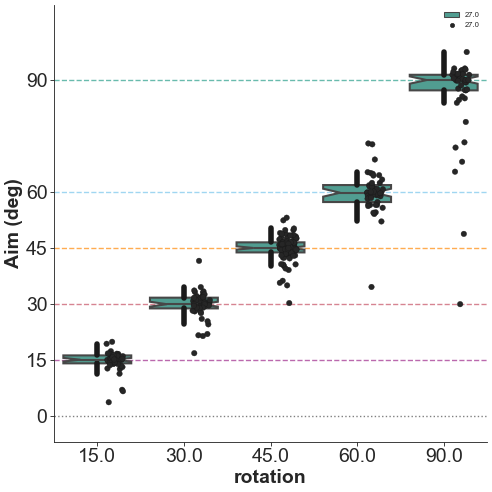

In [4]:
               
importlib.reload(DM)
ylim=(-7,110)
figSize=(10,10)
fileName = 'paperFigures/barPlot1Tar.svg'
yLox = [0,15,30,45,60,90]
yTix = [0,15,30,45,60,90]
DM.allRotBarPlot(dfs[0],xIdcs=[np.arange(25,30)],fileName=fileName,ylim=ylim,figSize=figSize,customY=True,yLox=yLox,yTix=yTix)

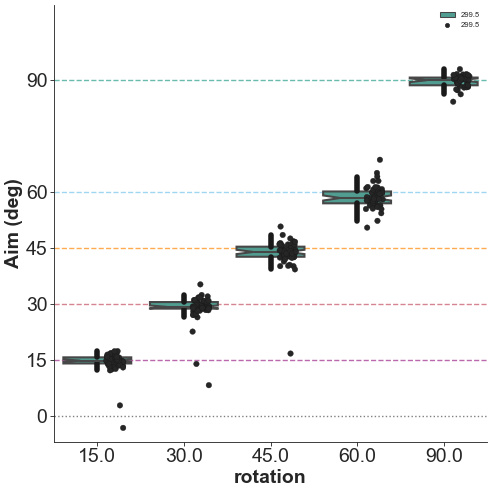

In [5]:
                
importlib.reload(DM)
fileName = 'paperFigures/barPlot8Tar.svg'
DM.allRotBarPlot(dfs[1],xIdcs=[np.arange(280,320)],fileName=fileName,ylim=ylim,figSize=figSize,customY=True,yLox=yLox,yTix=yTix)

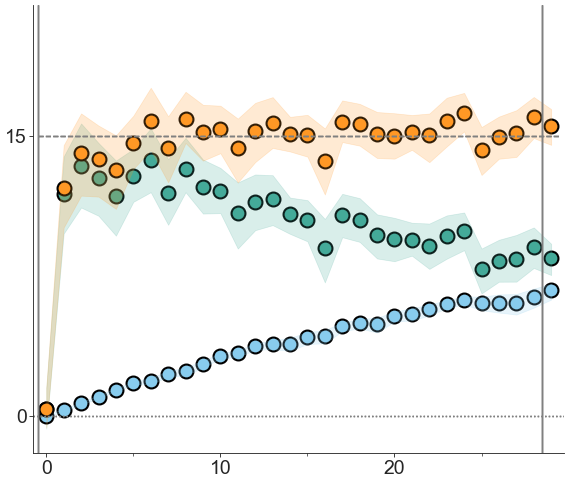

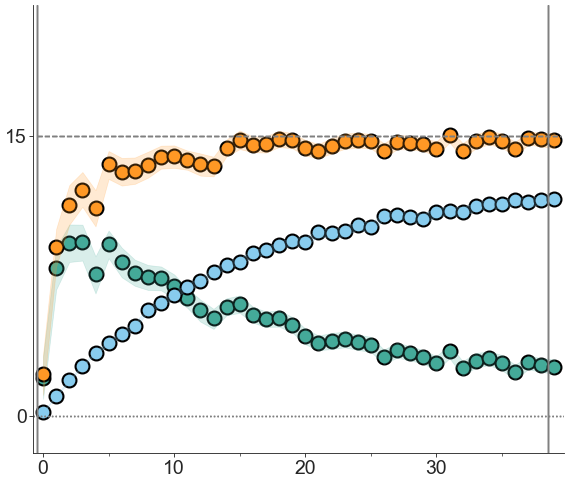

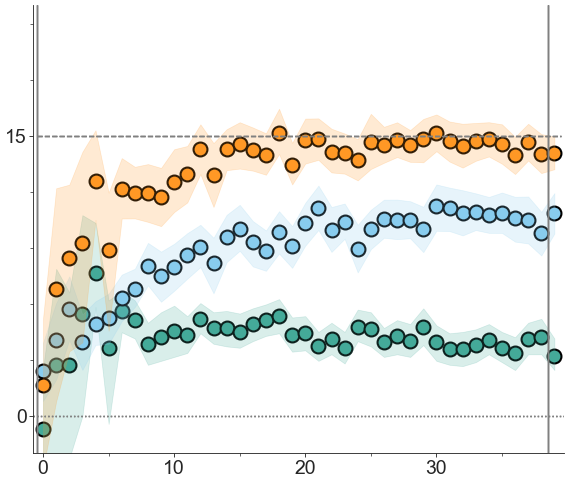

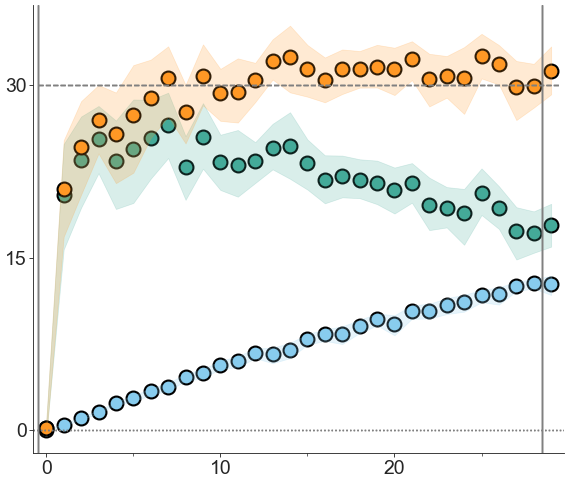

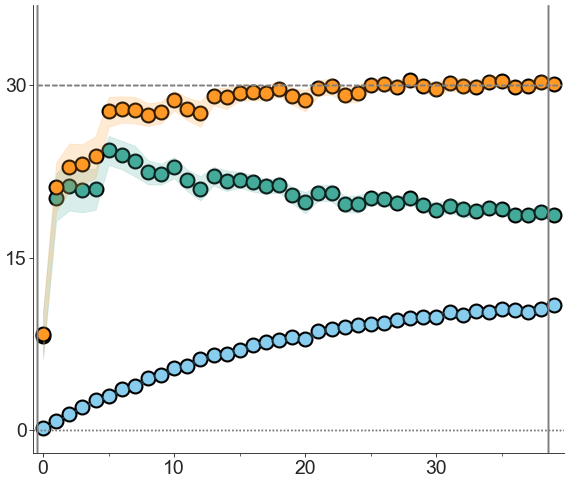

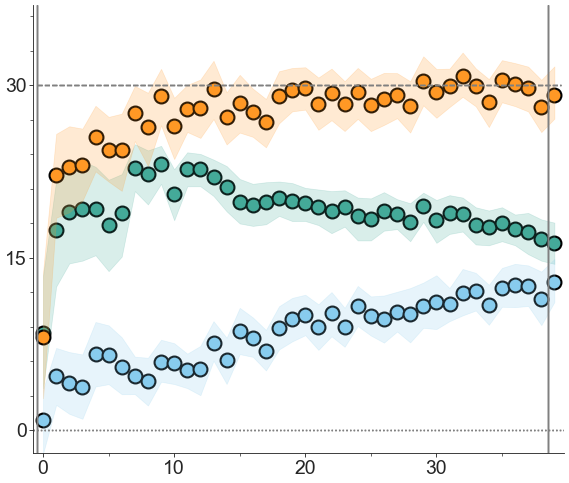

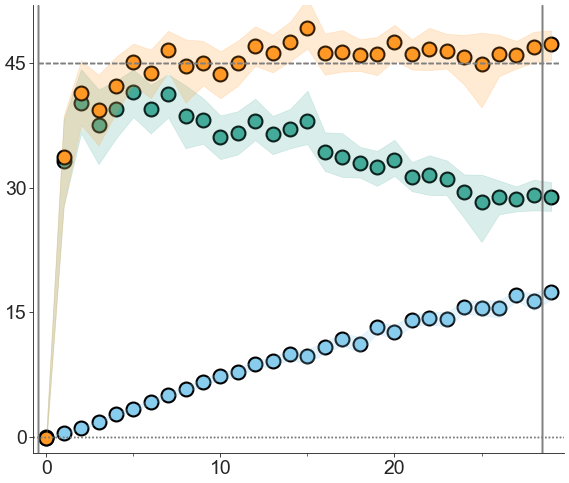

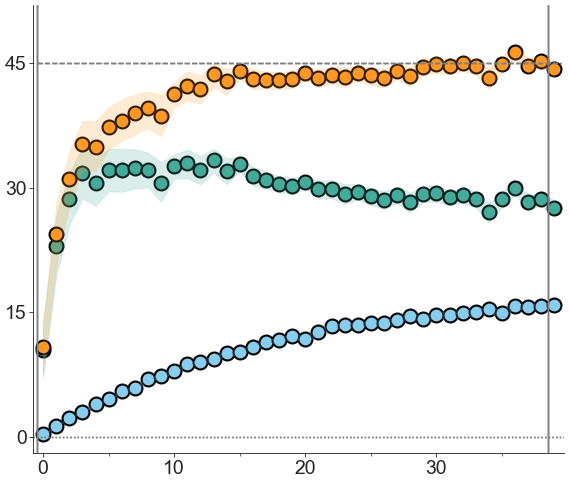

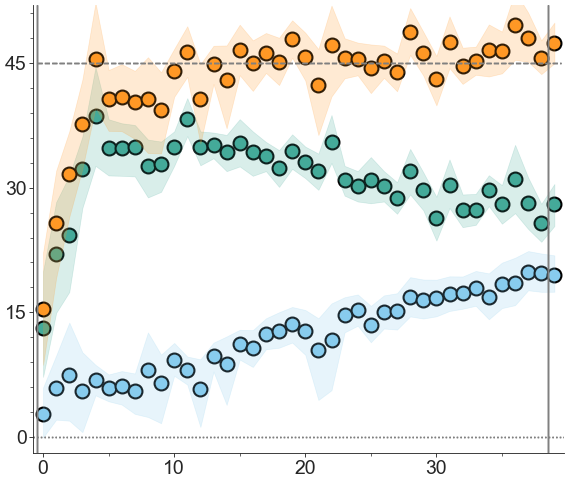

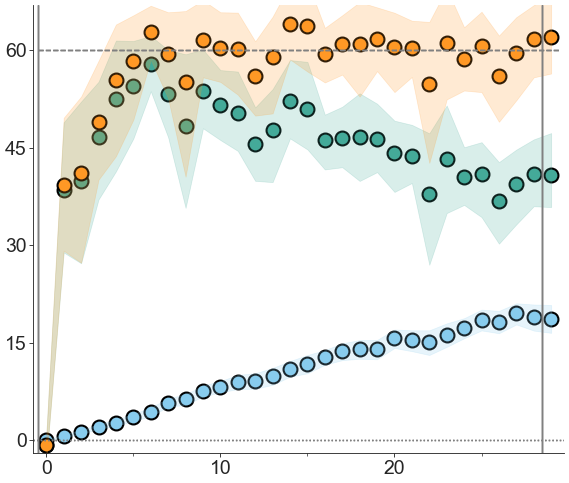

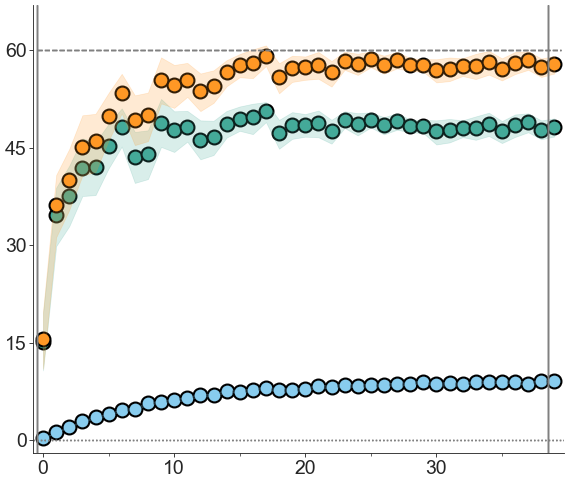

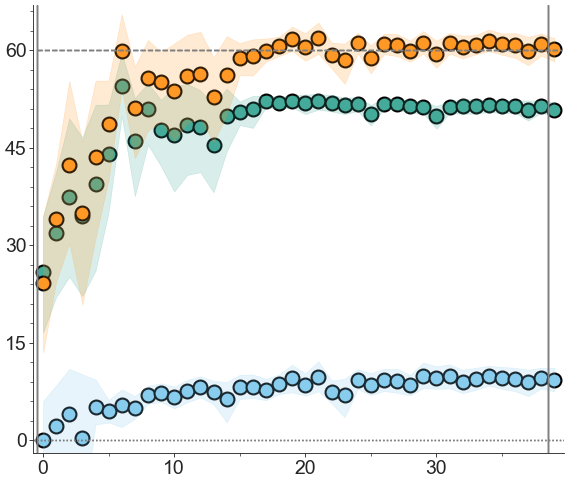

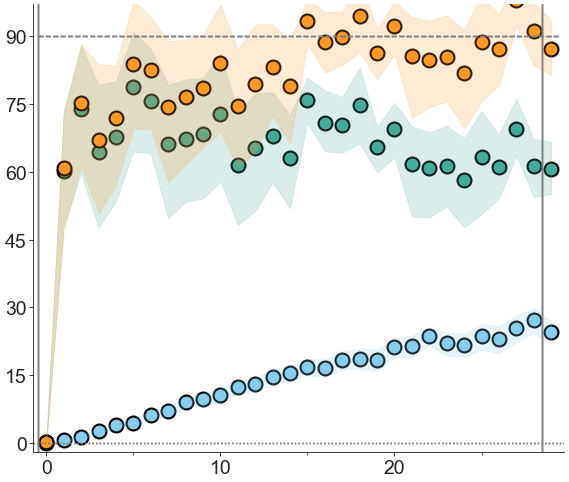

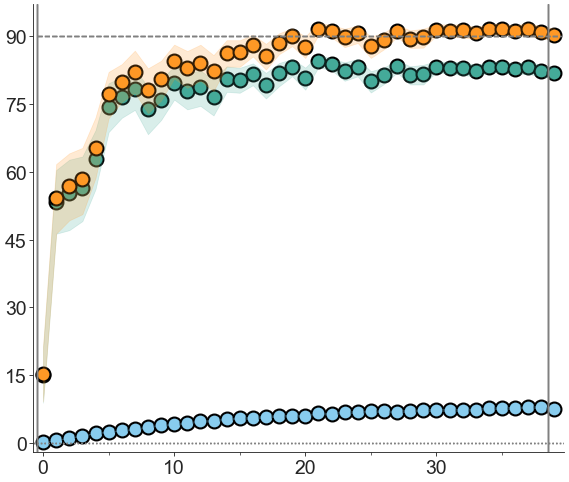

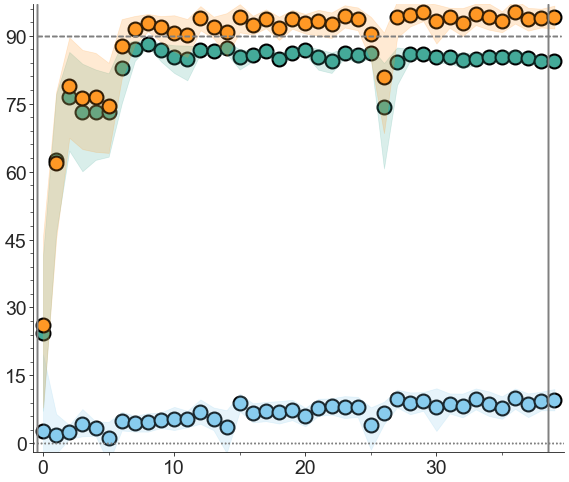

In [6]:
                                                                                                                        
importlib.reload(DM)

xTix = [[np.arange(-5,45,5)[it] for it in range(len(np.arange(-5,45,5))) if it%2==1] for p in range(6)]
xLox = xTix
xLabs= ['Rotation Cycle','Rotation Cycle']
yLabs=[np.arange(200,-181,-40)[it] for it in range(10) if it%2==1]

oneTarParams = []
eightTarParams = []
onePeak = []
oneLow = []
oneDecrease = []
oneTimeToPeak = []
oneMnAfterPeak = []
oneStdAfterPeak = []
eightPeak = []
eightLow = []
eightDecrease = []
eightTimeToPeak = []
eightMnAfterPeak = []
eightStdAfterPeak = []
btTarParams = []
btPeak = []
btLow = []
btDecrease = []
btTimeToPeak = []
btMnAfterPeak = []
btStdAfterPeak = []
orps=[]
orls=[]
erps=[]
erls=[]
brps=[]
brls=[]
oPkTs = []
ePkTs = []
bPkTs = []
BTRotDat = BTDat[(BTDat['cycle'] >= 0) & (BTDat['cycle'] < 40) ]

rots = [-15,-30,-45,-60,-90]
for r in rots:
    dat = dfs[2][dfs[2]['blockRot'] == r]
    dat = dat[(dat['blockTrial'] >= 0) & (dat['blockTrial'] <30)] 
    pars,peak,low,aimDec,peakTrial,mnAfterPeak,stdAfterPeak,rawPeaks,rawLows,peakTs= DM.componentTrialSeries([dat],x='blockTrial',supTitle='',expTitles=[r],y0='aim',y="imp",y2='totalAngle',
                            markSize=markSize,idlLines=True,figSize=(12,10),ylim=(-2,-(r-7)),caption='',xLabs=xLabs,yLabs=yLabs,yTickStepSize=1,
                            legTitle='',legLabs=[''],xTix=xTix,xLox=xLox,capOffset=0.7,fileName=targetFolder+'Component1TarBasic'+str(r)+'.svg',save=True,singlePane=True)
    
    oneTarParams.append(pars)
    onePeak.append(peak)
    oneLow.append(low)
    oneDecrease.append(aimDec)
    oneTimeToPeak.append(peakTrial)
    oneMnAfterPeak.append(mnAfterPeak)
    oneStdAfterPeak.append(stdAfterPeak)
    orps.append(rawPeaks)
    orls.append(rawLows)
    oPkTs.append([peakTs])
    
    dat = dfs[3][dfs[3]['blockRot'] == r]
    dat = dat[(dat['cycle'] >= 0) & (dat['cycle'] < 40)] 
    pars,peak,low,aimDec,peakTrial,mnAfterPeak,stdAfterPeak,rawPeaks,rawLows,peakTs = DM.componentTrialSeries([dat],x='cycle',supTitle='',expTitles=[r],y0='aim',y="imp",y2='totalAngle',
                            markSize=markSize,idlLines=True,figSize=(12,10),ylim=(-2,-(r-7)),caption='',xLabs=xLabs,yLabs=yLabs,yTickStepSize=1,
                            legTitle='',legLabs=[''],xTix=xTix,xLox=xLox,capOffset=0.7,fileName=targetFolder+'Component8TarBasic'+str(r)+'.svg',save=True,singlePane=True)
  
    eightTarParams.append(pars)
    eightPeak.append(peak)
    eightLow.append(low)
    eightDecrease.append(aimDec)
    eightTimeToPeak.append(peakTrial)
    eightMnAfterPeak.append(mnAfterPeak)
    eightStdAfterPeak.append(stdAfterPeak)
    erps.append(rawPeaks)
    erls.append(rawLows)
    ePkTs.append([peakTs])
    
    dat = BTRotDat[BTRotDat['blockRot'] == r]
    pars,peak,low,aimDec,peakTrial,mnAfterPeak,stdAfterPeak,rawPeaks,rawLows,peakTs = DM.componentTrialSeries([dat],x='cycle',supTitle='',expTitles=[r],y0='aim',y="imp",y2='totalAngle',
                            markSize=markSize,idlLines=True,figSize=(12,10),ylim=(-2,-(r-7)),caption='',xLabs=xLabs,yLabs=yLabs,
                            legTitle='',legLabs=[''],xTix=xTix,xLox=xLox,capOffset=0.7,fileName=targetFolder+'BTBasic'+str(r)+'.svg',save=True,rotationOnly=True,singlePane=True)
    
    btTarParams.append(pars)
    btPeak.append(peak)
    btLow.append(low)
    btDecrease.append(aimDec)
    btTimeToPeak.append(peakTrial)
    btMnAfterPeak.append(mnAfterPeak)
    btStdAfterPeak.append(stdAfterPeak)
    brps.append(rawPeaks)
    brls.append(rawLows)
    bPkTs.append([peakTs])

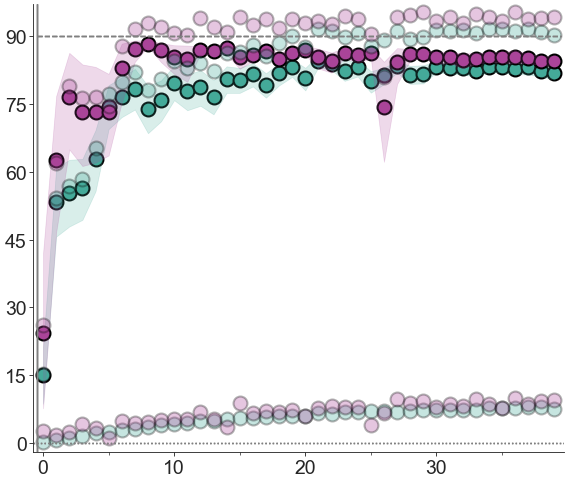

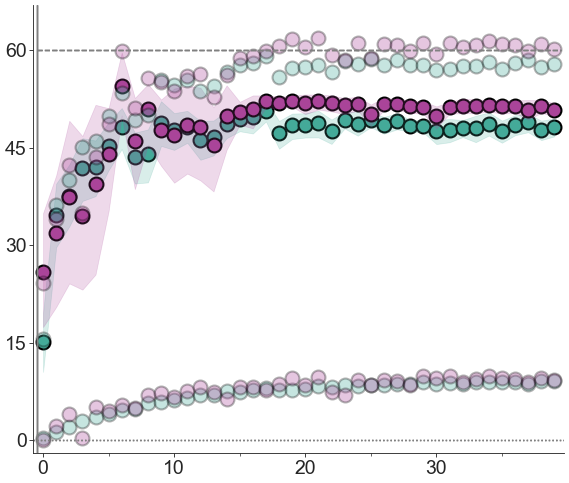

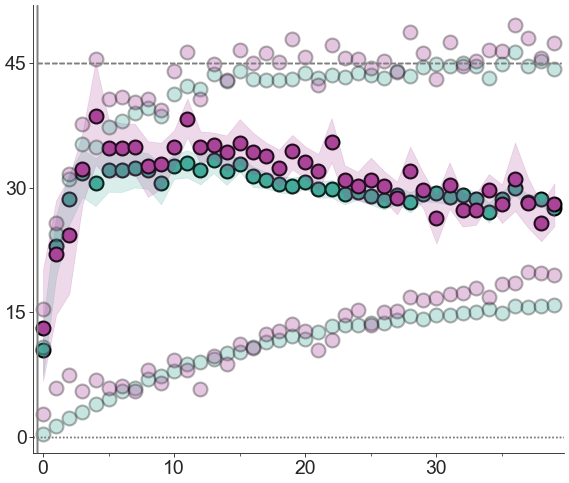

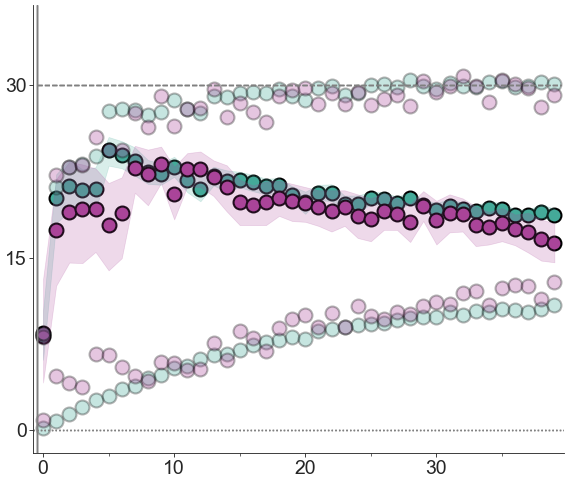

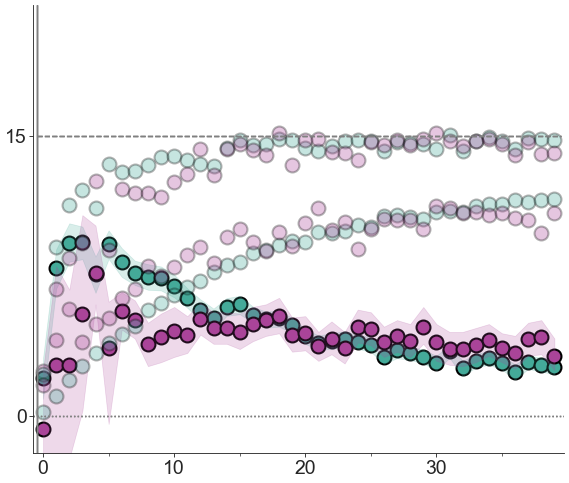

In [7]:
                                                             
           
importlib.reload(DM)
rots=[-90,-60,-45,-30,-15]
for r in rots:
    xTix = [[np.arange(-5,45,5)[it] for it in range(len(np.arange(-5,45,5))) if it%2==1] for p in range(6)]
    xLox = xTix
    xLabs= ['Rotation Cycle','Rotation Cycle']
    yLabs=[np.arange(200,-181,-40)[it] for it in range(10) if it%2==1]
    caption = ''
    dDat=dfs[3][dfs[3]['blockRot'] == r]
    bDat=BTDat[BTDat['blockRot'] == r]
    dDat = dDat[dDat['cycle']>=0]
    bDat = bDat[bDat['cycle']>=0]
    DM.muiltiExpTrialSeries([dDat,bDat],x='cycle',supTitle='',expTitles=[r],y0='aim',y="imp",y2='totalAngle',
                            markSize=markSize,idlLines=True,figSize=(12,10),ylim=(-2,-(r-7)),caption=caption,xLabs=xLabs,yLabs=yLabs,
                            xTix=xTix,xLox=xLox,capOffset=0,fileName=targetFolder+str(r)+'.svg',save=True,yTickStepSize=1)

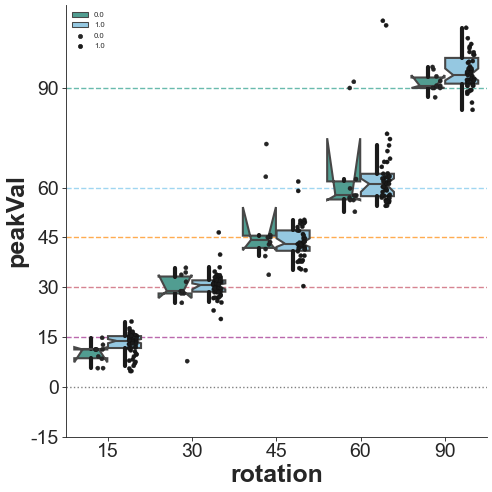

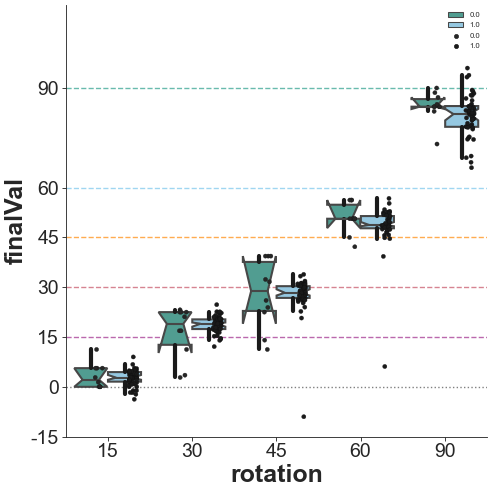

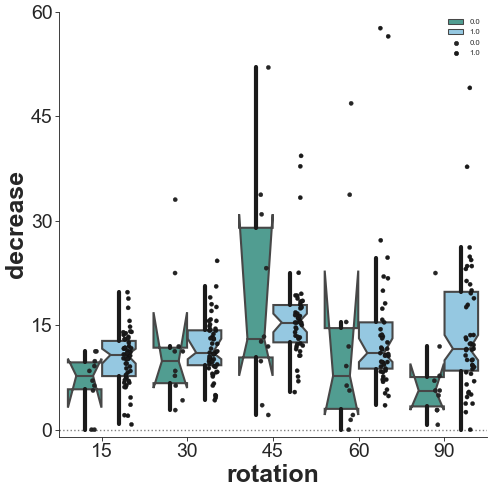

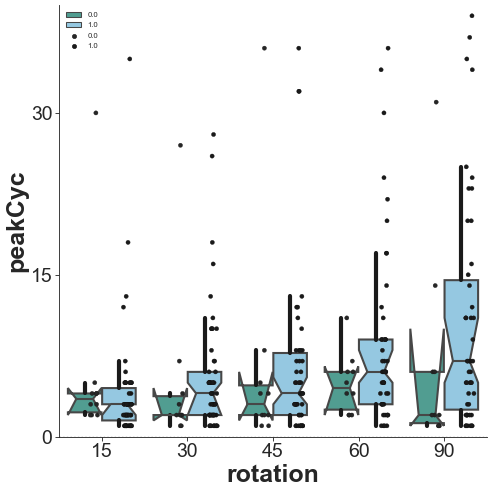

In [8]:
          
importlib.reload(DM)
erds = [np.subtract(np.array(i),np.array(j)) for i,j in zip(erps,erls)]
ords = [np.subtract(np.array(i),np.array(j)) for i,j in zip(orps,orls)]
brds = [np.subtract(np.array(i),np.array(j)) for i,j in zip(brps,brls)]
t = DM.boxPlotDifference(erps,brps,yLab='peakVal',filename=targetFolder+'peakVal.svg',ylim=(-15,115),yLox=[-15,0,15,30,45,60,90],yTix=[-15,0,15,30,45,60,90],squeeze=False)
t = DM.boxPlotDifference(erls,brls,yLab='finalVal',filename=targetFolder+'finalVal.svg',ylim=(-15,115),yLox=[-15,0,15,30,45,60,90],yTix=[-15,0,15,30,45,60,90],squeeze=False)
t = DM.boxPlotDifference(erds,brds,yLab='decrease',filename=targetFolder+'decrease.svg',ylim=(-1,60),yLox=[-30,-15,0,15,30,45,60],yTix=[-30,-15,0,15,30,45,60],squeeze=False,idlLines=False)
t = DM.boxPlotDifference(ePkTs,bPkTs,yLab='peakCyc',filename=targetFolder+'peakCyc.svg',ylim=(0,40),idlLines=False)

In [9]:
          
         
%matplotlib agg
importlib.reload(DM)
                           
rots = [-90]
                     
binSizes=[8,8,8,8,8]
figSize=(10*1.05,10)
i=0
for r in rots:
         
    tmp = dfs[0][dfs[0]['blockRot'] == r]
    tmp = tmp[tmp['blockTrial'] <30]
    tmp = tmp[tmp['blockNum']==0]
    numBins = int(360 / binSizes[i])
    xLox = [np.arange(0,60,5)[it] for it in range(len(np.arange(0,60,5))) if it%2==1]
    xTix =[np.arange(-15,45,5)[it] for it in range(len(np.arange(-15,45,5))) if it%2==1]
    yTix = [np.arange(-2.5,numBins+1,5)[it] for it in range(10) if it%2==1]
    minYTix = np.arange(0.5,numBins,1)
    yLabs=[np.arange(200,-181,-40)[it] for it in range(10) if it%2==1]
    caption = ''
    norm = mpl.colors.LogNorm(vmin=4e-2,vmax=1)
                
    t = DM.getHeatDF(tmp,expLen=60,numBlocks=1,var='aim',binWidth=binSizes[i],x='blockTrial',cond='blockRot')
    DM.heatMap(df=t,kdeDf=dfs[0],norm=norm,deleteTitle=True,rotStart=15,rotLen=30,xTickStepSize=2,numBlocks=1,panelLabs=[r],kde=False,kdeBW=0.04,xLox=xLox,xTix=xTix,yTix=yTix,minYTix=minYTix,yLabs=yLabs,caption=caption,capOffset=-0.17,overlayTrialSeries=False,figSize=figSize,cbar=True,showPlot=False,save=True,fileName=targetFolder+'HeatMap1Tar'+str(r)+'.svg')
    tmp = dfs[2][dfs[2]['blockRot'] == r]
    tmp = tmp[tmp['blockNum']==0]
    i+=1

In [10]:
          
                   
importlib.reload(DM)
rots=[-90,-60,-45,-30,-15]
binSizes = [9,6,4.5,3,1.5]
binSizes = [i*2 for i in binSizes]
figSize=(10*1.05,10)
yHighs=[180,120,90,60,30]
yLows=[-i*1.5 for i in binSizes]
i=0
for r in rots:     
    tmp = dfs[0][dfs[0]['blockRot'] == r]
    tmp = tmp[tmp['blockTrial'] <30]
    tmp = tmp[tmp['blockNum']==0]
    xLox = [np.arange(0,60,5)[it] for it in range(len(np.arange(0,60,5))) if it%2==1]
    xTix =[np.arange(-15,45,5)[it] for it in range(len(np.arange(-15,45,5))) if it%2==1]
    yTix,minYTix,yLabs=[],[],[]
    yTix = np.arange(1,10,1)+0.5
    caption = ''
    norm = mpl.colors.LogNorm(vmin=4e-2,vmax=6e-1)
    t = DM.getHeatDF(tmp,expLen=45,numBlocks=1,var='aim',binWidth=binSizes[i],x='blockTrial',cond='blockRot',yLow=yLows[i],yHigh=yHighs[i])
    
    DM.heatMap(df=t,xlim=(15,45),ySize=360,kdeDf=dfs[0],norm=norm,deleteTitle=True,rotStart=-1,rotLen=30,xTickStepSize=2,numBlocks=1,
               panelLabs=[r],kde=False,kdeBW=0.04,xLox=xLox,xTix=xTix,yTix=yTix,minYTix=minYTix,yTickStepSize=1,yLabs=yLabs,caption=caption,capOffset=-0.17,
               overlayTrialSeries=False,figSize=figSize,cbar=True,showPlot=False,save=True,fileName=targetFolder+'truncatedHeatMap1Tar'+str(r)+'.svg')
    i+=1

In [11]:
                                
tmp = dfs[0][dfs[0]['blockRot'] == -90]
tmp = tmp[tmp['blockTrial'] >= -5]
trialwiseNoise = tmp.groupby('blockTrial').std()['aim'].tolist()
fittedParams = False
it = 0
for it in range(len(trialwiseNoise)):
    if it >= 0:
        trialwiseNoise[it] *= 0
    it+=1
print(trialwiseNoise)
importlib.reload(NonGenSSM)
              
numP = 100
rots = [0]*5
[rots.append(i) for i in [-90]*30]
[rots.append(i) for i in [0]*5]
rots=DM.flattenJagged(rots)
if fittedParams:
    lrs = paramDF['lr'].tolist() 
    rets = paramDF['retention'].tolist() 
else:
    lrs = [np.random.normal(0.26,0.015) for i in range(numP)] 
    rets = [min(np.random.normal(0.995,0.02),1) for i in range(numP)] 

ssm = NonGenSSM.fitShell()
states = []
for p in range(numP):
    states.append(ssm.genDat(params=(lrs[p],rets[p]),rots=rots))
for p in states:
    for t in range(len(p)):
        if t < 35:
            p[t]+=np.random.normal(0,trialwiseNoise[t])

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [12]:
                               
importlib.reload(DM)
importlib.reload(NonGenSSM)
pp = DM.flattenJagged([[i]*40 for i in np.arange(numP)])
blockTrial = DM.flattenJagged([np.arange(-5,35,1) for i in range(numP)])
blockRot =DM.flattenJagged([[-90]*40 for i in np.arange(numP)])
aim = DM.flattenJagged(states)
print([len(i) for i in [pp,blockTrial,blockRot,aim]])
data = {'participantNum':pp,'blockTrial':blockTrial,'blockRot':blockRot,'aim':aim}
simDF = pd.DataFrame(data)

[4000, 4000, 4000, 4000]


In [13]:
          
                   
simDF = simDF[simDF['blockTrial']<30]
t = DM.getHeatDF(simDF,expLen=60,numBlocks=1,binWidth=8)
xLox = [np.arange(0.5,40.5,5)[it] for it in range(len(np.arange(0,40,5))) if True]
xTix =[np.arange(-5,35,5)[it] for it in range(len(np.arange(-5,35,5))) if True]
yTix = [np.arange(-2.5,46,5)[it] for it in range(10) if it%2==1]
minYTix = np.arange(0.5,45,1)
yLabs=[np.arange(200,-181,-40)[it] for it in range(10) if it%2==1]
caption = ''
r=''
if fittedParams:
    fileName= 'fittedSSM901TarHeatmap.svg'
else:
    fileName = 'test901TarSSMHeatmap.svg'
fileName = targetFolder + fileName
DM.heatMap(df=t,norm=mpl.colors.LogNorm(),kdeDf=dfs[0],rotStart=15,rotLen=30,xTickStepSize=2,numBlocks=1,panelLabs=[r],
           kde=False,kdeBW=0.04,xLox=xLox,xTix=xTix,yTix=yTix,minYTix=minYTix,yLabs=yLabs,caption=caption,
           capOffset=-0.17,overlayTrialSeries=False,figSize=(10*1.05,10),cbar=True,showPlot=False,save=True,
           fileName=fileName)


In [14]:
                                
importlib.reload(SFM)
              
fittedParams = False
rots = [0]*5
[rots.append(i) for i in [-90]*30]
[rots.append(i) for i in [0]*5]
rots=DM.flattenJagged(rots)
if fittedParams:
    ss = paramDF['stepStart'].tolist()
    sh = paramDF['stepHeight'].tolist()
else:
    alpha = 2.5
    beta = 3        
    ss = beta * (np.random.pareto(alpha,size=numP))
    sh = [np.random.normal(90,3) for i in range(numP)]
stepper = SFM.fitShell(df='none')
states = []
for p in range(numP):
    states.append(stepper.genDat(params=(ss[p],sh[p]),rots=rots))
for p in states:
    for t in range(len(p)):
        if True:       
            p[t]+=np.random.normal(0,trialwiseNoise[t])
        else:
            pass

In [15]:
                               
importlib.reload(DM)
importlib.reload(SFM)
pp = DM.flattenJagged([[i]*40 for i in np.arange(numP)])
blockTrial = DM.flattenJagged([np.arange(-5,35,1) for i in range(numP)])
blockRot =DM.flattenJagged([[-90]*40 for i in np.arange(numP)])
aim = DM.flattenJagged(states)
print([len(i) for i in [pp,blockTrial,blockRot,aim]])
data = {'participantNum':pp,'blockTrial':blockTrial,'blockRot':blockRot,'aim':aim}
simStepDF = pd.DataFrame(data)

[4000, 4000, 4000, 4000]


In [16]:
          
                   
t = DM.getHeatDF(simStepDF,expLen=60,numBlocks=1,binWidth=8)
xLox = [np.arange(0.5,40.5,5)[it] for it in range(len(np.arange(0,40,5))) if True]
xTix =[np.arange(-5,35,5)[it] for it in range(len(np.arange(-5,35,5))) if True]
yTix = [np.arange(-2.5,46,5)[it] for it in range(10) if it%2==1]
minYTix = np.arange(0.5,45,1)
yLabs=[np.arange(200,-181,-40)[it] for it in range(10) if it%2==1]
caption = ''
fileName = 'fittedStepper901TarHeatmap.svg' if fittedParams else 'roughParamsStepper901TarHeatmpat.svg'
fileName = targetFolder + fileName
DM.heatMap(df=t,norm=mpl.colors.LogNorm(),kdeDf=dfs[0],rotStart=15,rotLen=30,xTickStepSize=2,numBlocks=1,panelLabs=[r],
           kde=False,kdeBW=0.04,xLox=xLox,xTix=xTix,yTix=yTix,minYTix=minYTix,yLabs=yLabs,caption=caption,
           capOffset=-0.17,overlayTrialSeries=False,figSize=(10*1.05,10),cbar=True,showPlot=False,save=True,
           fileName=fileName)


In [17]:
                                                  
importlib.reload(ASM)
              
fittedParams = False
numP = 100
rot = 90
sigmaM = [0] * numP                  
sigmaE = [min(max(np.random.normal(7000,1000),0),100000) for i in range(numP)]                    
alpha = [1] * numP
asm = ASM.fitShell(df='none')
states = []
for p in range(numP):
    states.append(asm.genDat(params=(alpha[p],sigmaE[p],sigmaM[p]),rot=rot,prepend=5))


In [18]:
                               
importlib.reload(DM)
importlib.reload(ASM)
pp = DM.flattenJagged([[i]*35 for i in np.arange(numP)])
blockTrial = DM.flattenJagged([np.arange(-5,30,1) for i in range(numP)])
blockRot =DM.flattenJagged([[-90]*35 for i in np.arange(numP)])
aim = DM.flattenJagged(states)
print([len(i) for i in [pp,blockTrial,blockRot,aim]])
data = {'participantNum':pp,'blockTrial':blockTrial,'blockRot':blockRot,'aim':aim}
simASMDF = pd.DataFrame(data)

[3500, 3500, 3500, 3500]


In [19]:
          
                   
importlib.reload(DM)
t = DM.getHeatDF(simASMDF,expLen=60,numBlocks=1,binWidth=8)
xLox = [np.arange(0.5,35.5,5)[it] for it in range(len(np.arange(0,35,5))) if True]
xTix =[np.arange(-5,30,5)[it] for it in range(len(np.arange(-5,30,5))) if True]
yTix = [np.arange(-2.5,46,5)[it] for it in range(10) if it%2==1]
minYTix = np.arange(0.5,45,1)
yLabs=[np.arange(200,-181,-40)[it] for it in range(10) if it%2==1]
caption = ''
r=''
fileName = 'fittedCashaback901TarHeatmap.svg' if fittedParams else 'roughParamsCashaback901TarHeatmpat.svg'
fileName = targetFolder + fileName
DM.heatMap(df=t,norm=mpl.colors.LogNorm(),kdeDf=dfs[0],rotStart=15,rotLen=30,xTickStepSize=2,numBlocks=1,panelLabs=[r],
           kde=False,kdeBW=0.04,xLox=xLox,xTix=xTix,yTix=yTix,minYTix=minYTix,yLabs=yLabs,caption=caption,
           capOffset=-0.17,overlayTrialSeries=False,figSize=(10*1.05,10),cbar=True,showPlot=True,save=True,
           fileName=fileName,plotTitle = "")


In [21]:
ssmsAll = np.load("ssmsVanilla1.npy",allow_pickle=True)
sfmsAll = np.load("sfmsVanilla1.npy",allow_pickle=True)
asmsAll = np.load("asmsVanilla1.npy",allow_pickle=True)
for i in range(len(asmsAll)):
    asmsAll[i].xs = asmsAll[i].xs[len(asmsAll[i].xs)//2:]                           
ssmBIC = [i.BICs for i in ssmsAll]
sfmBIC = [i.BICs for i in sfmsAll]
asmBIC = [i.BICs for i in asmsAll]

In [22]:
          
                 
importlib.reload(DM)
DM.plotThreeWayRelativeBIC(ssmBIC,sfmBIC,asmBIC,markerSize=100,targetFolder=targetFolder,fileName="ThreeWayModelComparisonCannonGame1Tar.svg",
                           xlim=(-10,110),ylim=(-10,220),averageXlim=(-10,35),xlab='Delta-BIC Insight - SSM',ylab='Delta-BIC Insight - Cashaback',figSize=(8, 8))

(-10, 110) (-10, 35)


In [23]:
allRotParams = []
for r in range(len(rots)):
    numP = len(ssmsAll[r].mStates)
    ssmParams = []
    sfmParams = []
    asmParams = []
    for p in range(numP):
        params = ssmsAll[r].xs[p]
        ssmParams.append(params)
        params = sfmsAll[r].xs[p]
        sfmParams.append(params)
        params = asmsAll[r].xs[p]
        asmParams.append(params)
    BICs = [ssmBIC,sfmBIC,asmBIC]
    allParams = [ssmParams,sfmParams,asmParams]
    allRotParams.append(allParams)

In [24]:
              
                                       
importlib.reload(DM)
for rot in range(len(rots)):
    ssmParams = [i[0] for i in allRotParams]
    sfmParams = [i[1] for i in allRotParams]
    asmParams = [i[2] for i in allRotParams]
DM.plotParams(ssmParams,sfmParams,asmParams,fileName=targetFolder+'CannonGameModelComparisonFits.svg')

    model  rot  param       val
0     ssm   90      0  0.137149
1     ssm   90      0  0.127101
2     ssm   90      0  0.197347
3     ssm   90      0  0.046184
4     ssm   90      0  0.136548
..    ...  ...    ...       ...
832   asm   15      2  9.021441
833   asm   15      2  8.998492
834   asm   15      2  8.131436
835   asm   15      2  8.999750
836   asm   15      2  6.953866

[837 rows x 4 columns]


In [25]:
ssmsAllBrudner = np.load("BrudnerSsmsDelay5000_1Tar.npy",allow_pickle=True)
sfmsAllBrudner = np.load("BrudnerSfmsDelay5000_1Tar.npy",allow_pickle=True)
asmsAllBrudner = np.load("BrudnerAsmsDelay5000_1Tar.npy",allow_pickle=True)
for i in range(len(asmsAllBrudner)):
    asmsAllBrudner[i].xs = asmsAllBrudner[i].xs[len(asmsAllBrudner[i].xs)//2:]                           
ssmBICBrudner = [i.BICs for i in ssmsAllBrudner]
sfmBICBrudner = [i.BICs for i in sfmsAllBrudner]
asmBICBrudner = [i.BICs for i in asmsAllBrudner]

In [26]:
          
             
importlib.reload(DM)
DM.plotThreeWayRelativeBIC(ssmBICBrudner,sfmBICBrudner,asmBICBrudner,markerSize=100,targetFolder=targetFolder,fileName="ThreeWayModelComparisonBrudner5000Delay_1Tar.svg",
                           xlim=(-10,185),ylim=(-25,560),averageXlim=(-10,50),xlab='Delta-BIC Insight - SSM',ylab='Delta-BIC Insight - Cashaback',figSize=(8, 8))

(-10, 185) (-10, 50)


In [27]:
r=0
numP = len(ssmsAll[r].mStates)
allRotParams=[]

num_rows = 5
num_cols = 4
num_panels = num_rows * num_cols

num_panels = min(num_panels, numP)

ssmParamsBrudner = []
sfmParamsBrudner = []
asmParamsBrudner = []

for p in range(num_panels):
    params = ssmsAllBrudner[r].xs[p]
    ssmParamsBrudner.append(params)
    params = sfmsAllBrudner[r].xs[p]
    sfmParamsBrudner.append(params)
    params = asmsAllBrudner[r].xs[p]
    asmParamsBrudner.append(params)

In [28]:
              
                       
importlib.reload(DM)
DM.plotParams([ssmParamsBrudner],[sfmParamsBrudner],[asmParamsBrudner],rots=[30],figsize=(7,20),squeezeX=True,fileName=targetFolder+'BrudnerModelComparisonFits.svg')

    model  rot  param        val
0     ssm   30      0   0.003480
1     ssm   30      0   0.004596
2     ssm   30      0   0.021341
3     ssm   30      0   0.078188
4     ssm   30      0   0.015167
..    ...  ...    ...        ...
175   asm   30      2  14.983603
176   asm   30      2  16.471139
177   asm   30      2  17.182233
178   asm   30      2  23.862249
179   asm   30      2  11.469794

[180 rows x 4 columns]


In [6]:
BOCD8ImpCG = np.load("CGBFSSM8AllPPs.npy",allow_pickle=True)
"""
TODOS:
plot params (linear scale for BFSSM), to make sure evrything generally reasonable; in particular 
check visCoeff, if not betwwe 0.1 and 0.4 then need to fix model anyway.
If visCoeff good, then need to plot BICs vs other models (just do SSM for now), then RMSE and R^2. 
For BICs, just show the difference, for rmse and R^2, show both seperately on neighbouring swarm and boxplots
"""
                                                                                                  
                   
                                              

                                                          
                                                                                                             
                                                


'\nTODOS:\nplot params (linear scale for BFSSM), to make sure evrything generally reasonable; in particular \ncheck visCoeff, if not betwwe 0.1 and 0.4 then need to fix model anyway.\nIf visCoeff good, then need to plot BICs vs other models (just do SSM for now), then RMSE and R^2. \nFor BICs, just show the difference, for rmse and R^2, show both seperately on neighbouring swarm and boxplots\n'

In [13]:
obj = BOCD8ImpCG[0]
instance_vars = [attr for attr in dir(obj) if not attr.startswith('__') and not callable(getattr(obj, attr))]
print(instance_vars)

['allAims', 'bics', 'conVal', 'condition', 'dat', 'df', 'fitPhase', 'heightCap', 'mStates', 'negLl', 'numCores', 'participantNums', 'plotIdentifier', 'popSizeMultiplier', 'rSquareds', 'rmses', 'xs']


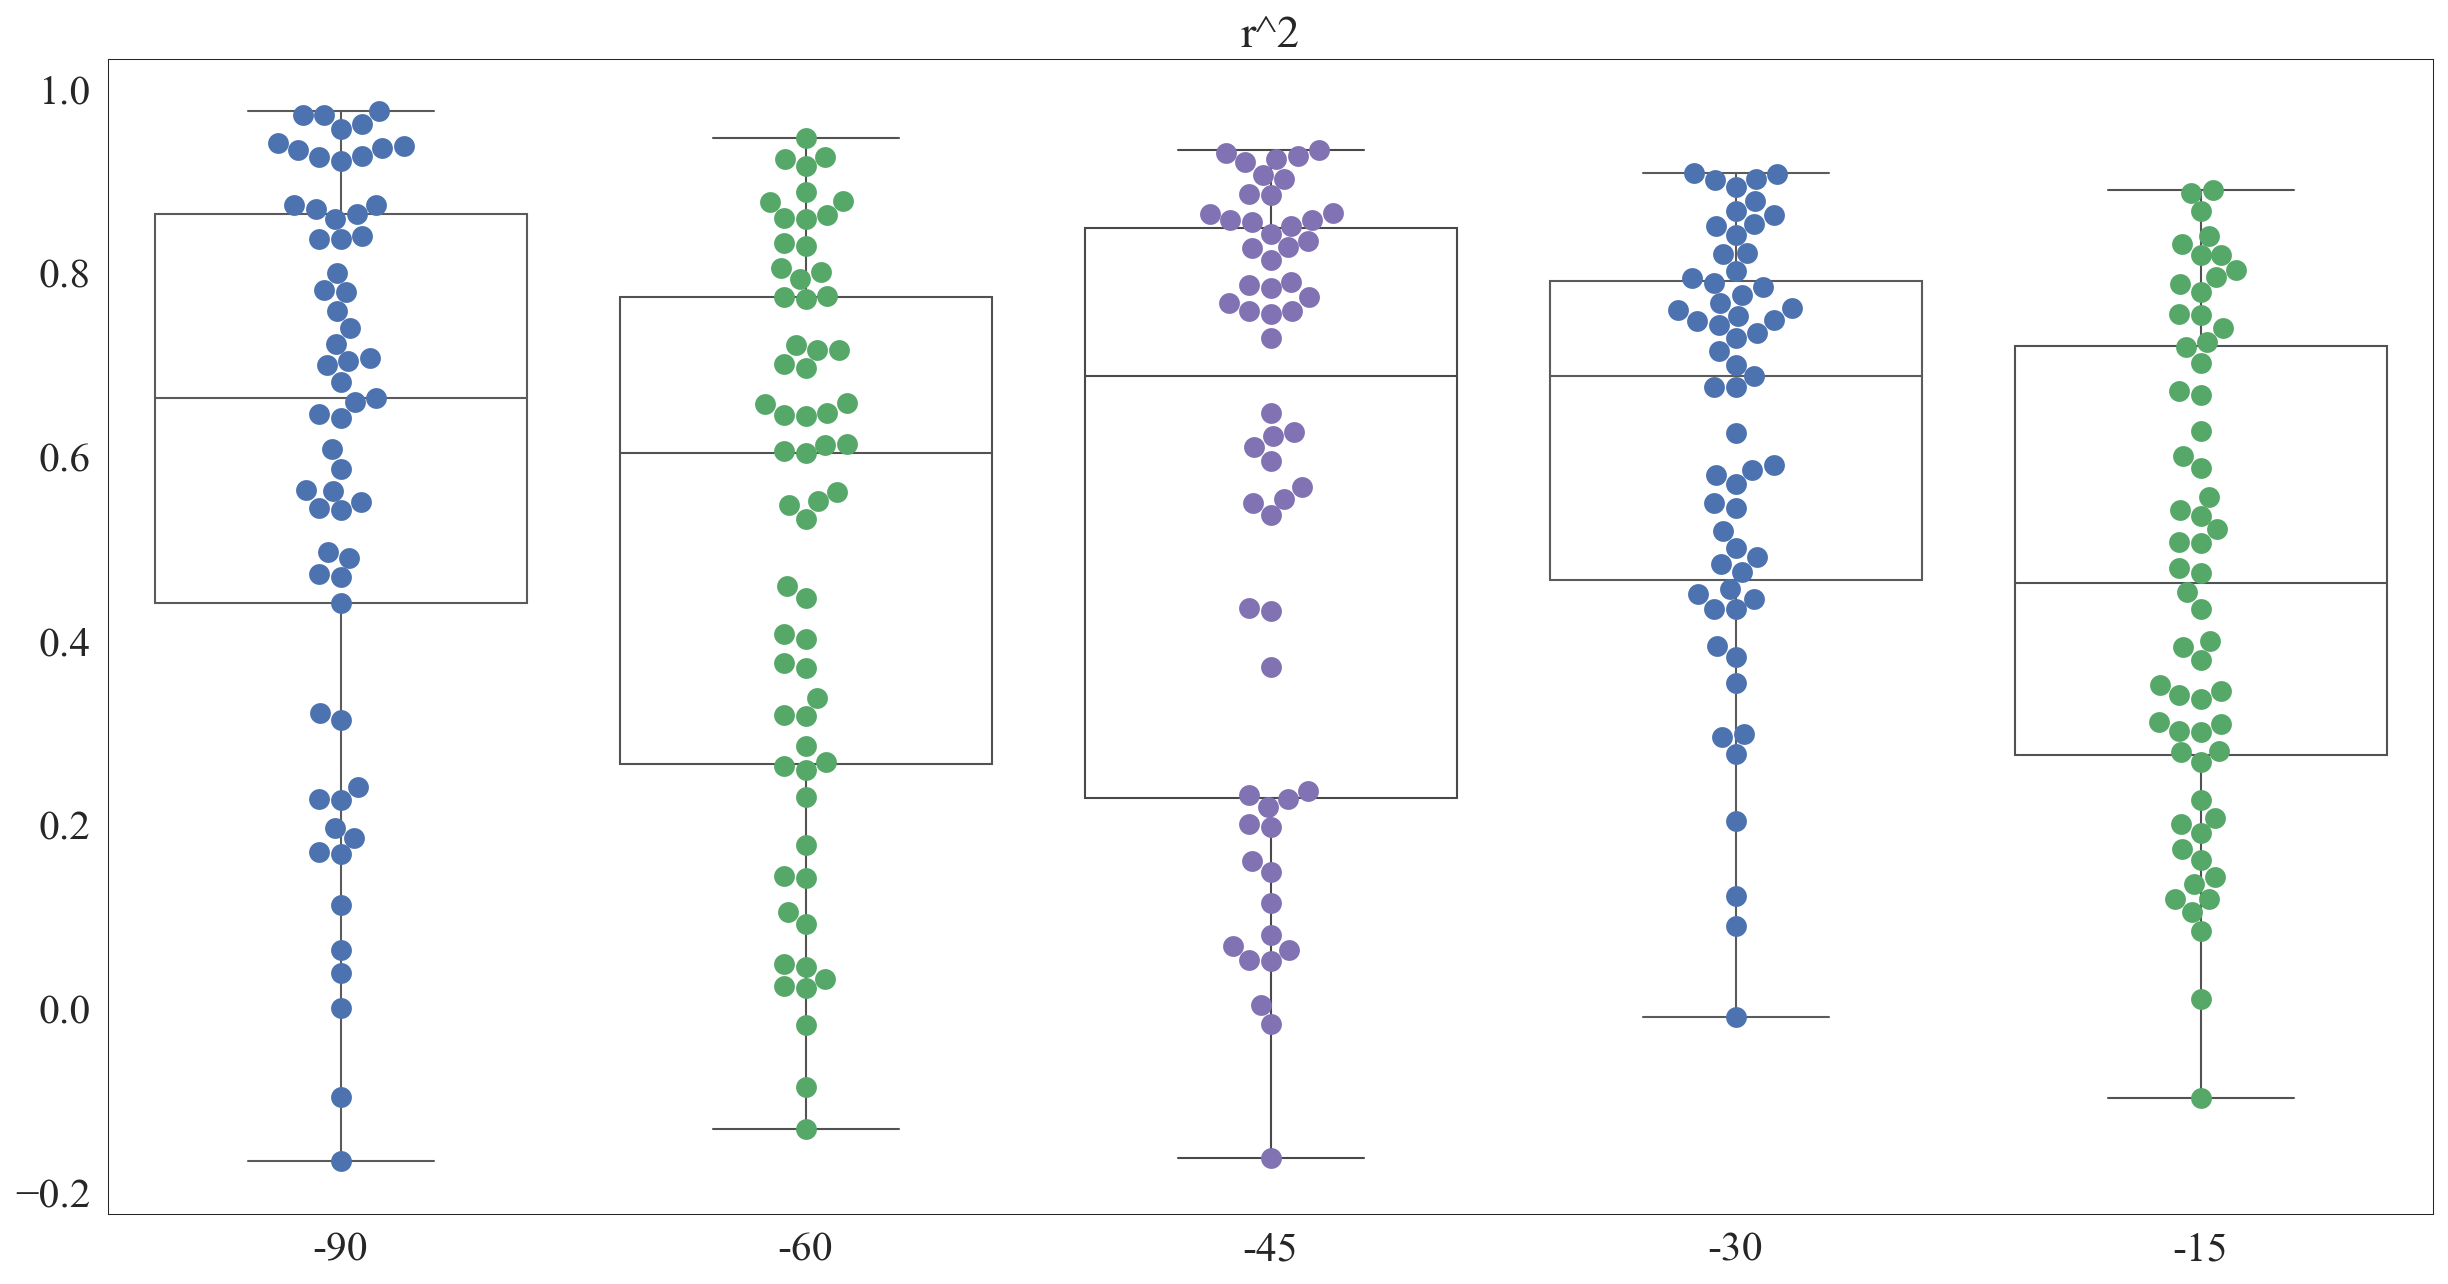

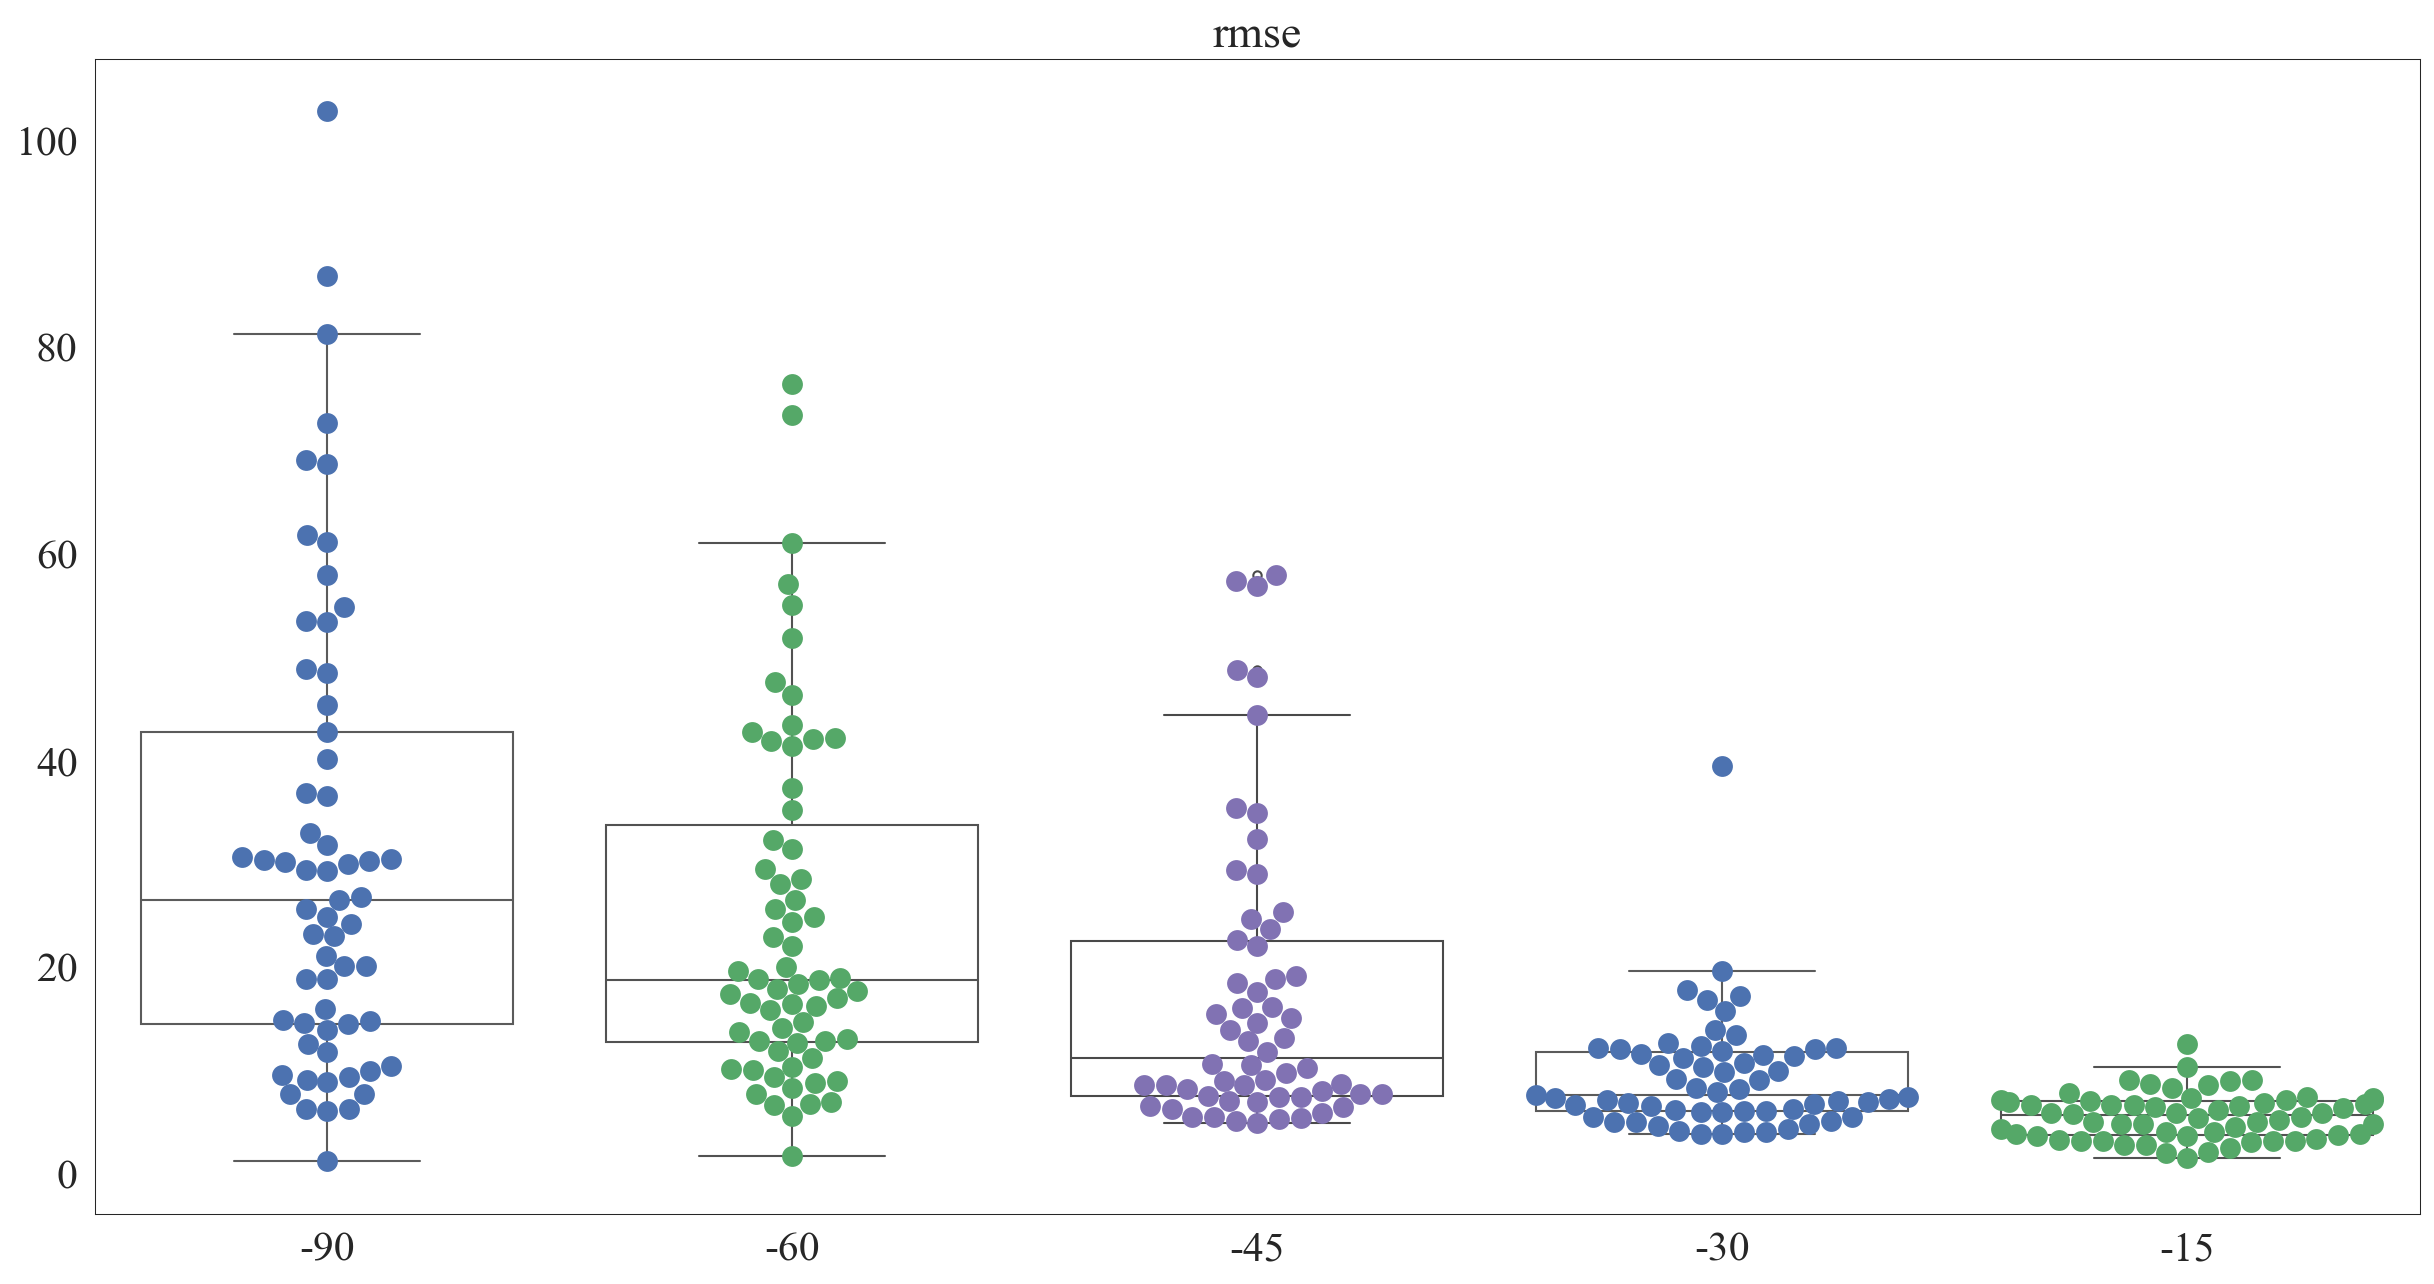

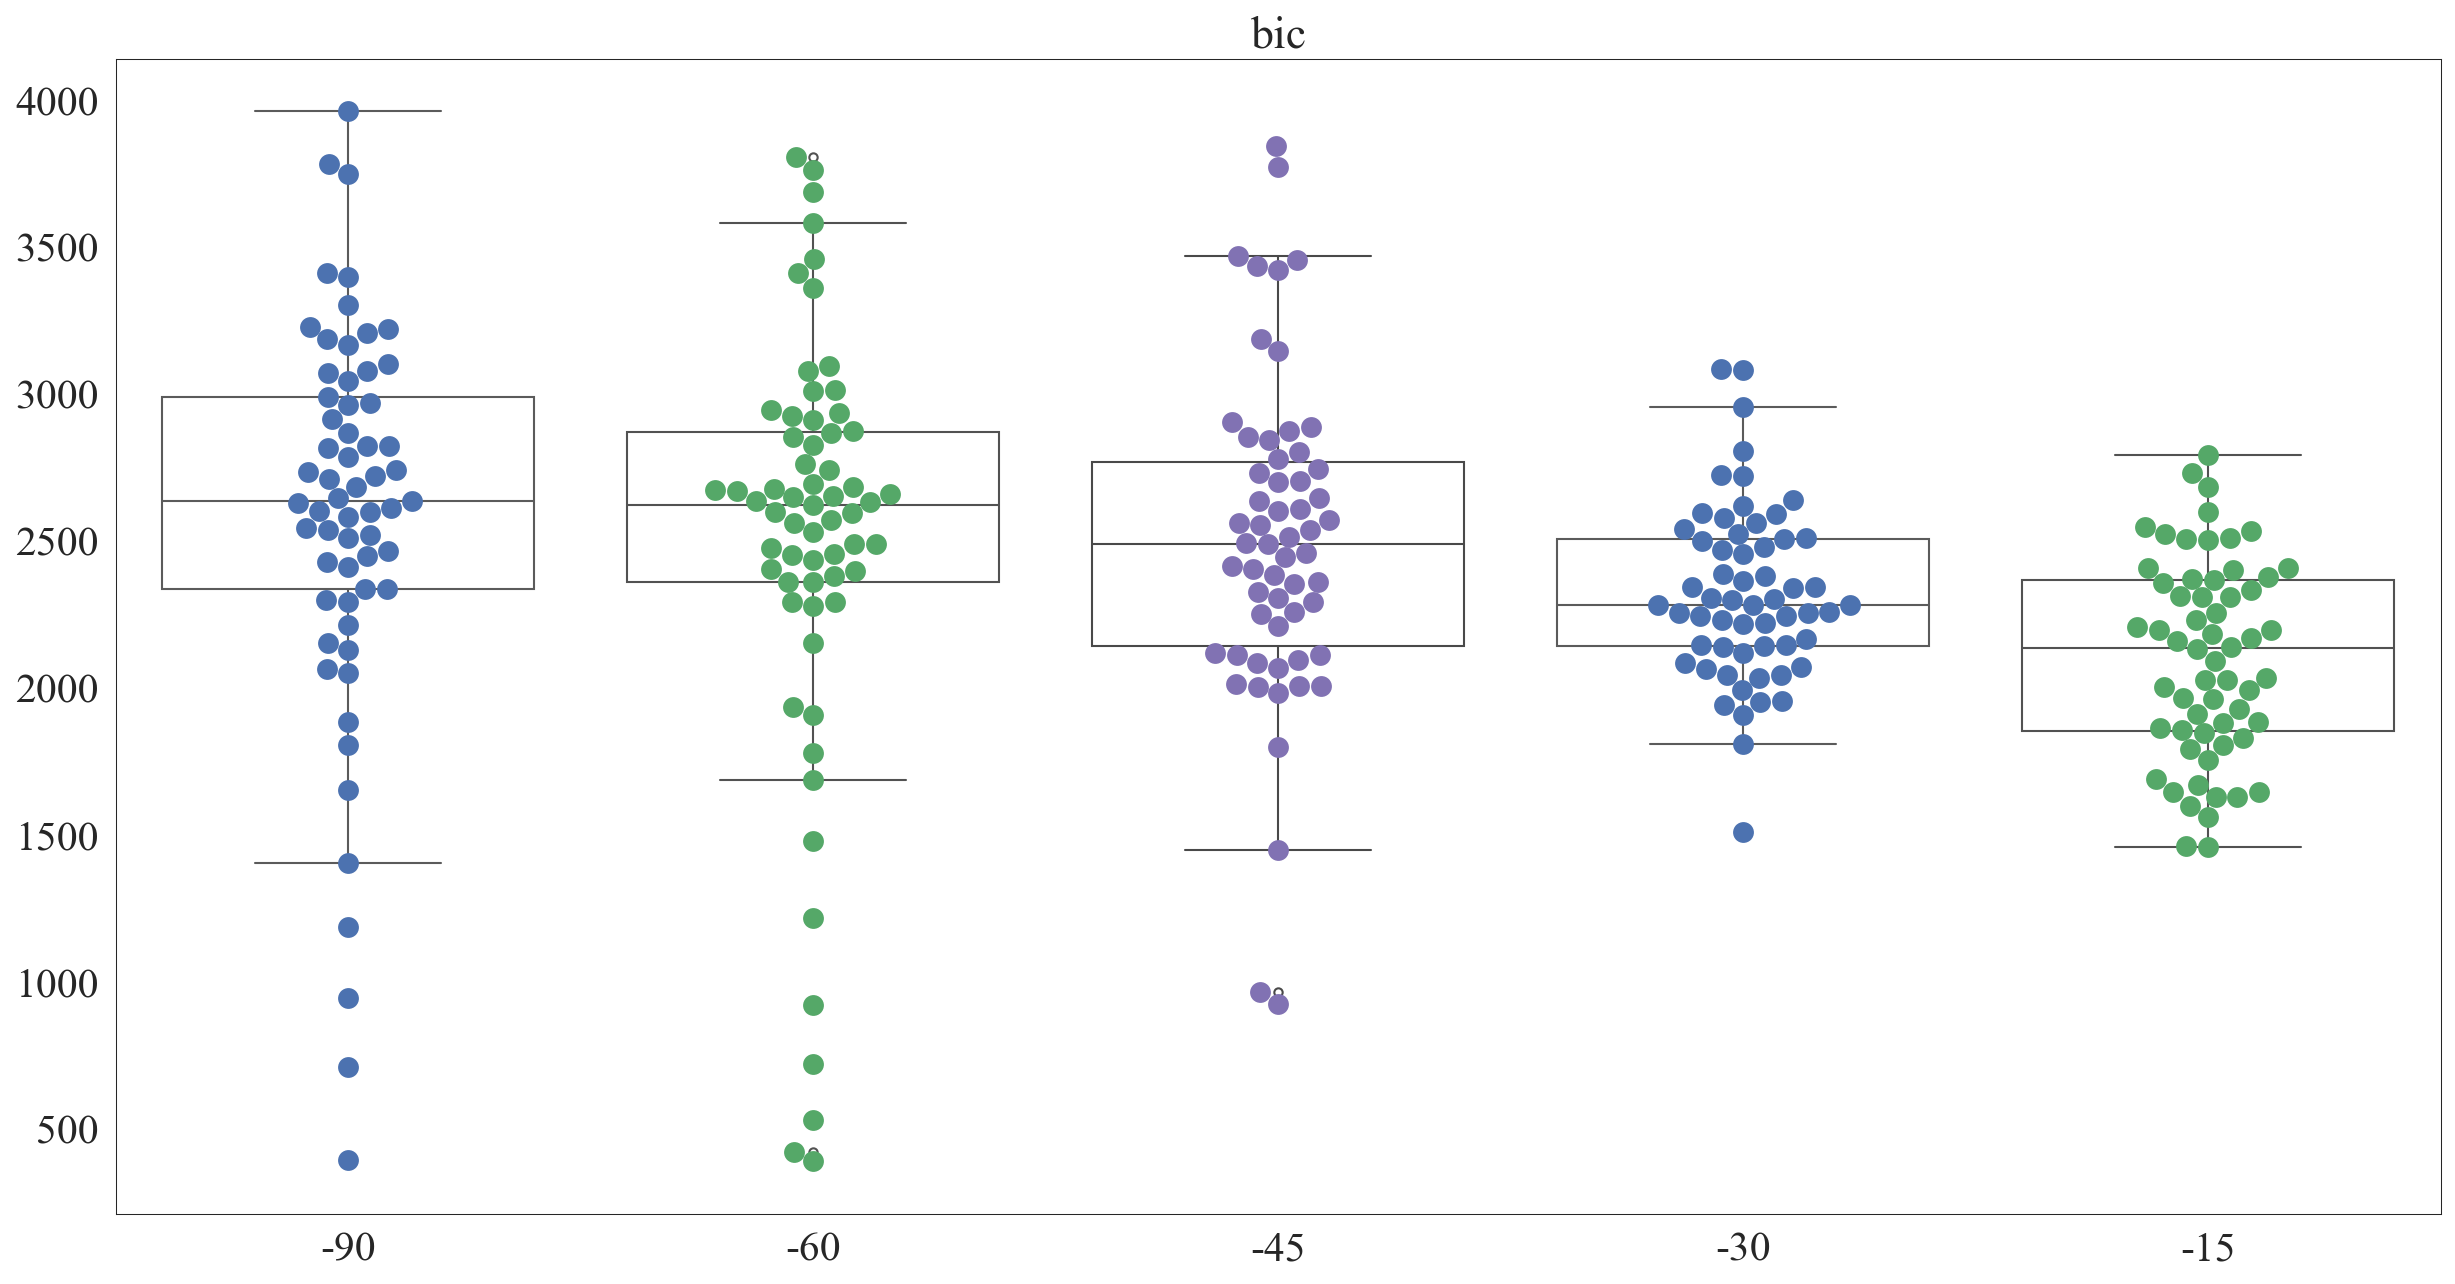

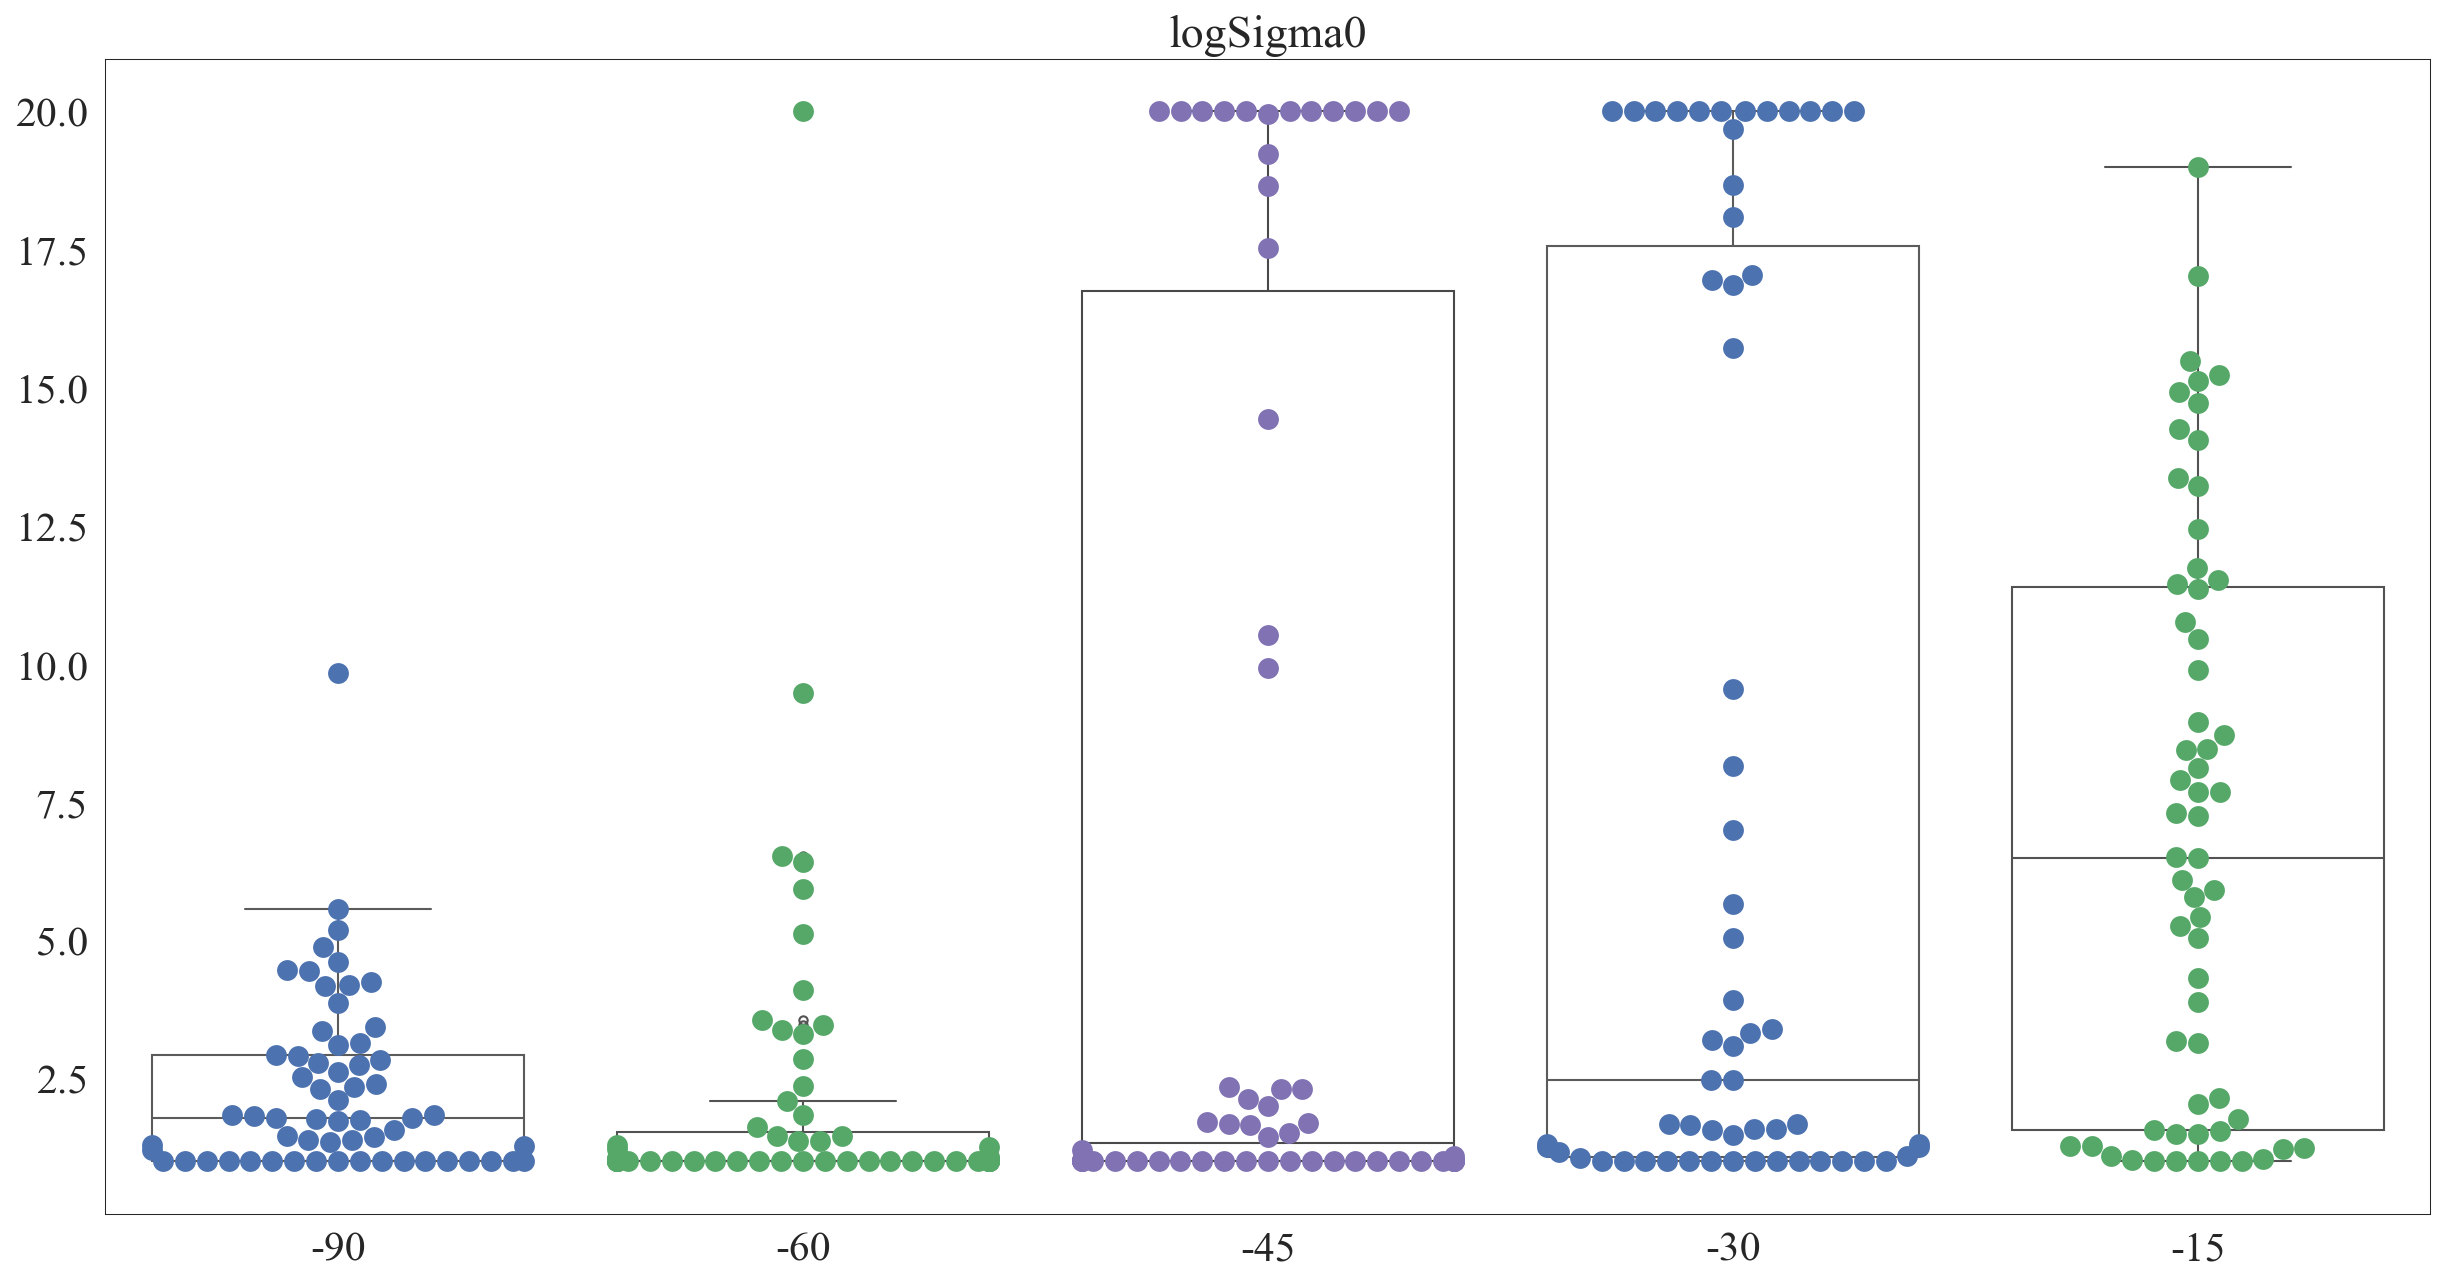

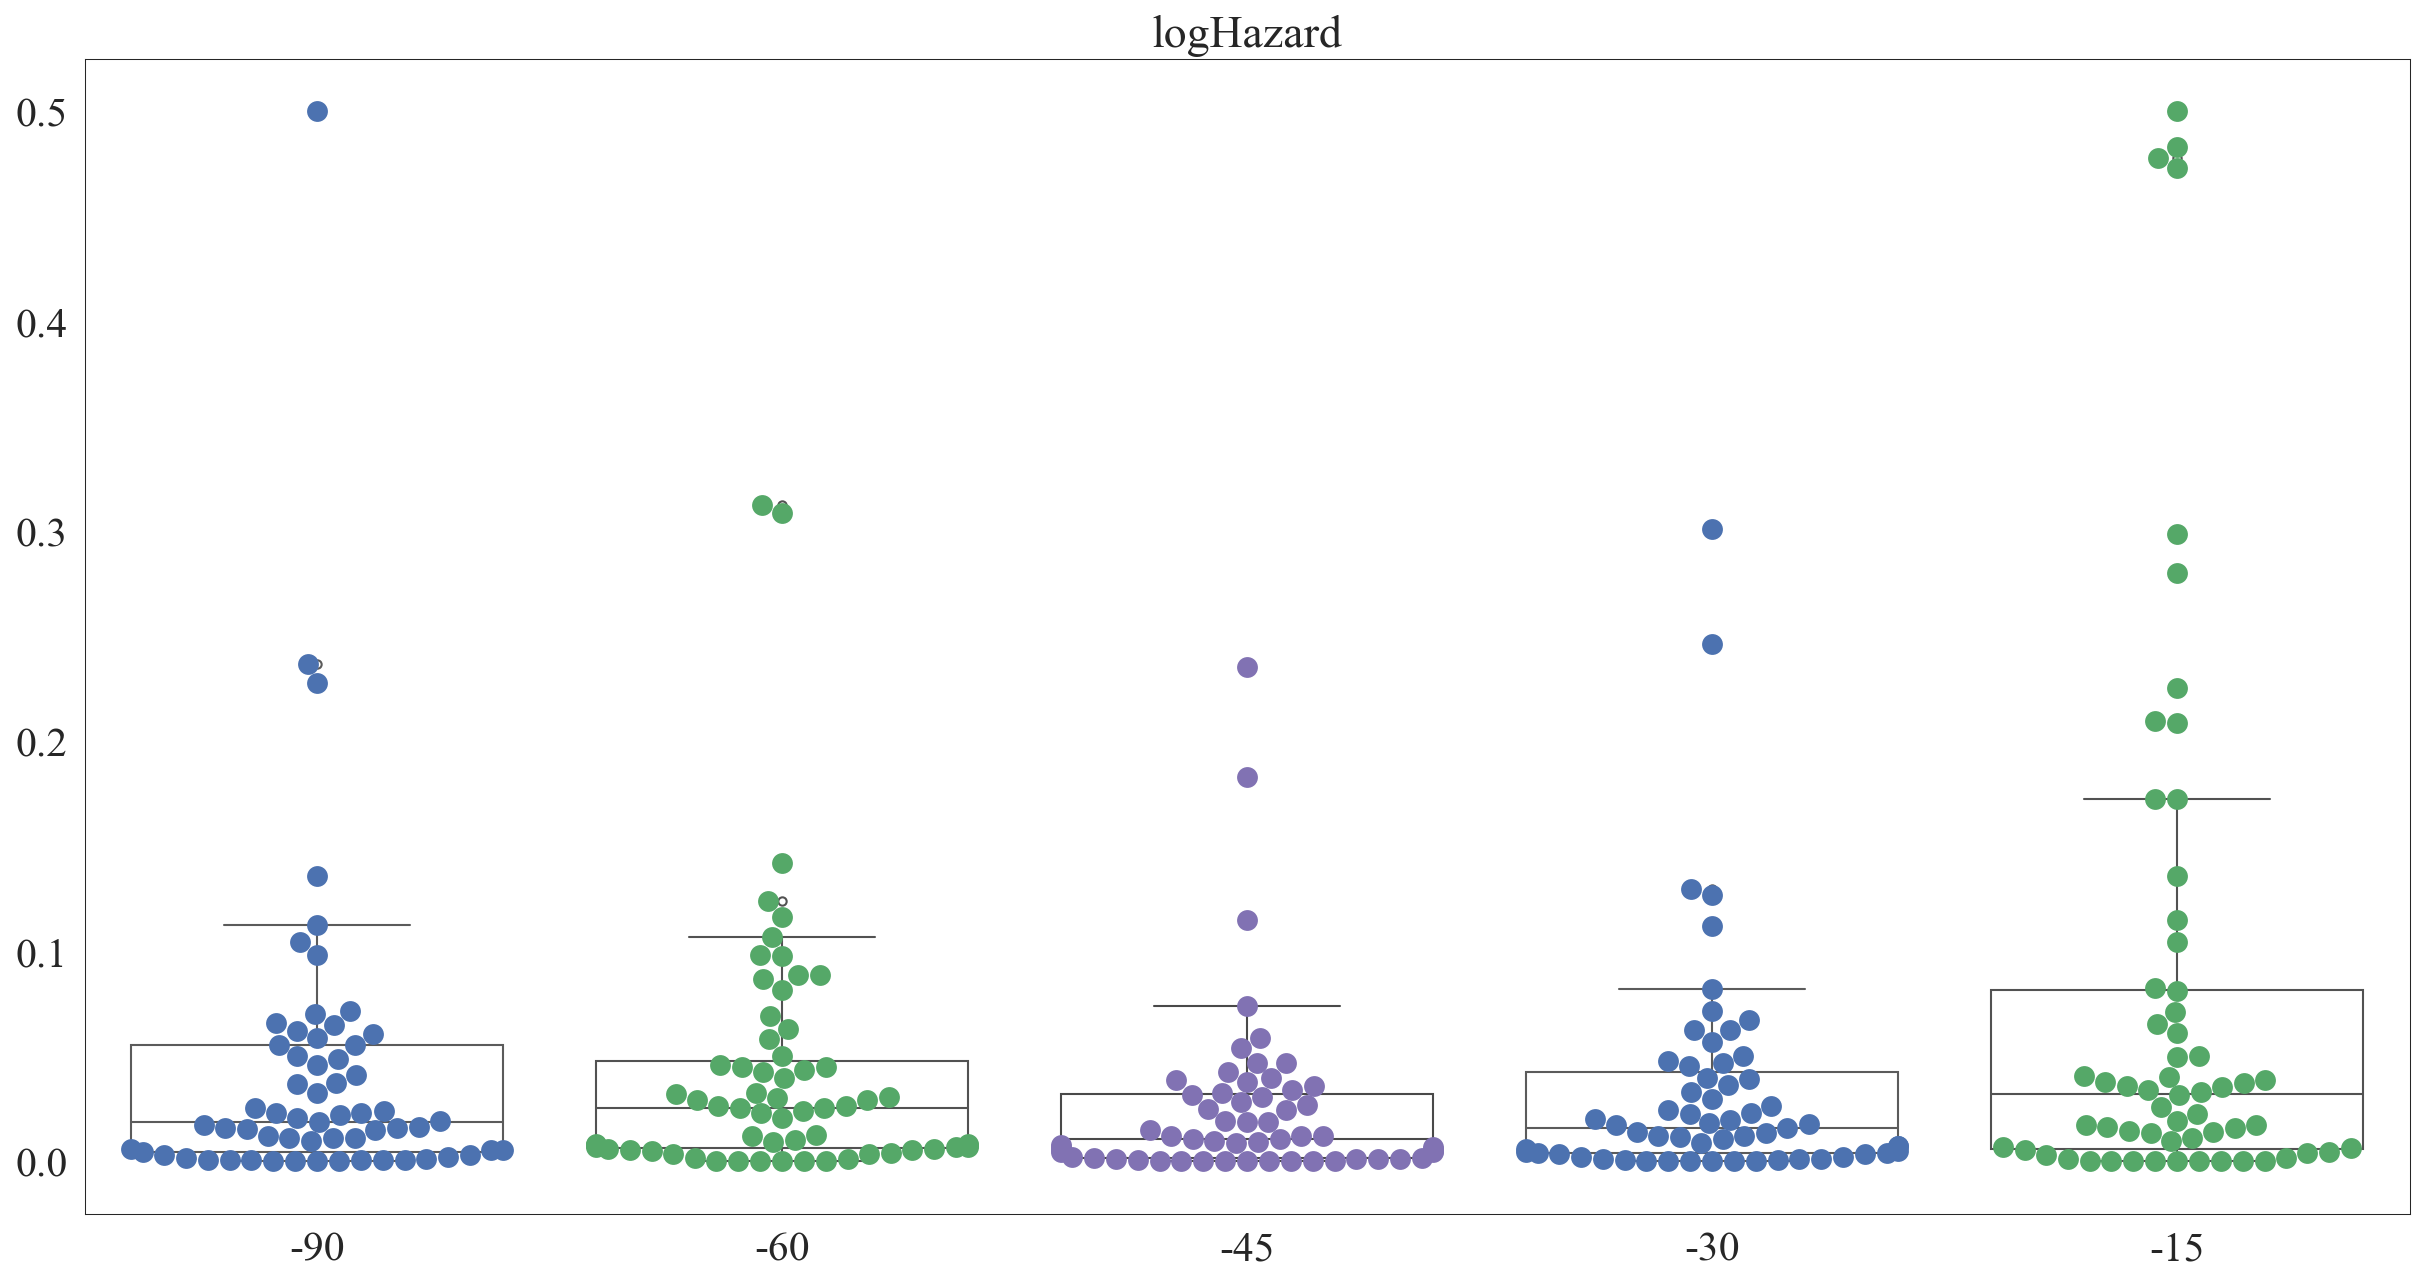

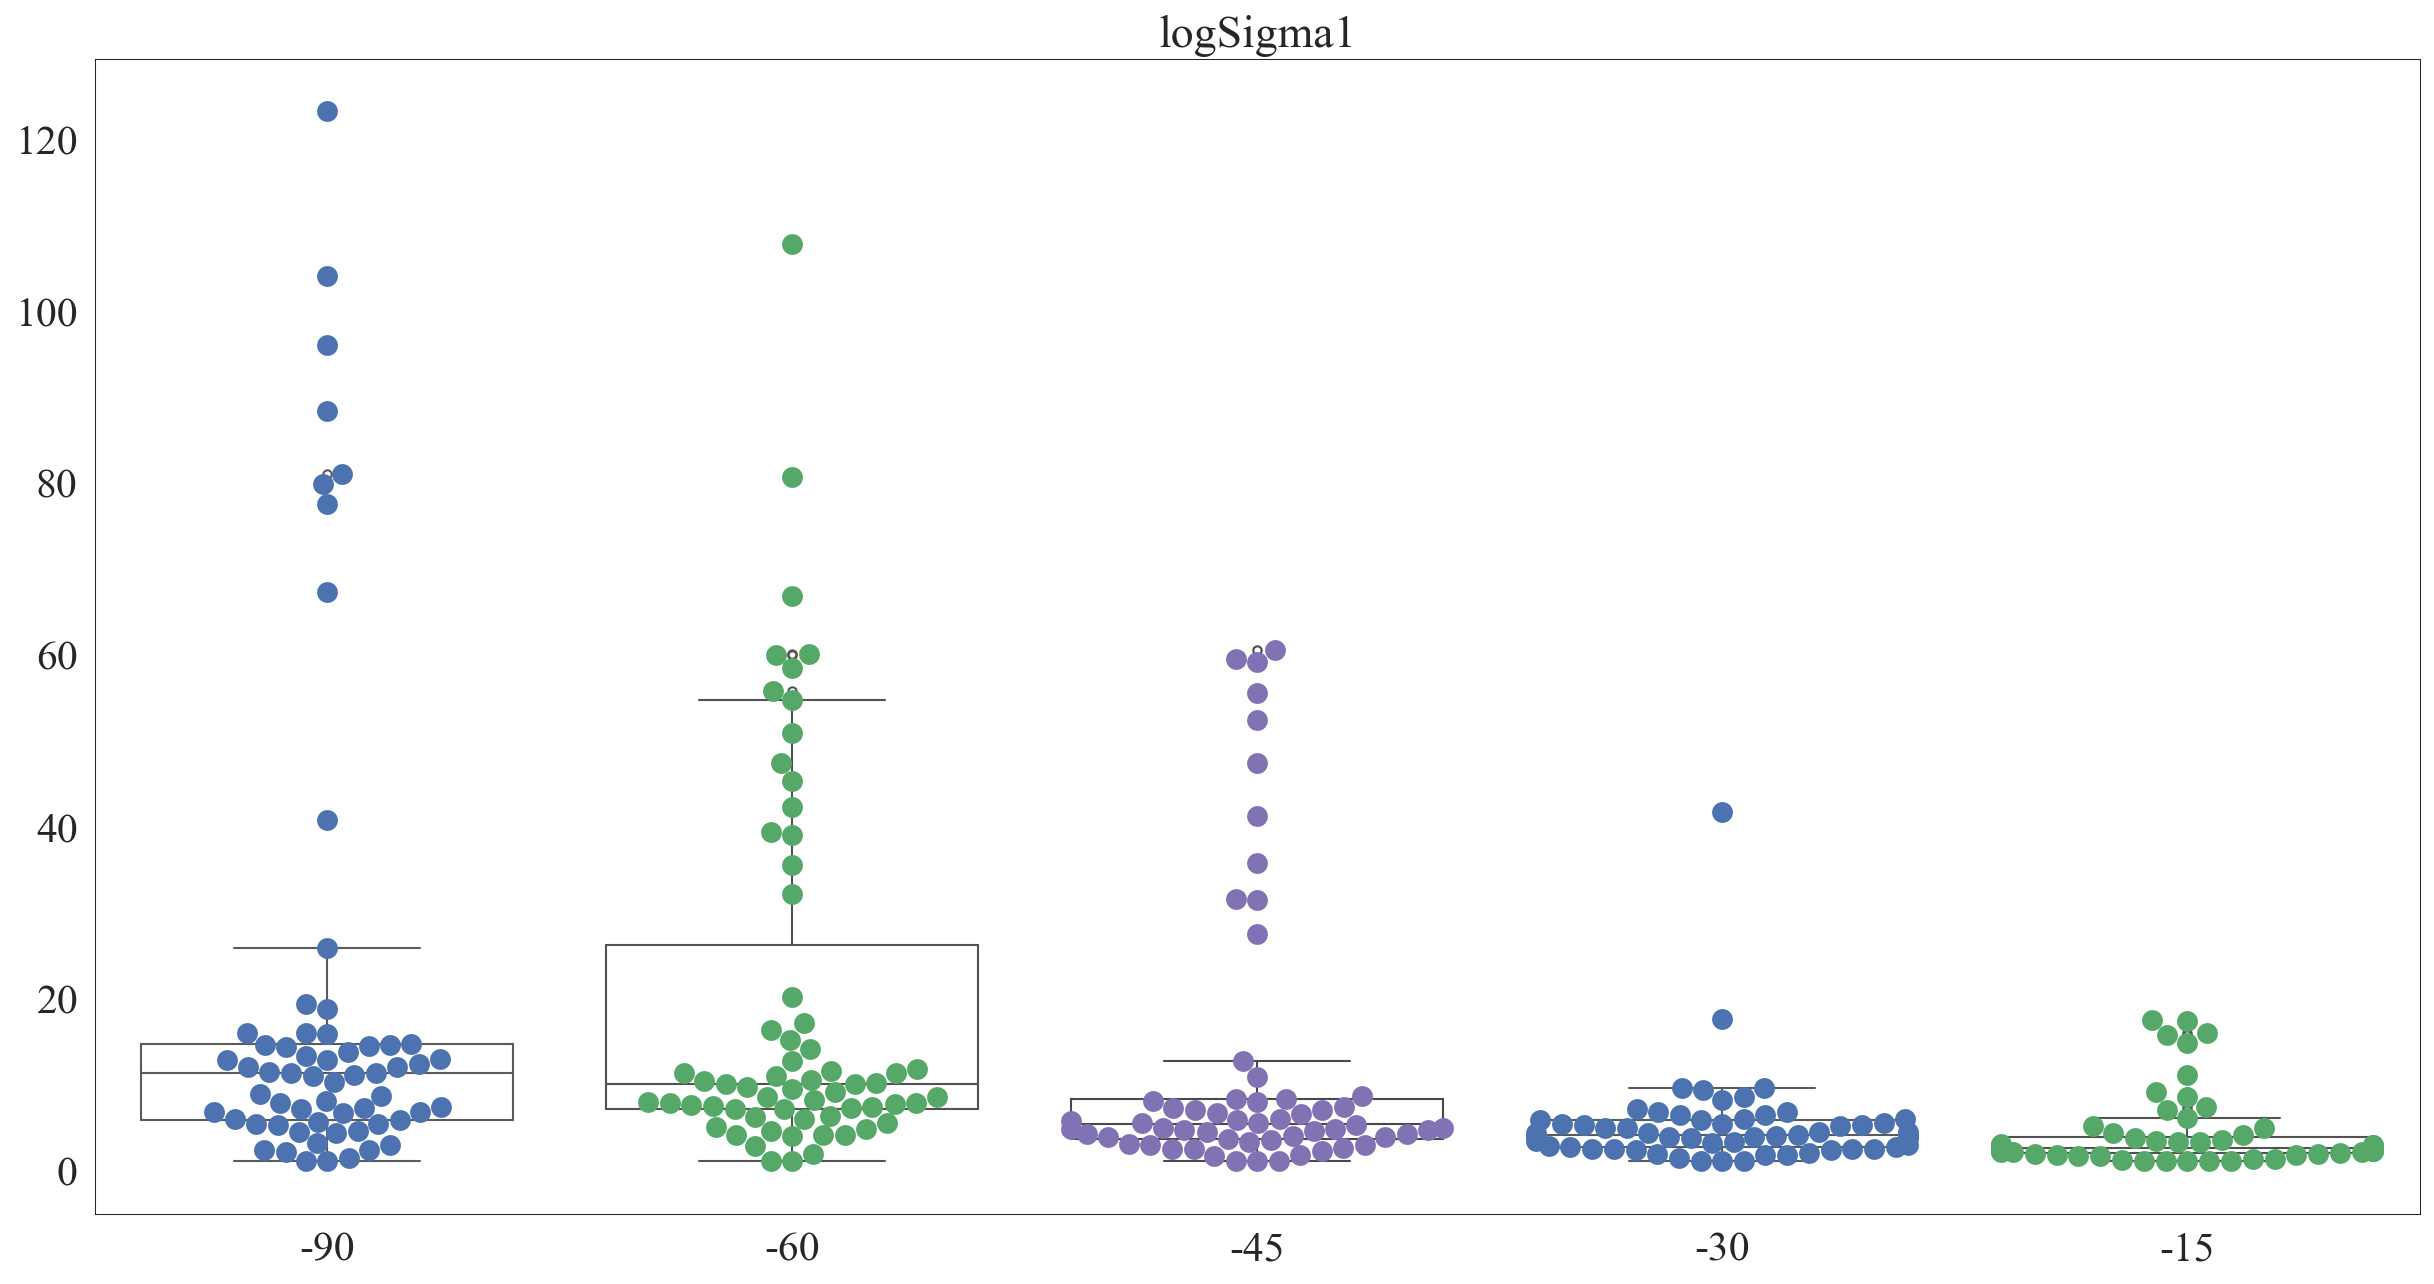

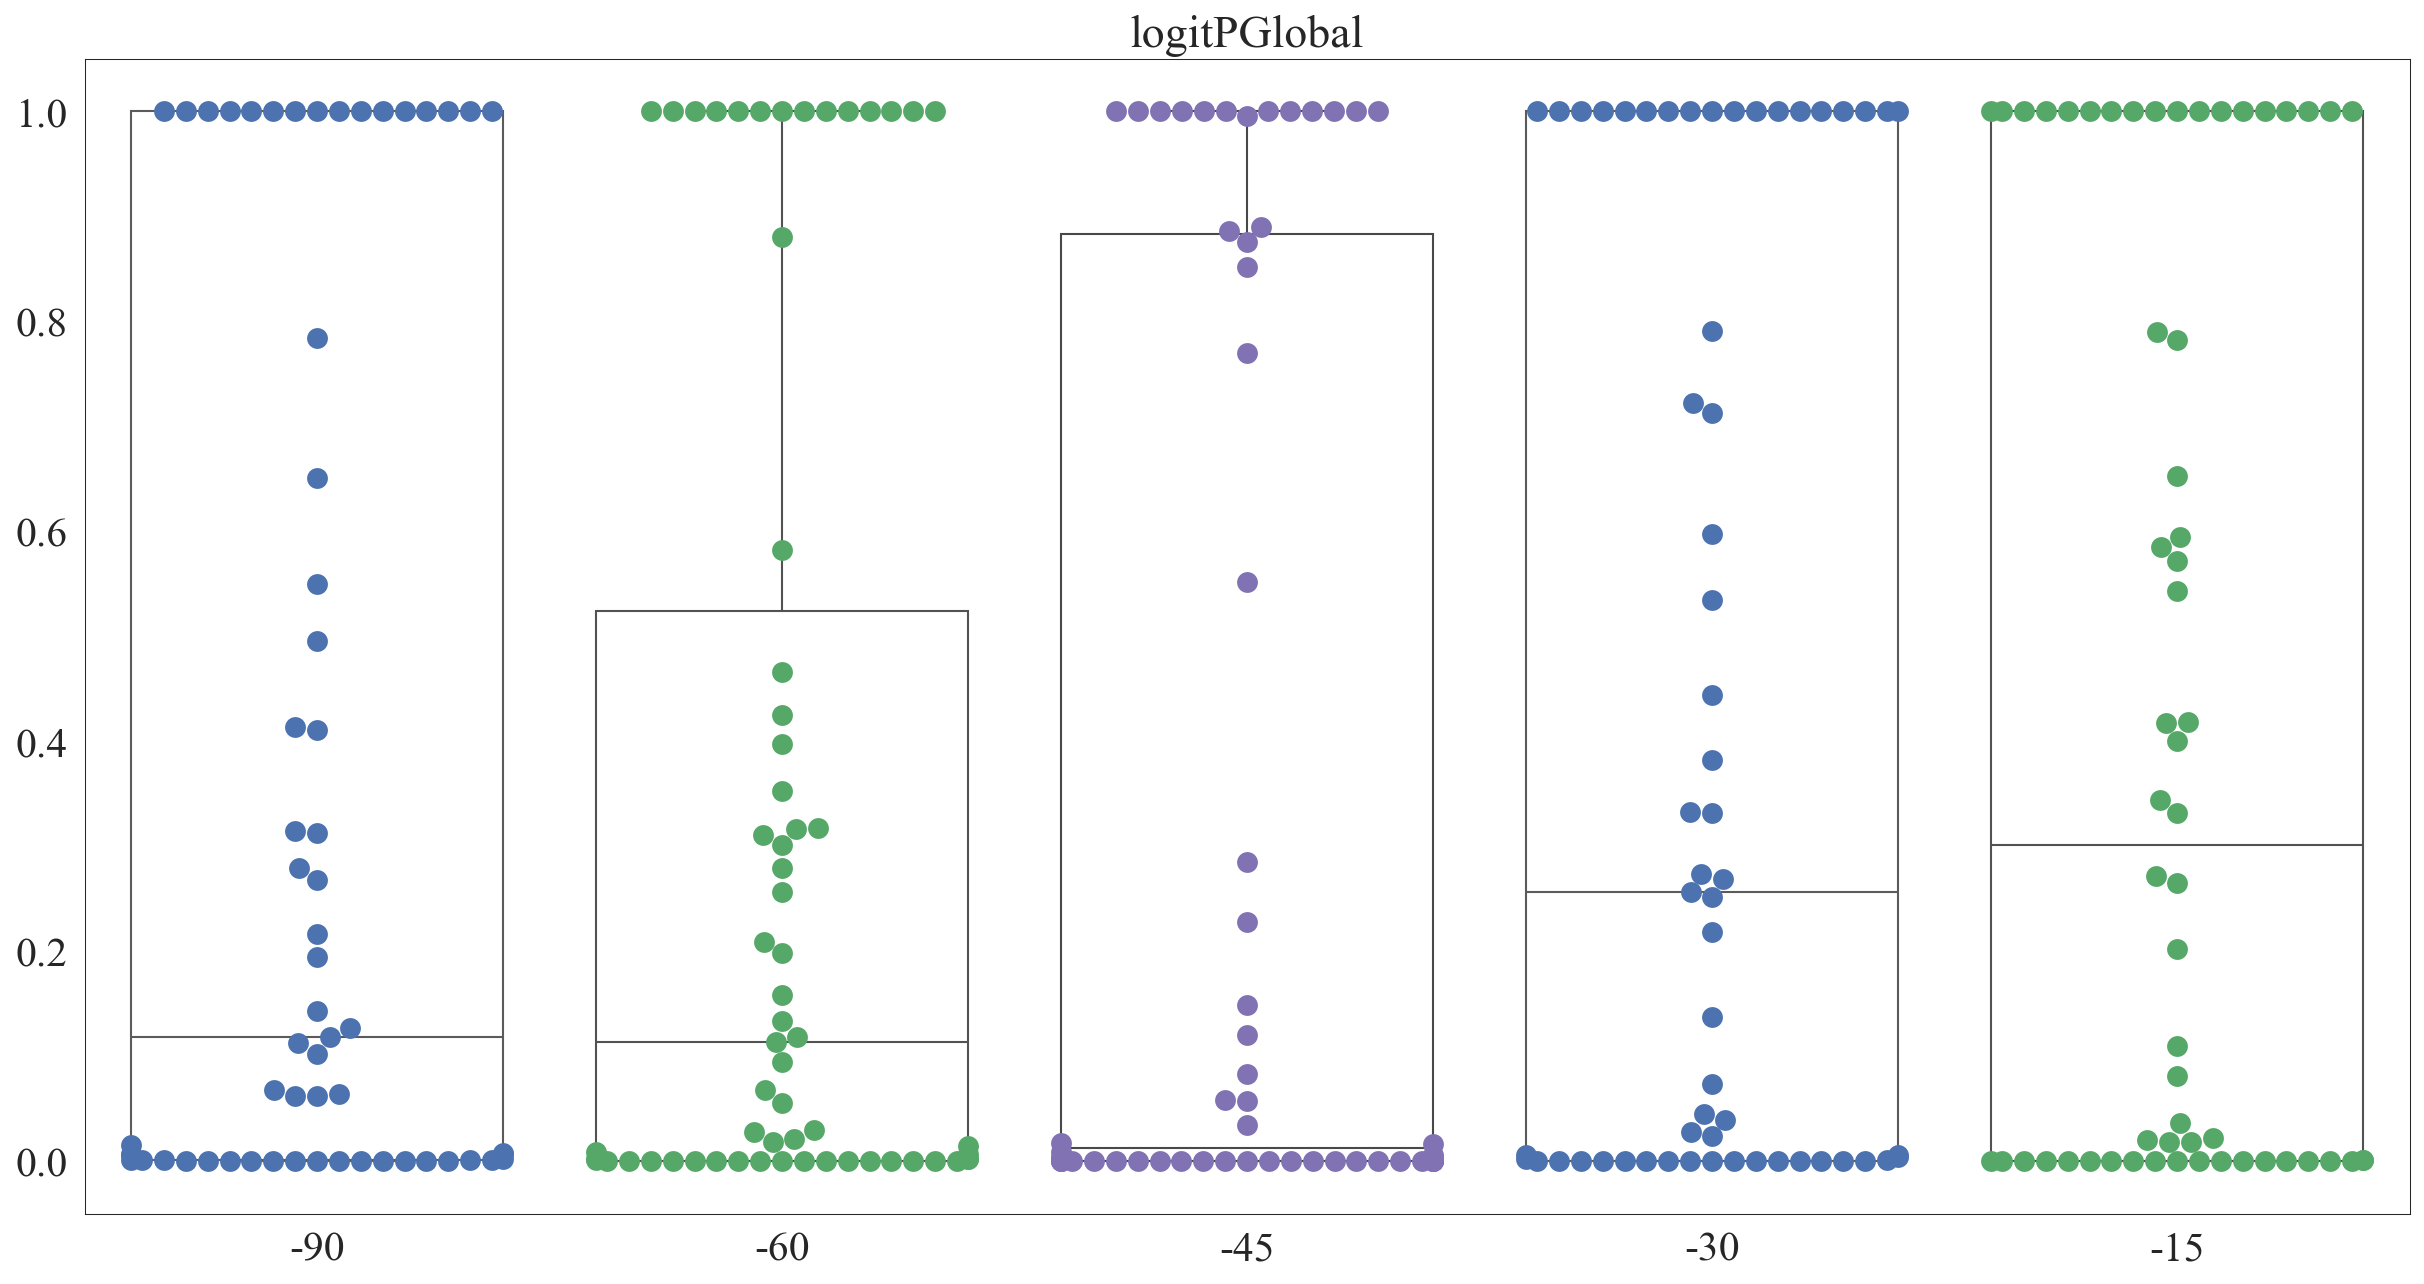

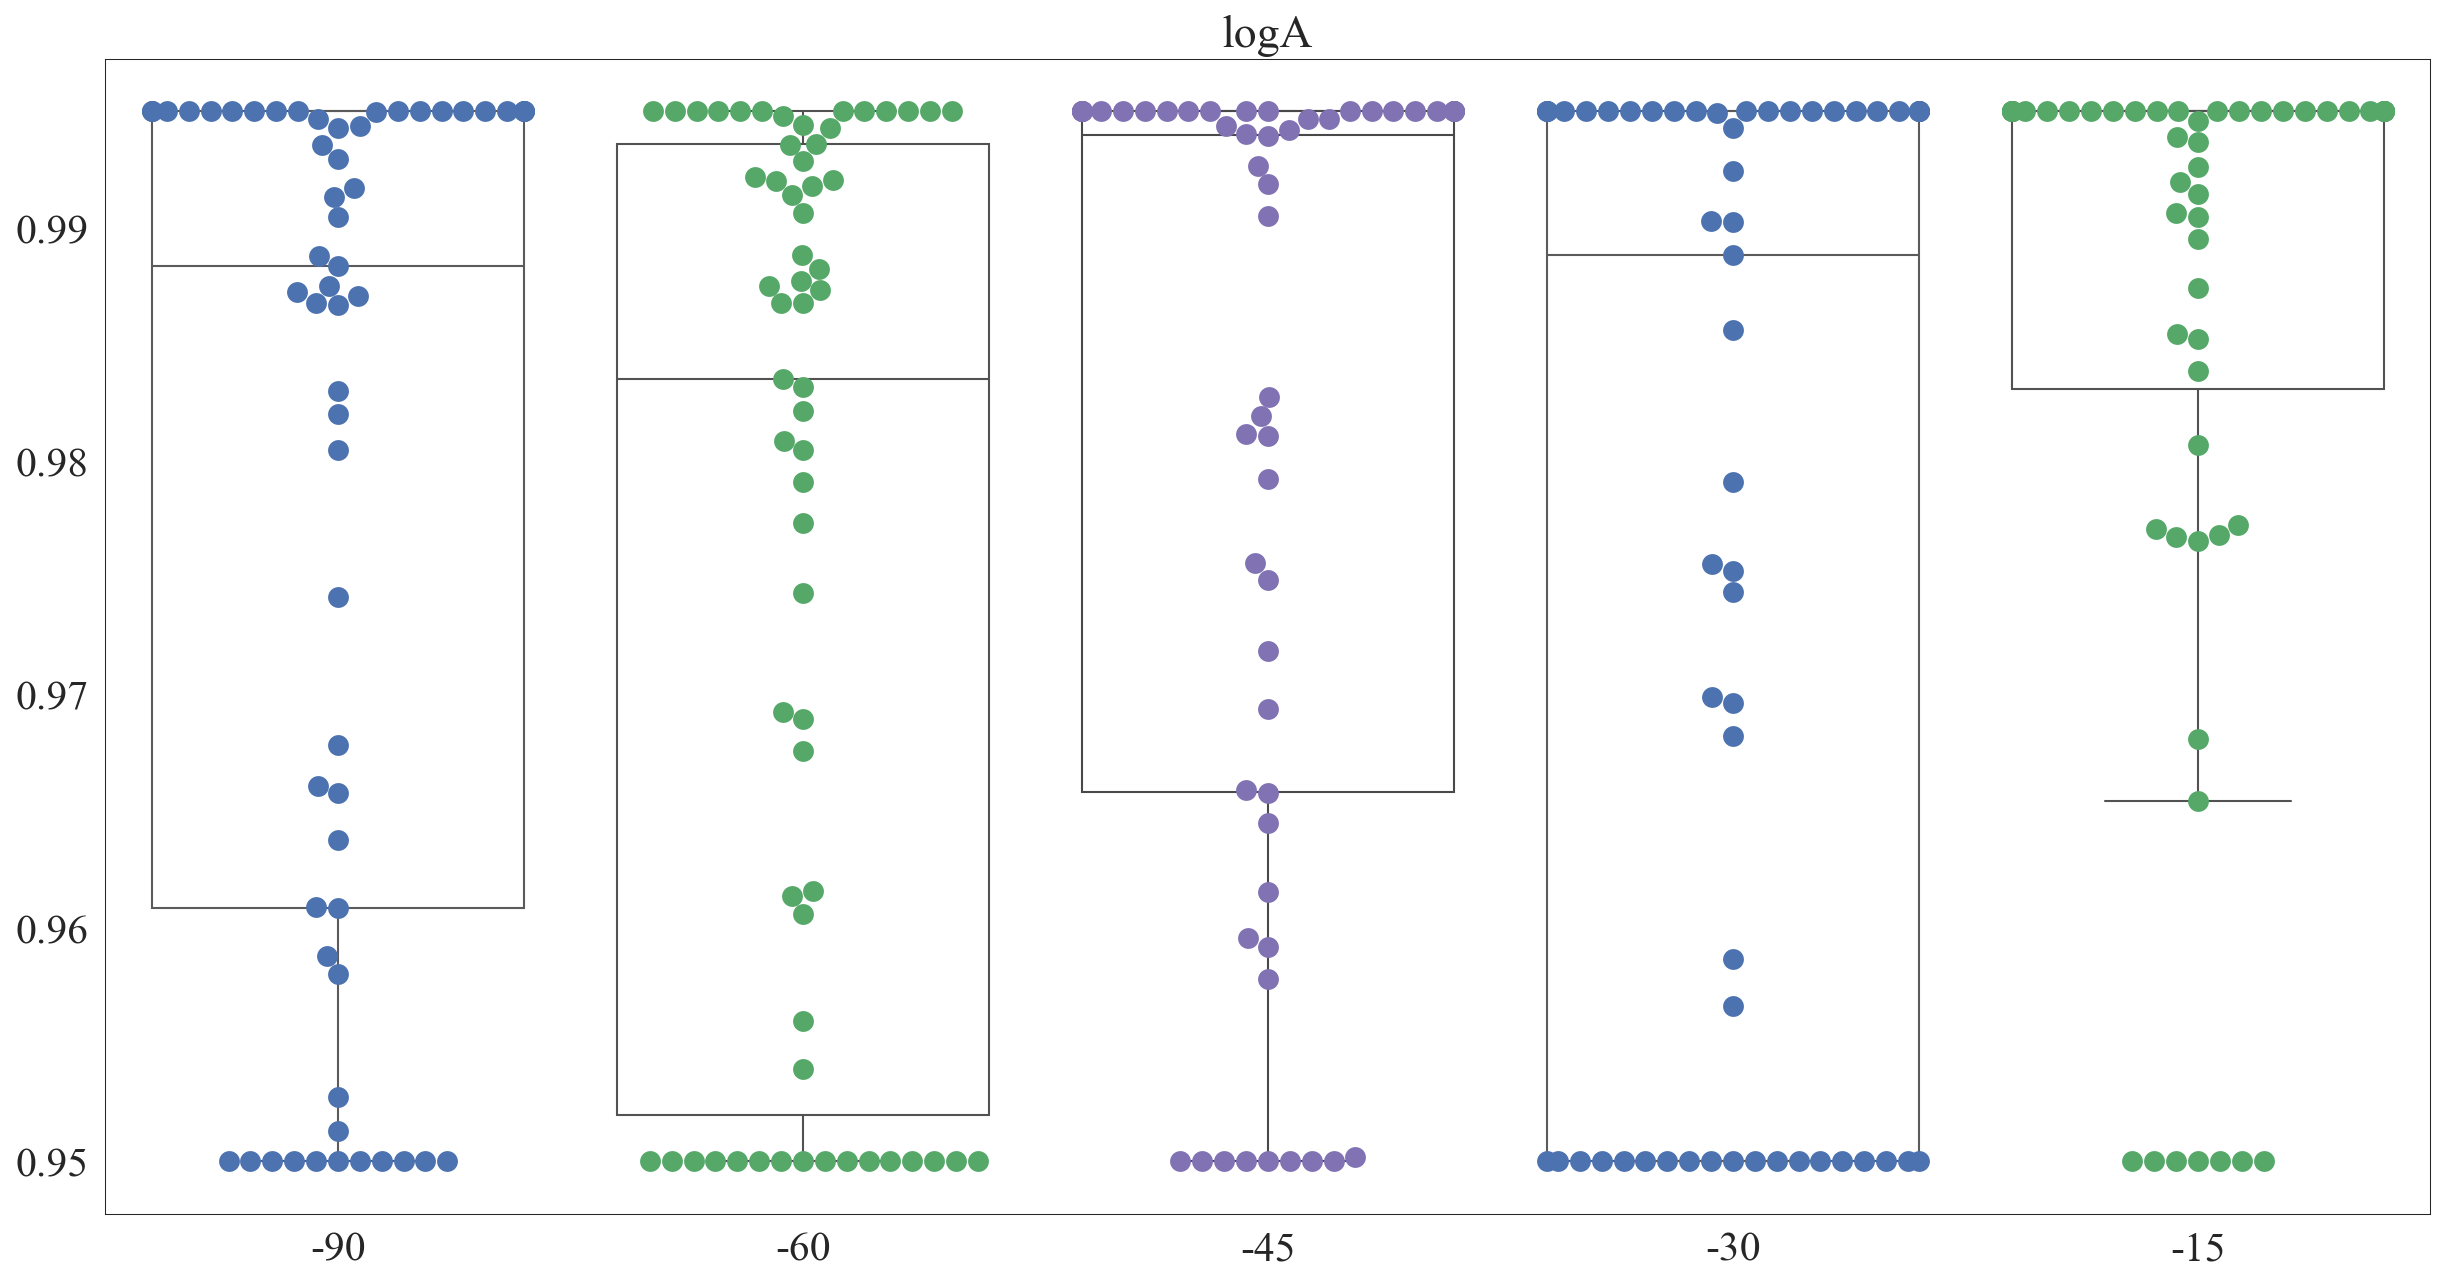

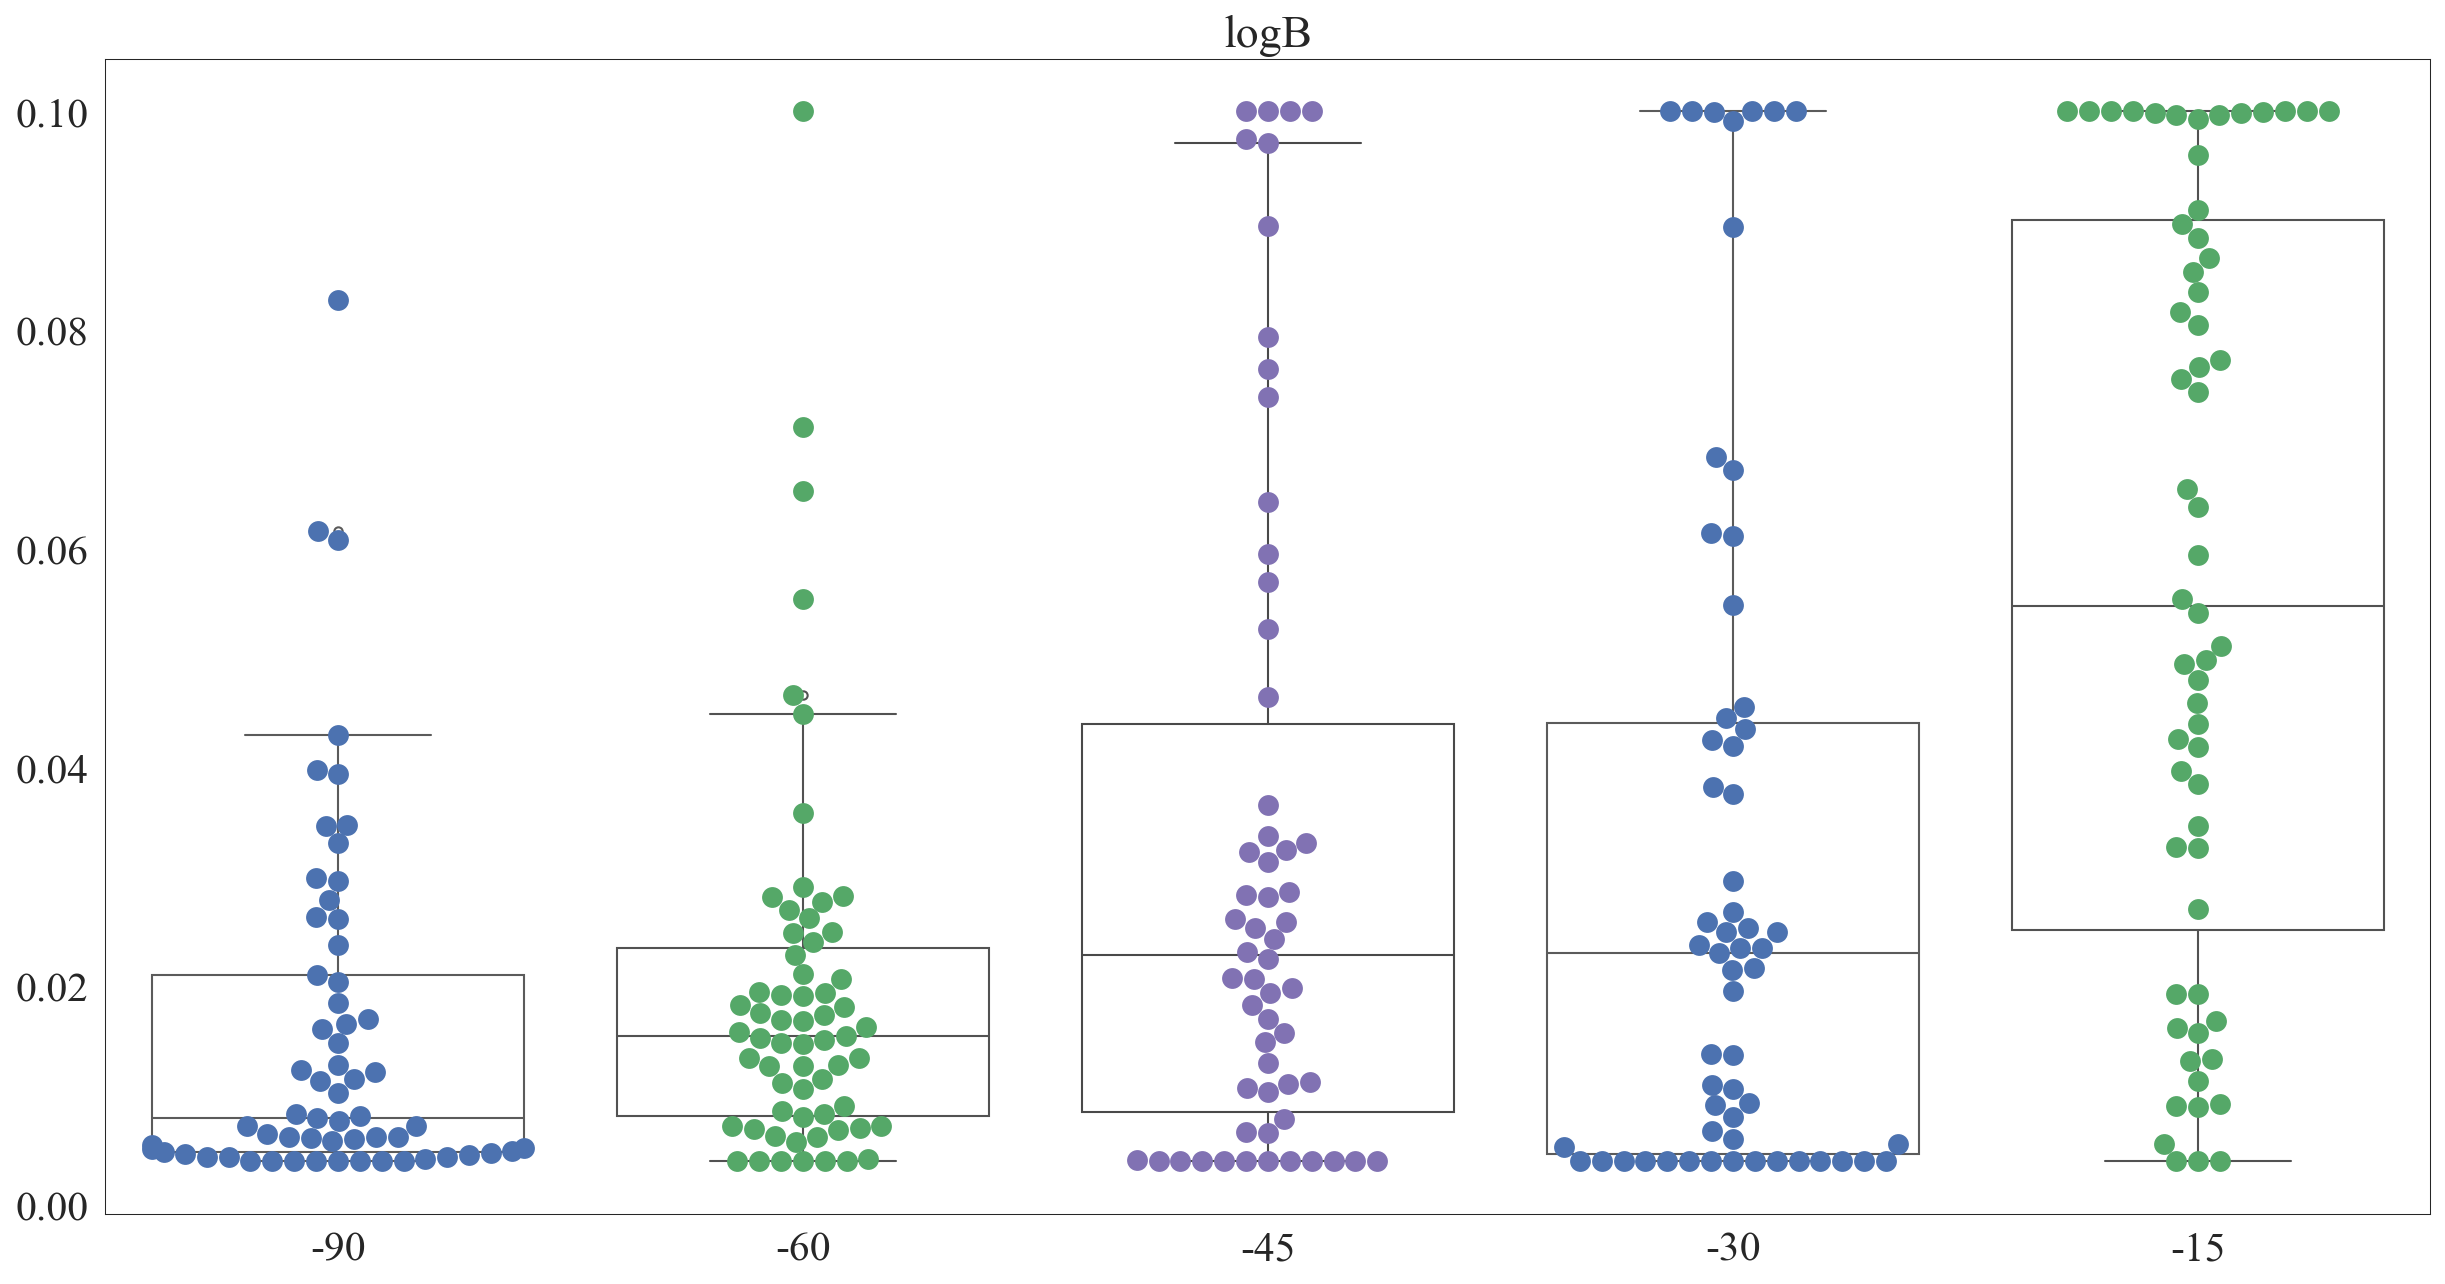

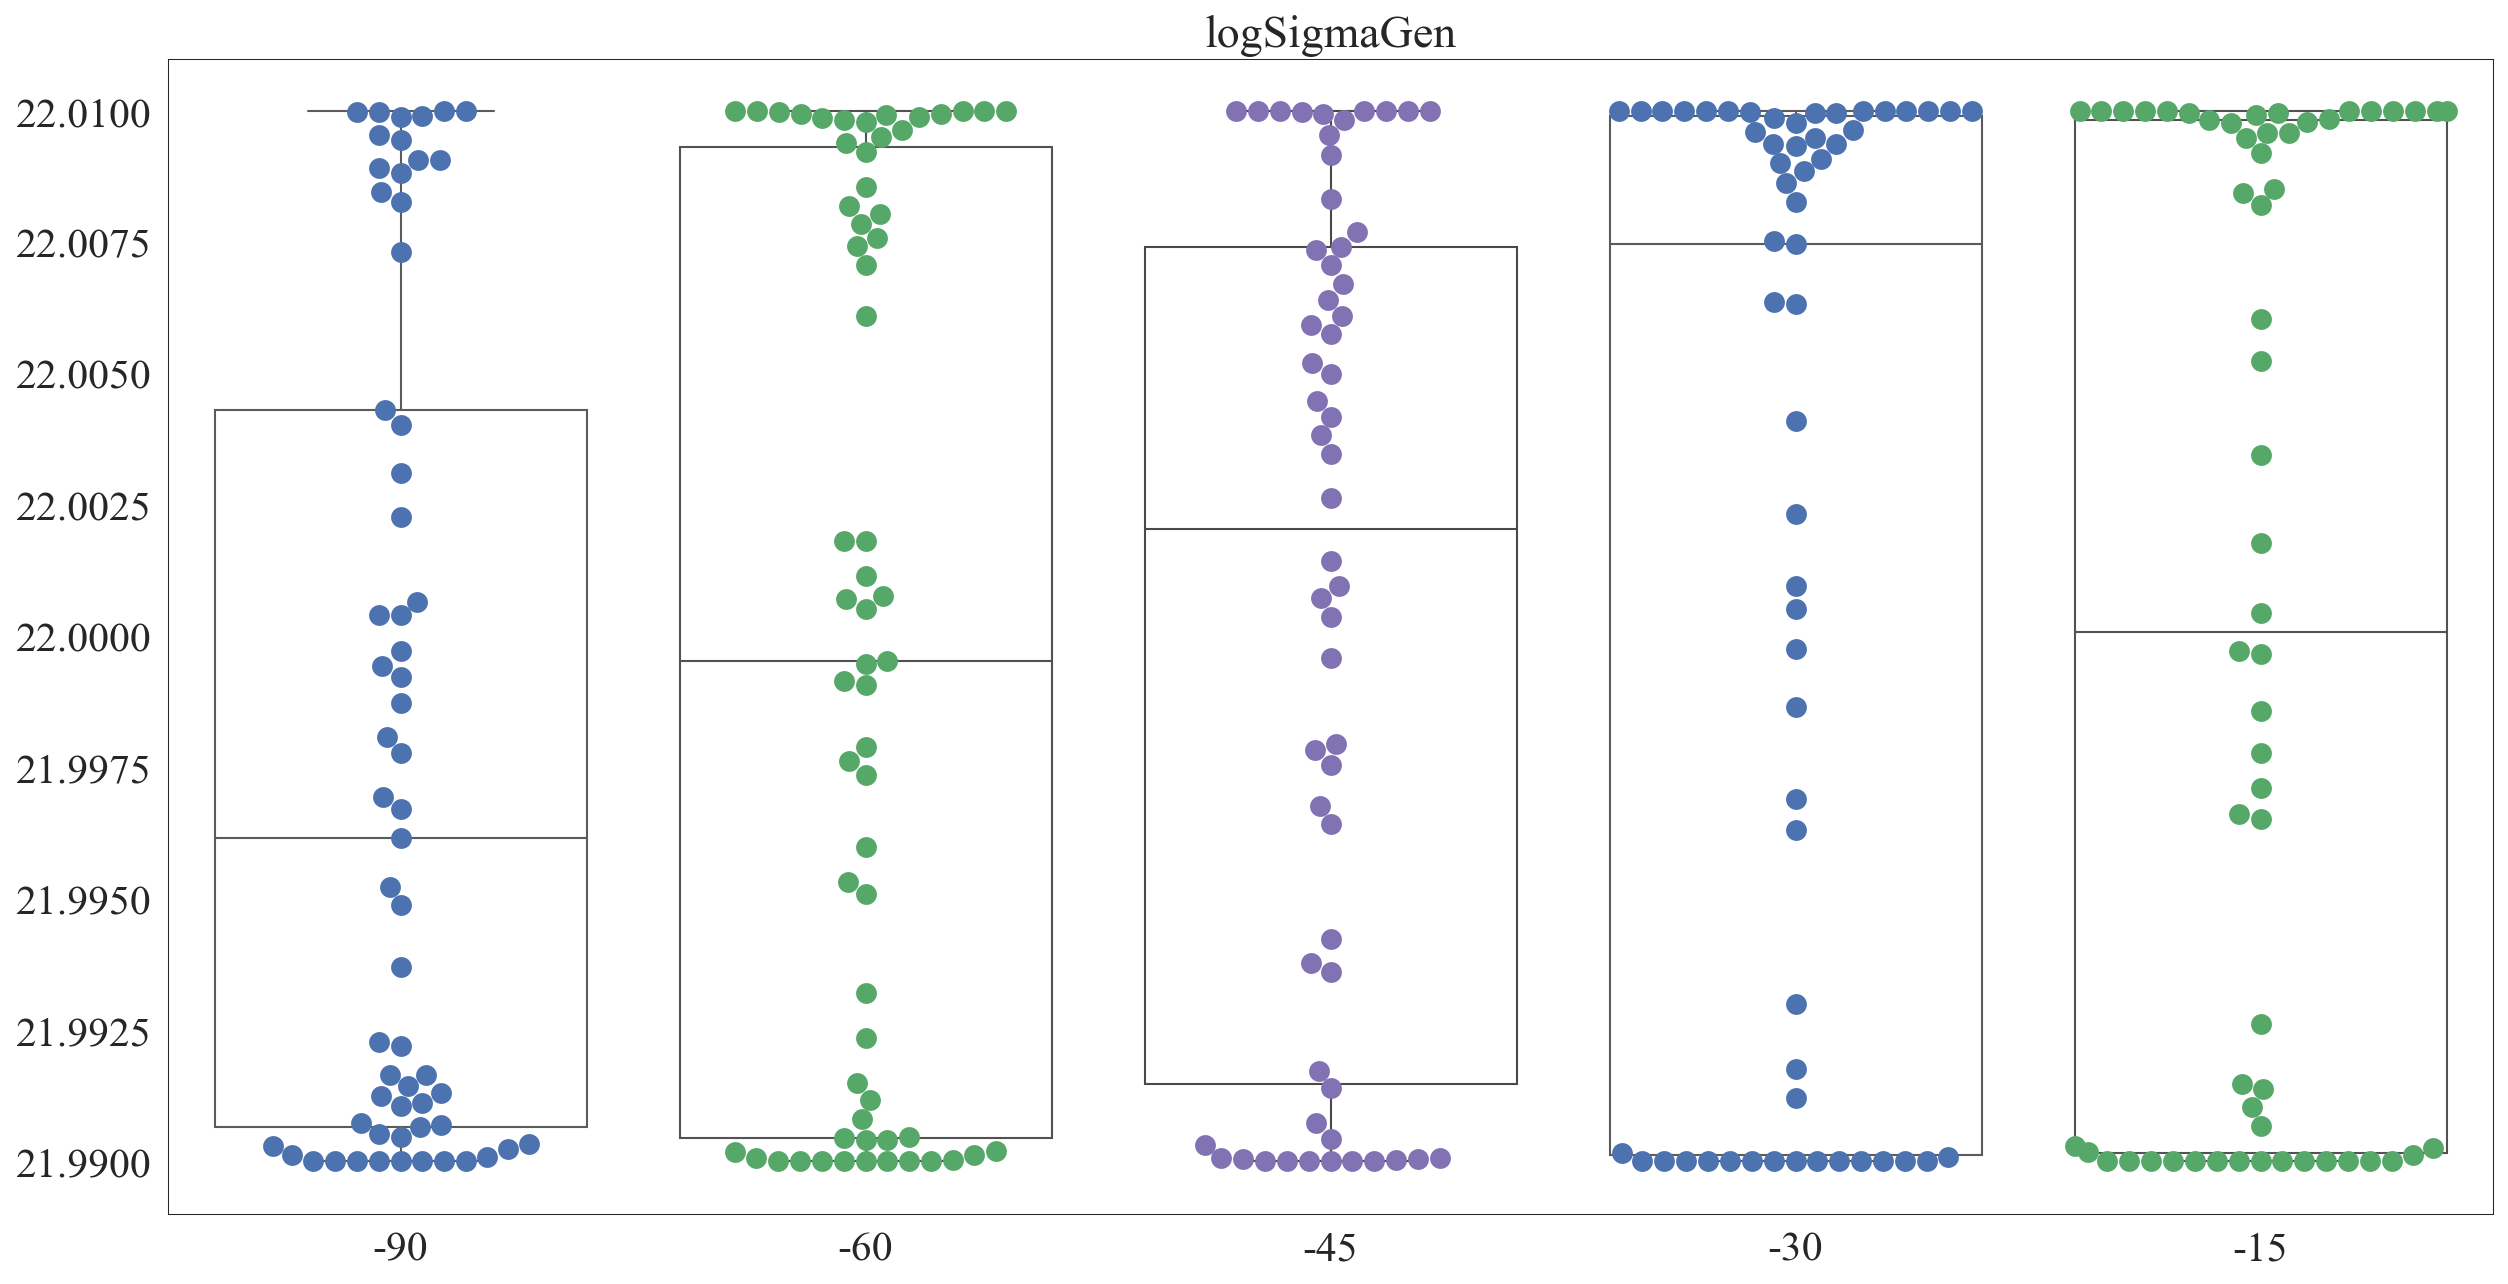

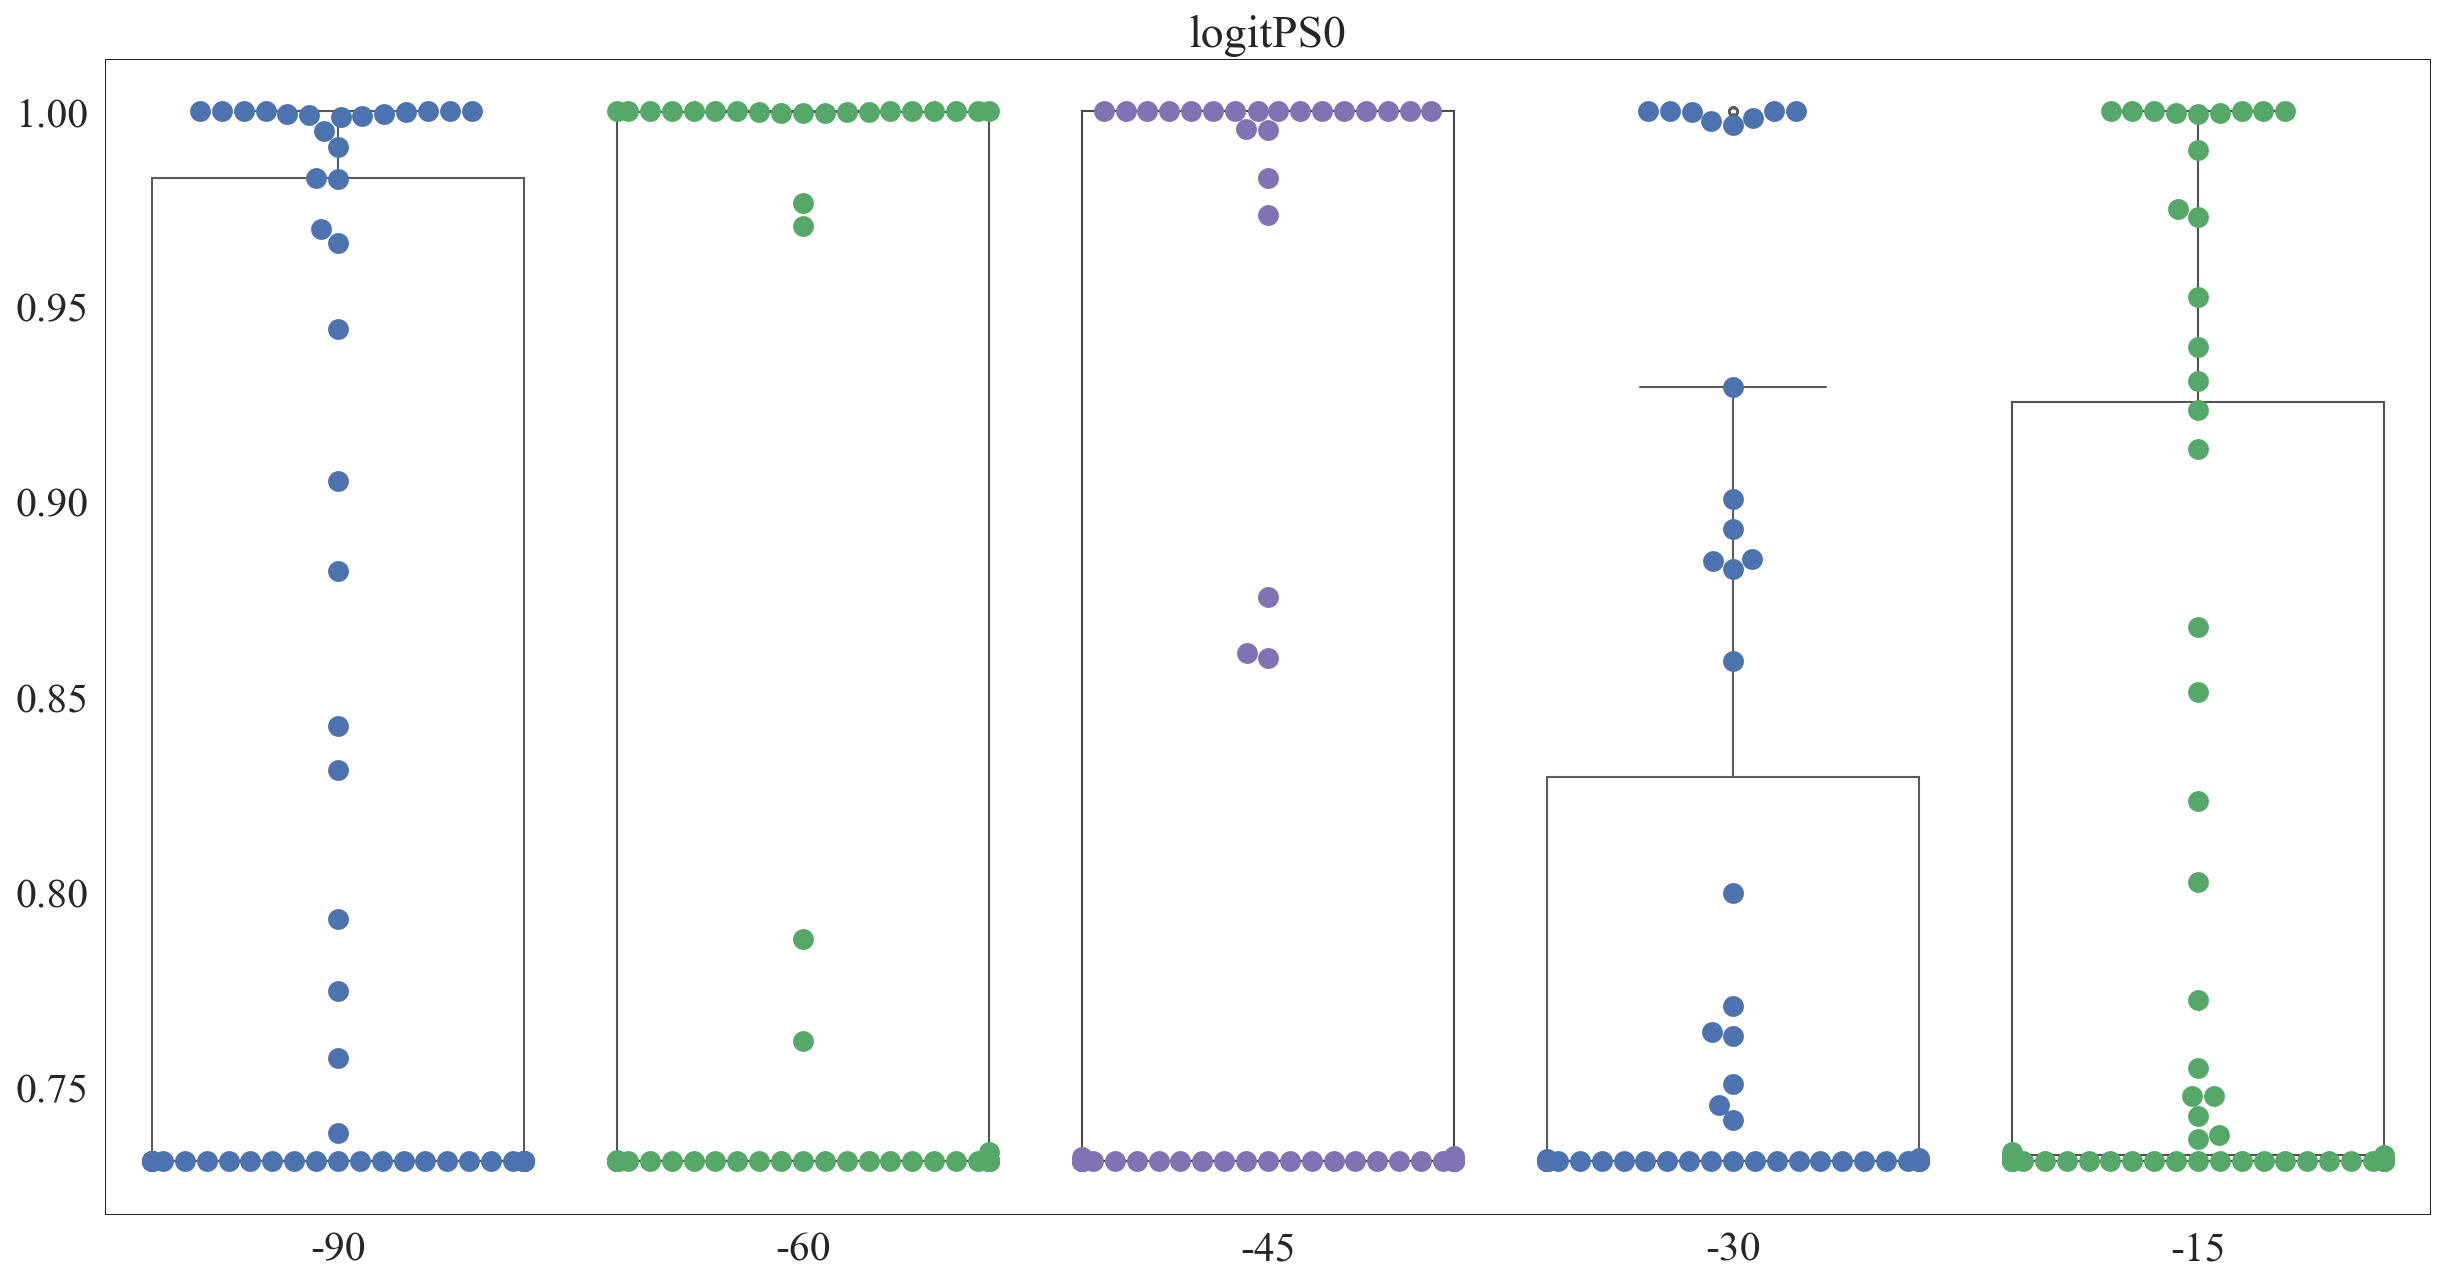

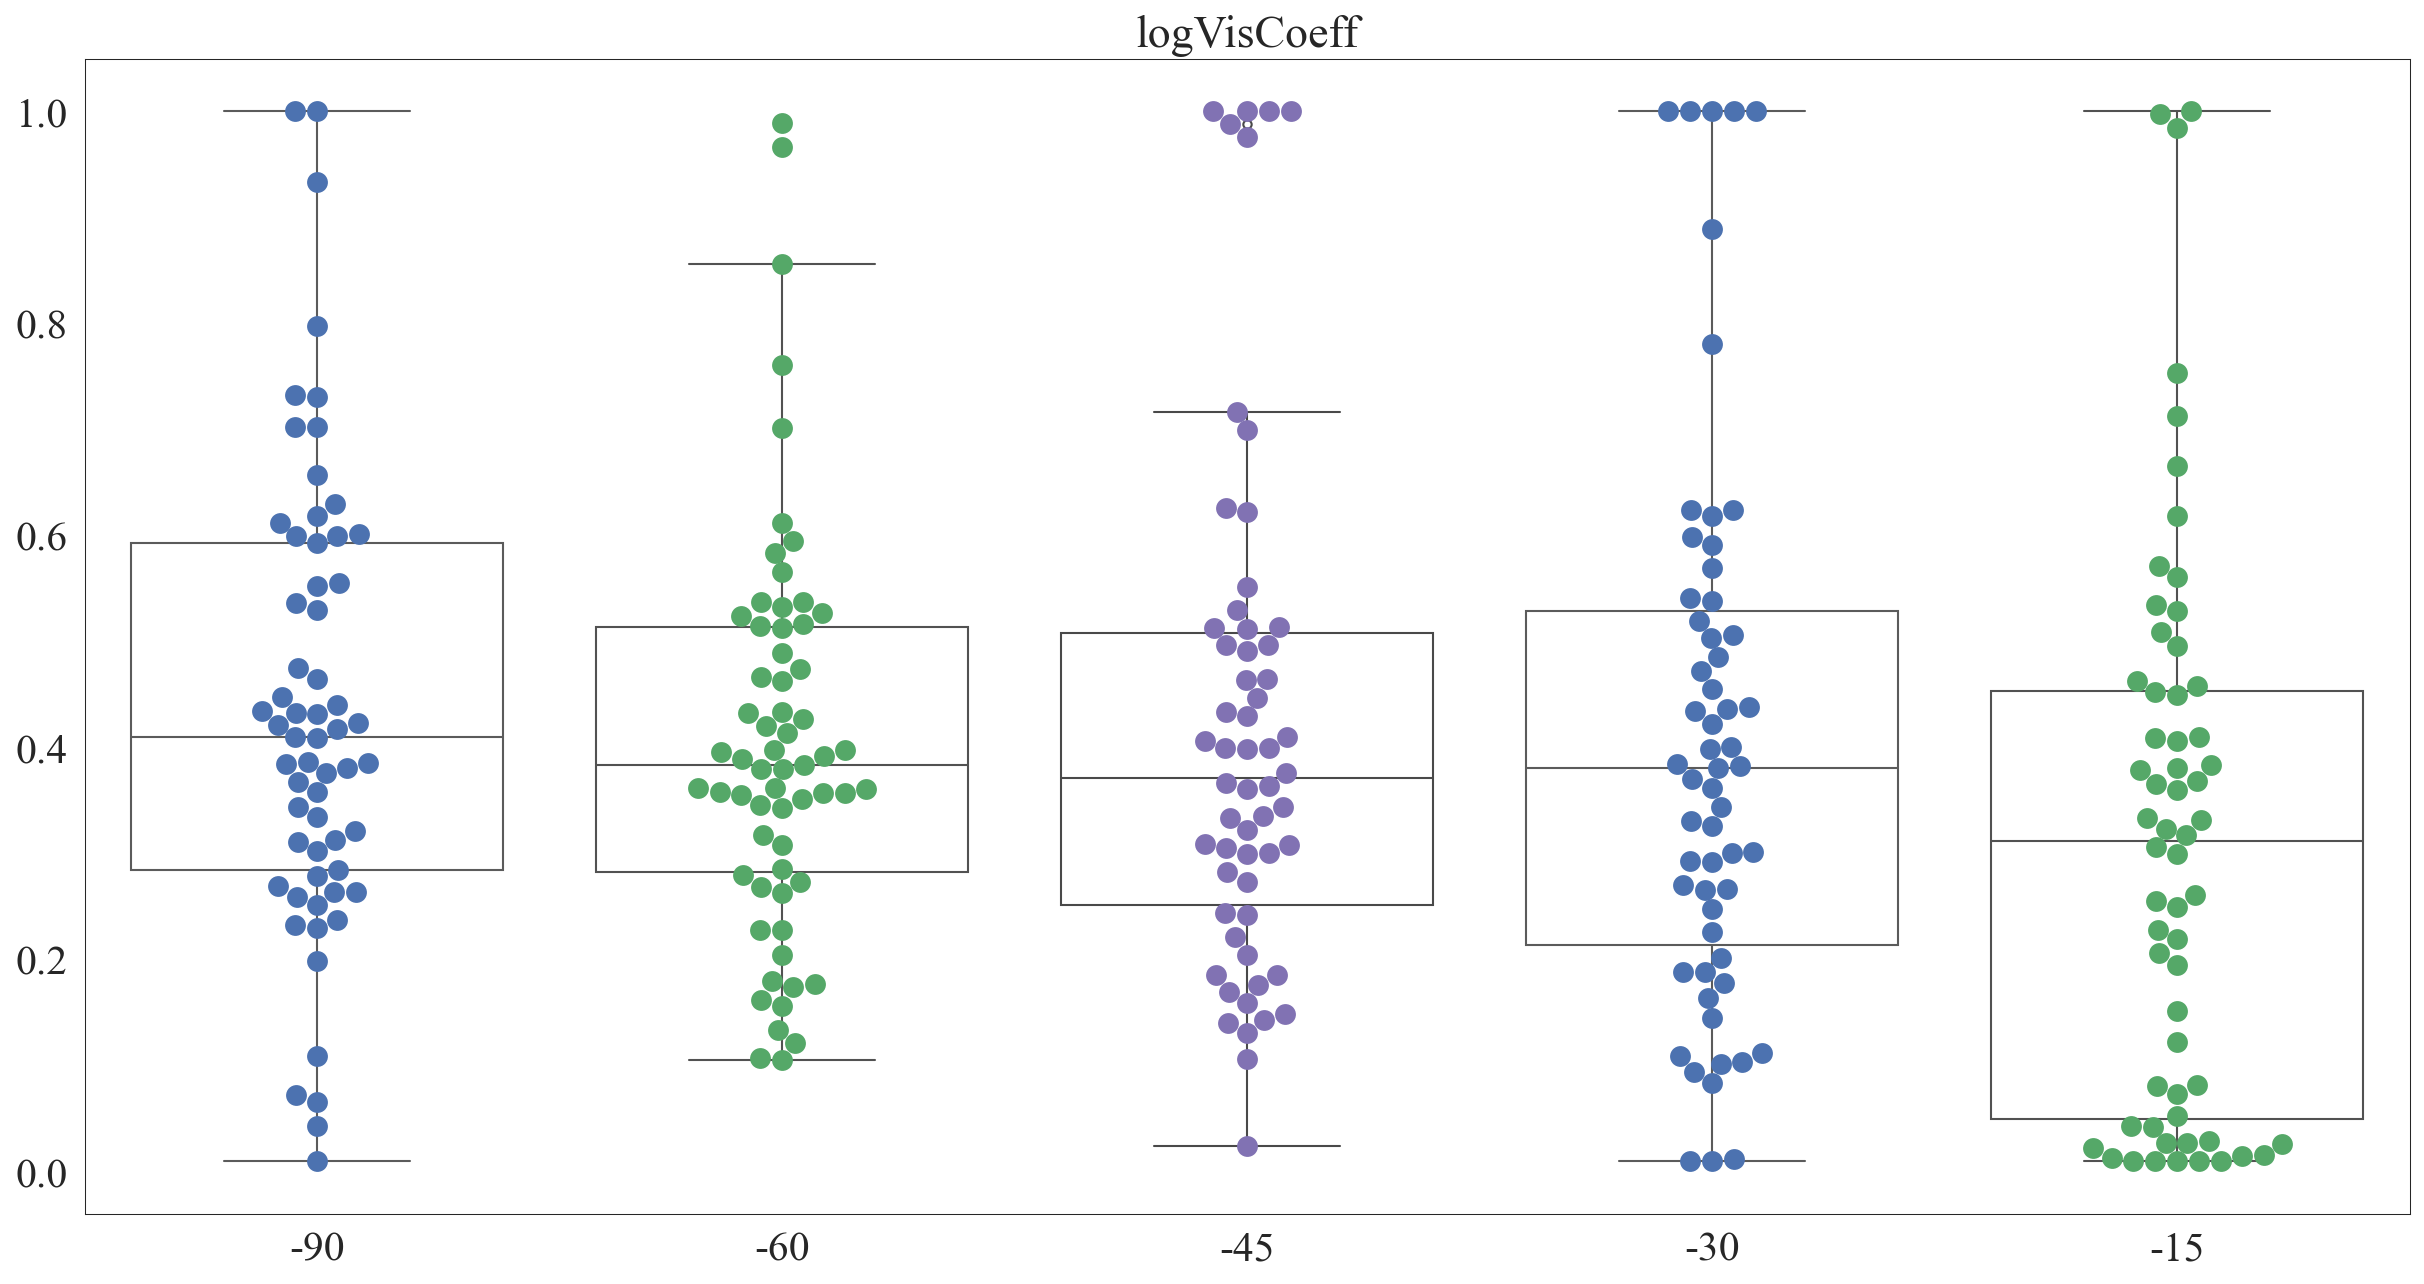

In [16]:
%matplotlib inline

rots = [-90,-60,-45,-30,-15]
for i in range(len(rots)):
    sns.swarmplot(x=rots[i],y=BOCD8ImpCG[i].rSquareds,size=10)
    sns.boxplot(x=rots[i], y=BOCD8ImpCG[i].rSquareds,boxprops=dict(facecolor="none"))
plt.title("r^2")
plt.show()
for i in range(len(rots)):
    sns.swarmplot(x=rots[i],y=BOCD8ImpCG[i].rmses,size=10)
    sns.boxplot(x=rots[i], y=BOCD8ImpCG[i].rmses,boxprops=dict(facecolor="none"))
plt.title("rmse")
plt.show()
for i in range(len(rots)):
    sns.swarmplot(x=rots[i],y=BOCD8ImpCG[i].bics,size=10)
    sns.boxplot(x=rots[i], y=BOCD8ImpCG[i].bics,boxprops=dict(facecolor="none"))
plt.title("bic")
plt.show()
paramLabs = ["logSigma0", "logHazard", "logSigma1", "logitPGlobal",
             "logA", "logB", "logSigmaGen", "logitPS0", "logVisCoeff"]
k = 0
for lab in paramLabs:
    for i in range(len(rots)):
        sns.swarmplot(x=rots[i],y=[BOCD8ImpCG[i].xs[j][k] for j in range(len(BOCD8ImpCG[i].xs))],size=10)
        sns.boxplot(x=rots[i], y=[BOCD8ImpCG[i].xs[j][k] for j in range(len(BOCD8ImpCG[i].xs))],boxprops=dict(facecolor="none"))
    plt.title(lab)
    plt.show()
    k += 1

In [8]:
ssm8ImpCG = np.load("ssmsAutocorrect8AllPPs.npy",allow_pickle=True)


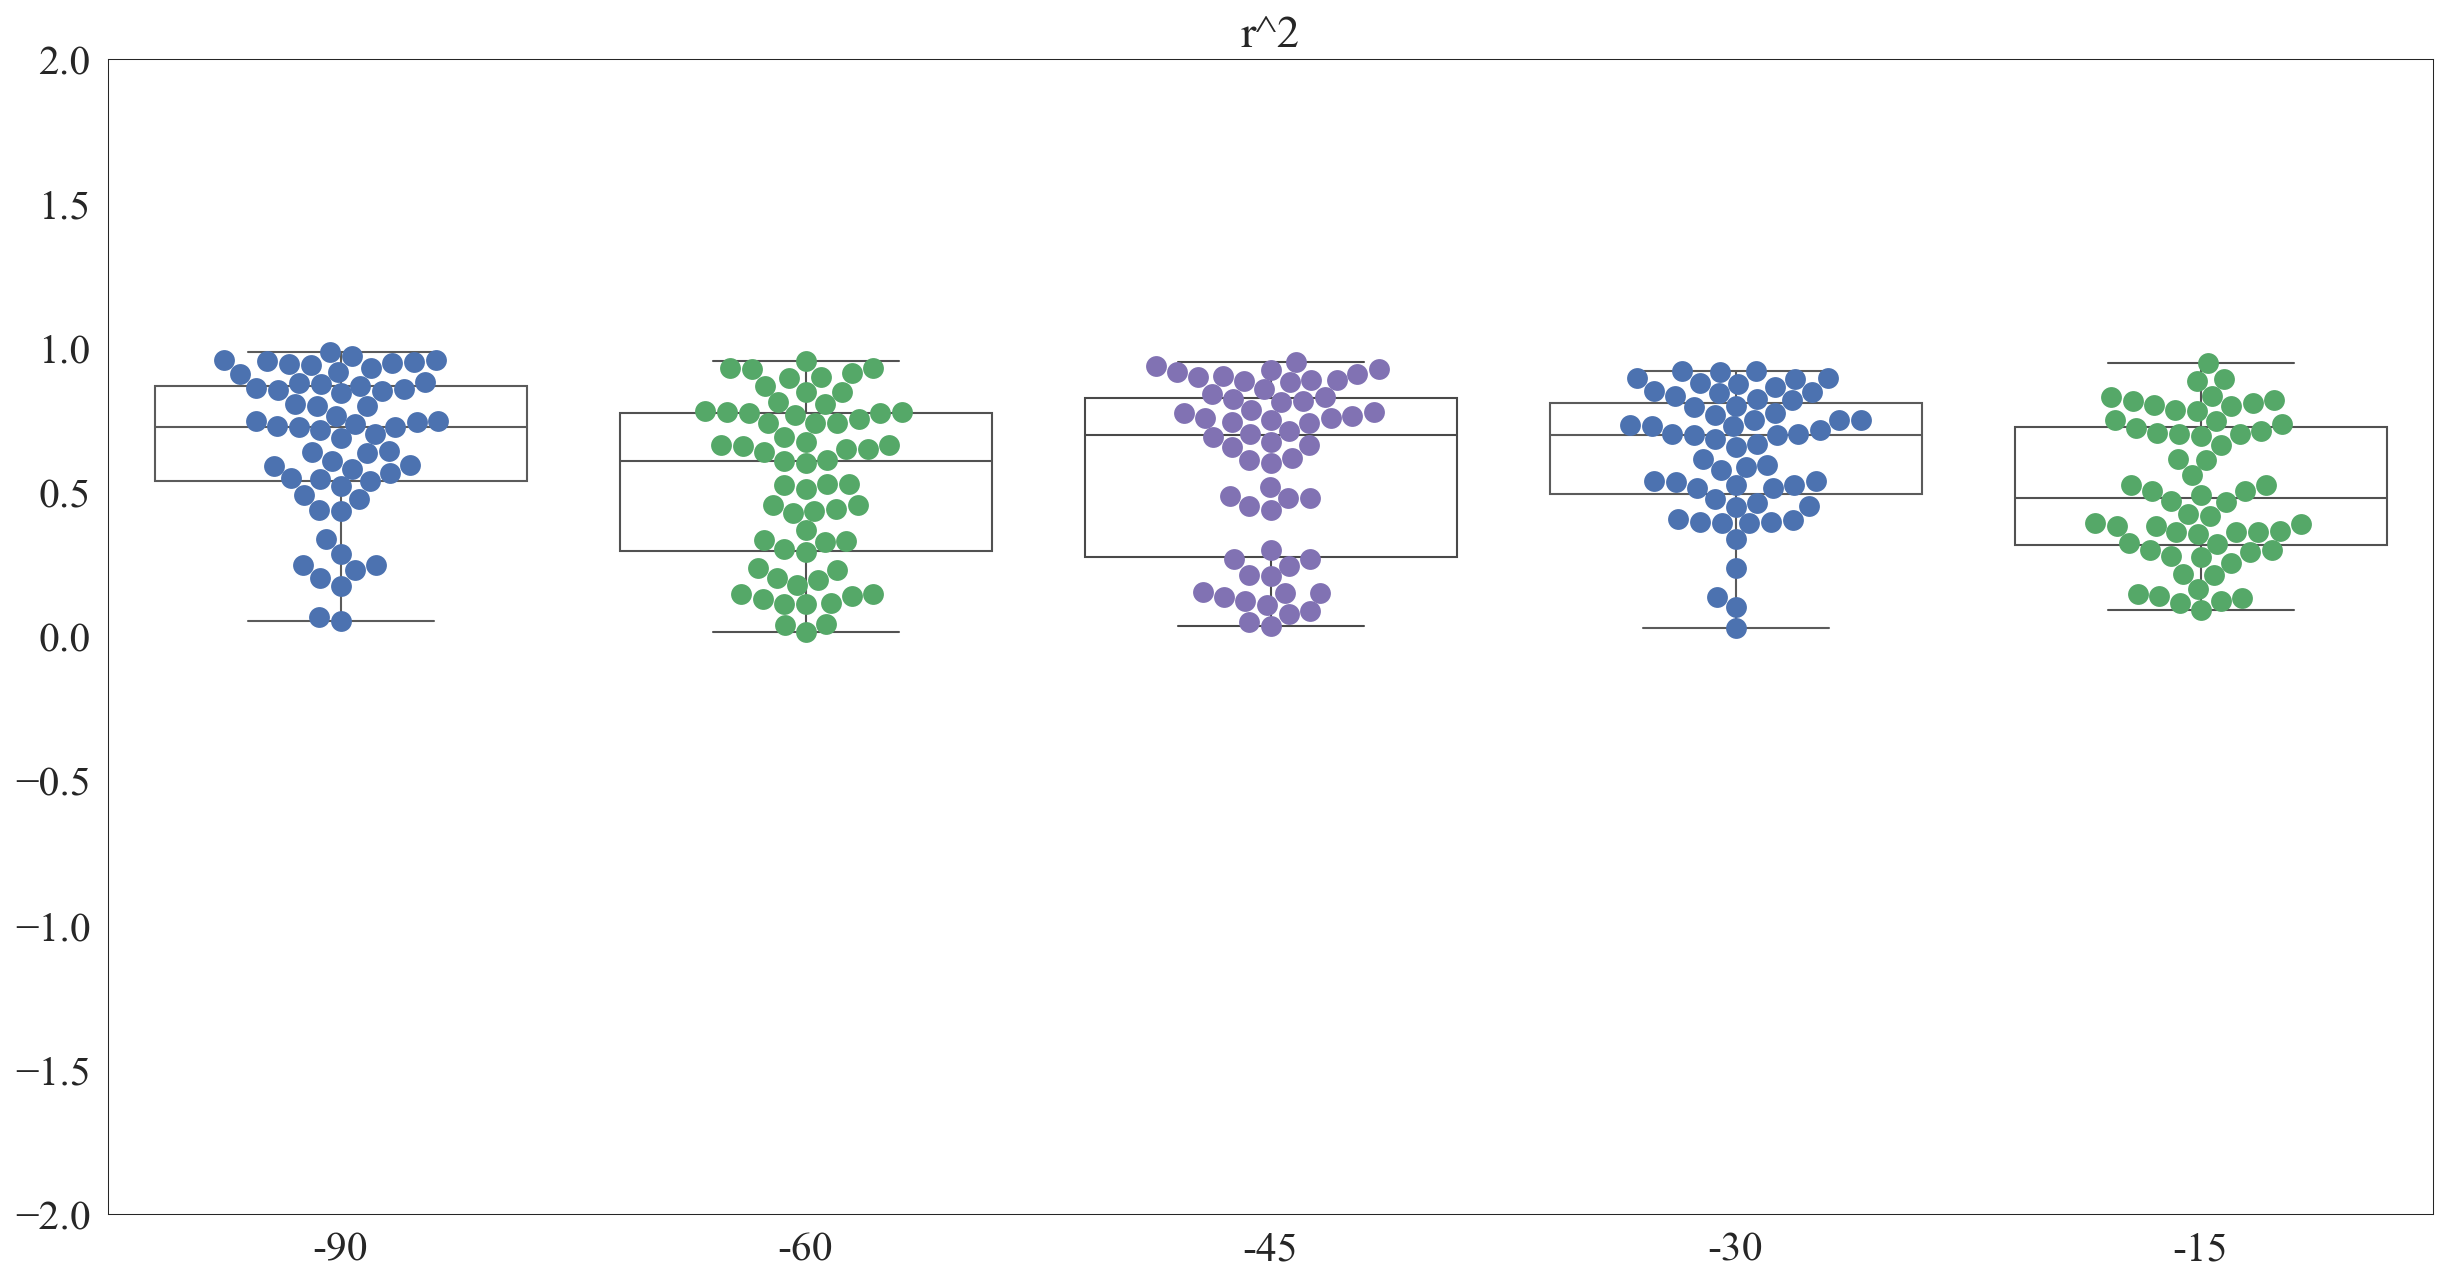

In [17]:
%matplotlib inline
rots = [-90,-60,-45,-30,-15]
for i in range(len(rots)):
    sns.swarmplot(x=rots[i],y=ssm8ImpCG[i].rSquareds,size=10)
    sns.boxplot(x=rots[i], y=ssm8ImpCG[i].rSquareds,boxprops=dict(facecolor="none"))
                                                                   
plt.title("r^2")
plt.ylim(-2,2)
plt.show()

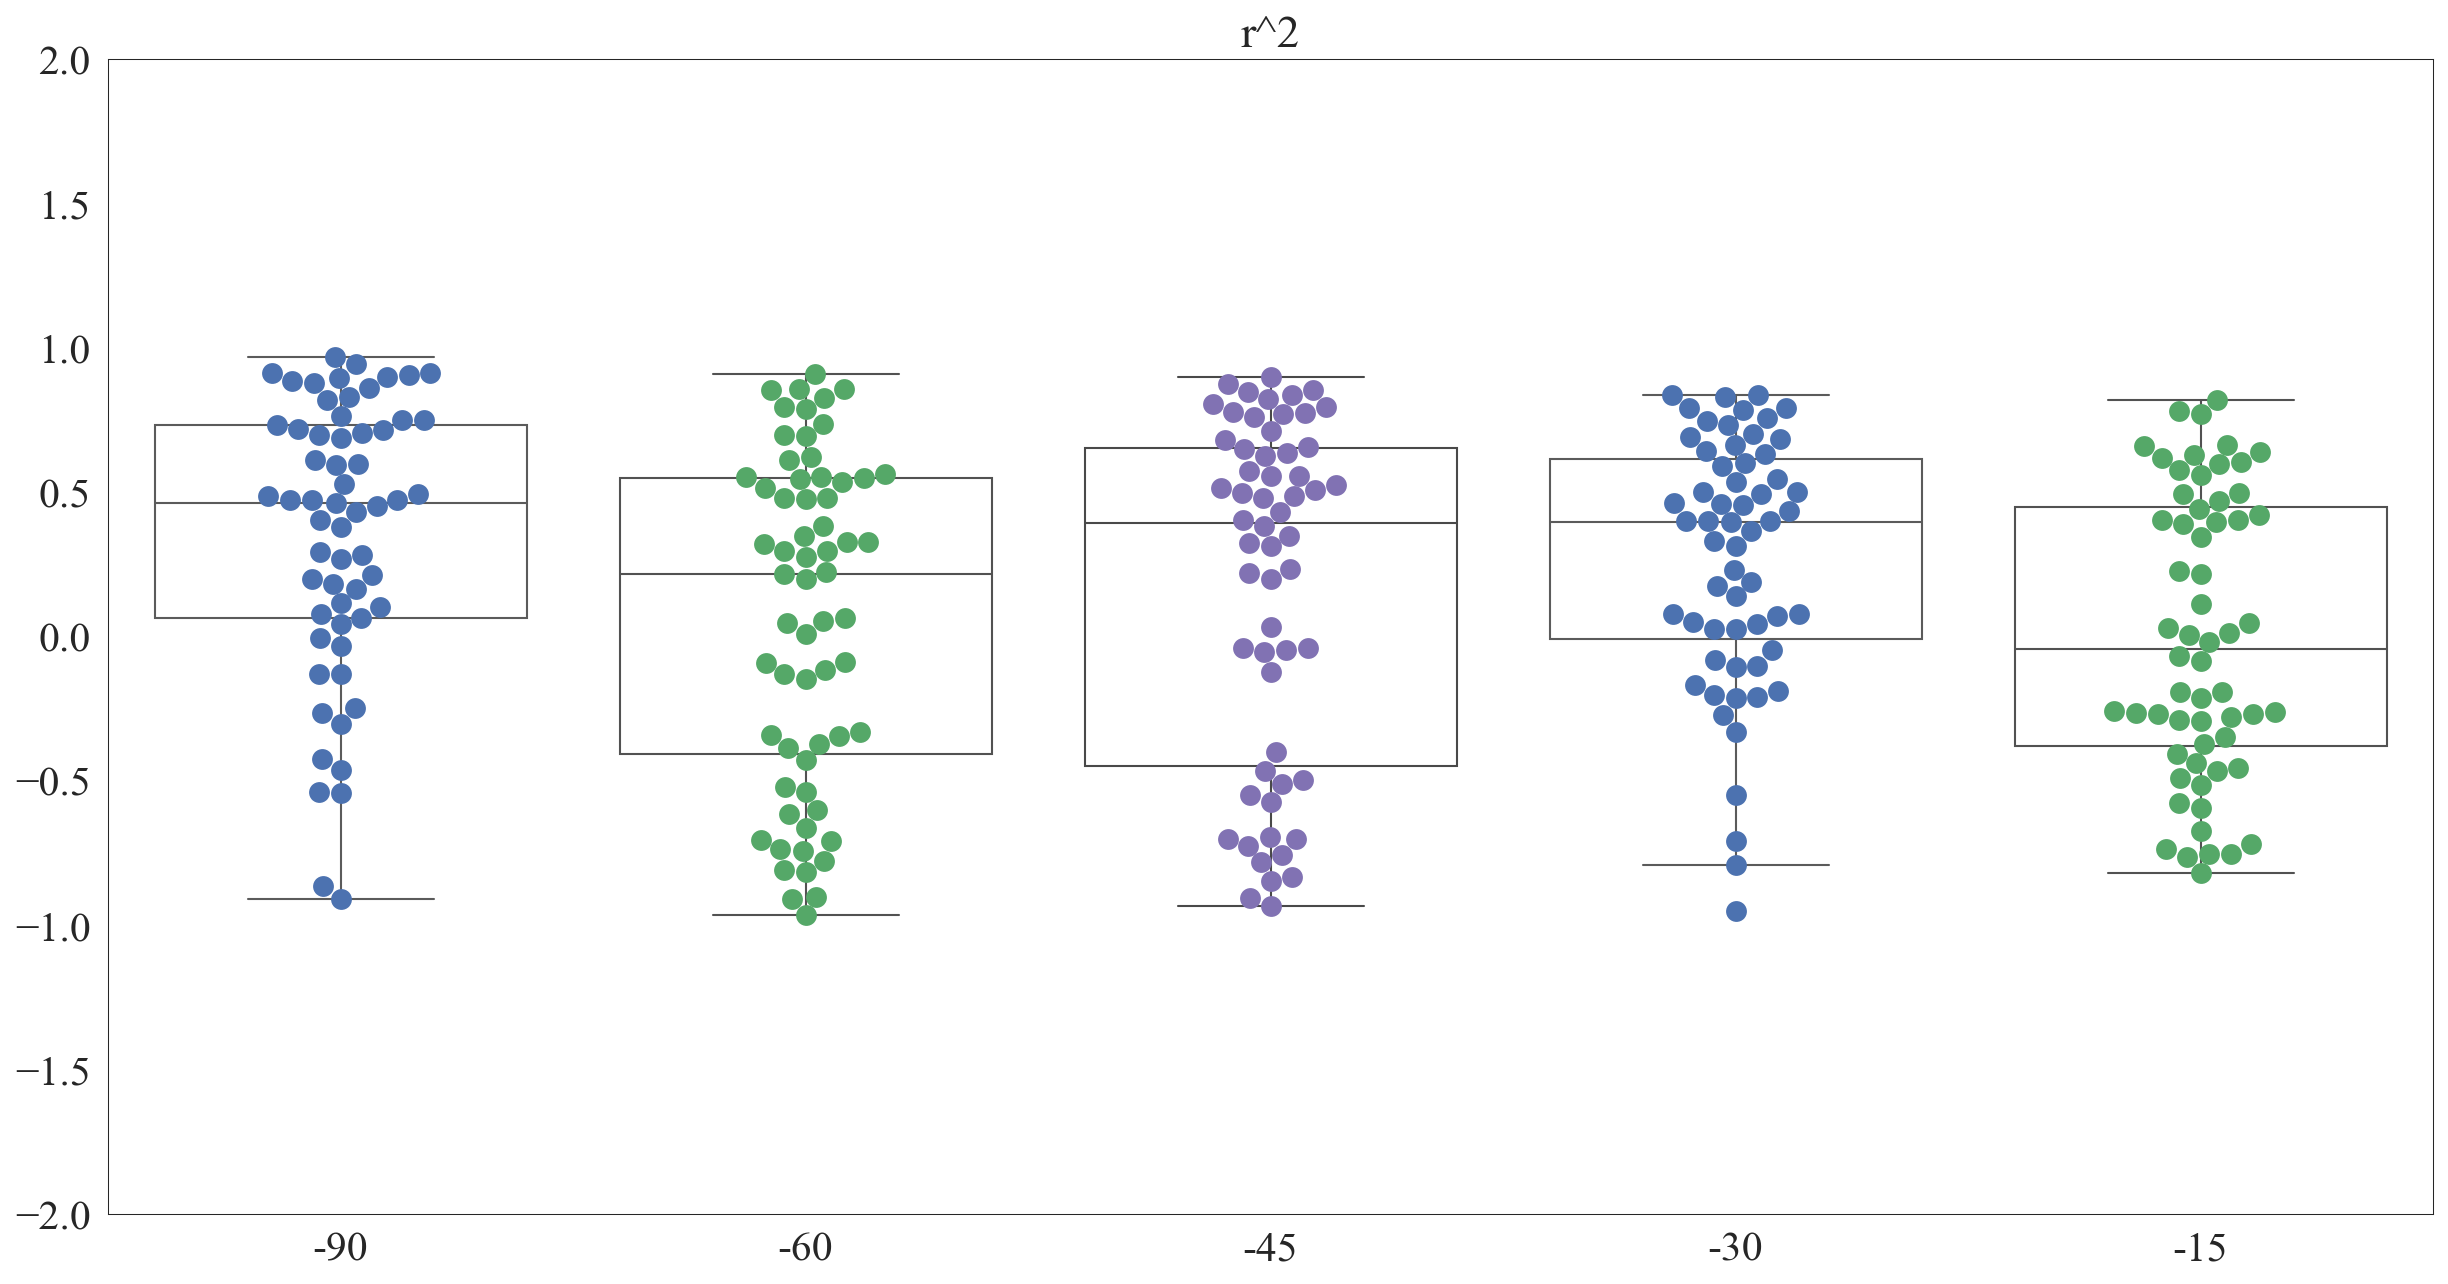

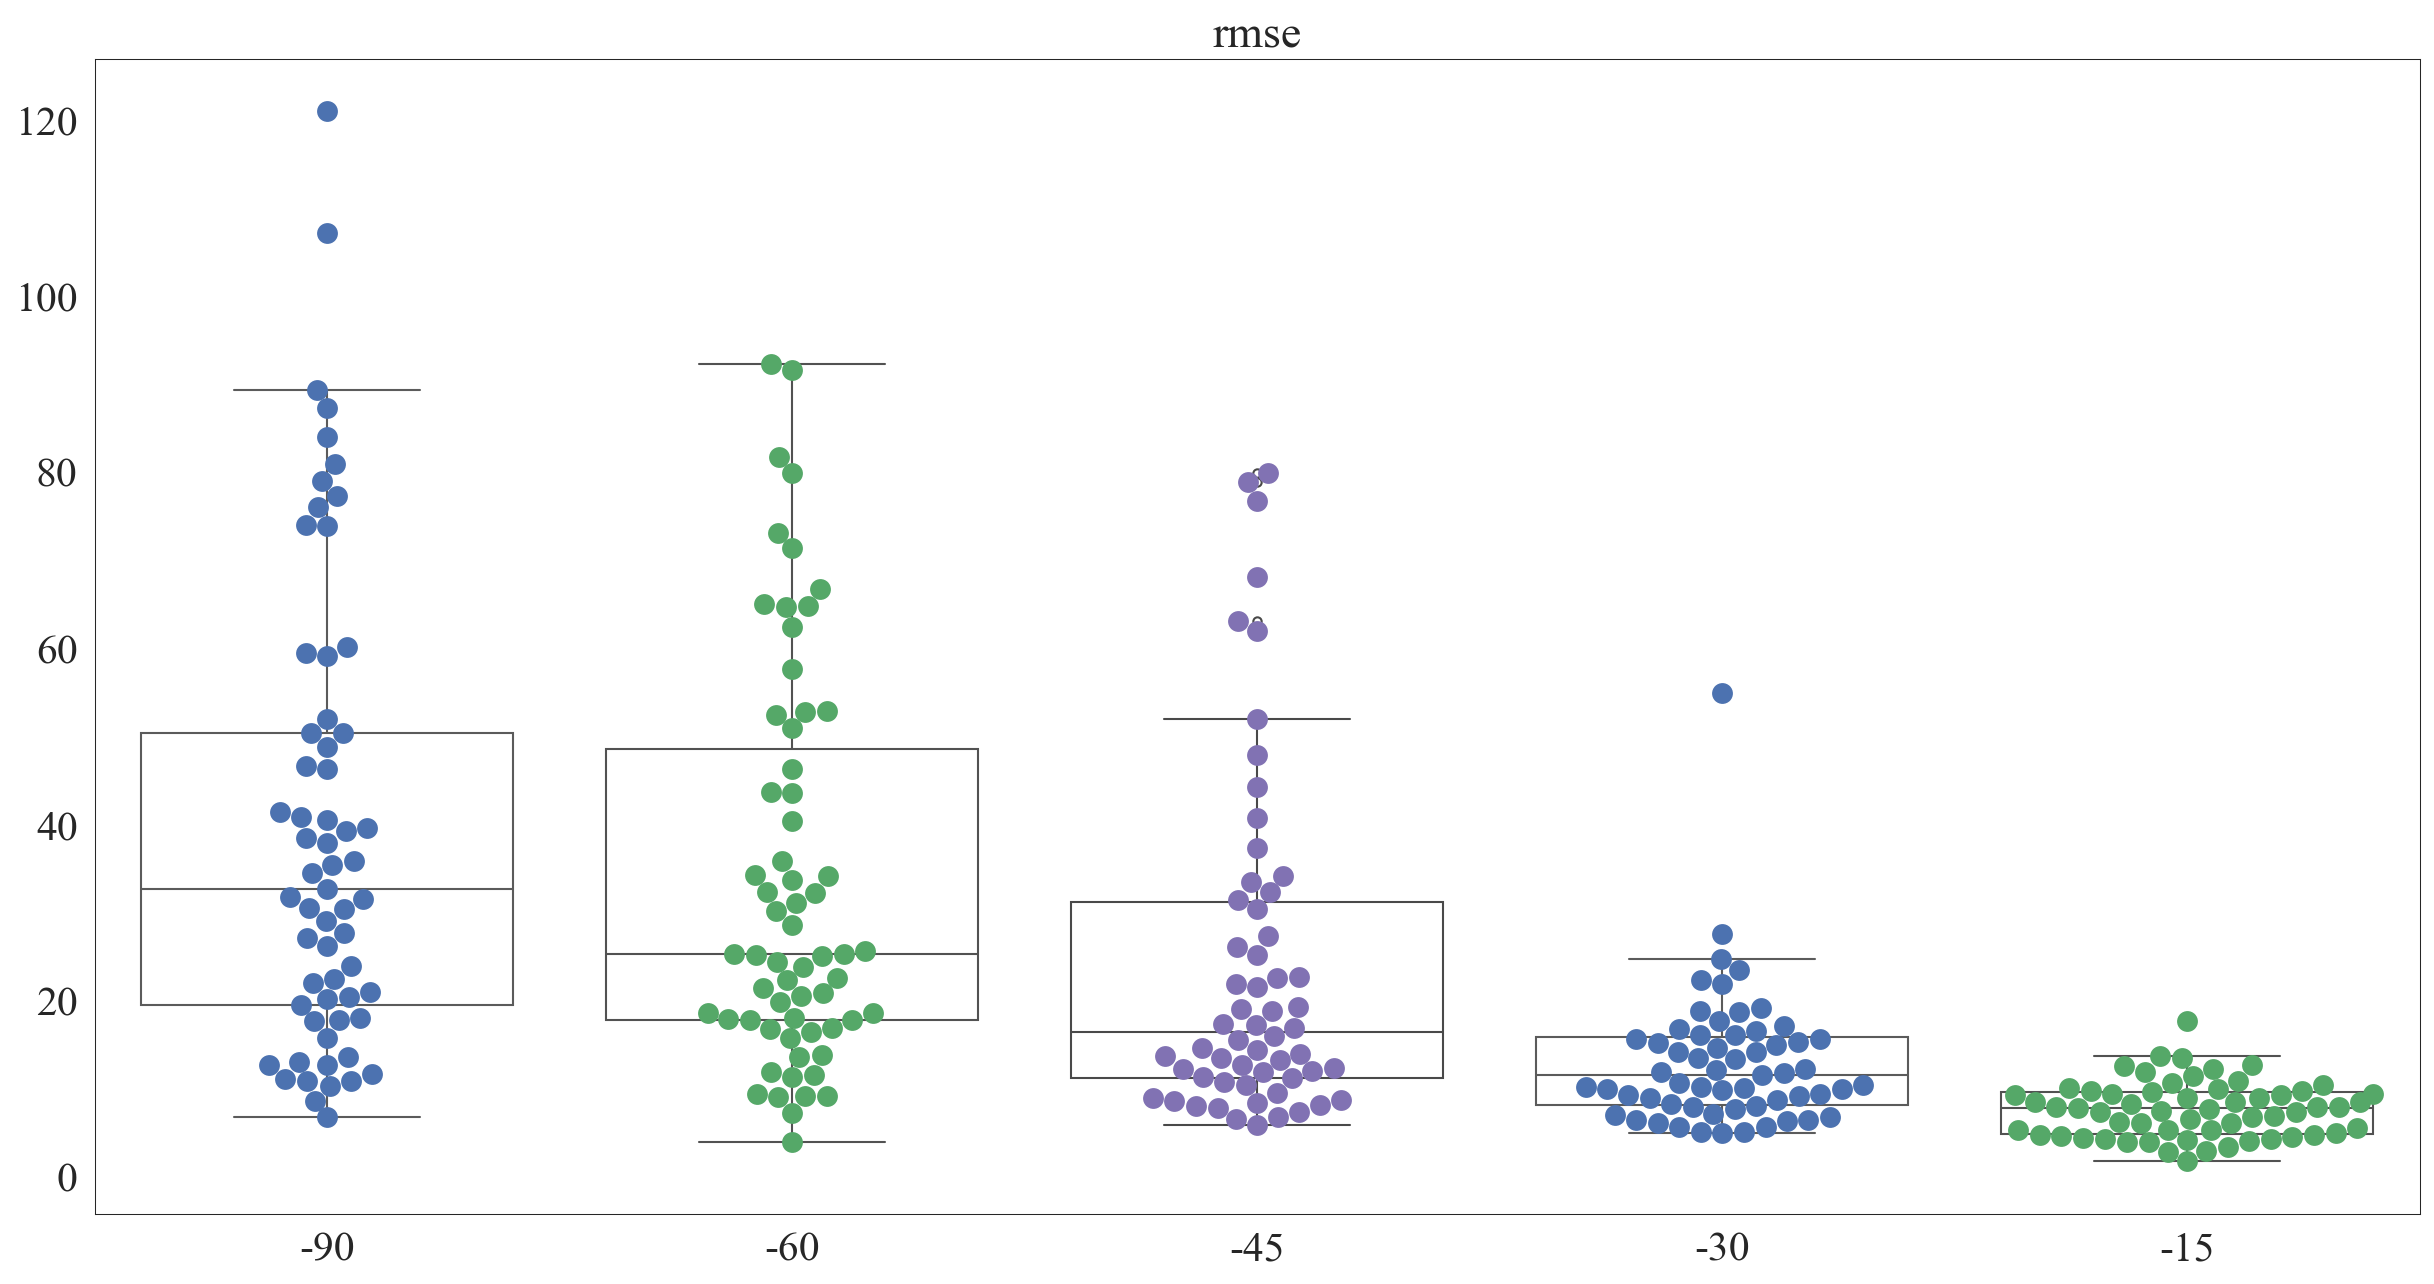

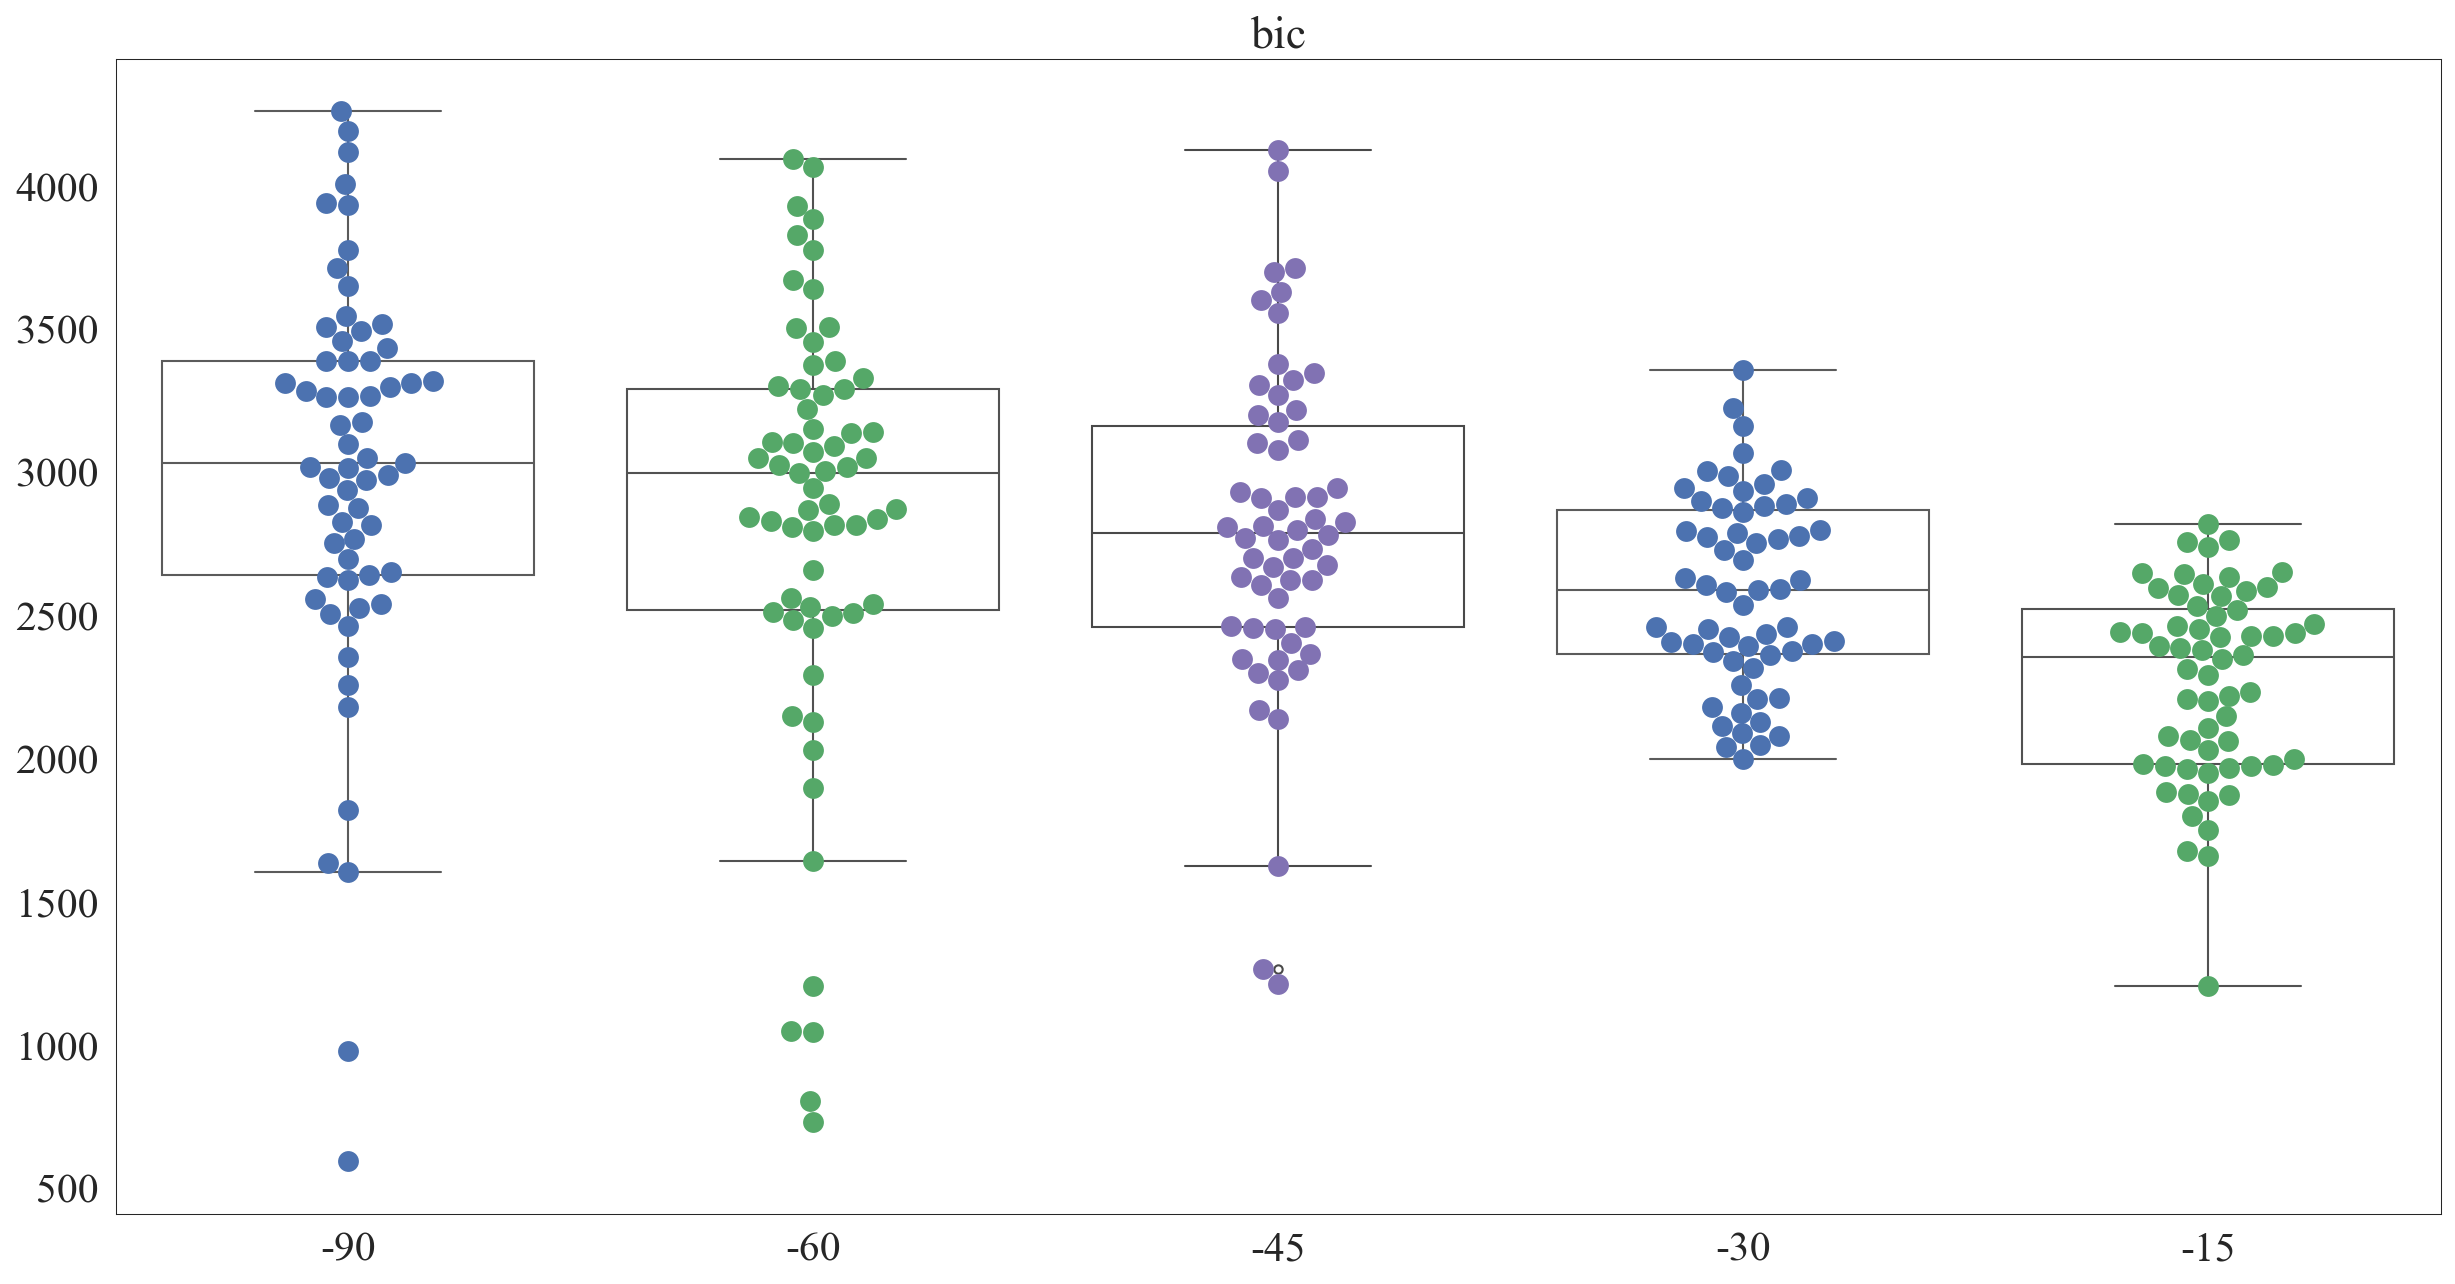

In [18]:
%matplotlib inline

rots = [-90,-60,-45,-30,-15]
for i in range(len(rots)):
    sns.swarmplot(x=rots[i],y=ssm8ImpCG[i].rSquareds_dist,size=10)
    sns.boxplot(x=rots[i], y=ssm8ImpCG[i].rSquareds_dist,boxprops=dict(facecolor="none"))
plt.ylim(-2,2)
plt.title("r^2")
plt.show()
for i in range(len(rots)):
    sns.swarmplot(x=rots[i],y=ssm8ImpCG[i].rmses_dist,size=10)
    sns.boxplot(x=rots[i], y=ssm8ImpCG[i].rmses_dist,boxprops=dict(facecolor="none"))
plt.title("rmse")
plt.show()
for i in range(len(rots)):
    sns.swarmplot(x=rots[i],y=ssm8ImpCG[i].bics,size=10)
    sns.boxplot(x=rots[i], y=ssm8ImpCG[i].bics,boxprops=dict(facecolor="none"))
plt.title("bic")
plt.show()

In [19]:
rots = [-90,-60,-45,-30,-15]
for i in range(len(rots)):
    sns.swarmplot(x=rots[i],y=np.subtract(BOCD8ImpCG[i].rSquareds_dist,ssm8ImpCG[i].rSquareds_dist),size=10)
    sns.boxplot(x=rots[i], y=np.subtract(BOCD8ImpCG[i].rSquareds_dist,ssm8ImpCG[i].rSquareds_dist),boxprops=dict(facecolor="none"))
plt.ylim(-3,3)
plt.title("r^2")
plt.axhline(0)
plt.show()
for i in range(len(rots)):
    sns.swarmplot(x=rots[i],y=np.subtract(BOCD8ImpCG[i].rmses_dist,ssm8ImpCG[i].rmses_dist),size=10)
    sns.boxplot(x=rots[i], y=np.subtract(BOCD8ImpCG[i].rmses_dist,ssm8ImpCG[i].rmses_dist),boxprops=dict(facecolor="none"))
plt.title("rmse")
plt.axhline(0)
plt.show()
for i in range(len(rots)):
    sns.swarmplot(x=rots[i],y=np.subtract(BOCD8ImpCG[i].bics,ssm8ImpCG[i].bics),size=10)
    sns.boxplot(x=rots[i], y=np.subtract(BOCD8ImpCG[i].bics,ssm8ImpCG[i]),boxprops=dict(facecolor="none"))
plt.title("bic")
plt.axhline(0)
plt.show()

AttributeError: 'FitShell' object has no attribute 'rSquareds_dist'

In [6]:
BTDualSSM = np.load("BondTaylorssmsAutocorrect8AllPPs.npy",allow_pickle=True)
BTBOCD = np.load("BondTaylorBFSSM8AllPPs.npy",allow_pickle=True)

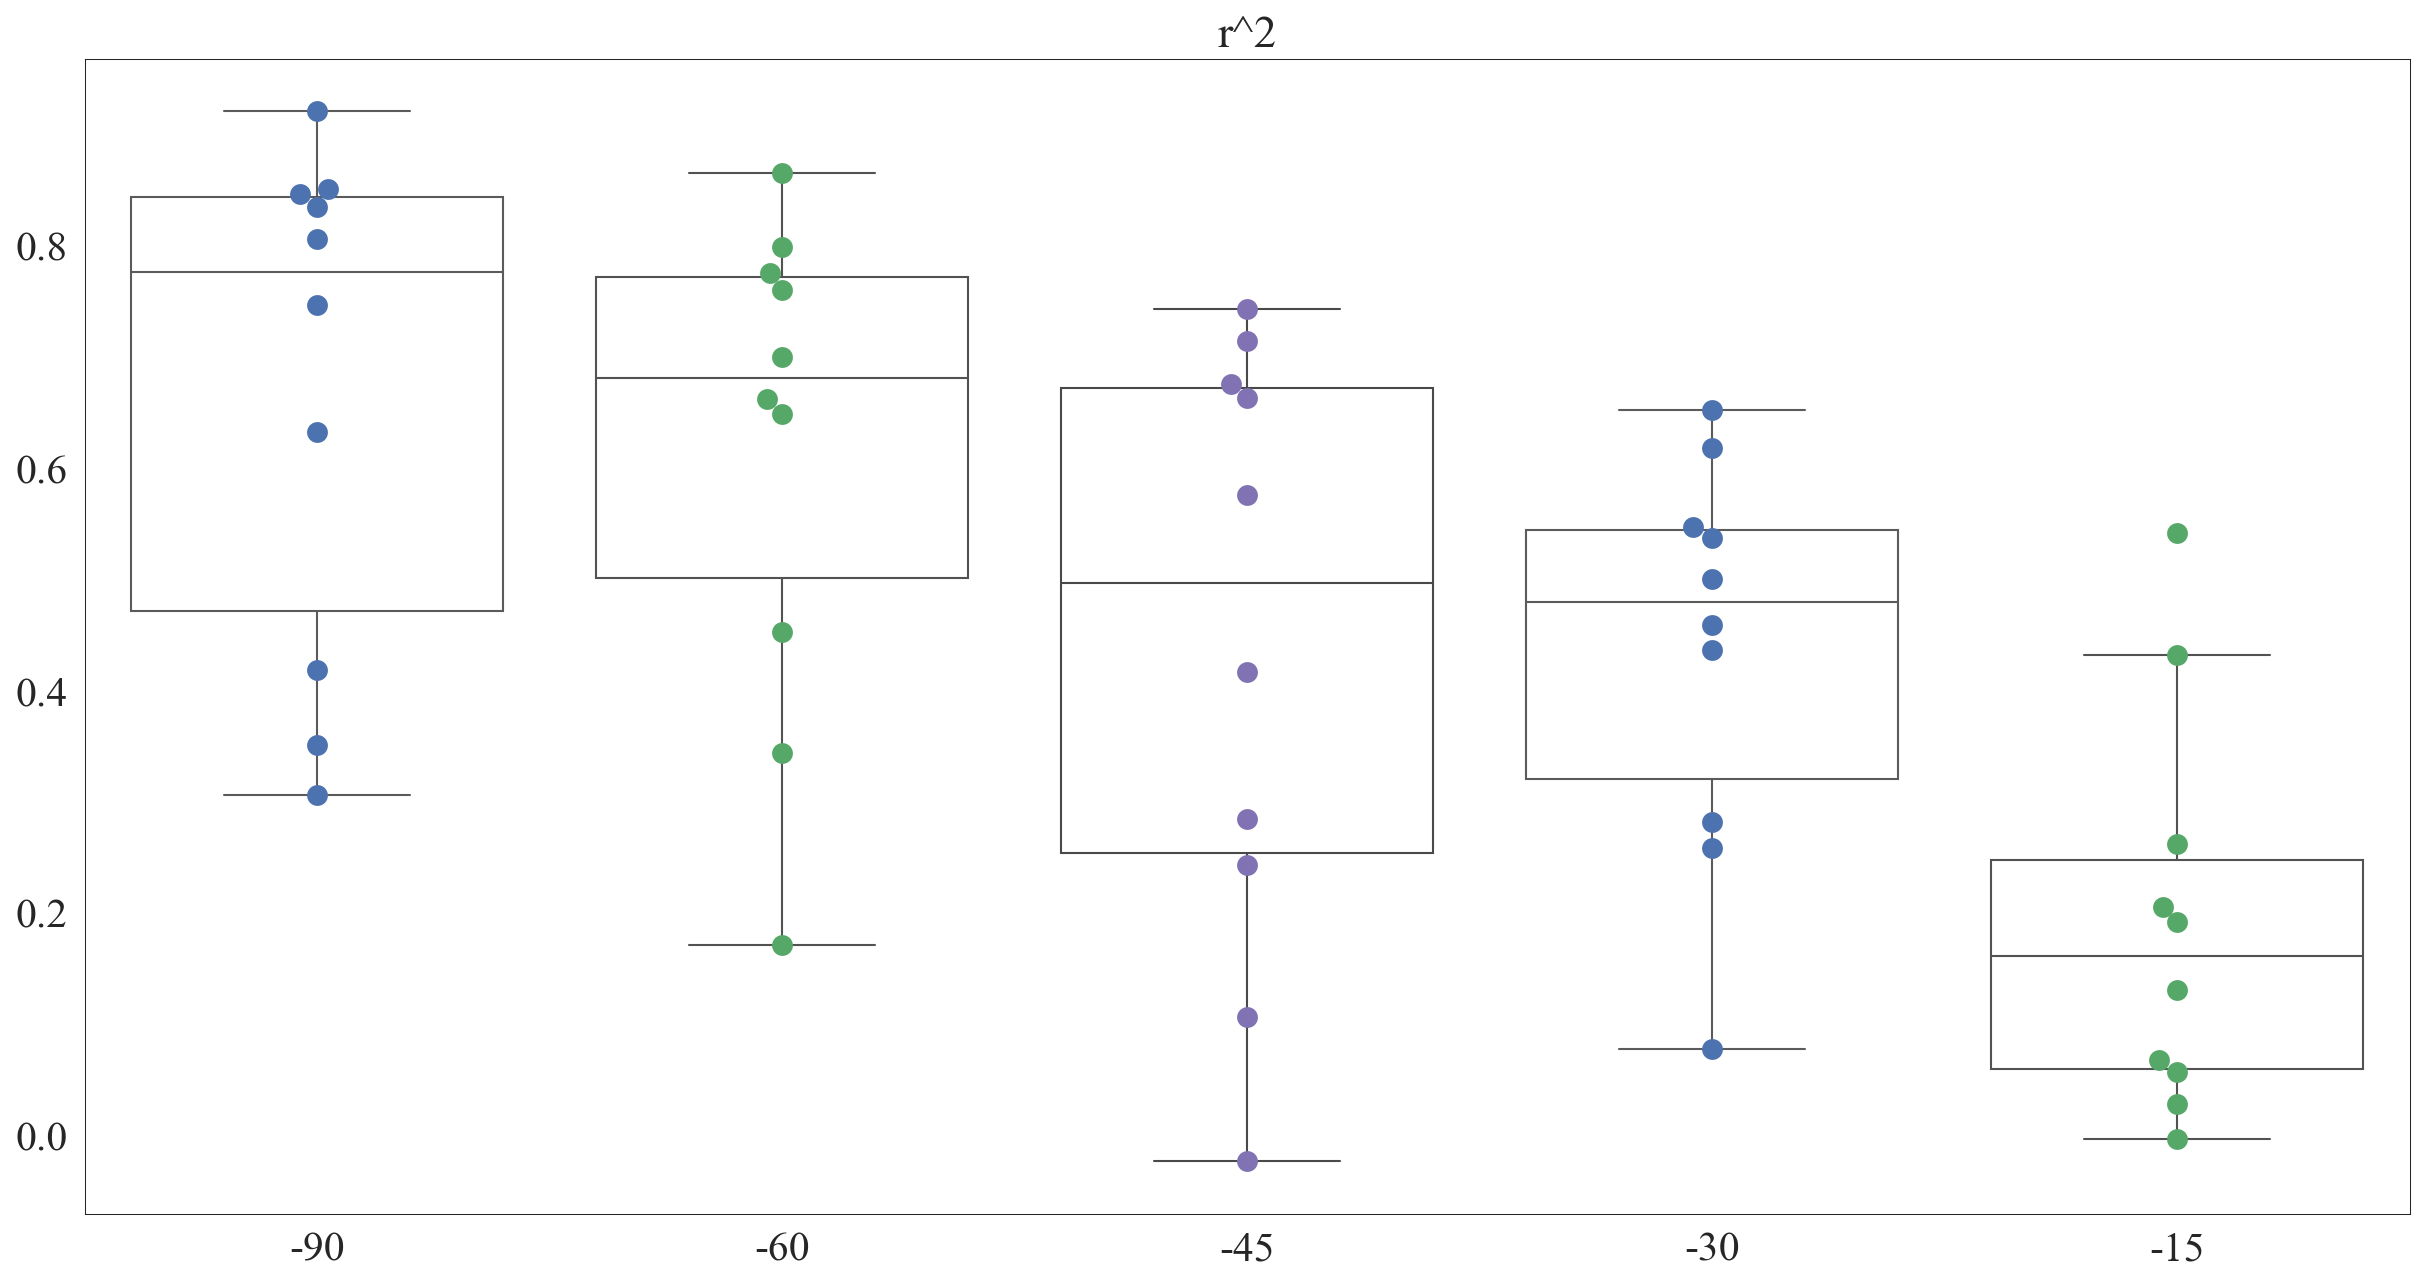

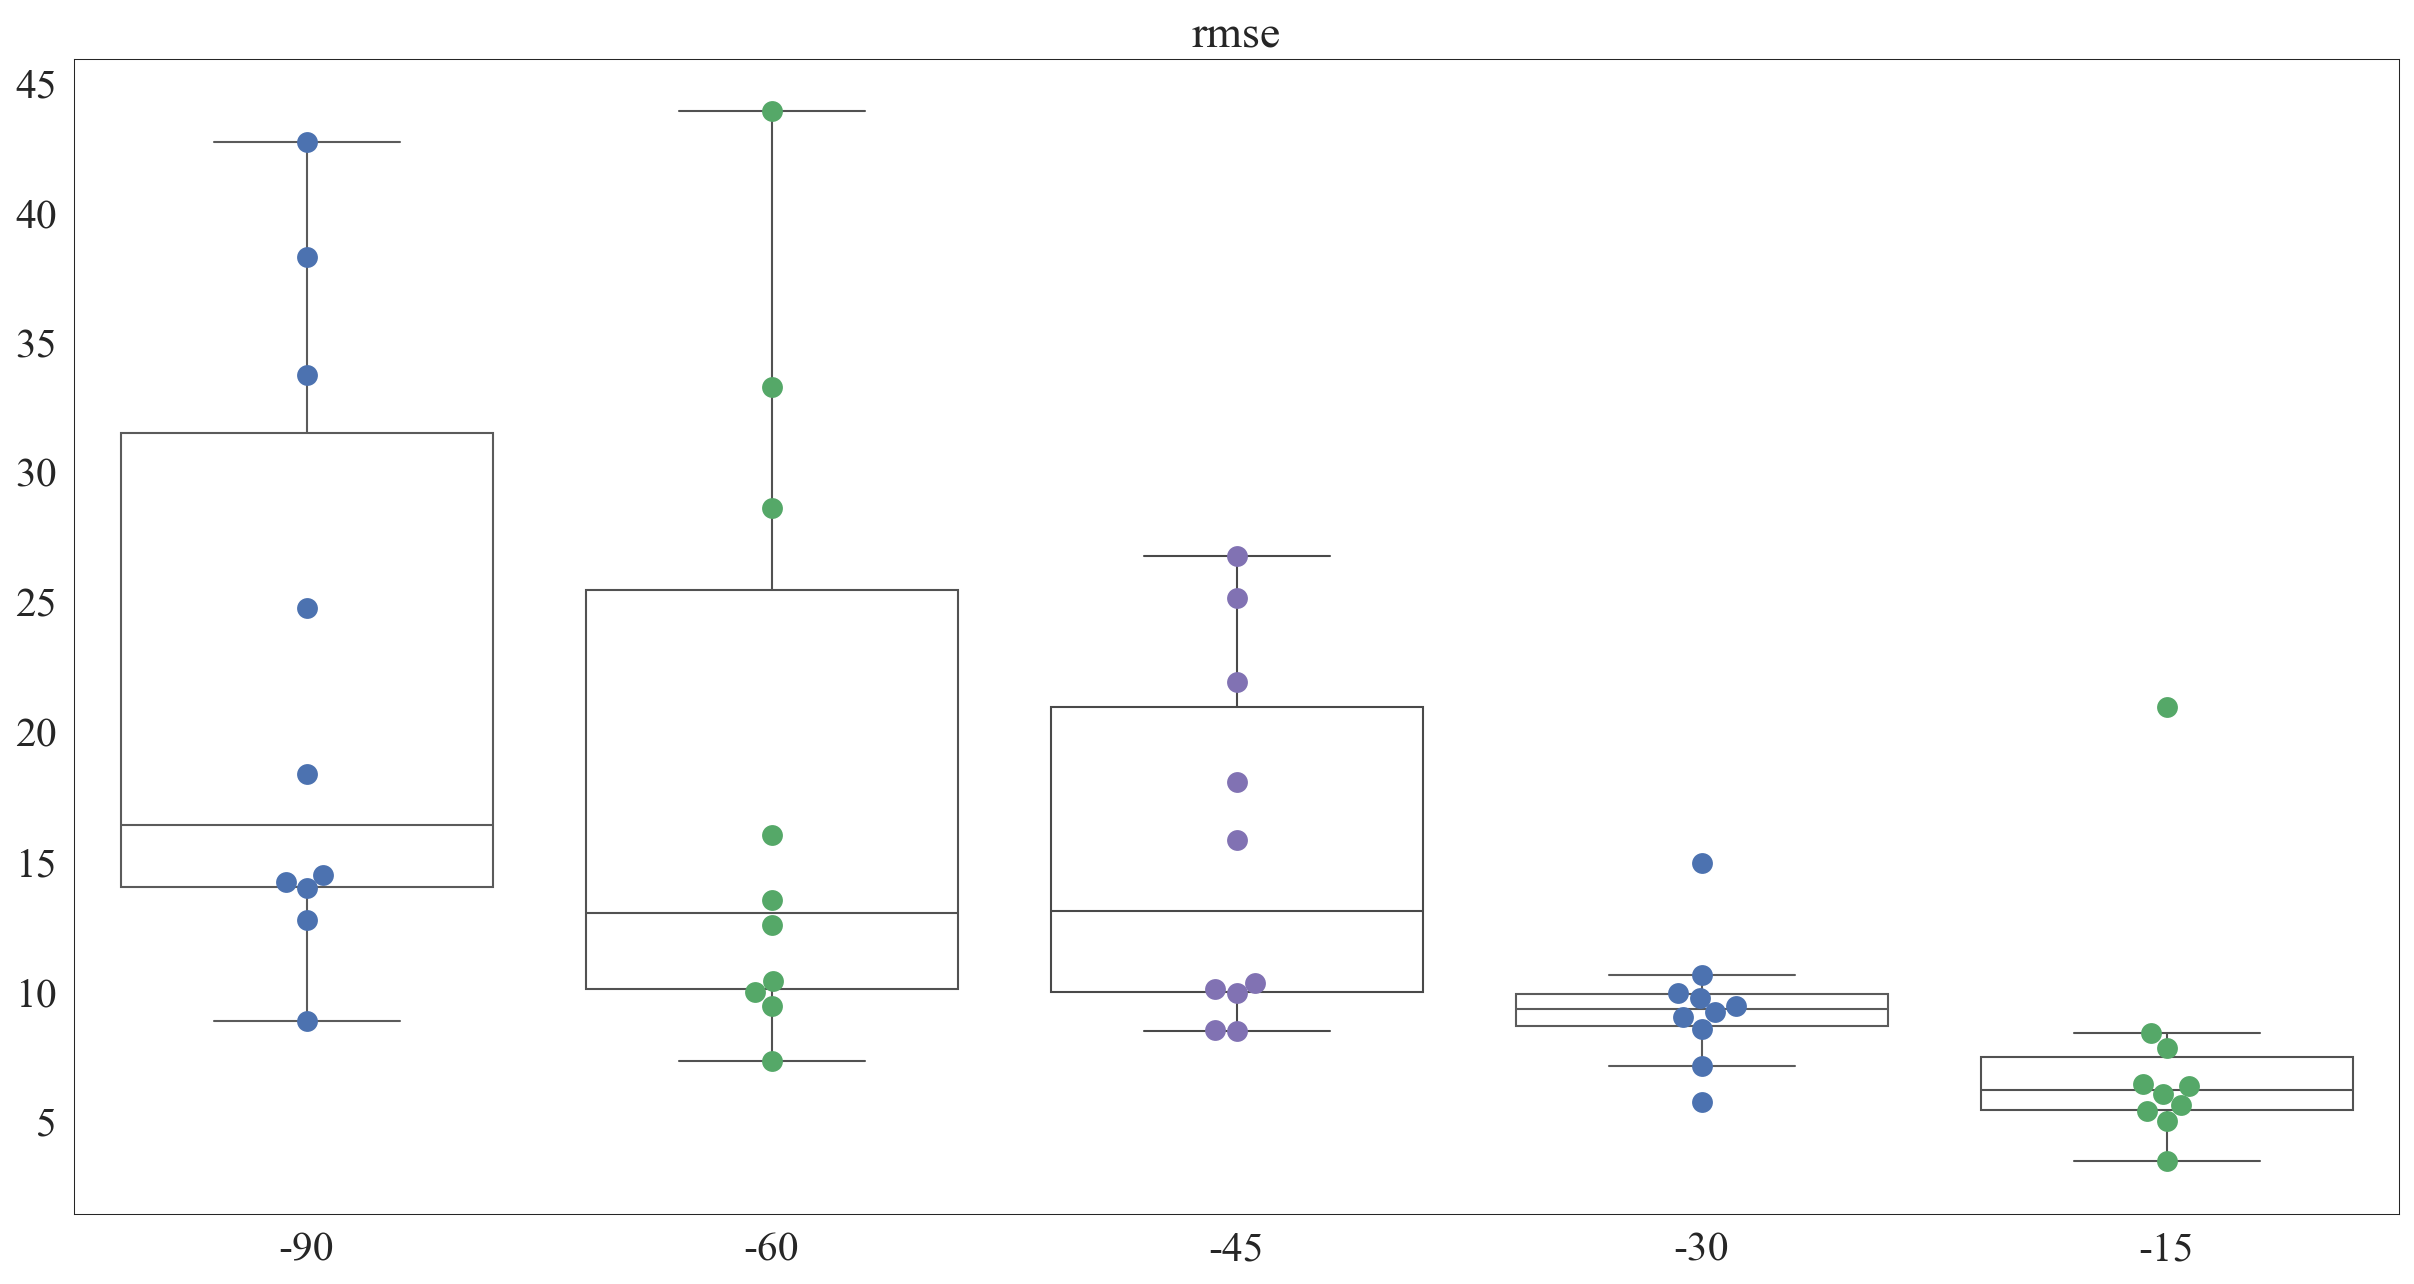

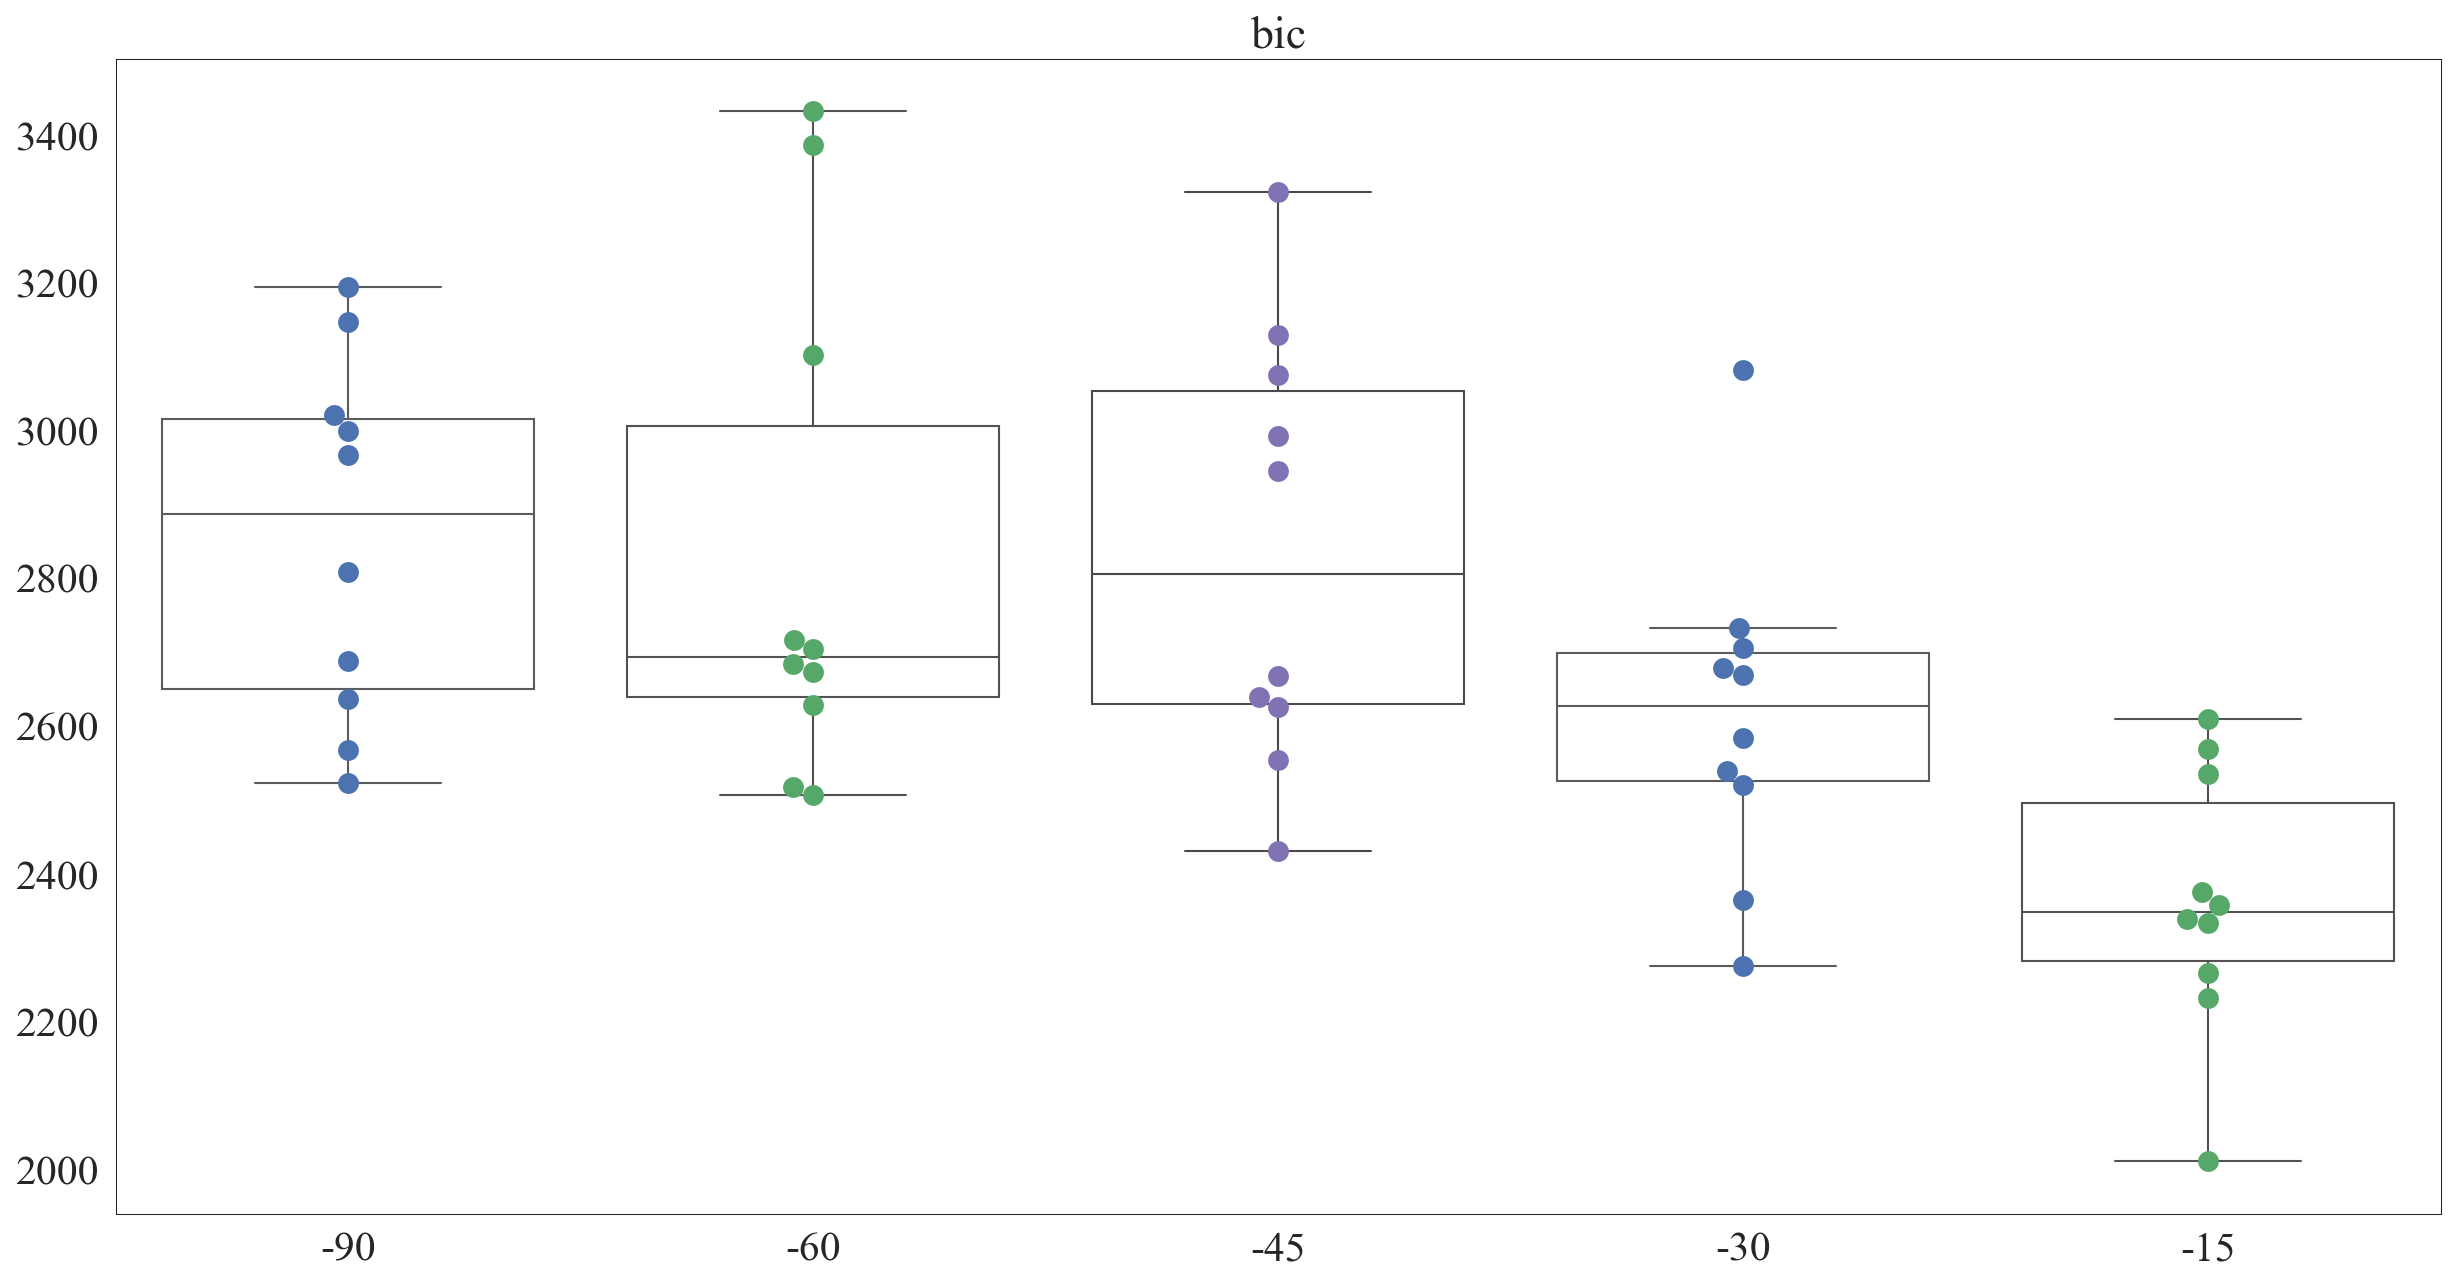

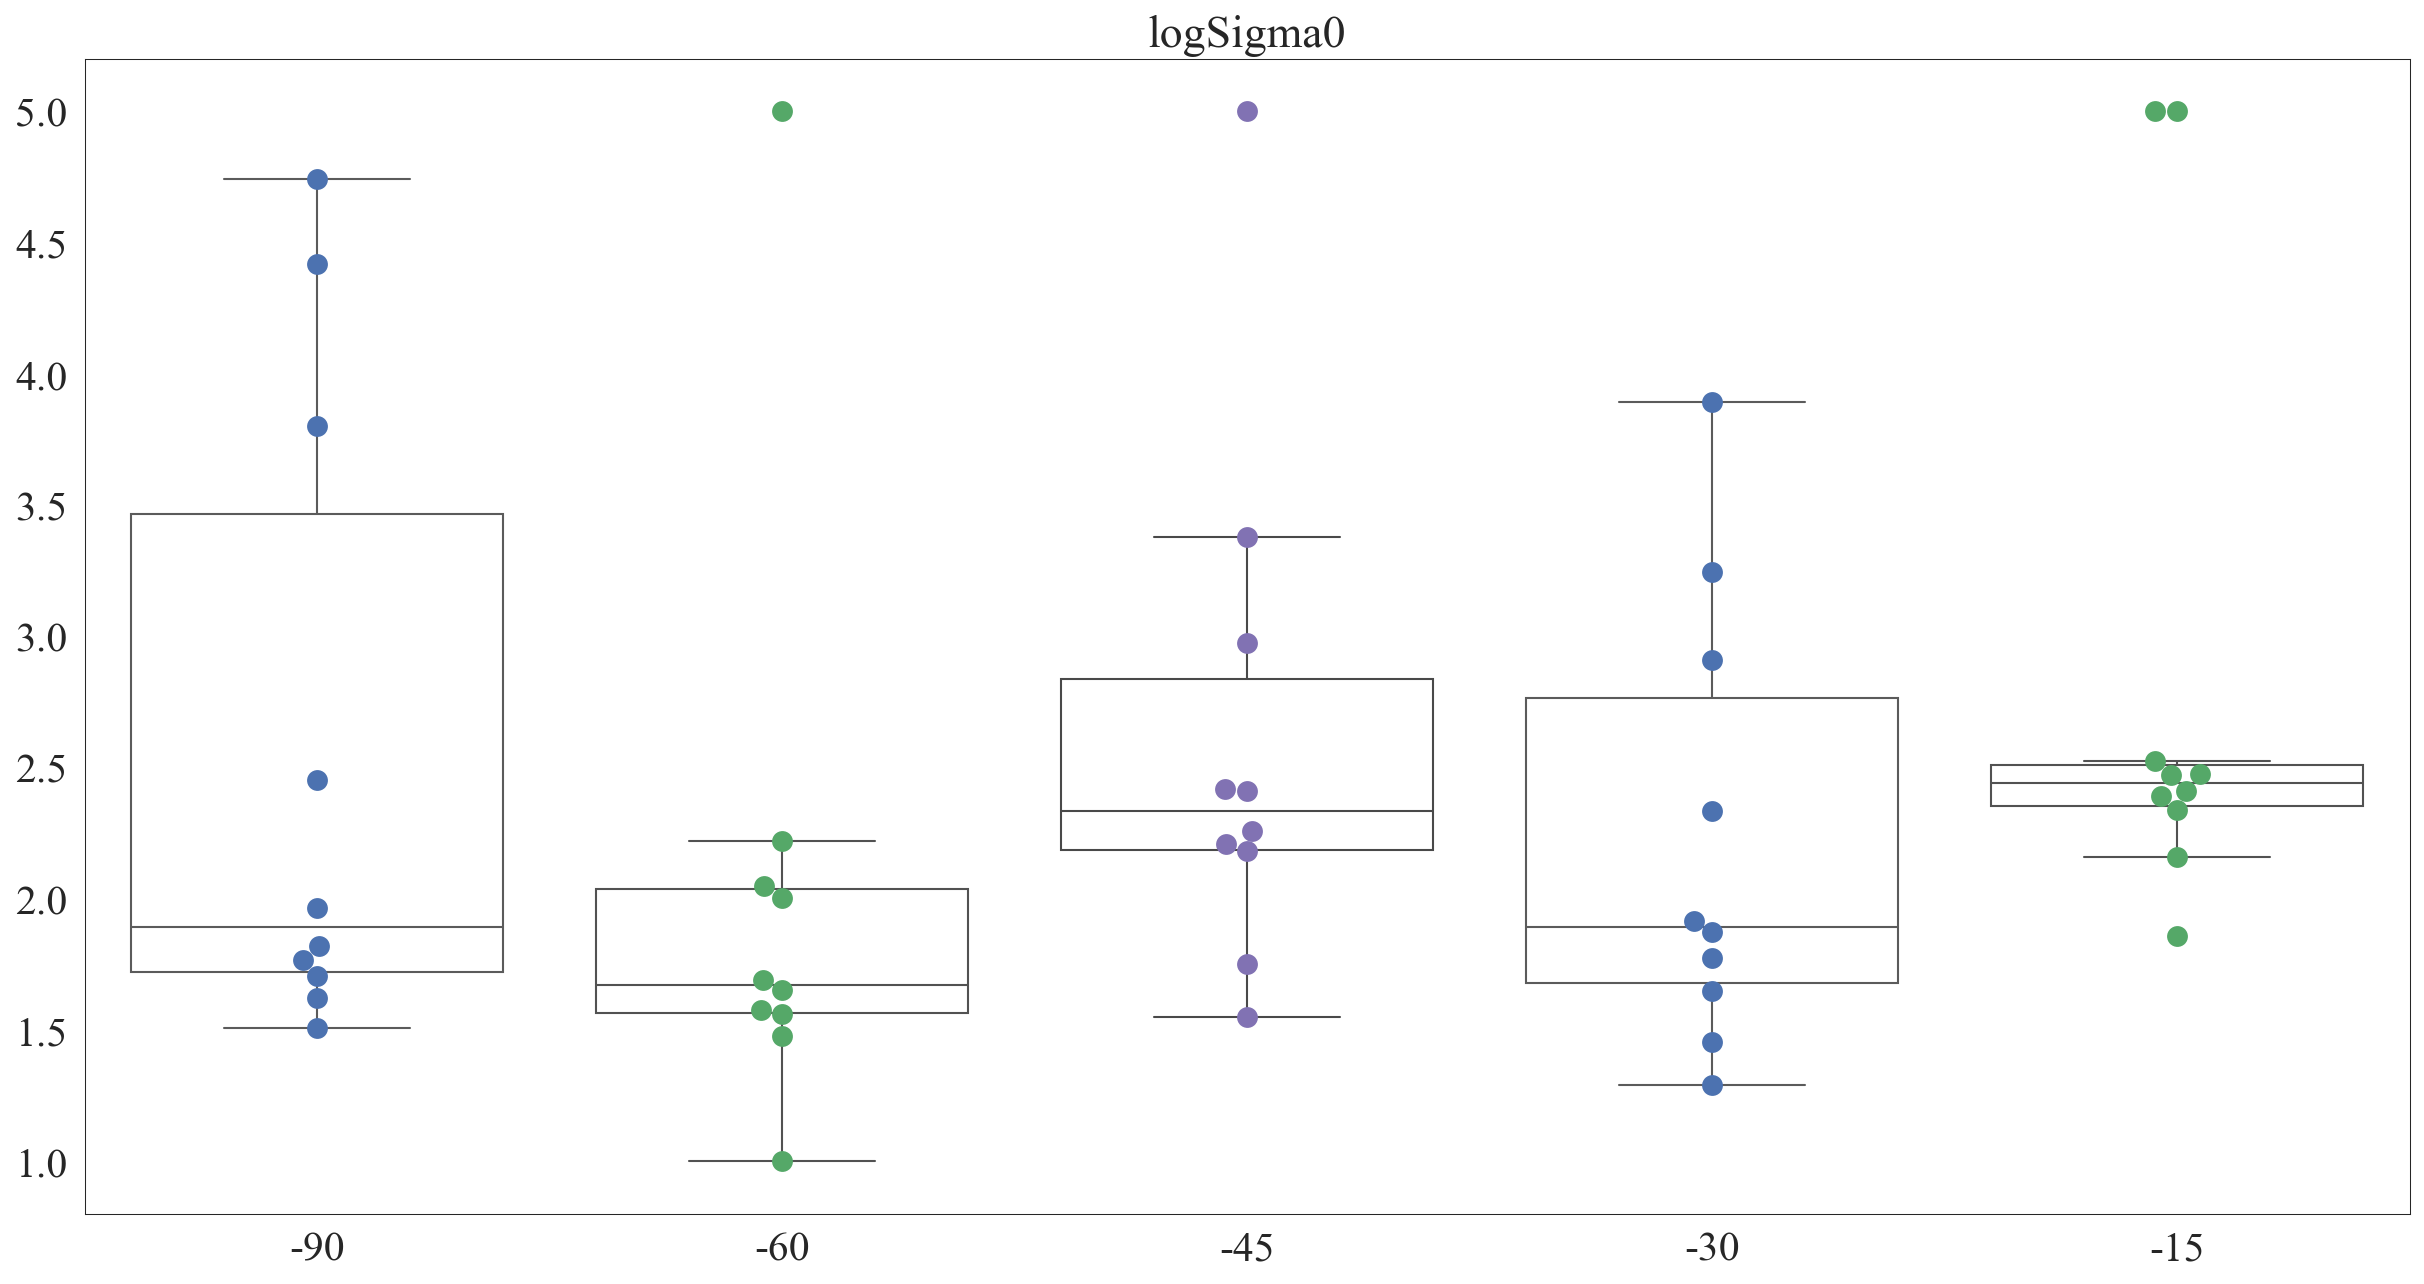

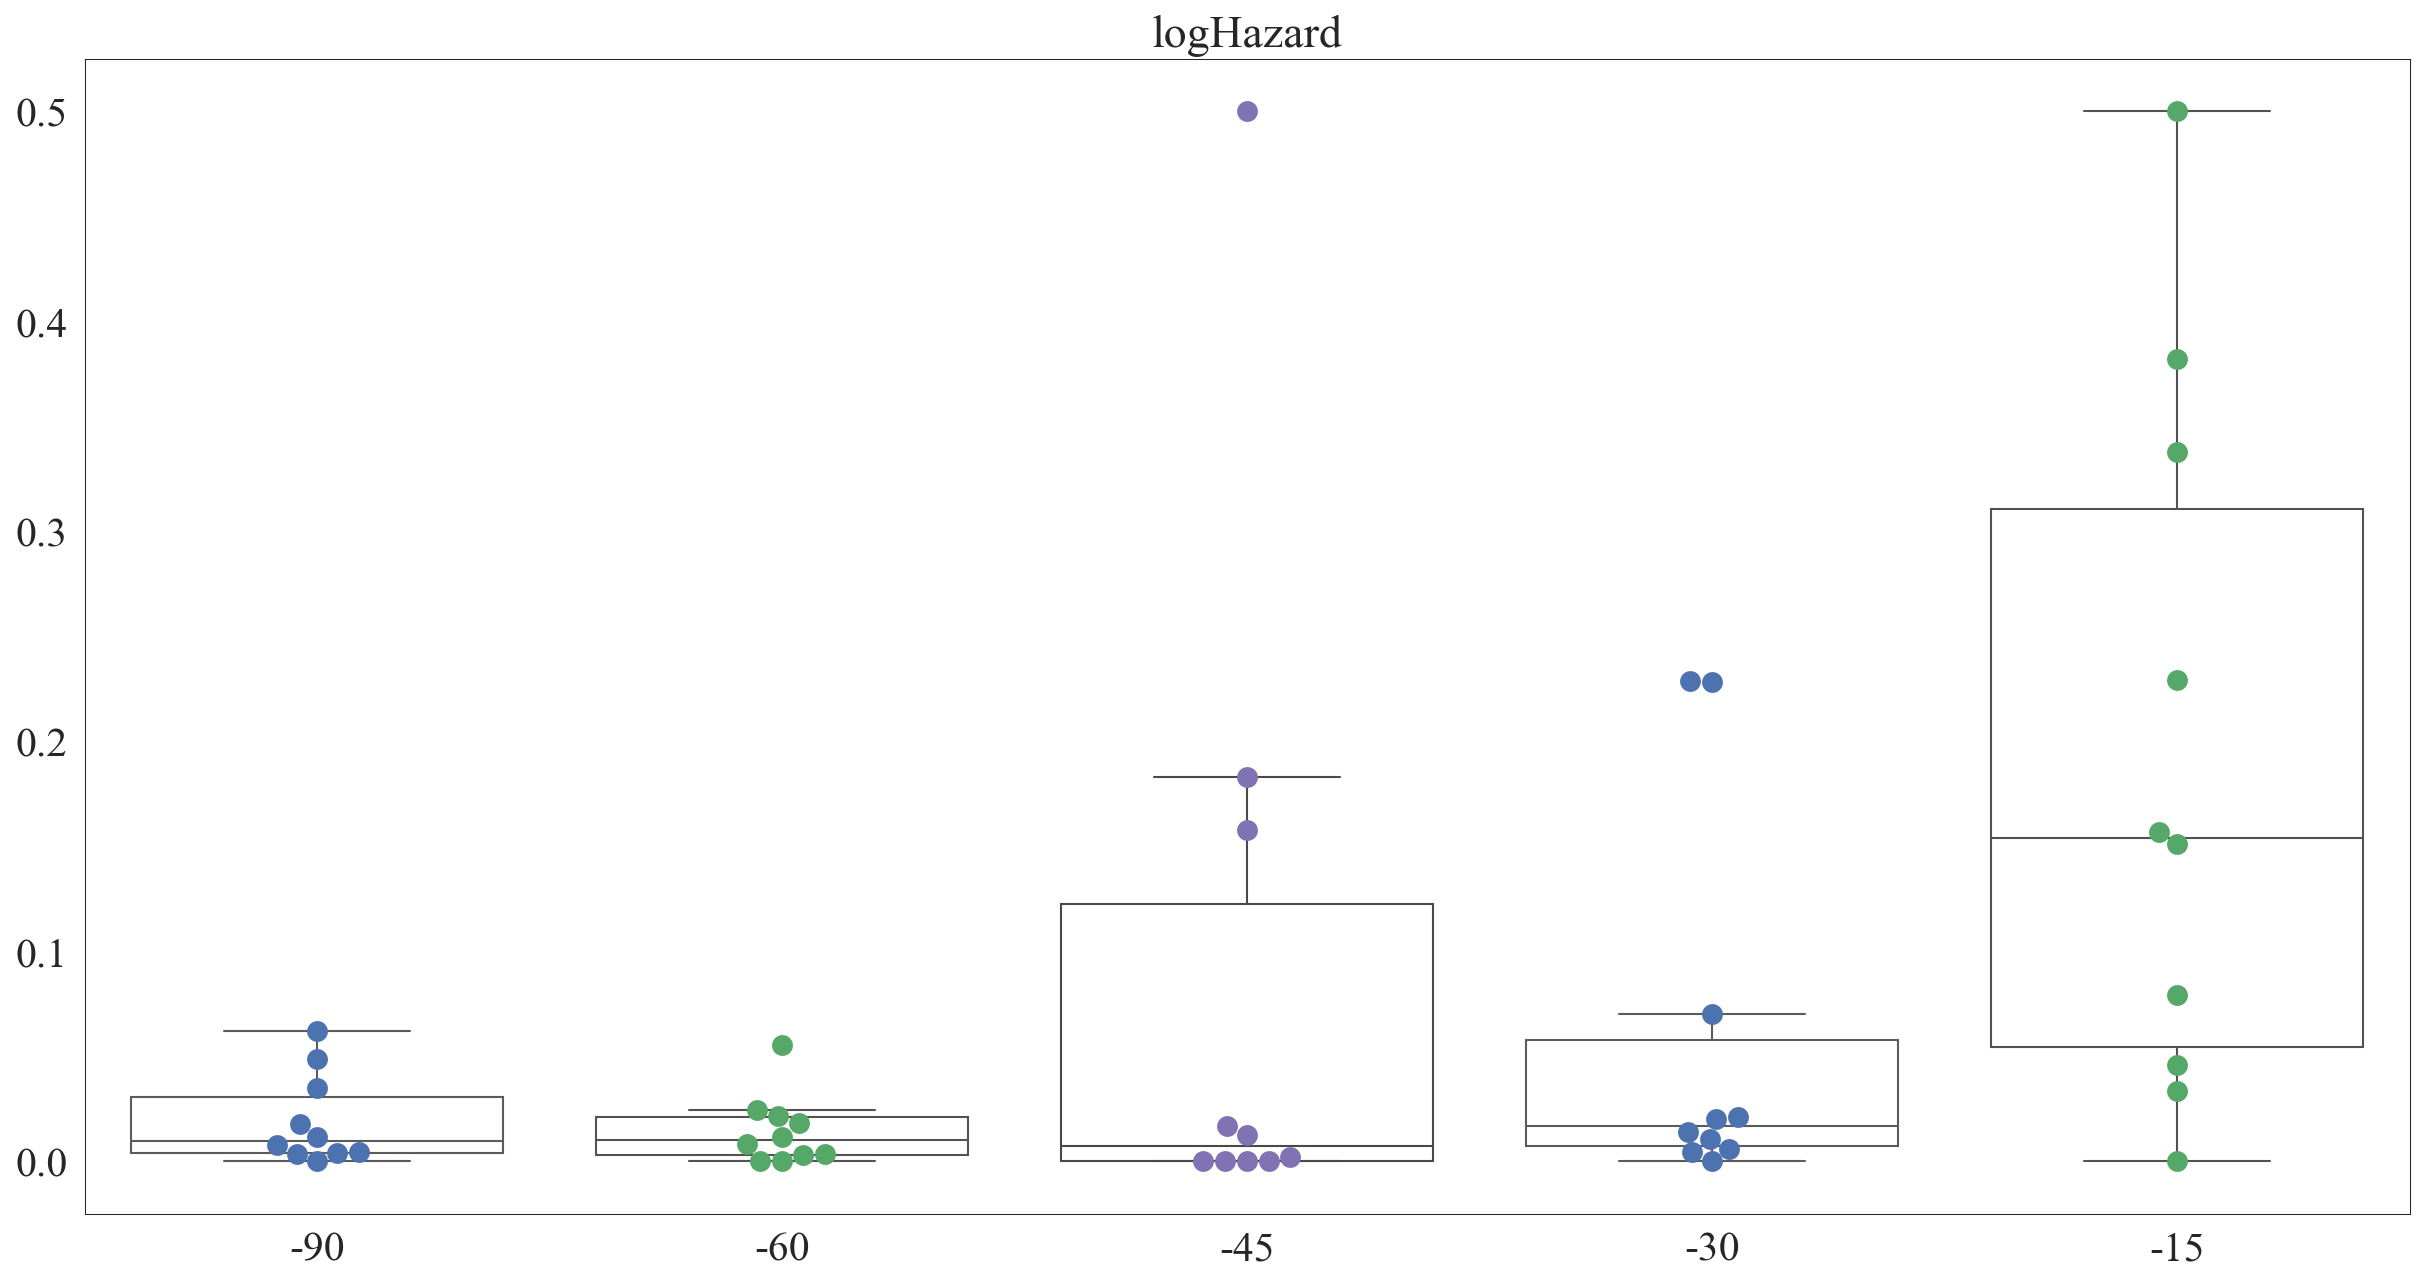

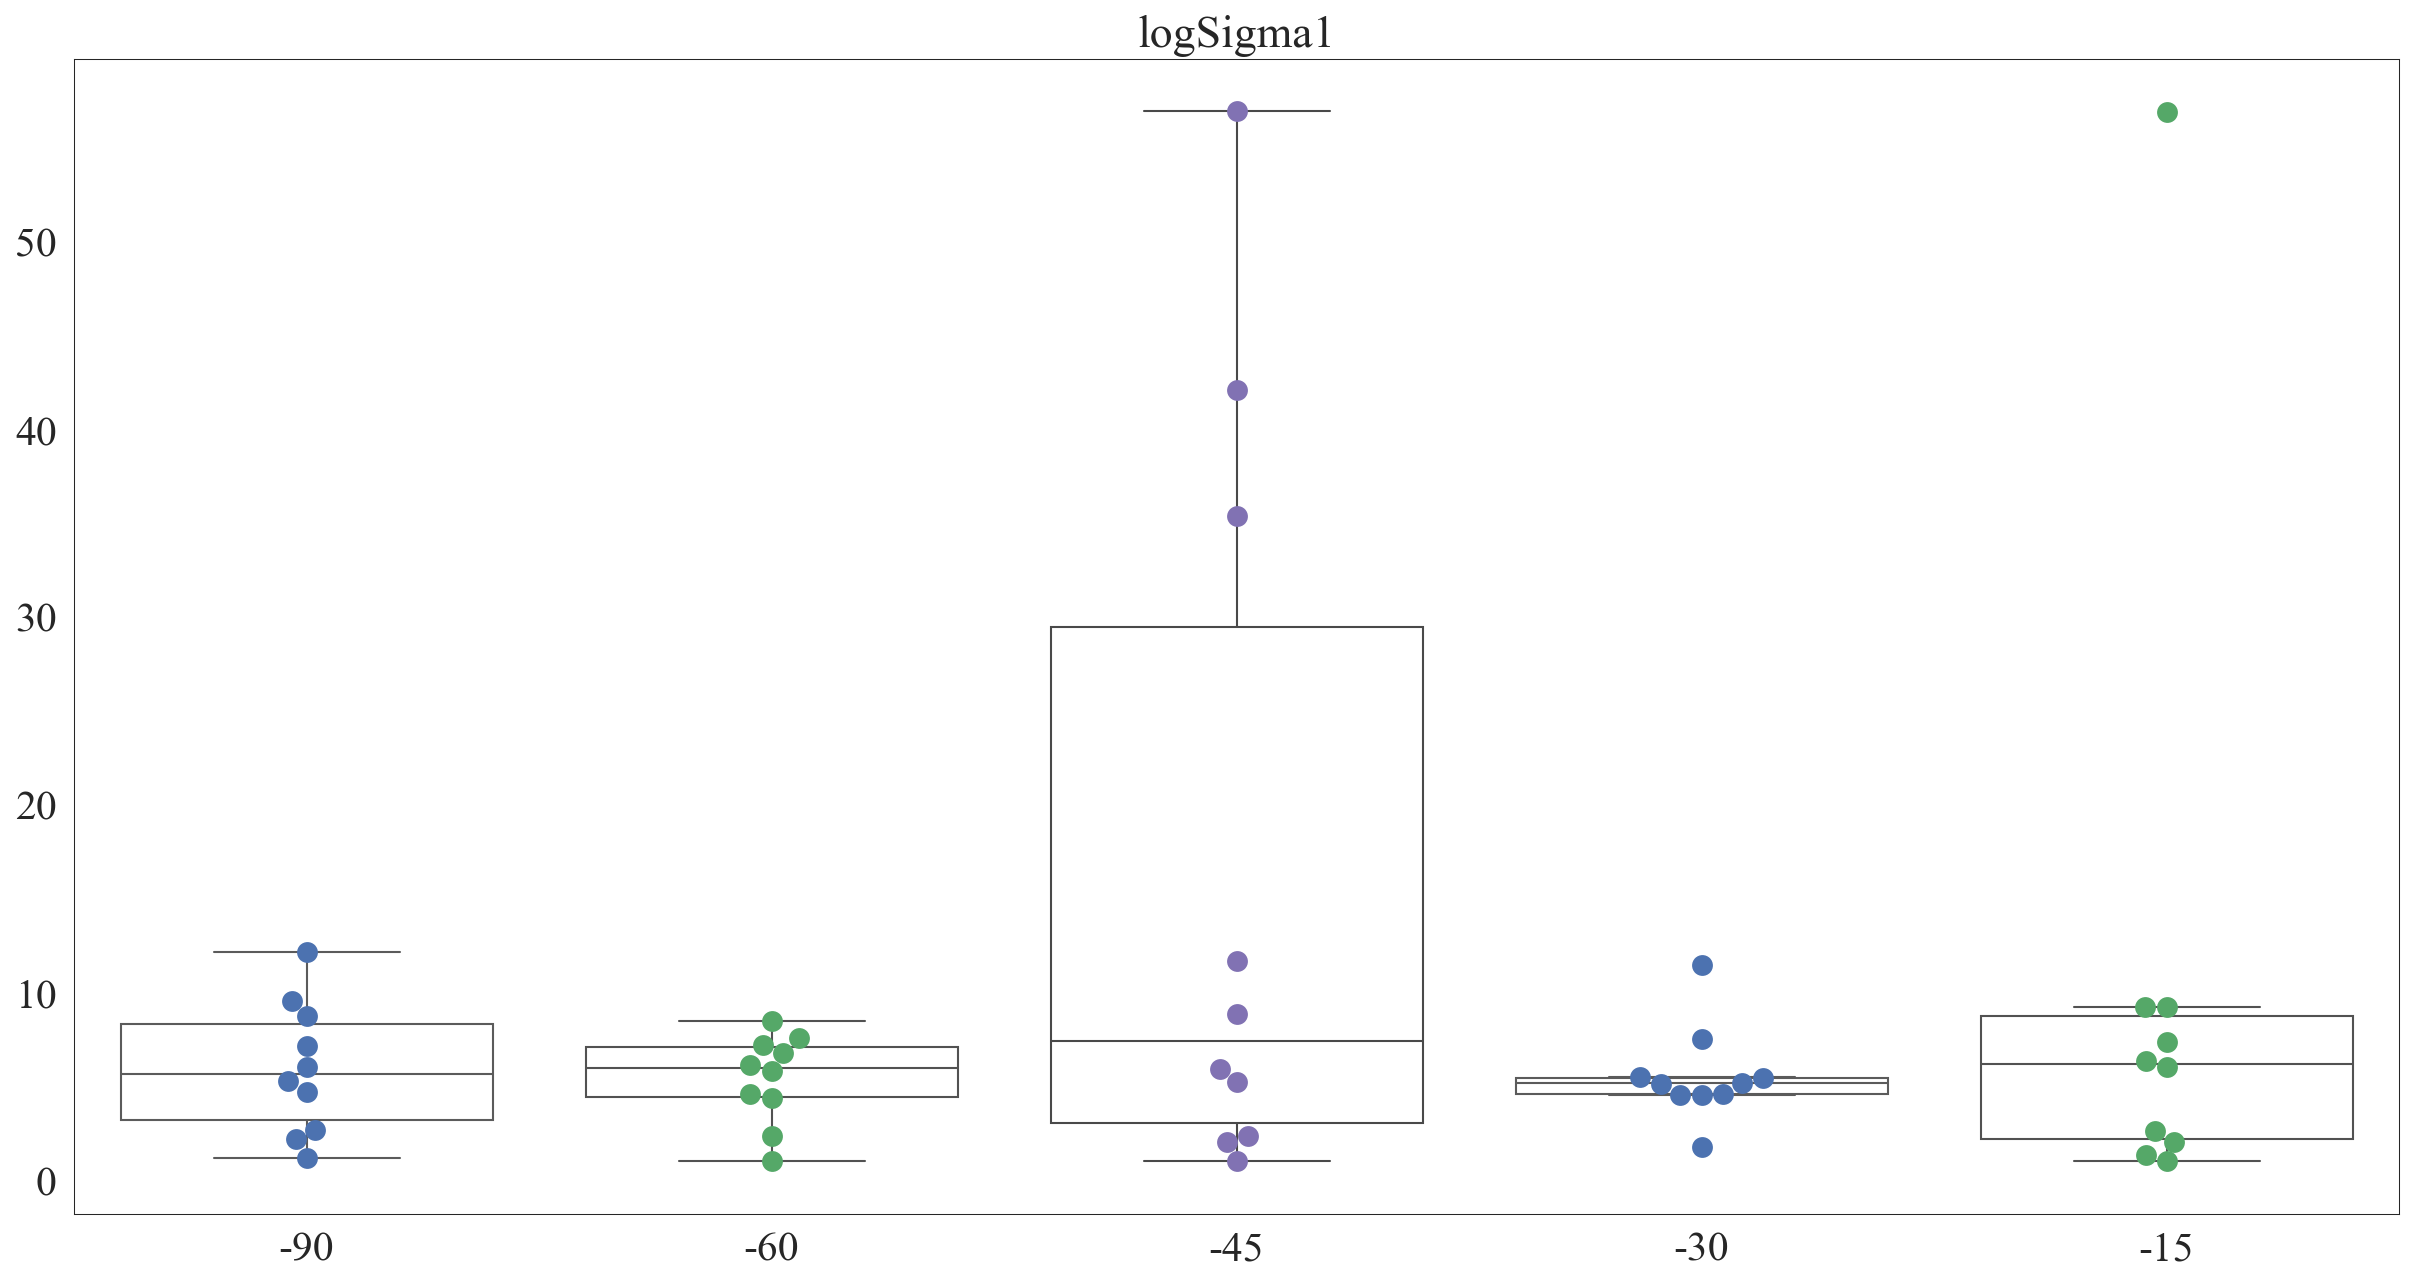

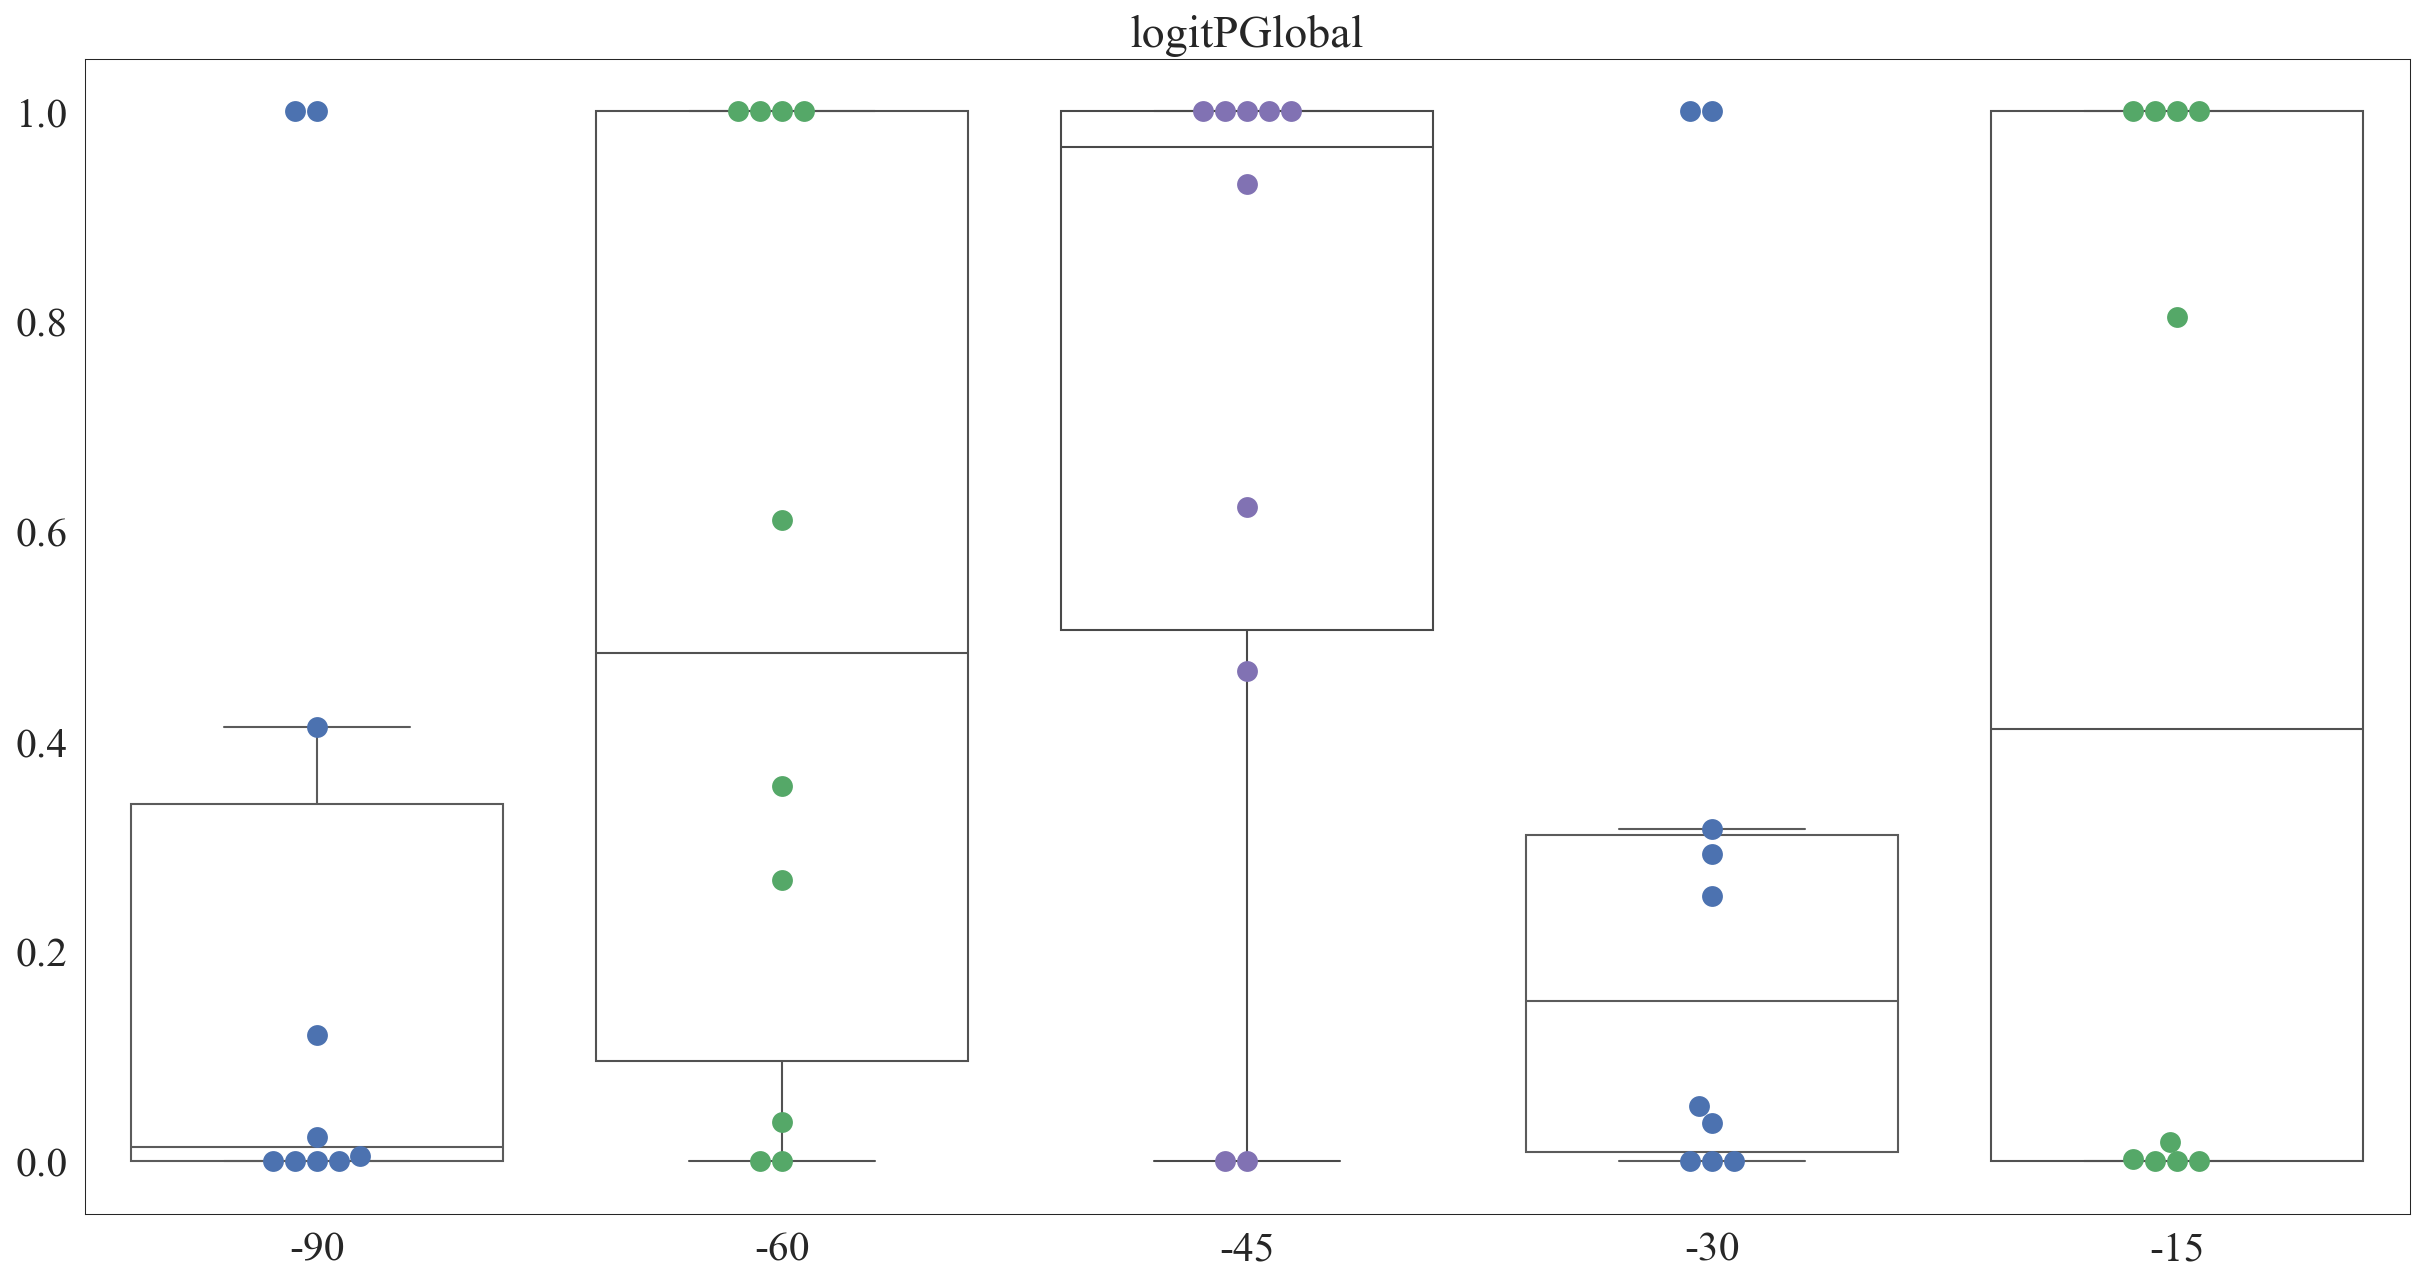

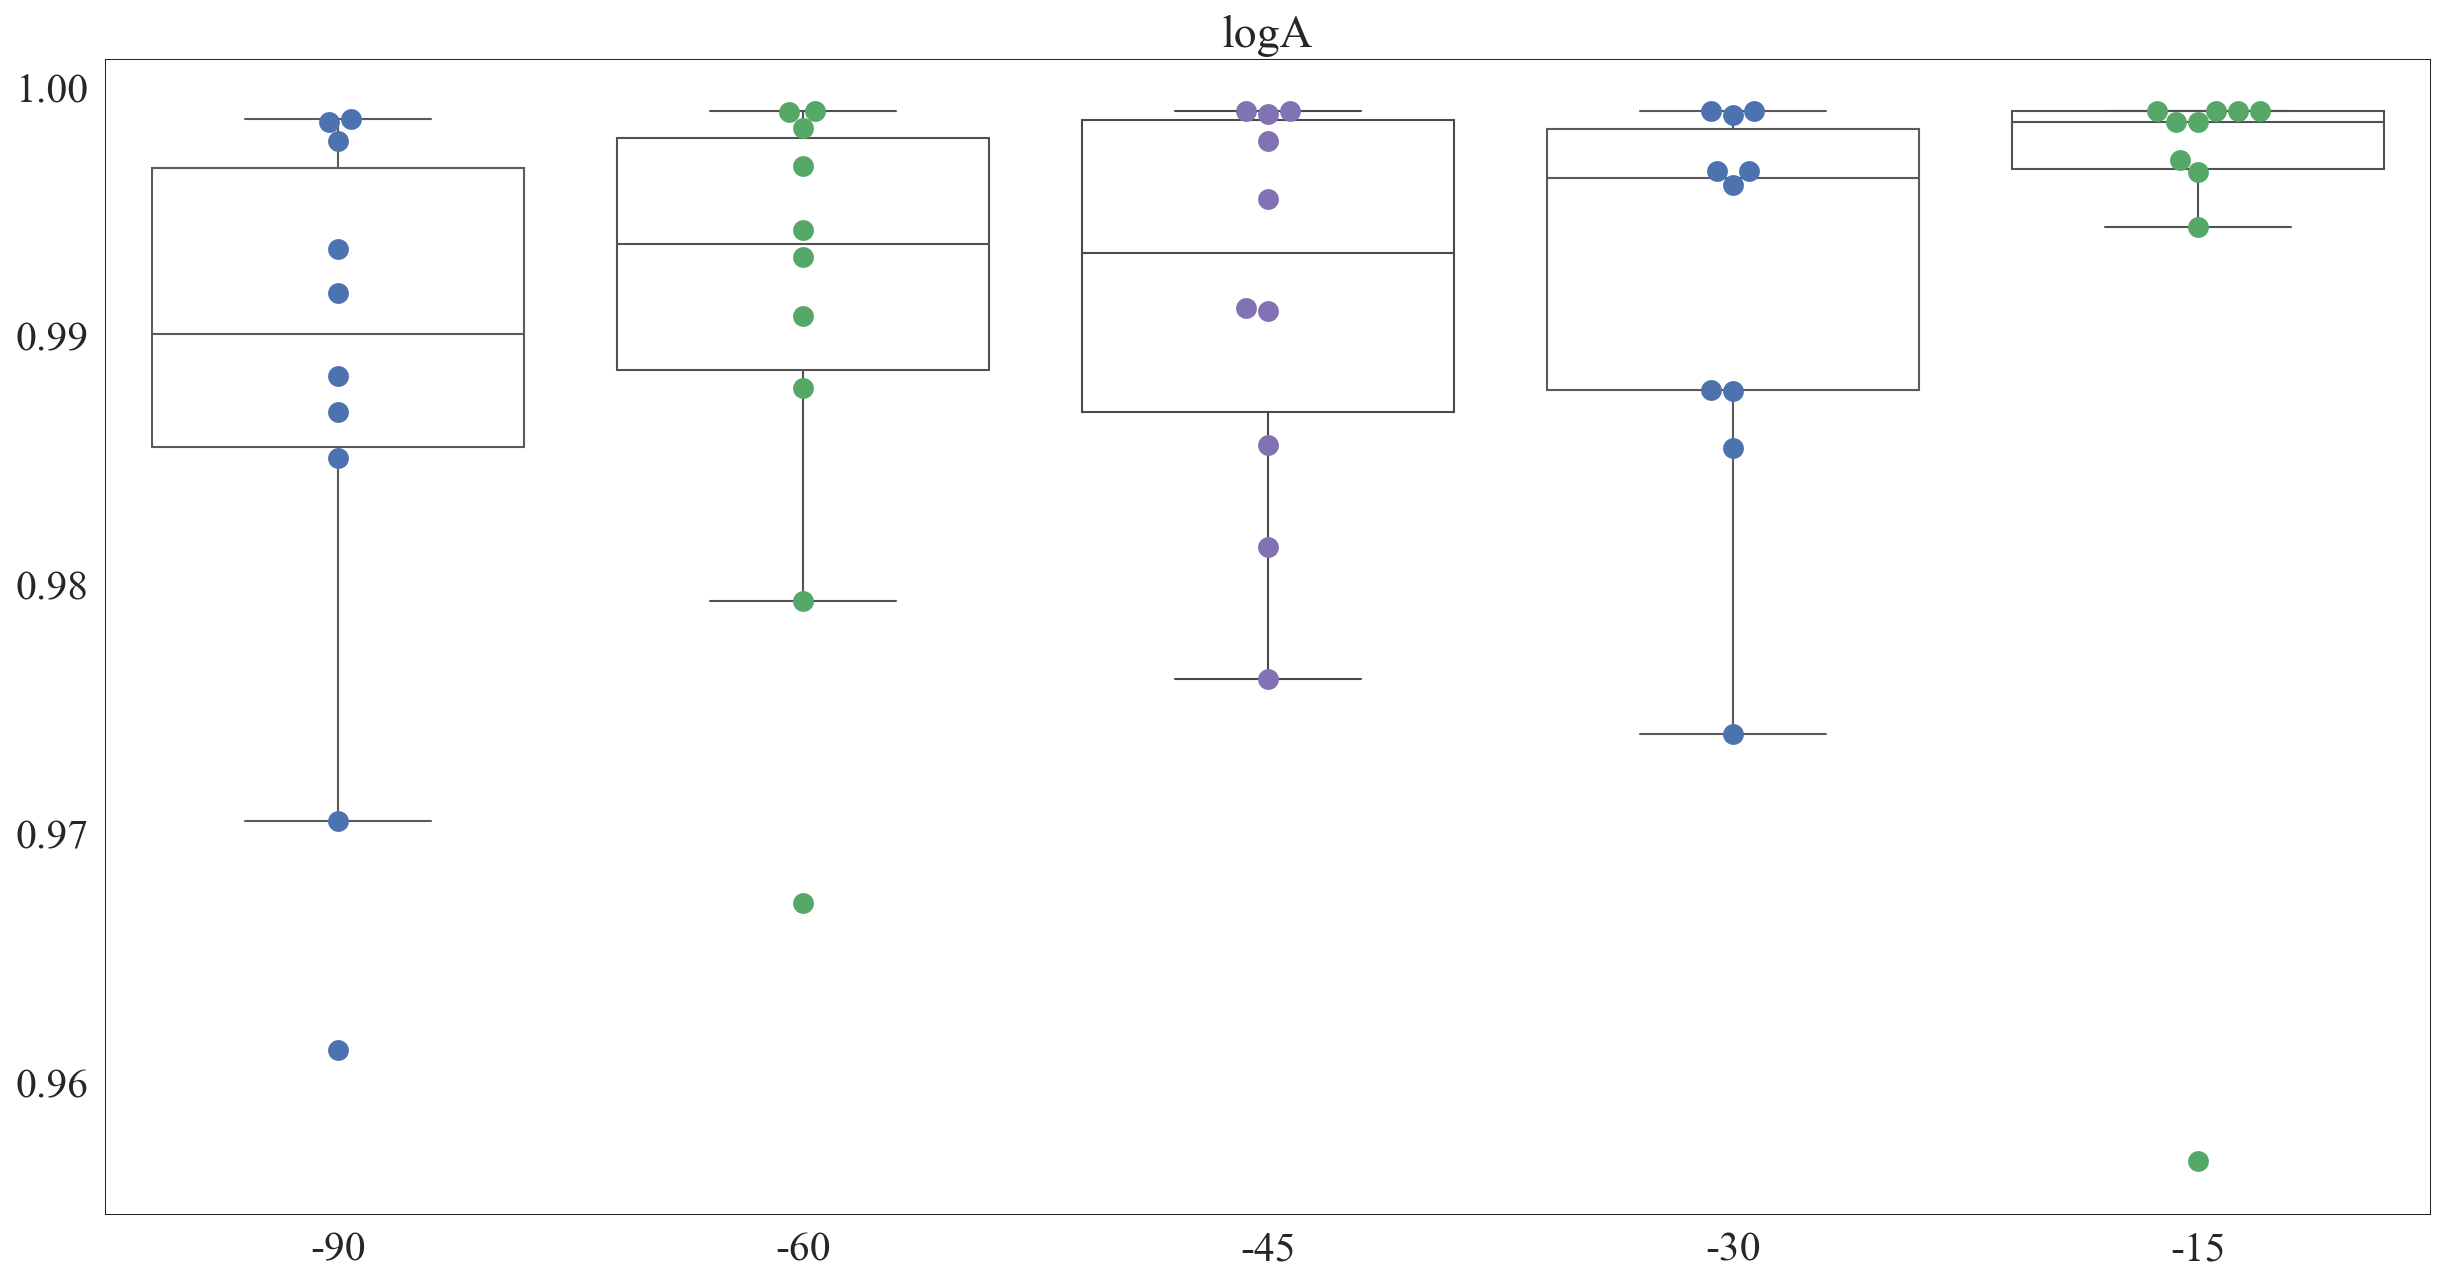

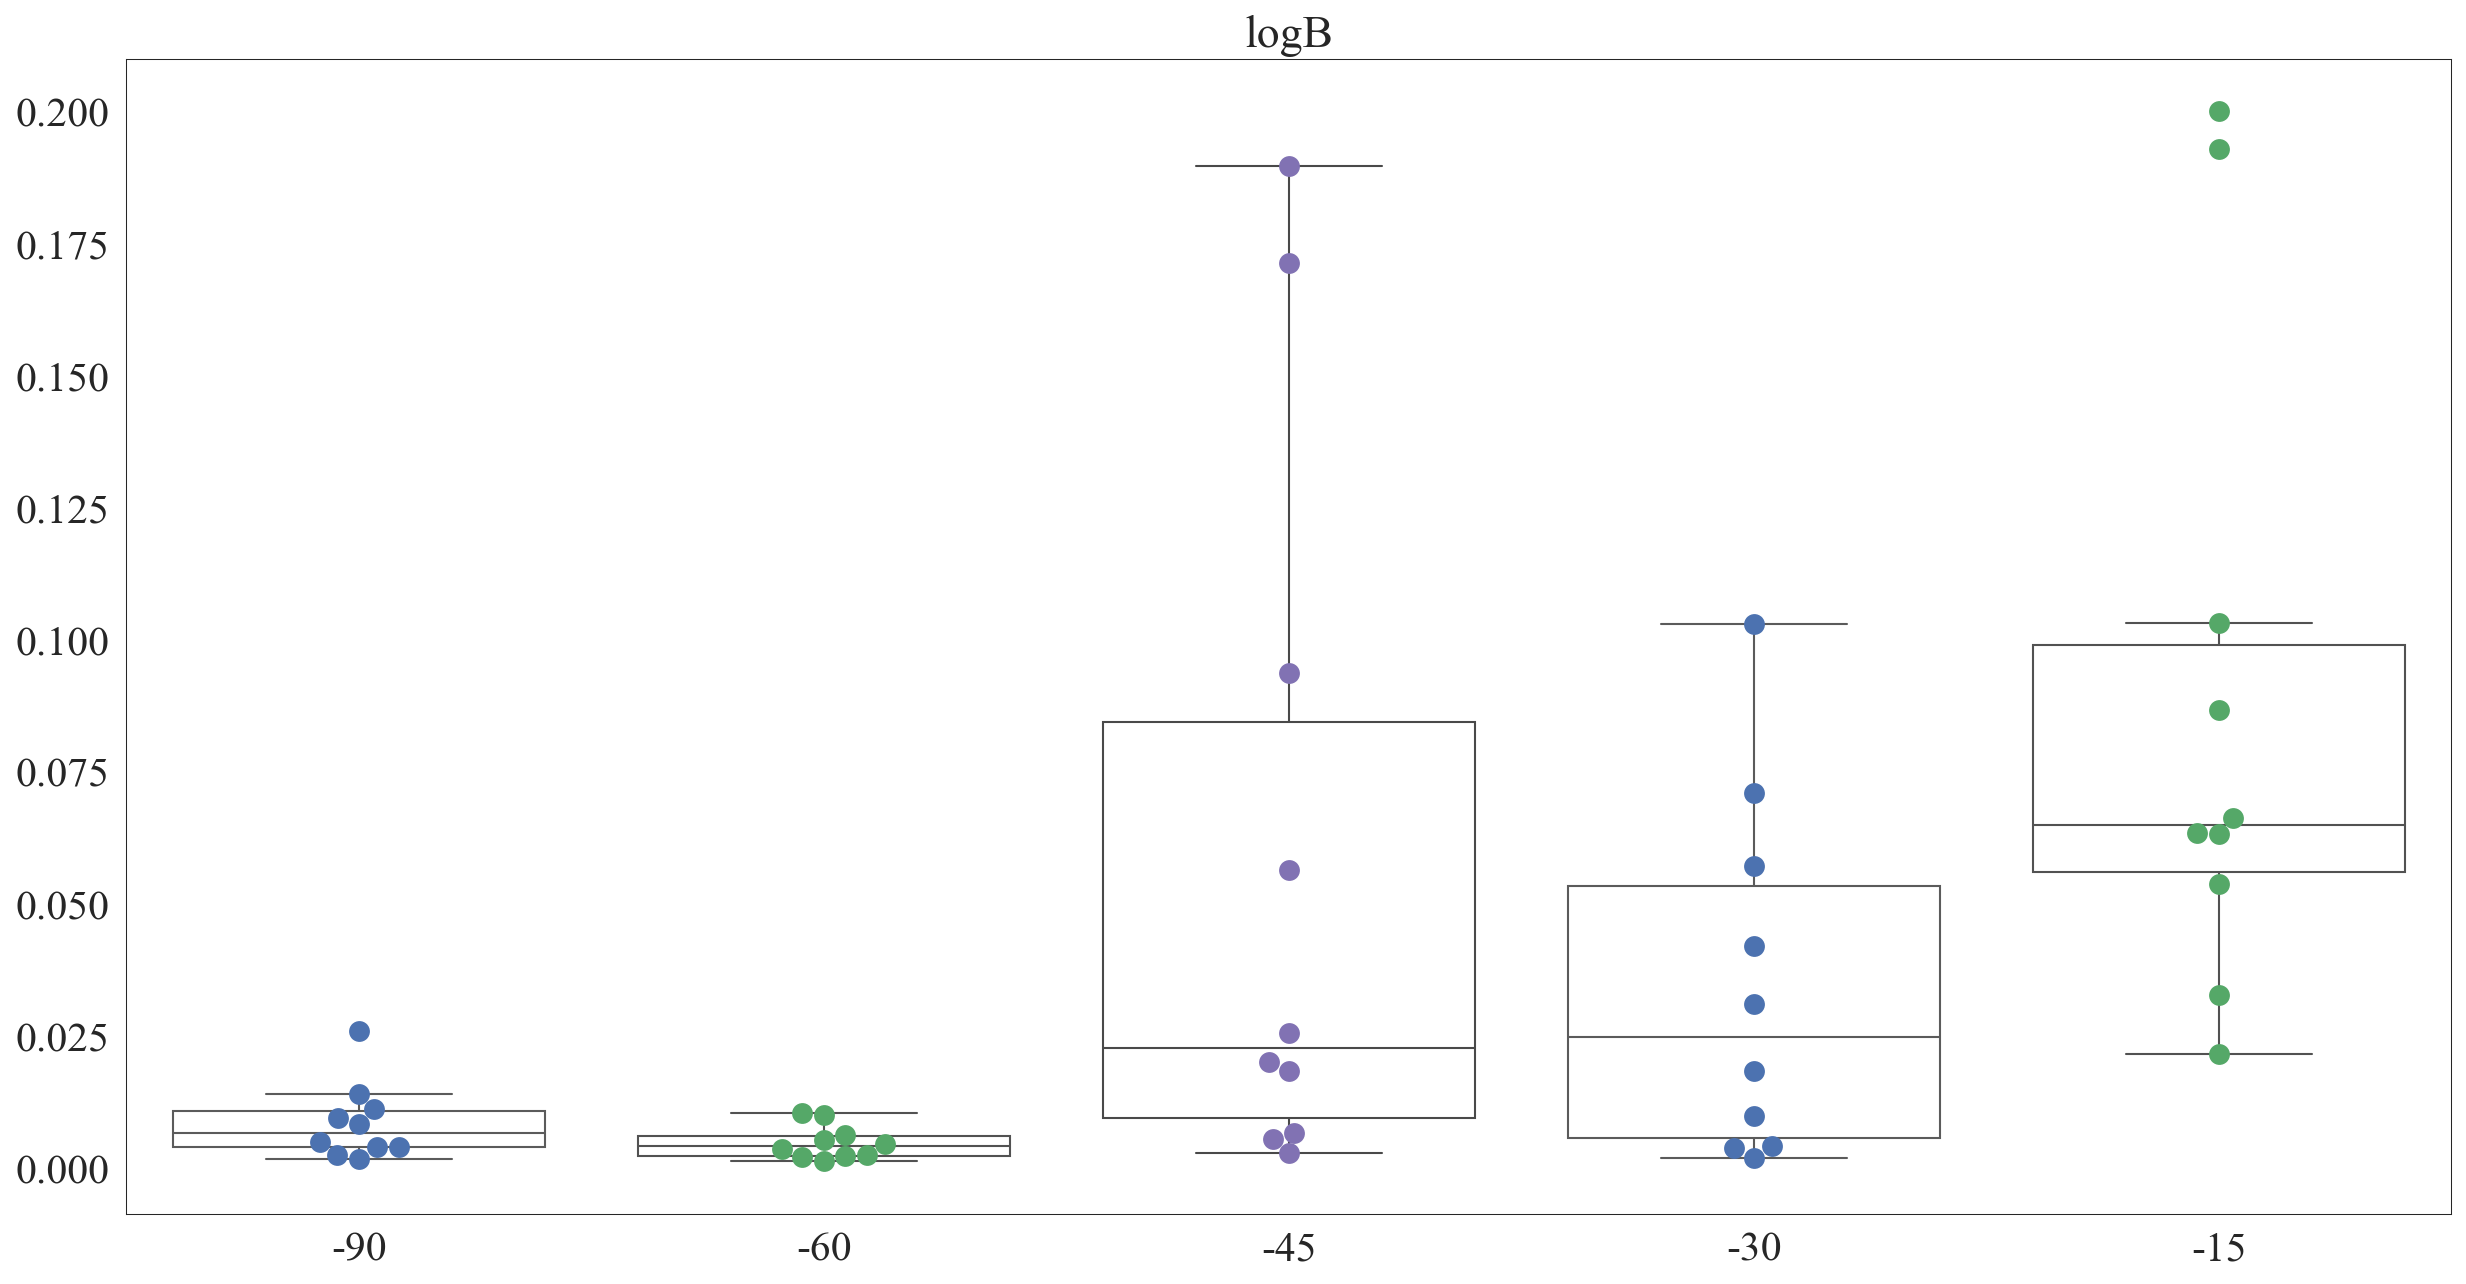

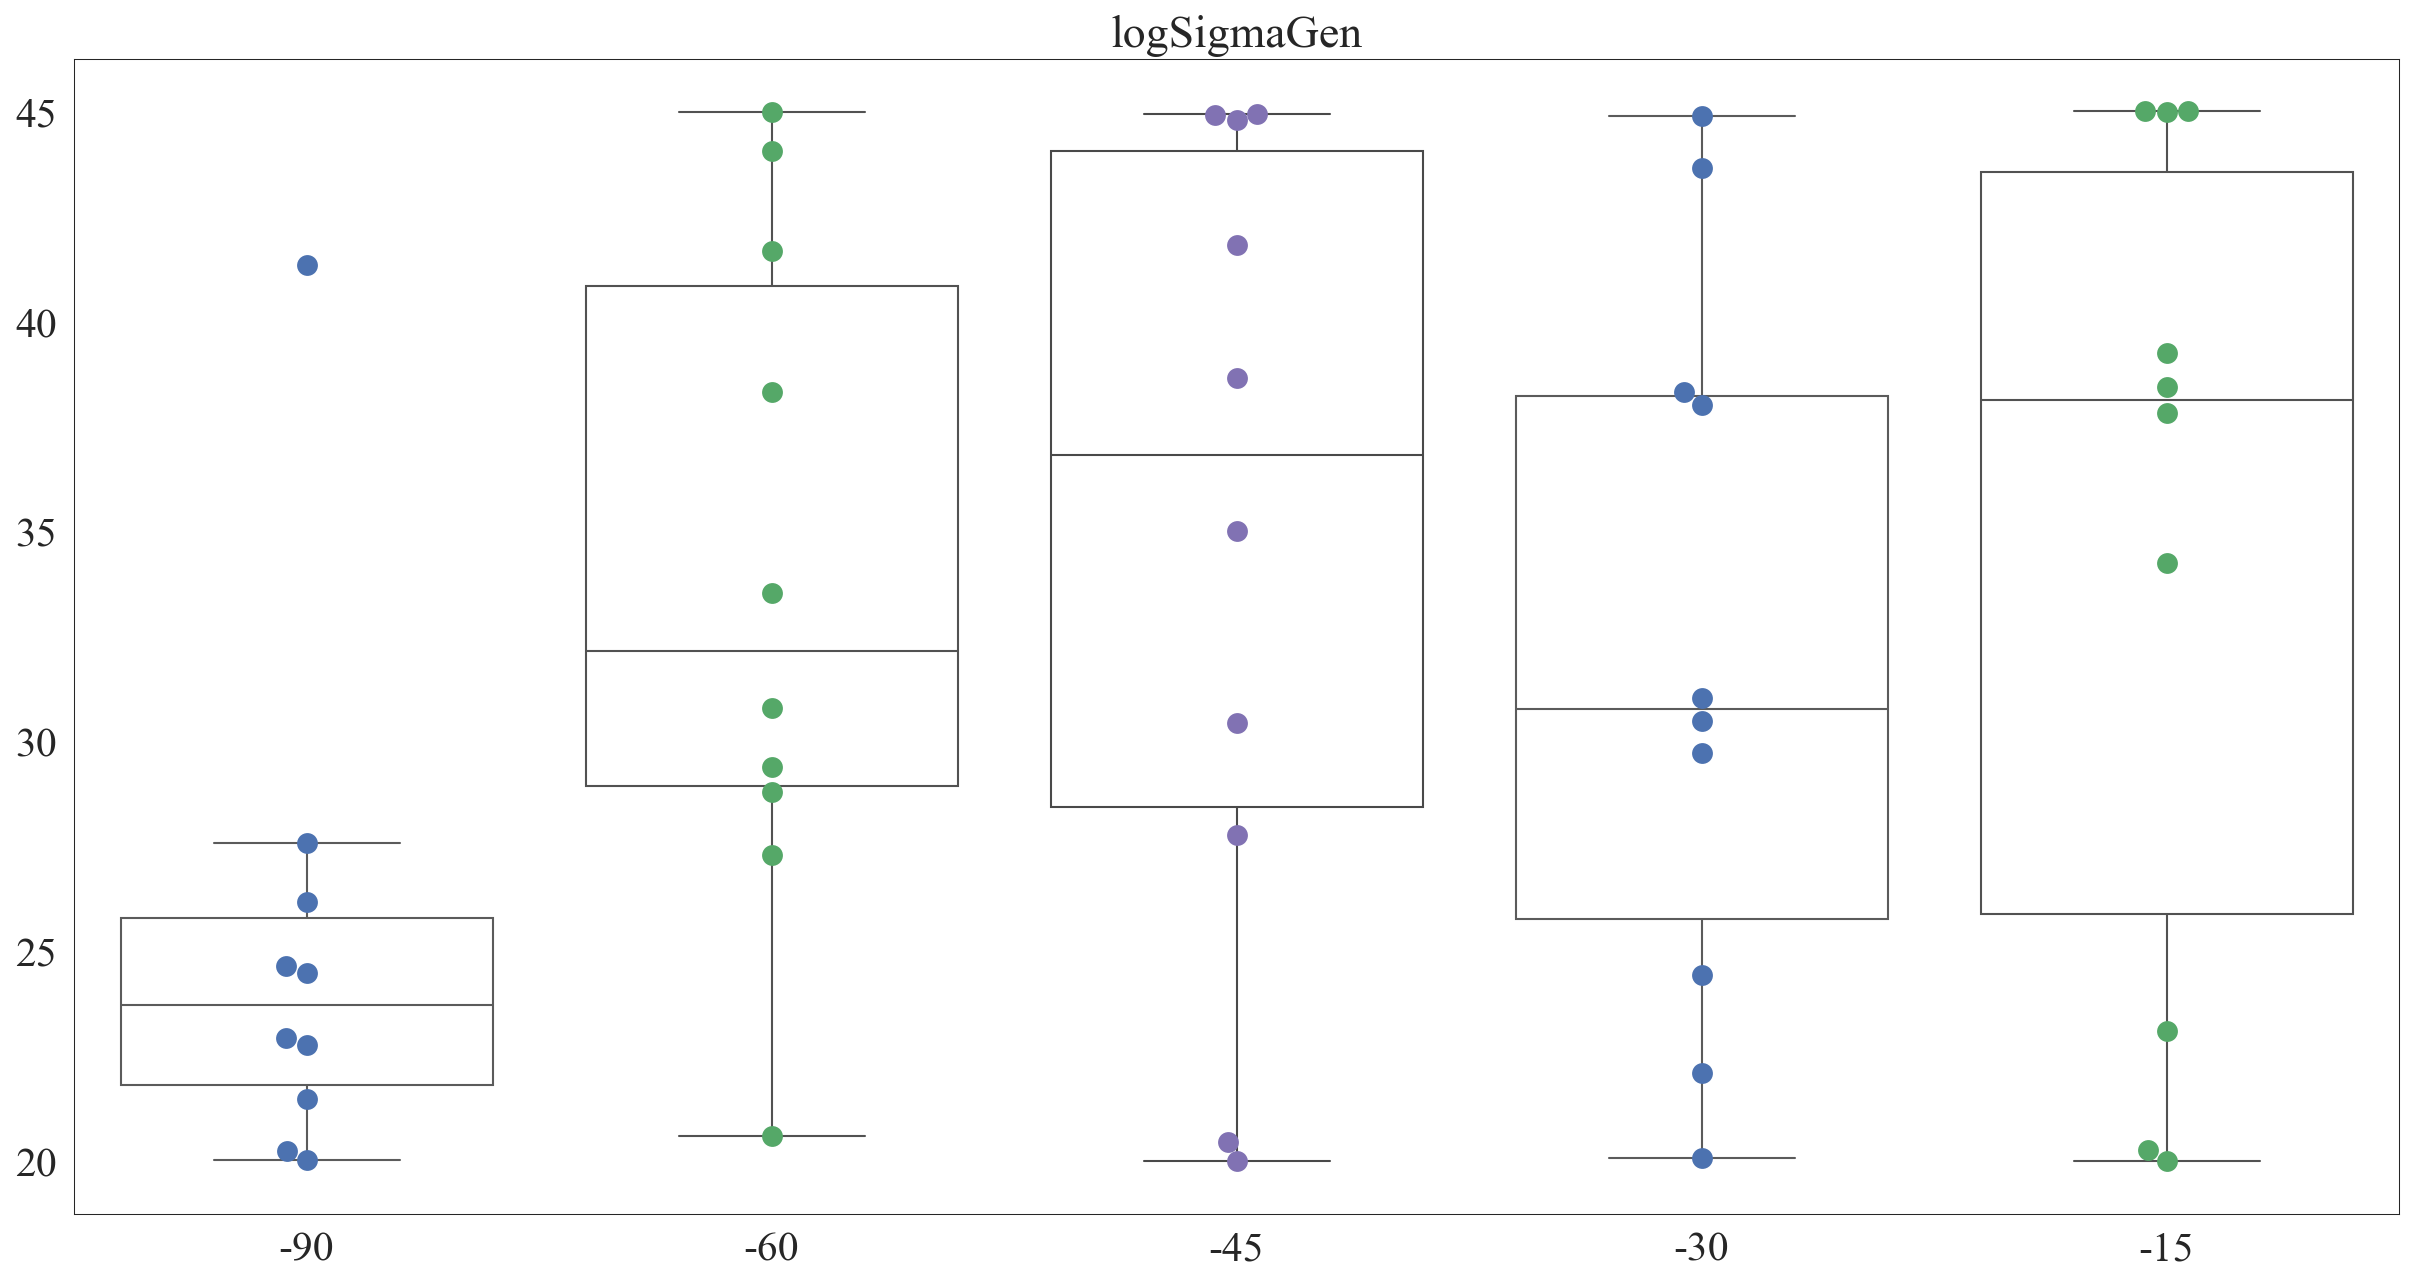

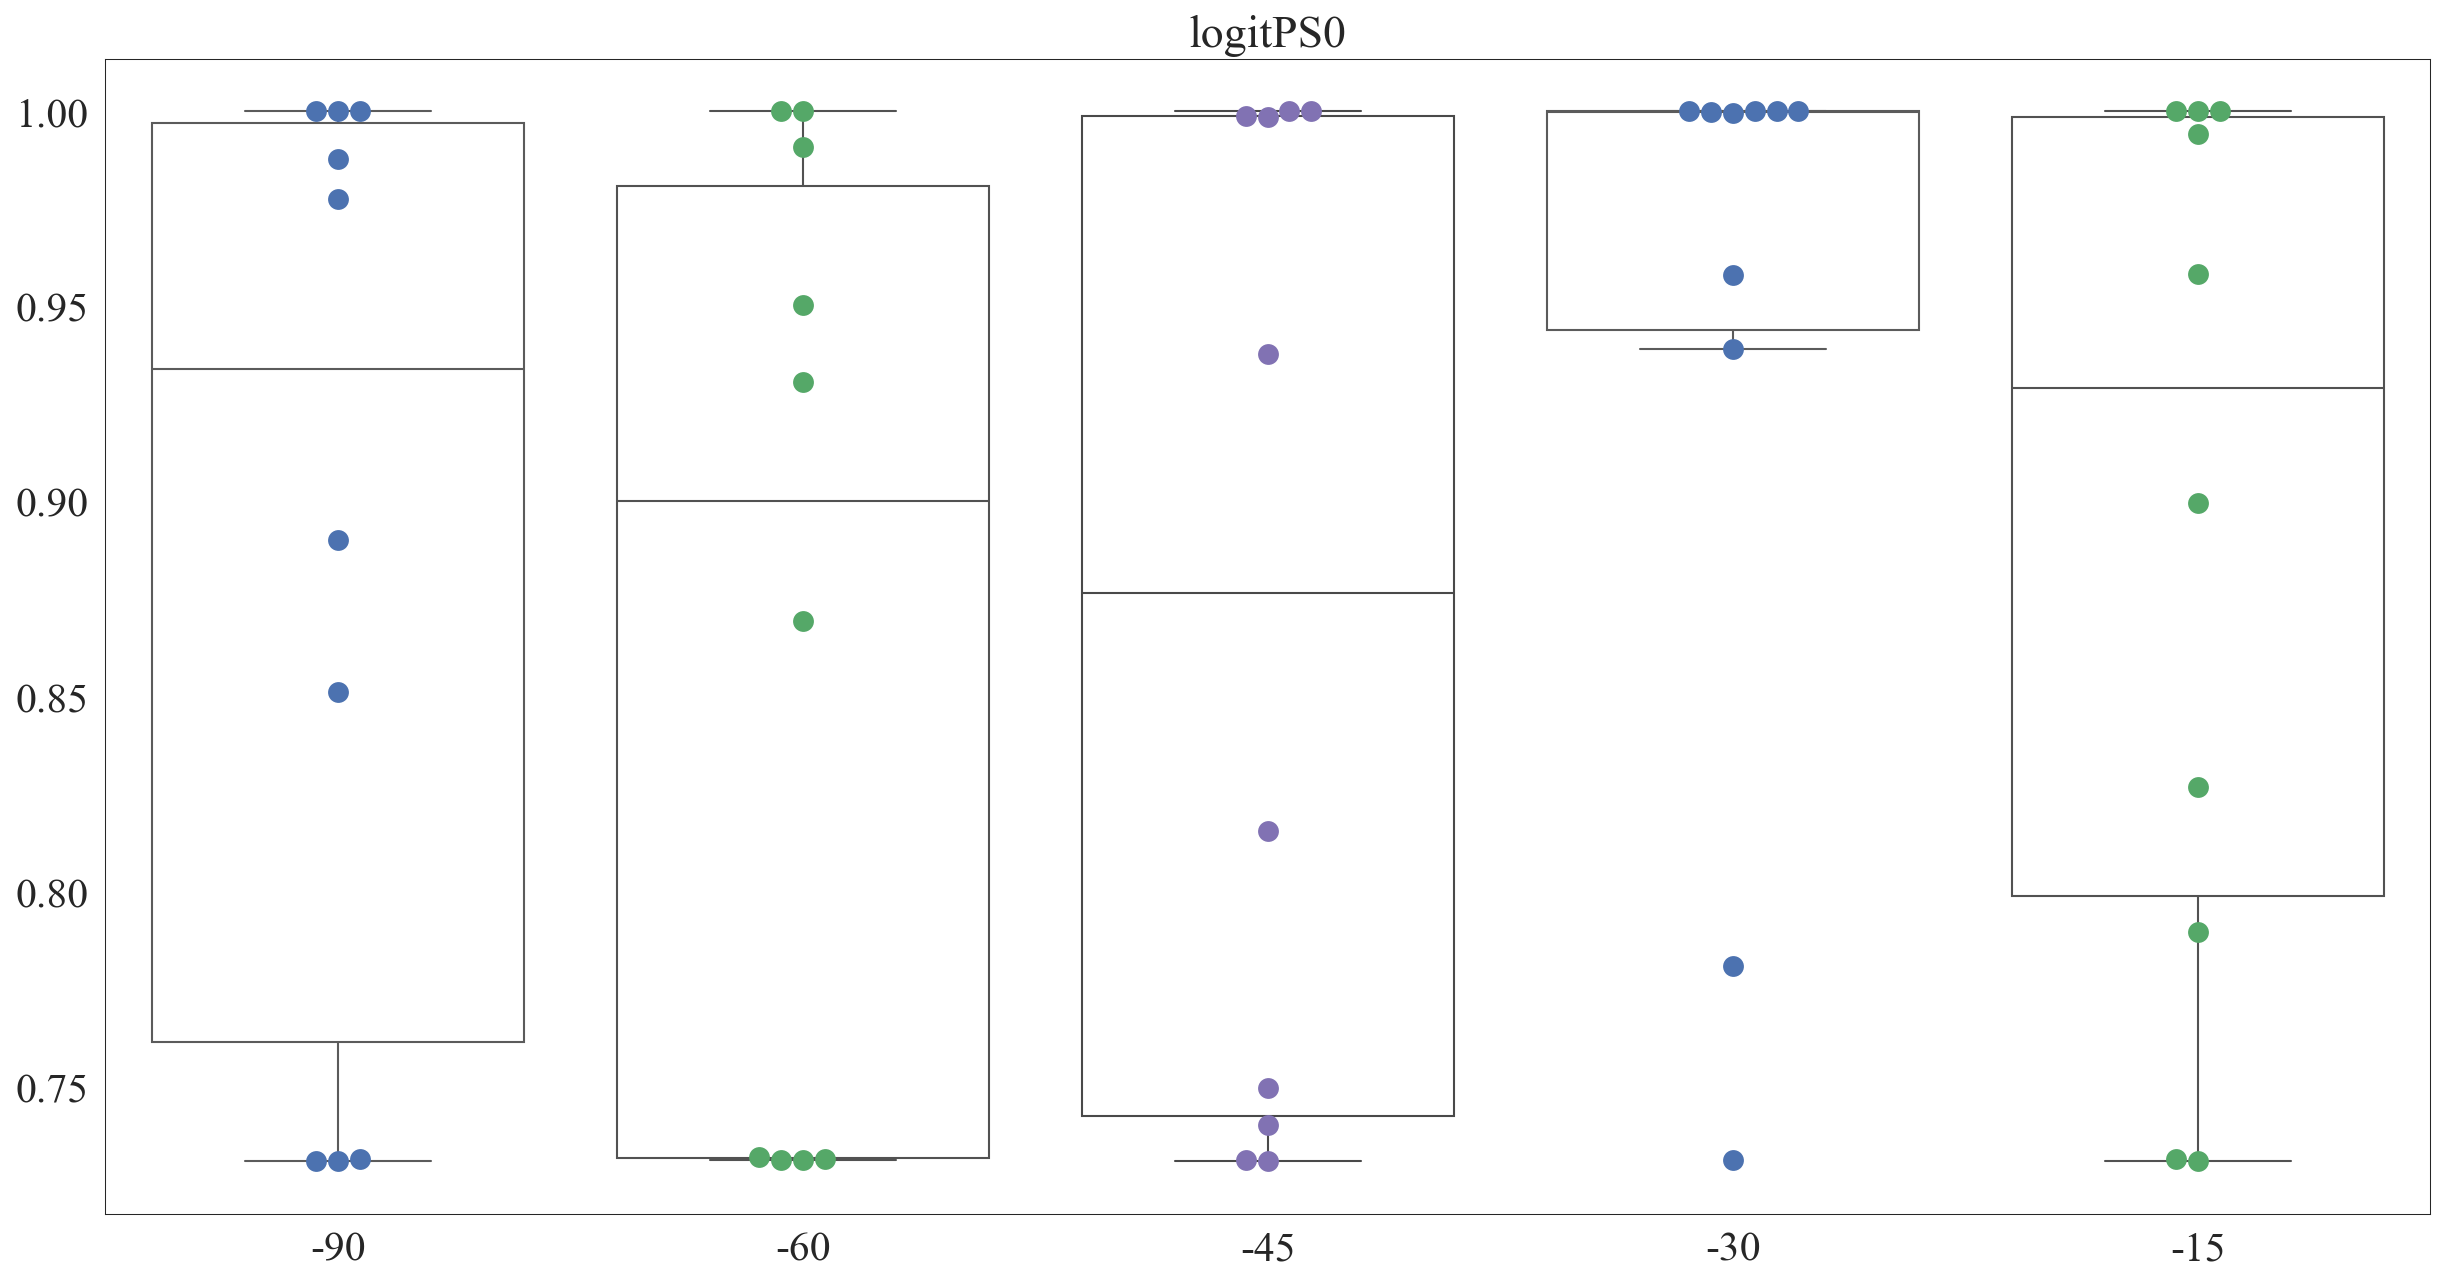

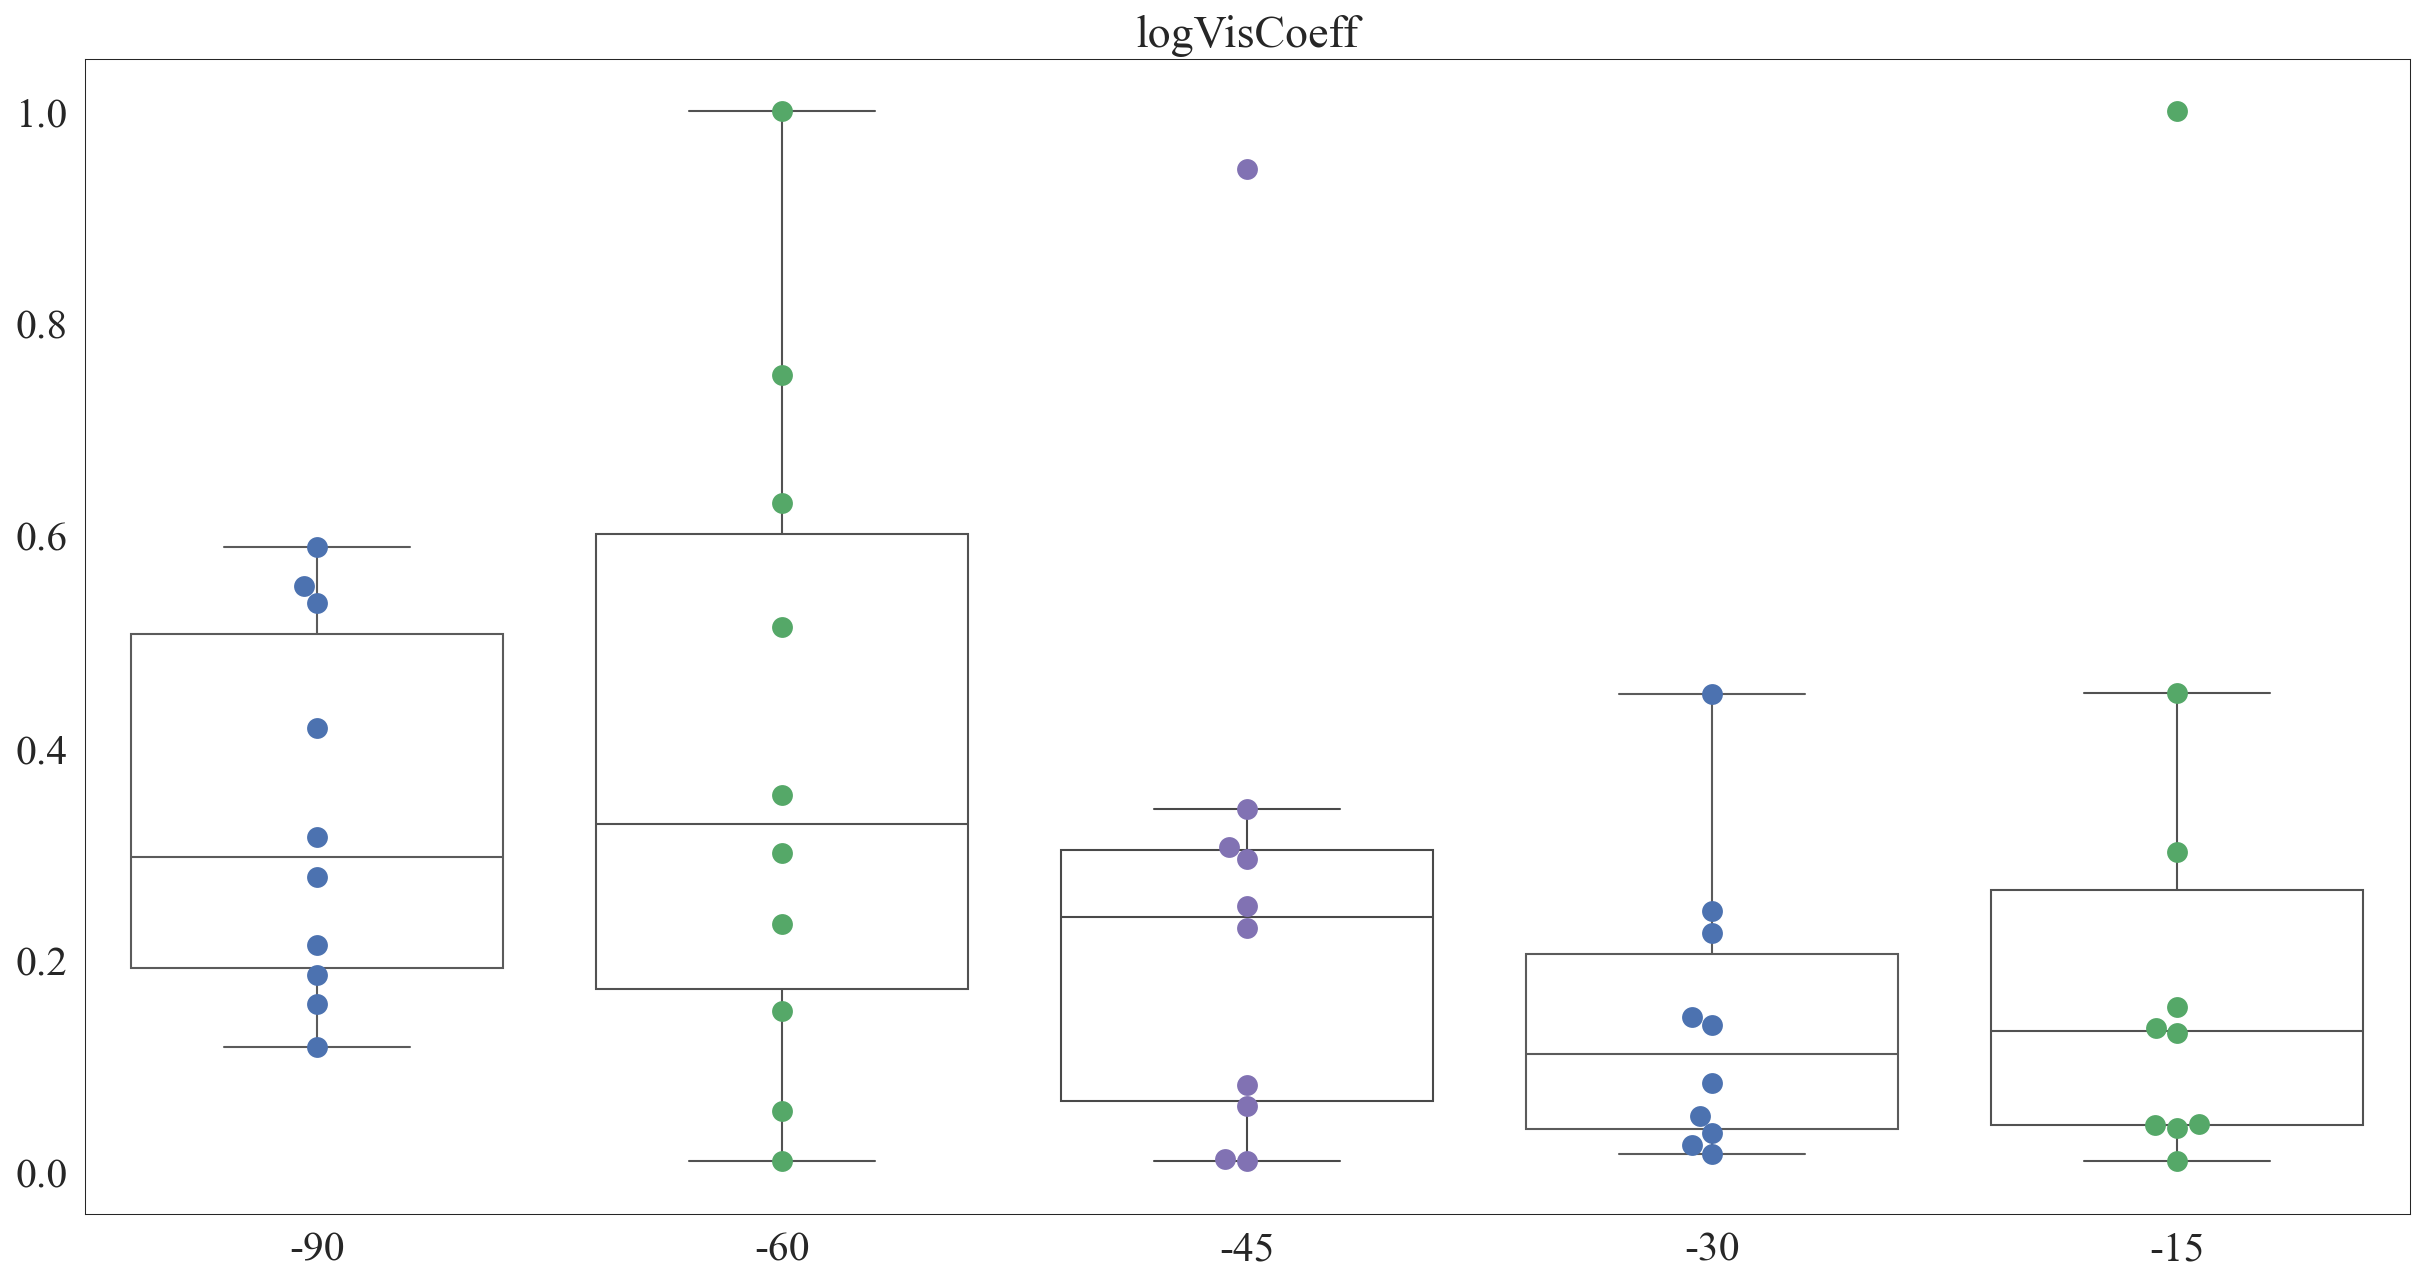

In [7]:
%matplotlib inline

rots = [-90,-60,-45,-30,-15]
for i in range(len(rots)):
    sns.swarmplot(x=rots[i],y=BTBOCD[i].rSquareds,size=10)
    sns.boxplot(x=rots[i], y=BTBOCD[i].rSquareds,boxprops=dict(facecolor="none"))
plt.title("r^2")
plt.show()
for i in range(len(rots)):
    sns.swarmplot(x=rots[i],y=BTBOCD[i].rmses,size=10)
    sns.boxplot(x=rots[i], y=BTBOCD[i].rmses,boxprops=dict(facecolor="none"))
plt.title("rmse")
plt.show()
for i in range(len(rots)):
    sns.swarmplot(x=rots[i],y=BTBOCD[i].bics,size=10)
    sns.boxplot(x=rots[i], y=BTBOCD[i].bics,boxprops=dict(facecolor="none"))
plt.title("bic")
plt.show()
paramLabs = ["logSigma0", "logHazard", "logSigma1", "logitPGlobal",
             "logA", "logB", "logSigmaGen", "logitPS0", "logVisCoeff"]
k = 0
for lab in paramLabs:
    for i in range(len(rots)):
        sns.swarmplot(x=rots[i],y=[BTBOCD[i].xs[j][k] for j in range(len(BTBOCD[i].xs))],size=10)
        sns.boxplot(x=rots[i], y=[BTBOCD[i].xs[j][k] for j in range(len(BTBOCD[i].xs))],boxprops=dict(facecolor="none"))
    plt.title(lab)
    plt.show()
    k += 1

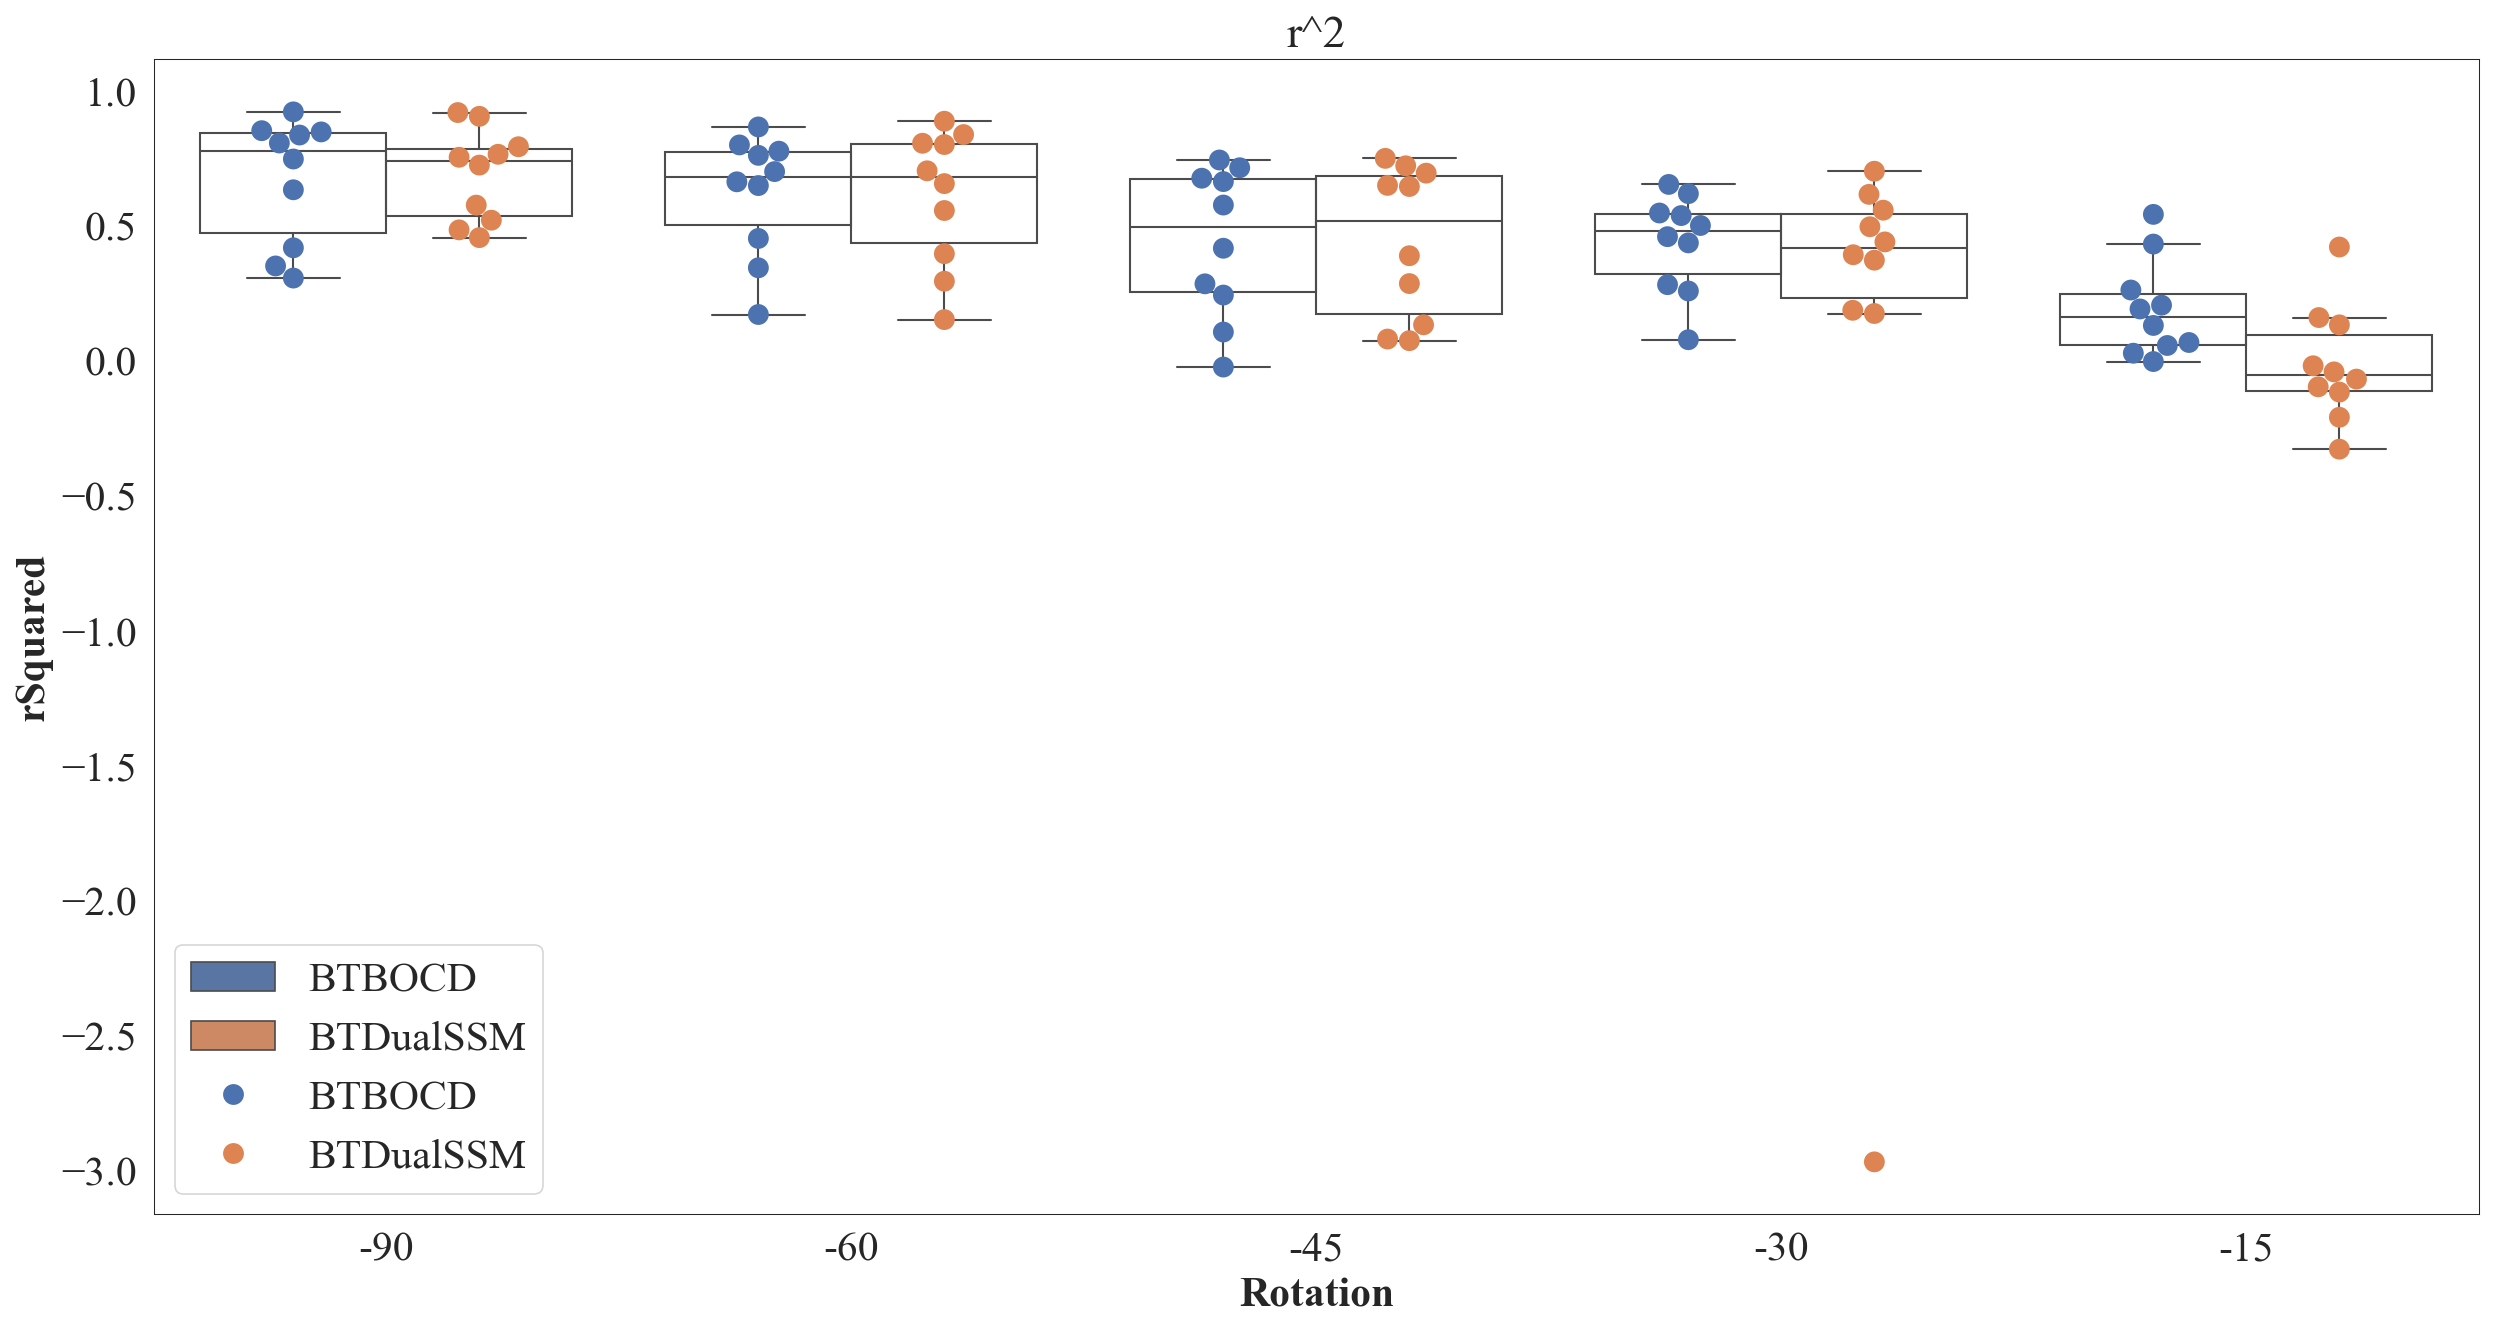

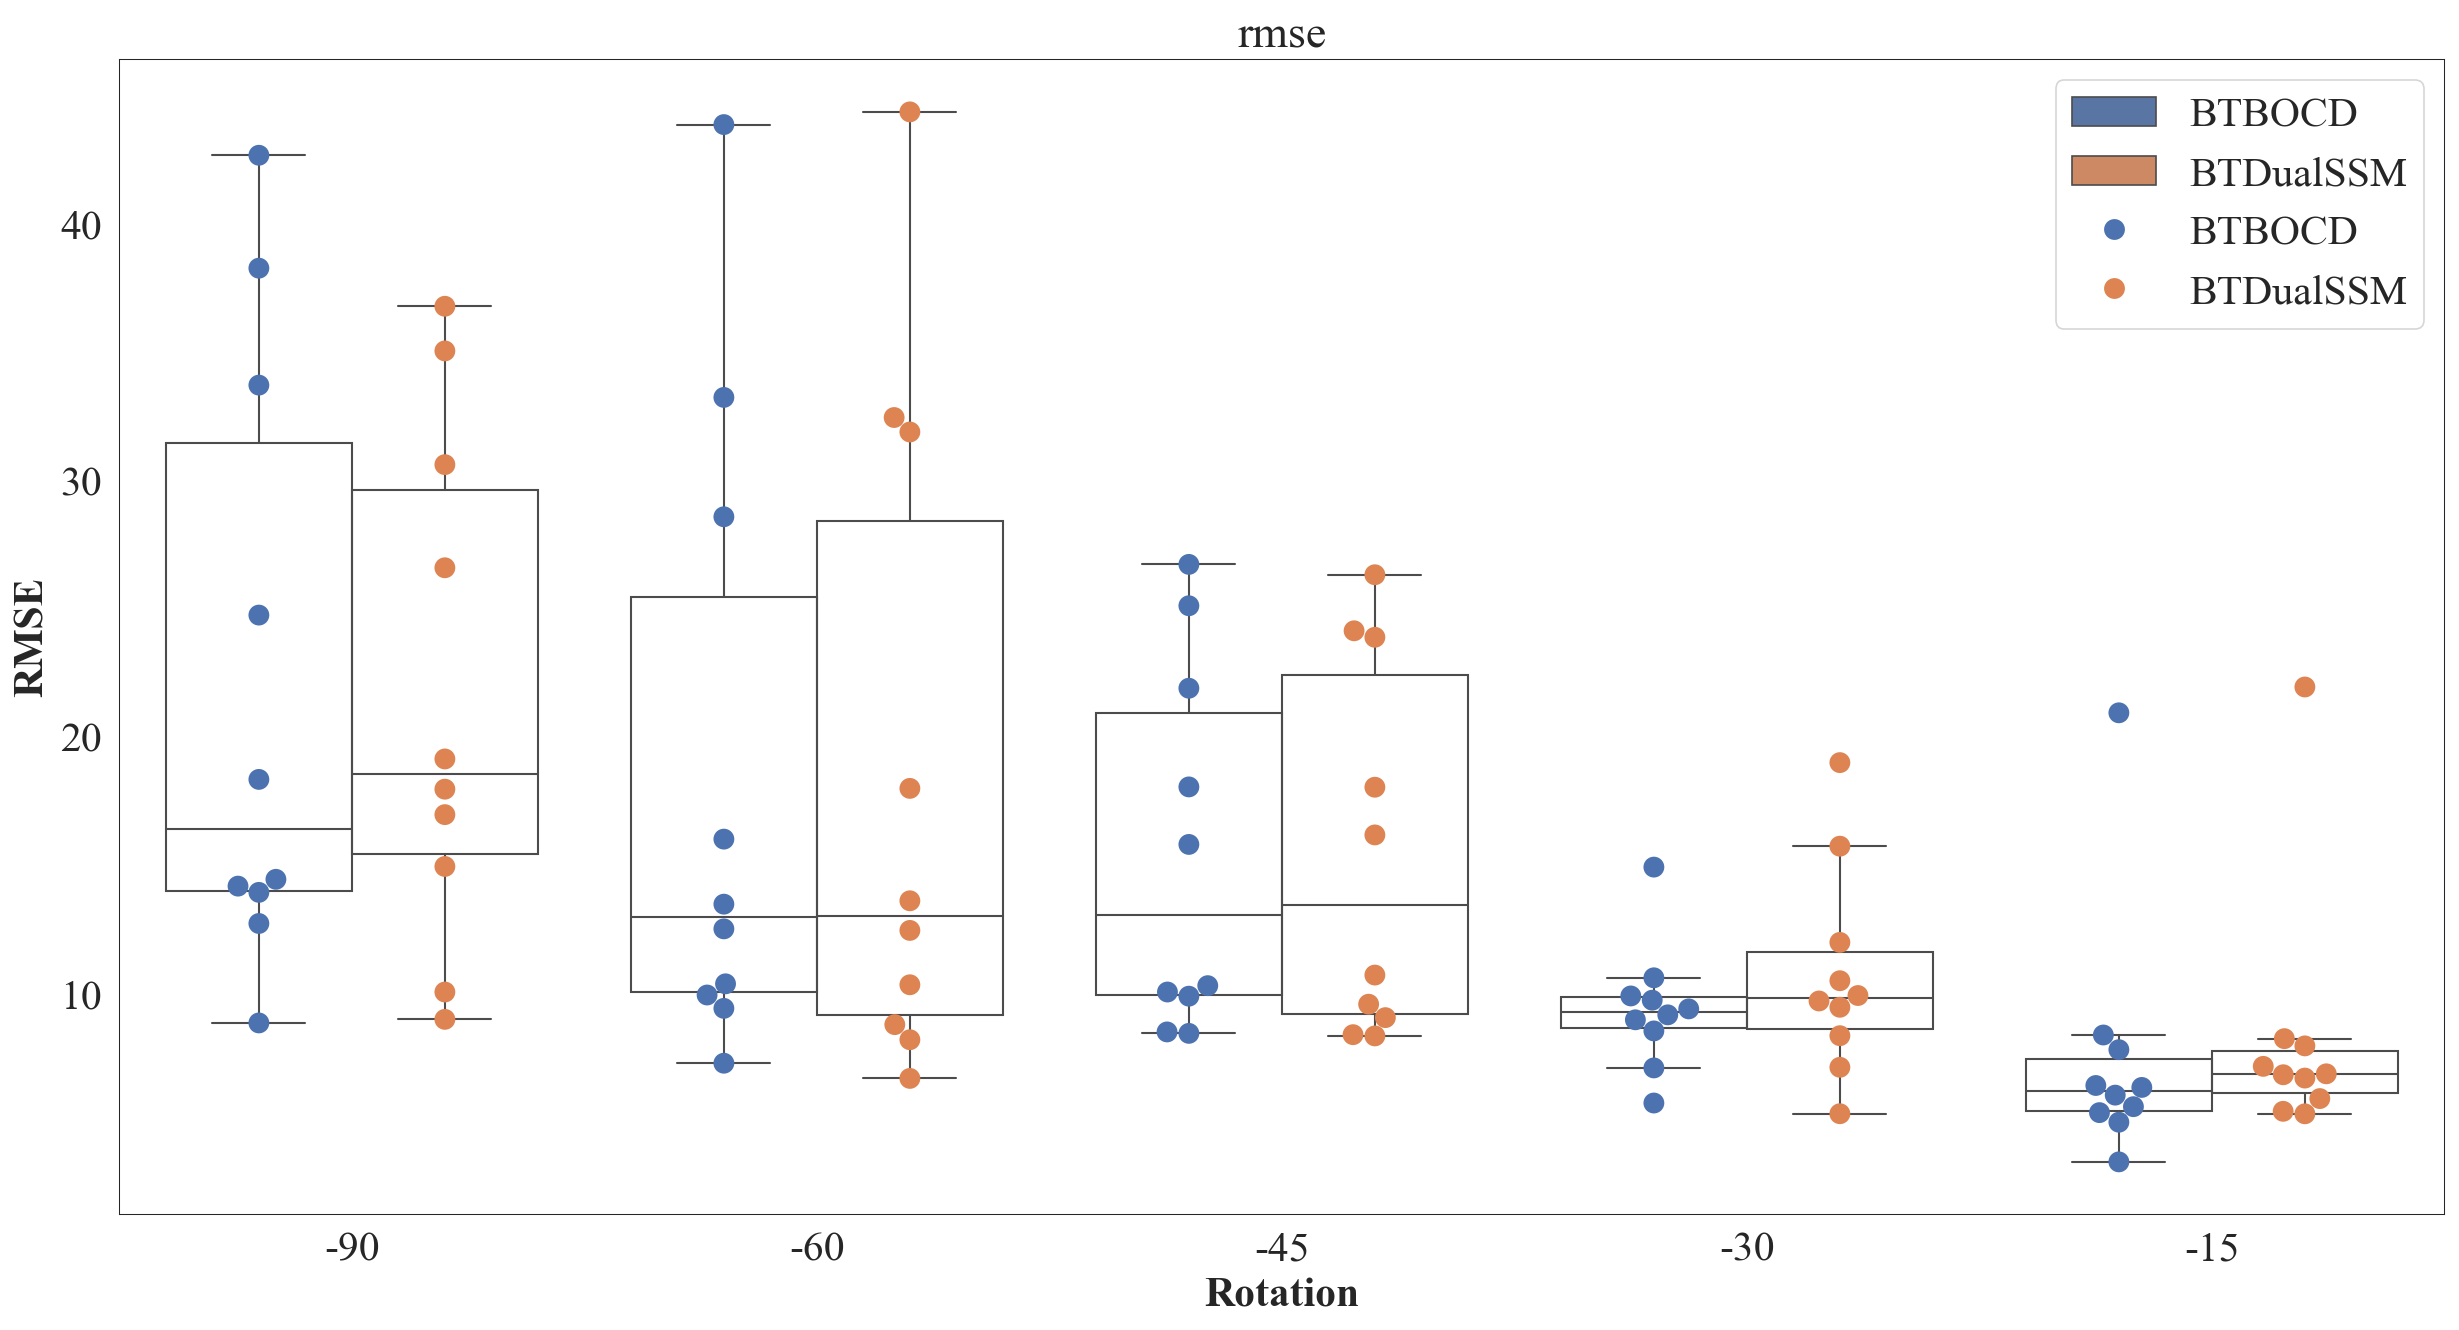

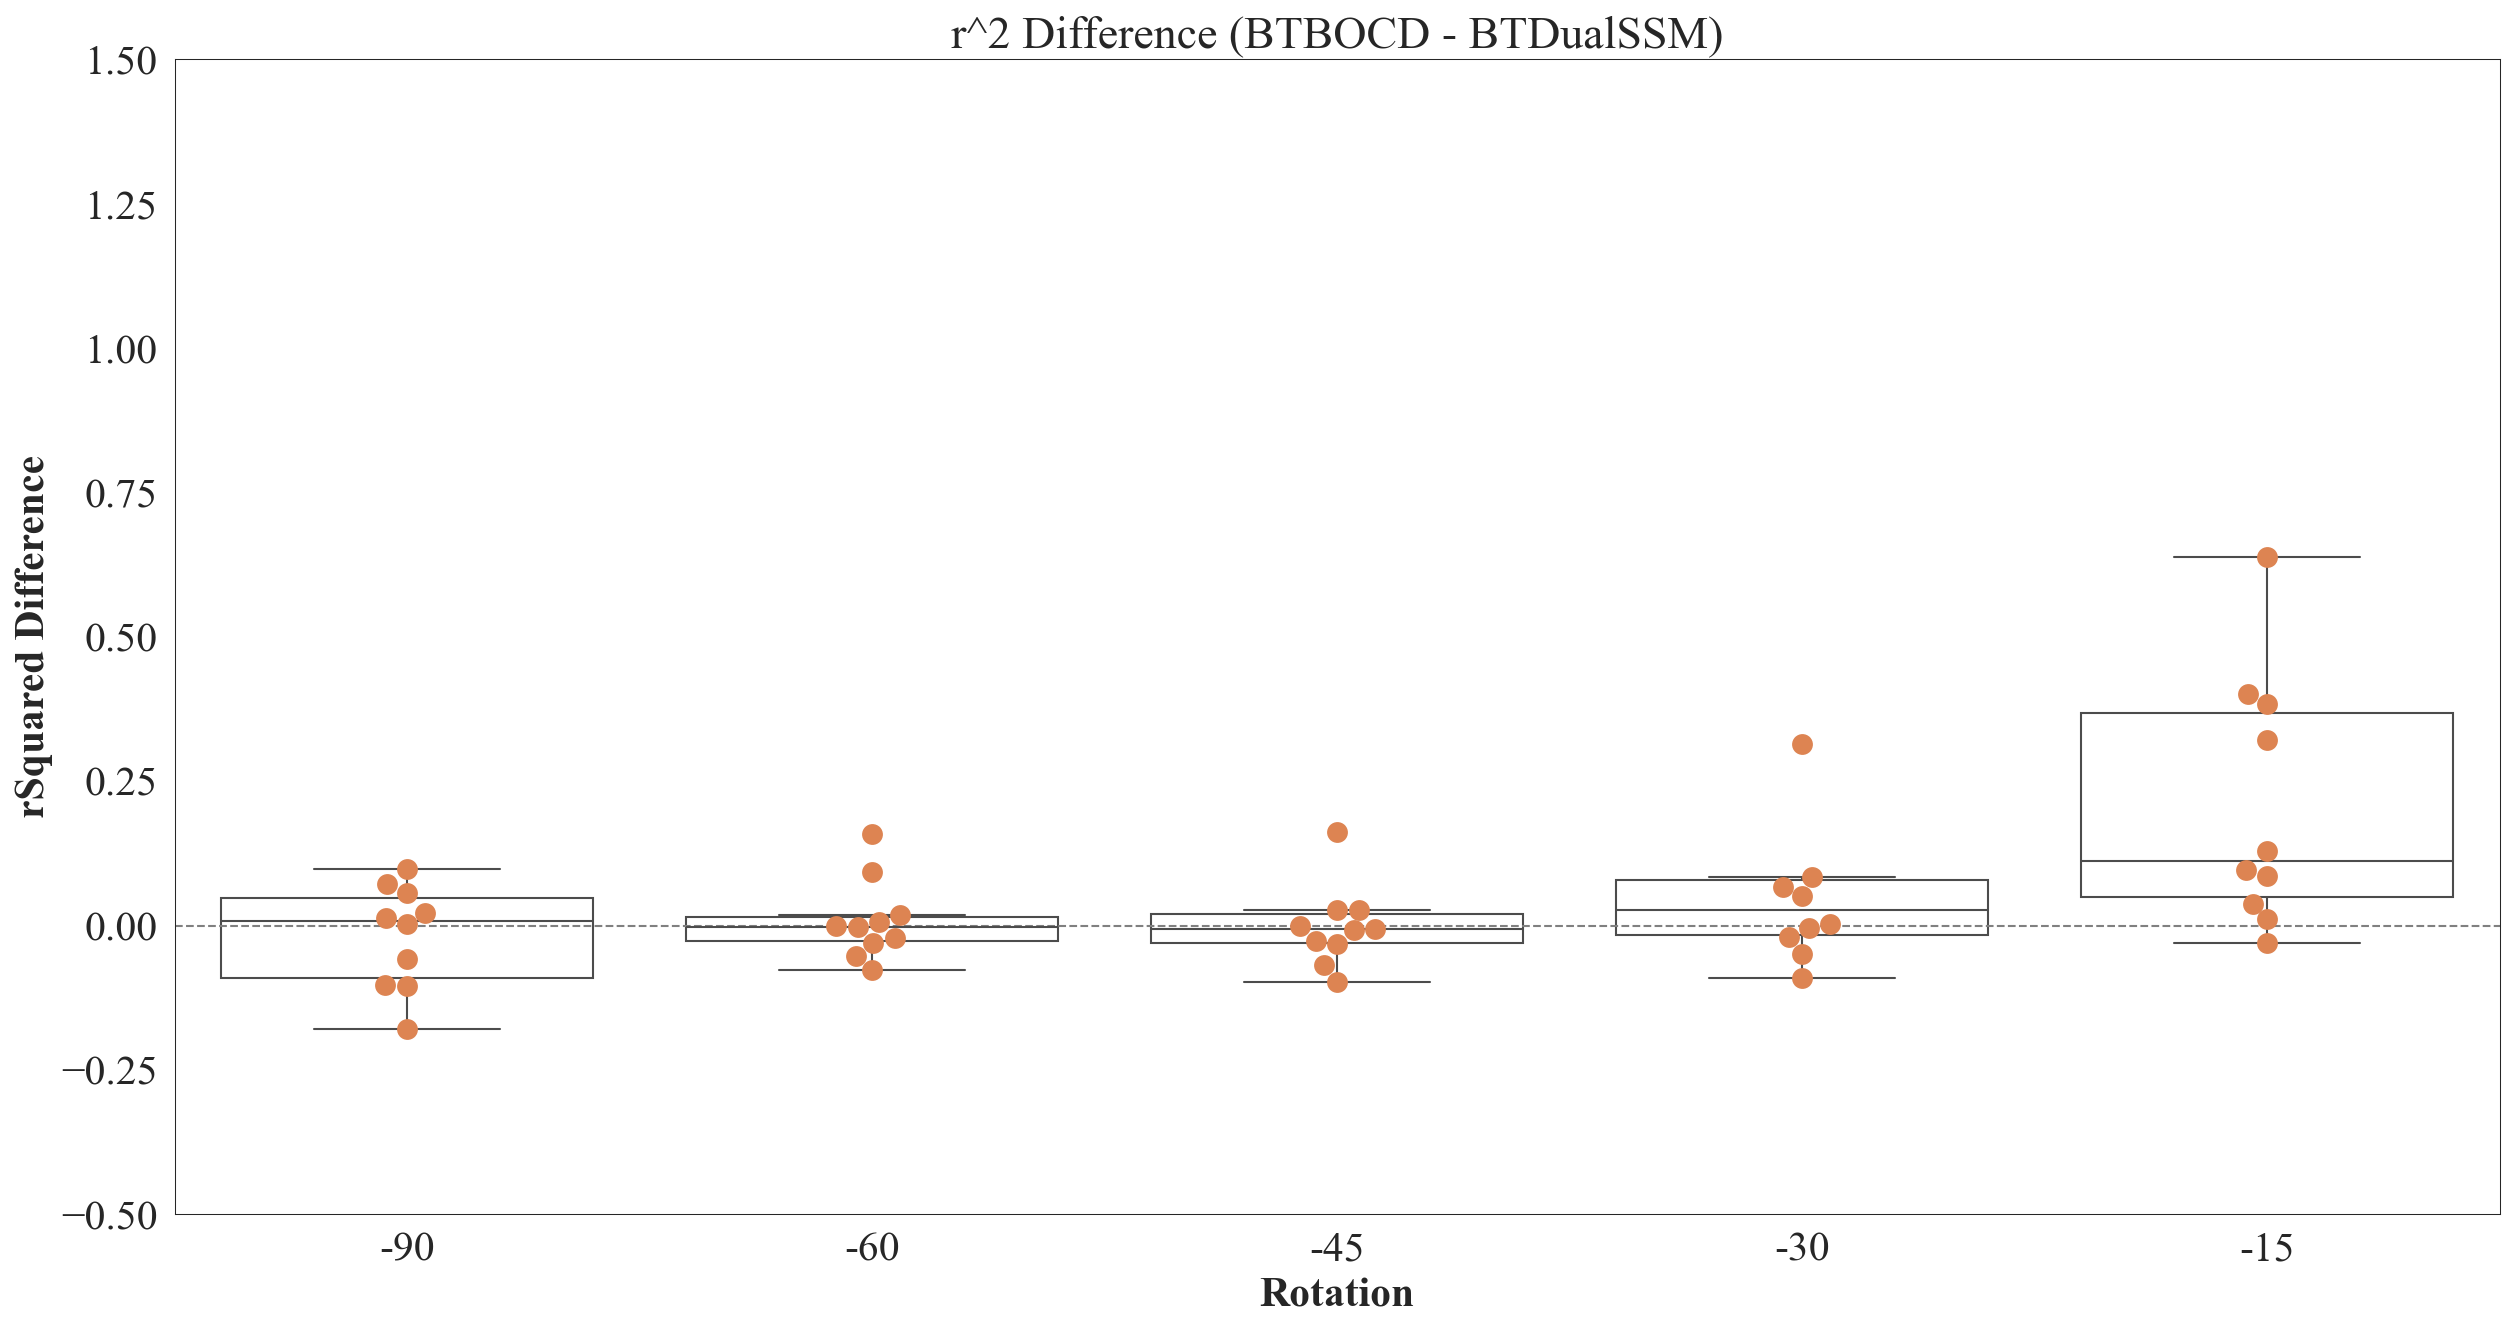

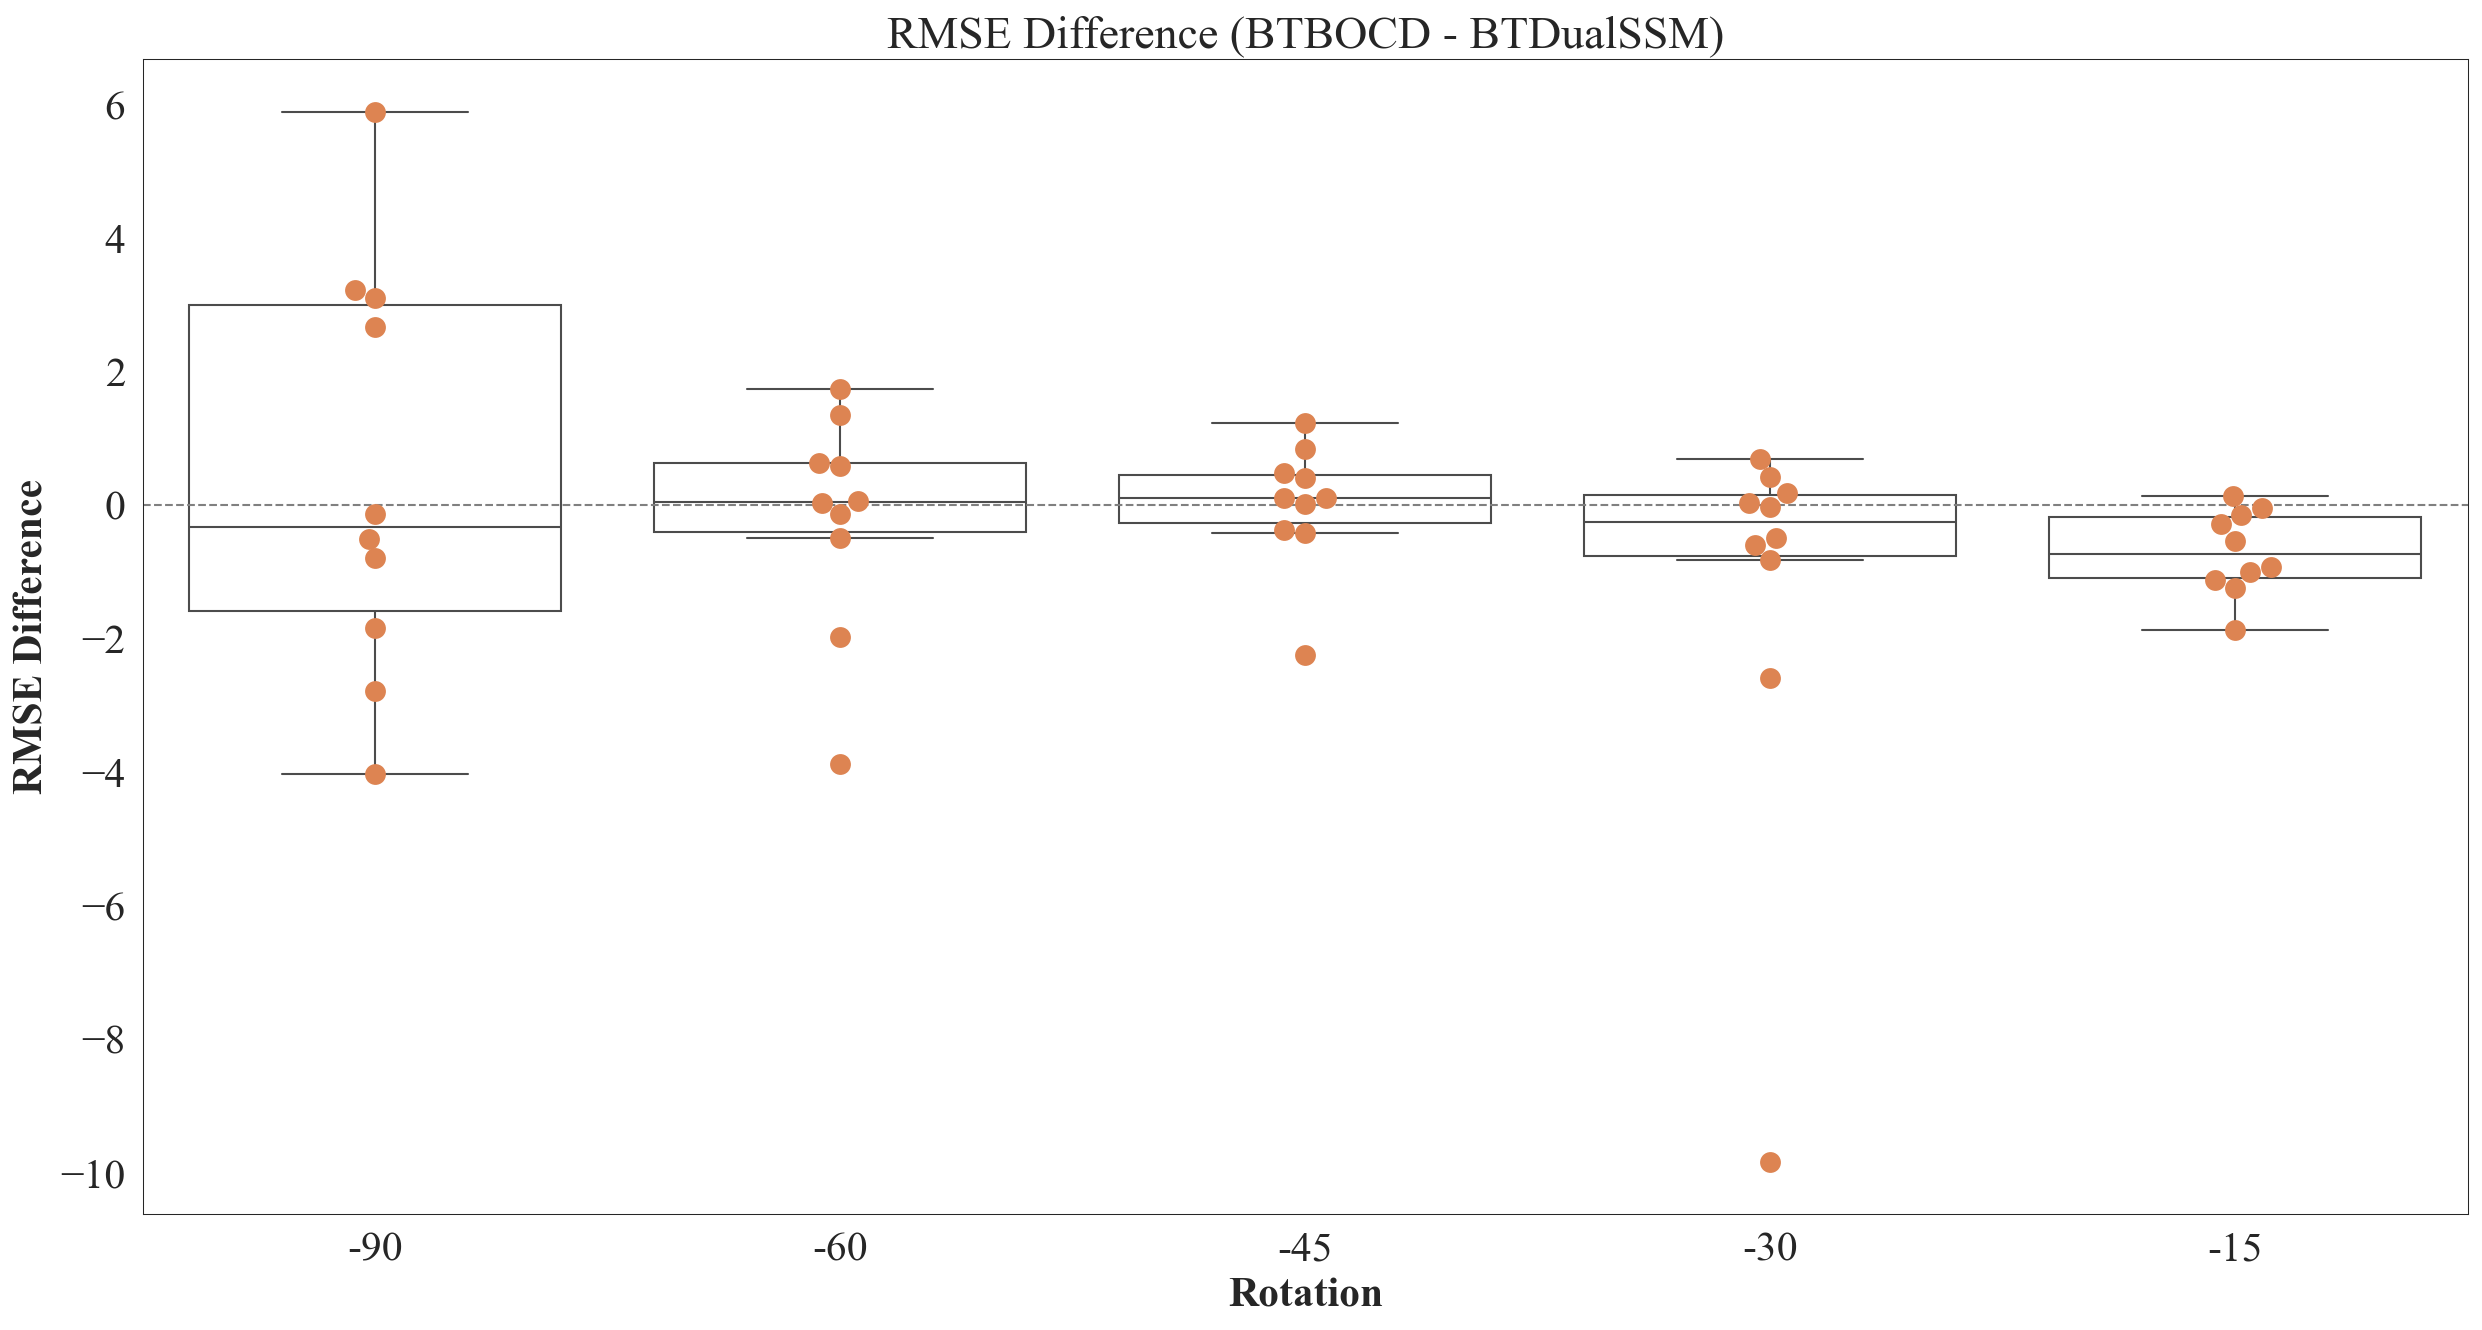

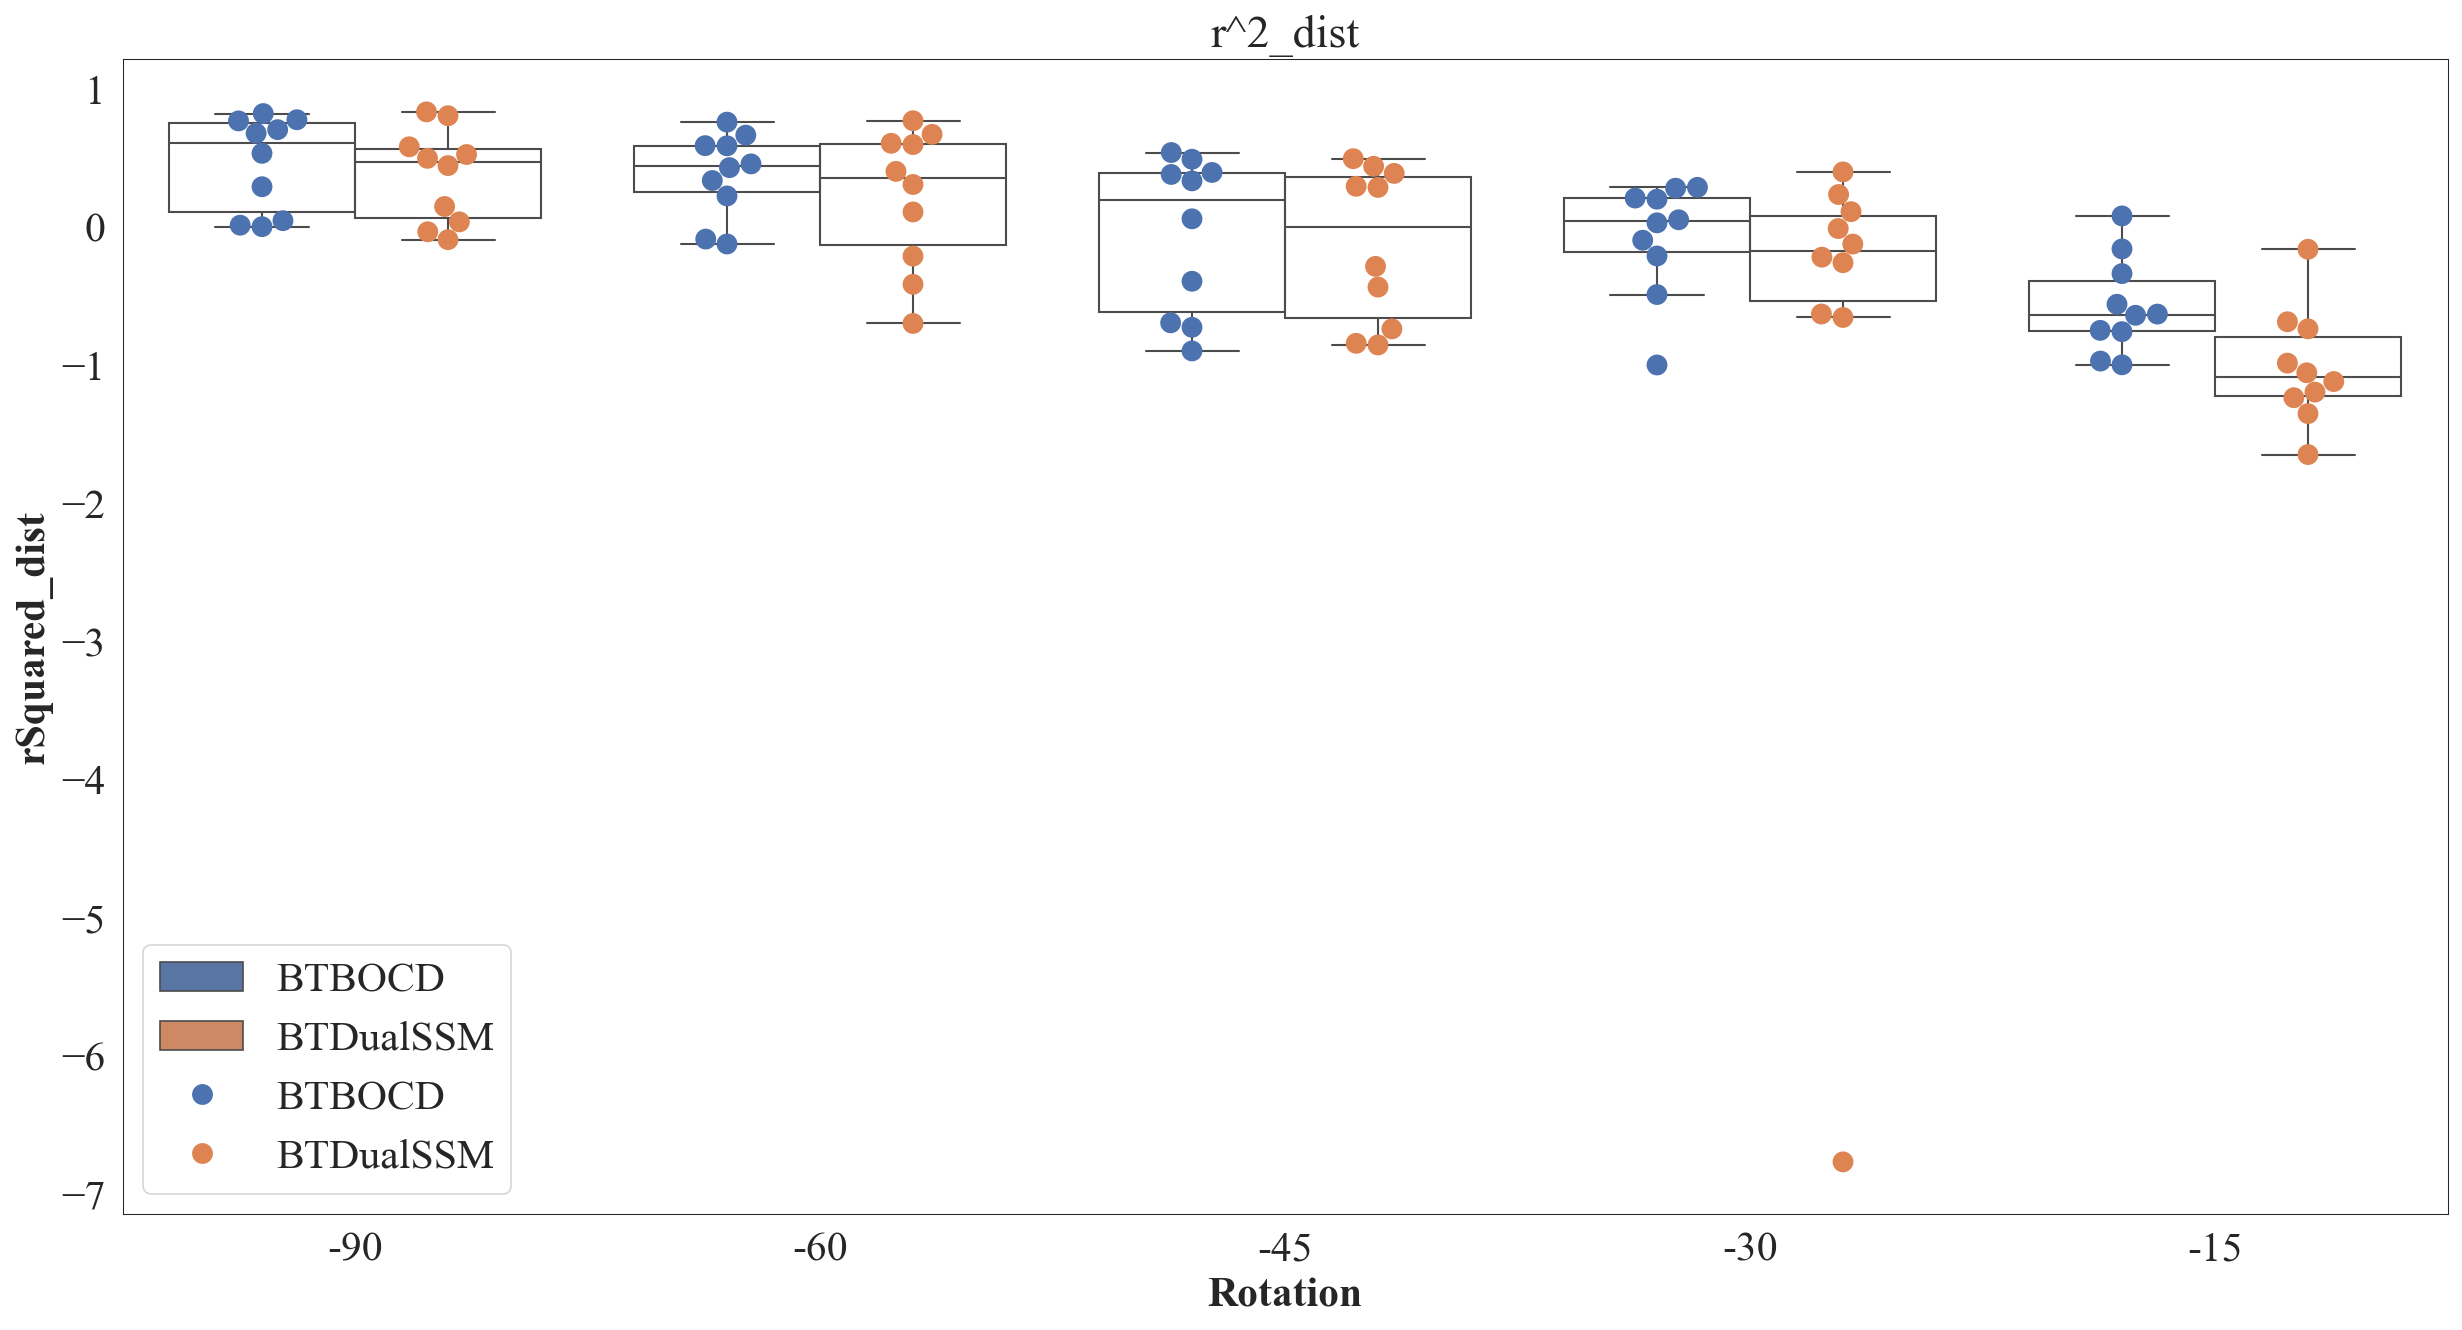

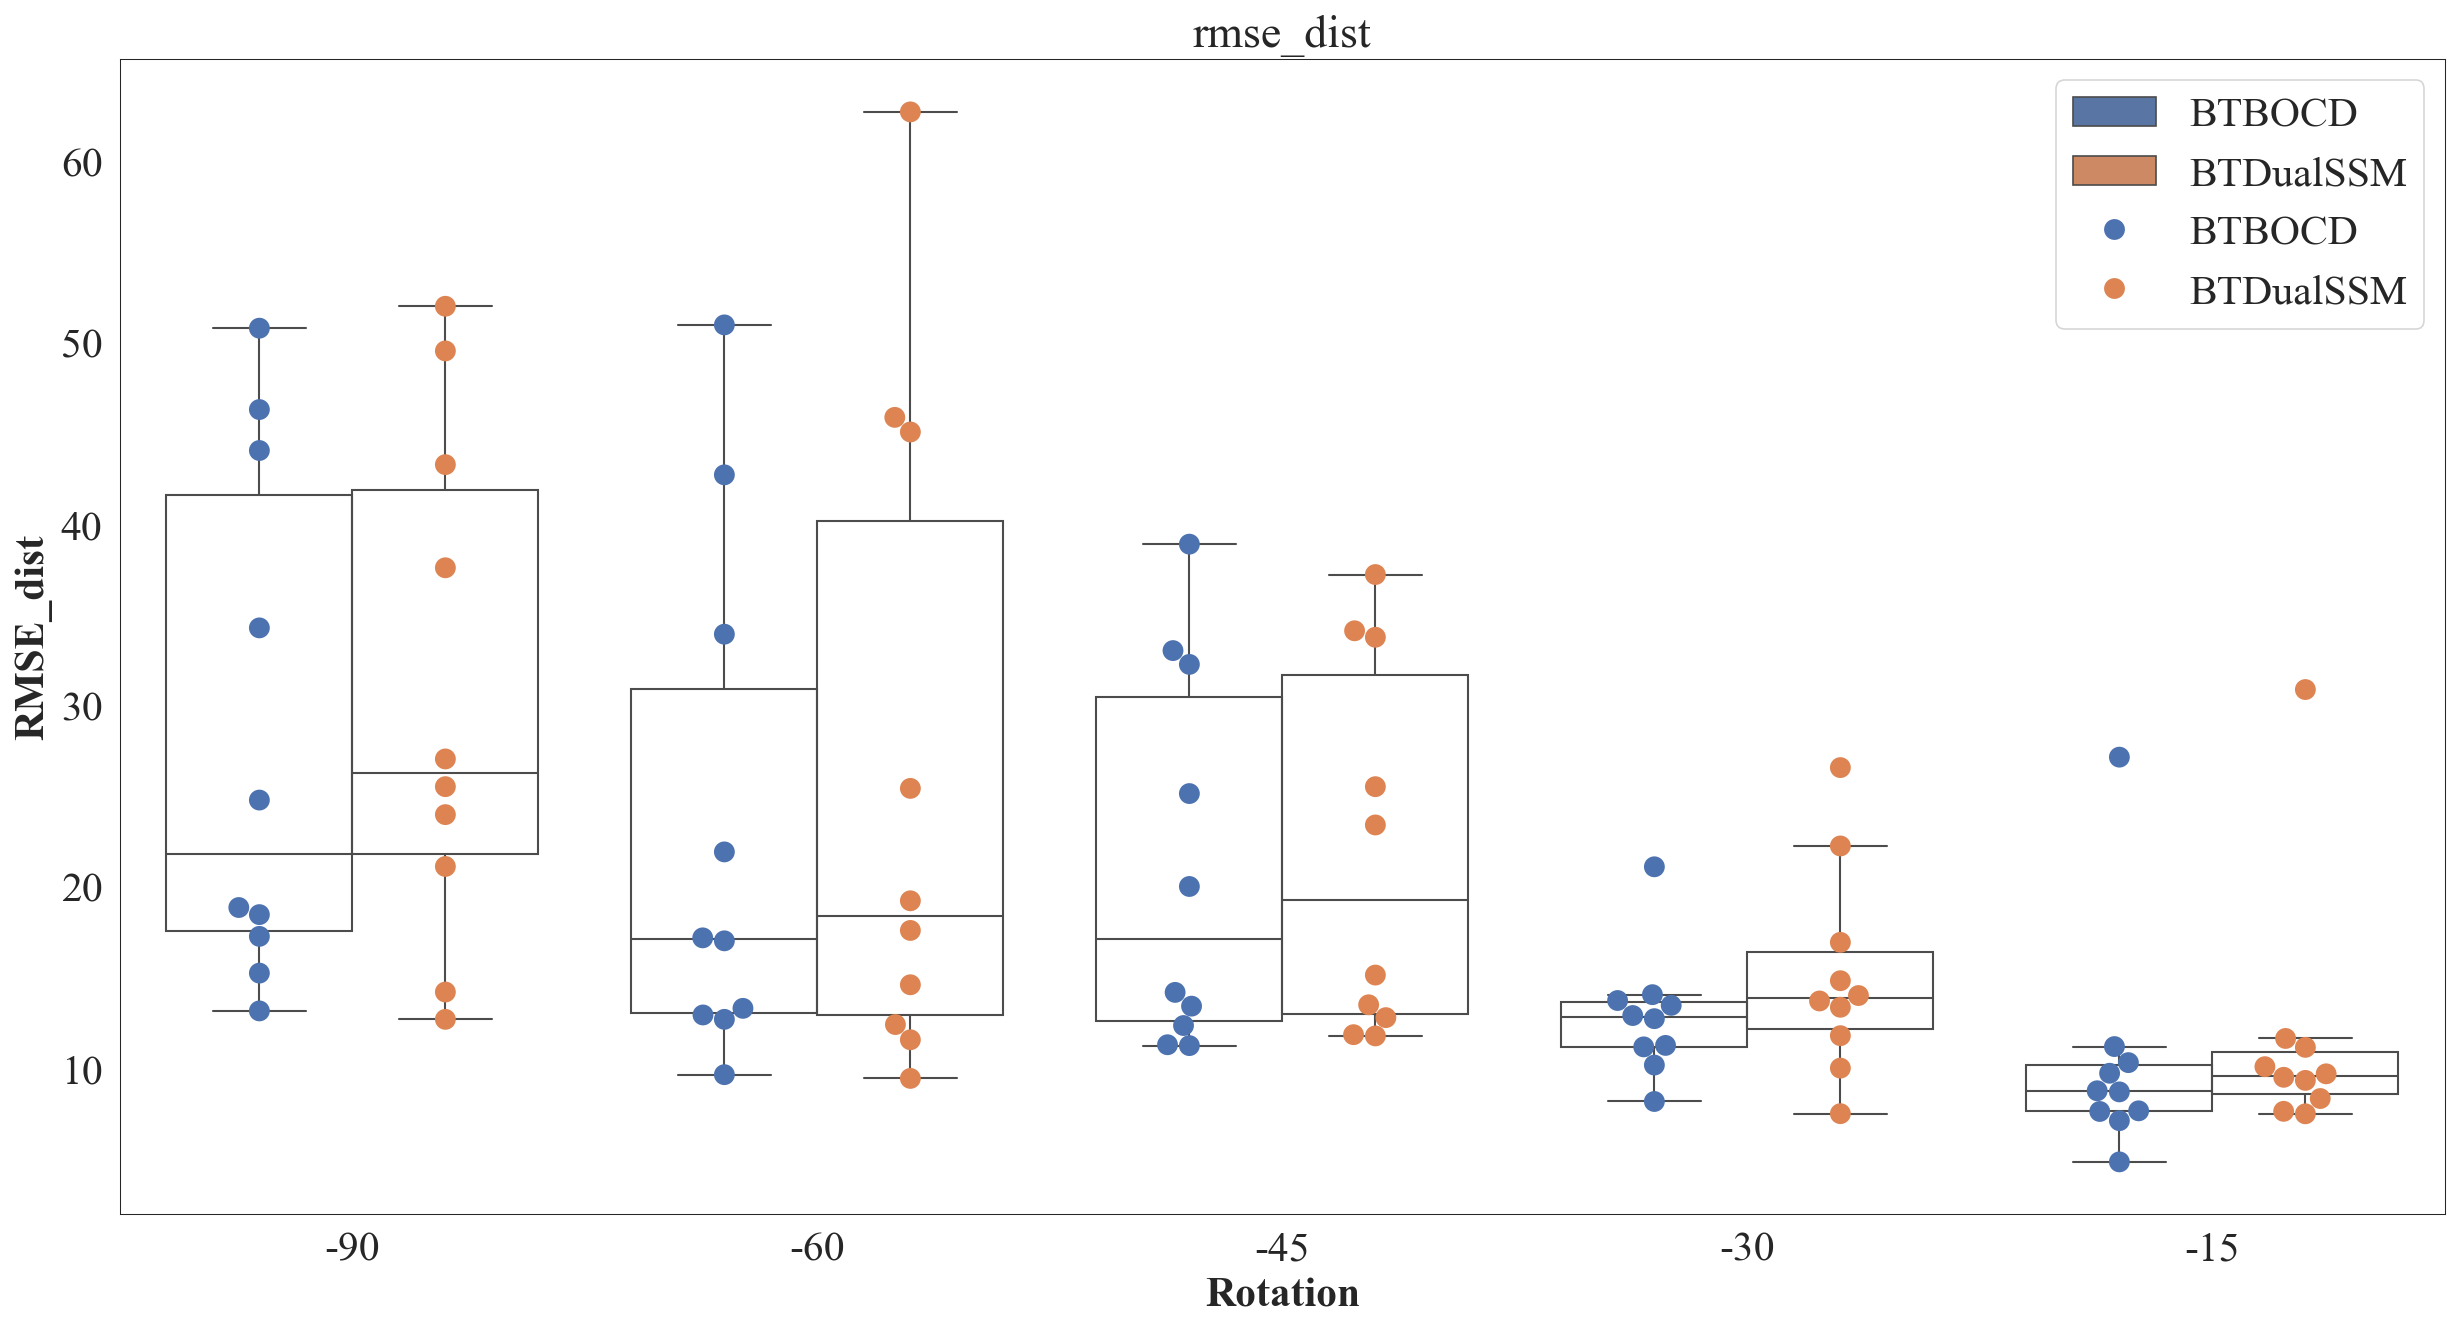

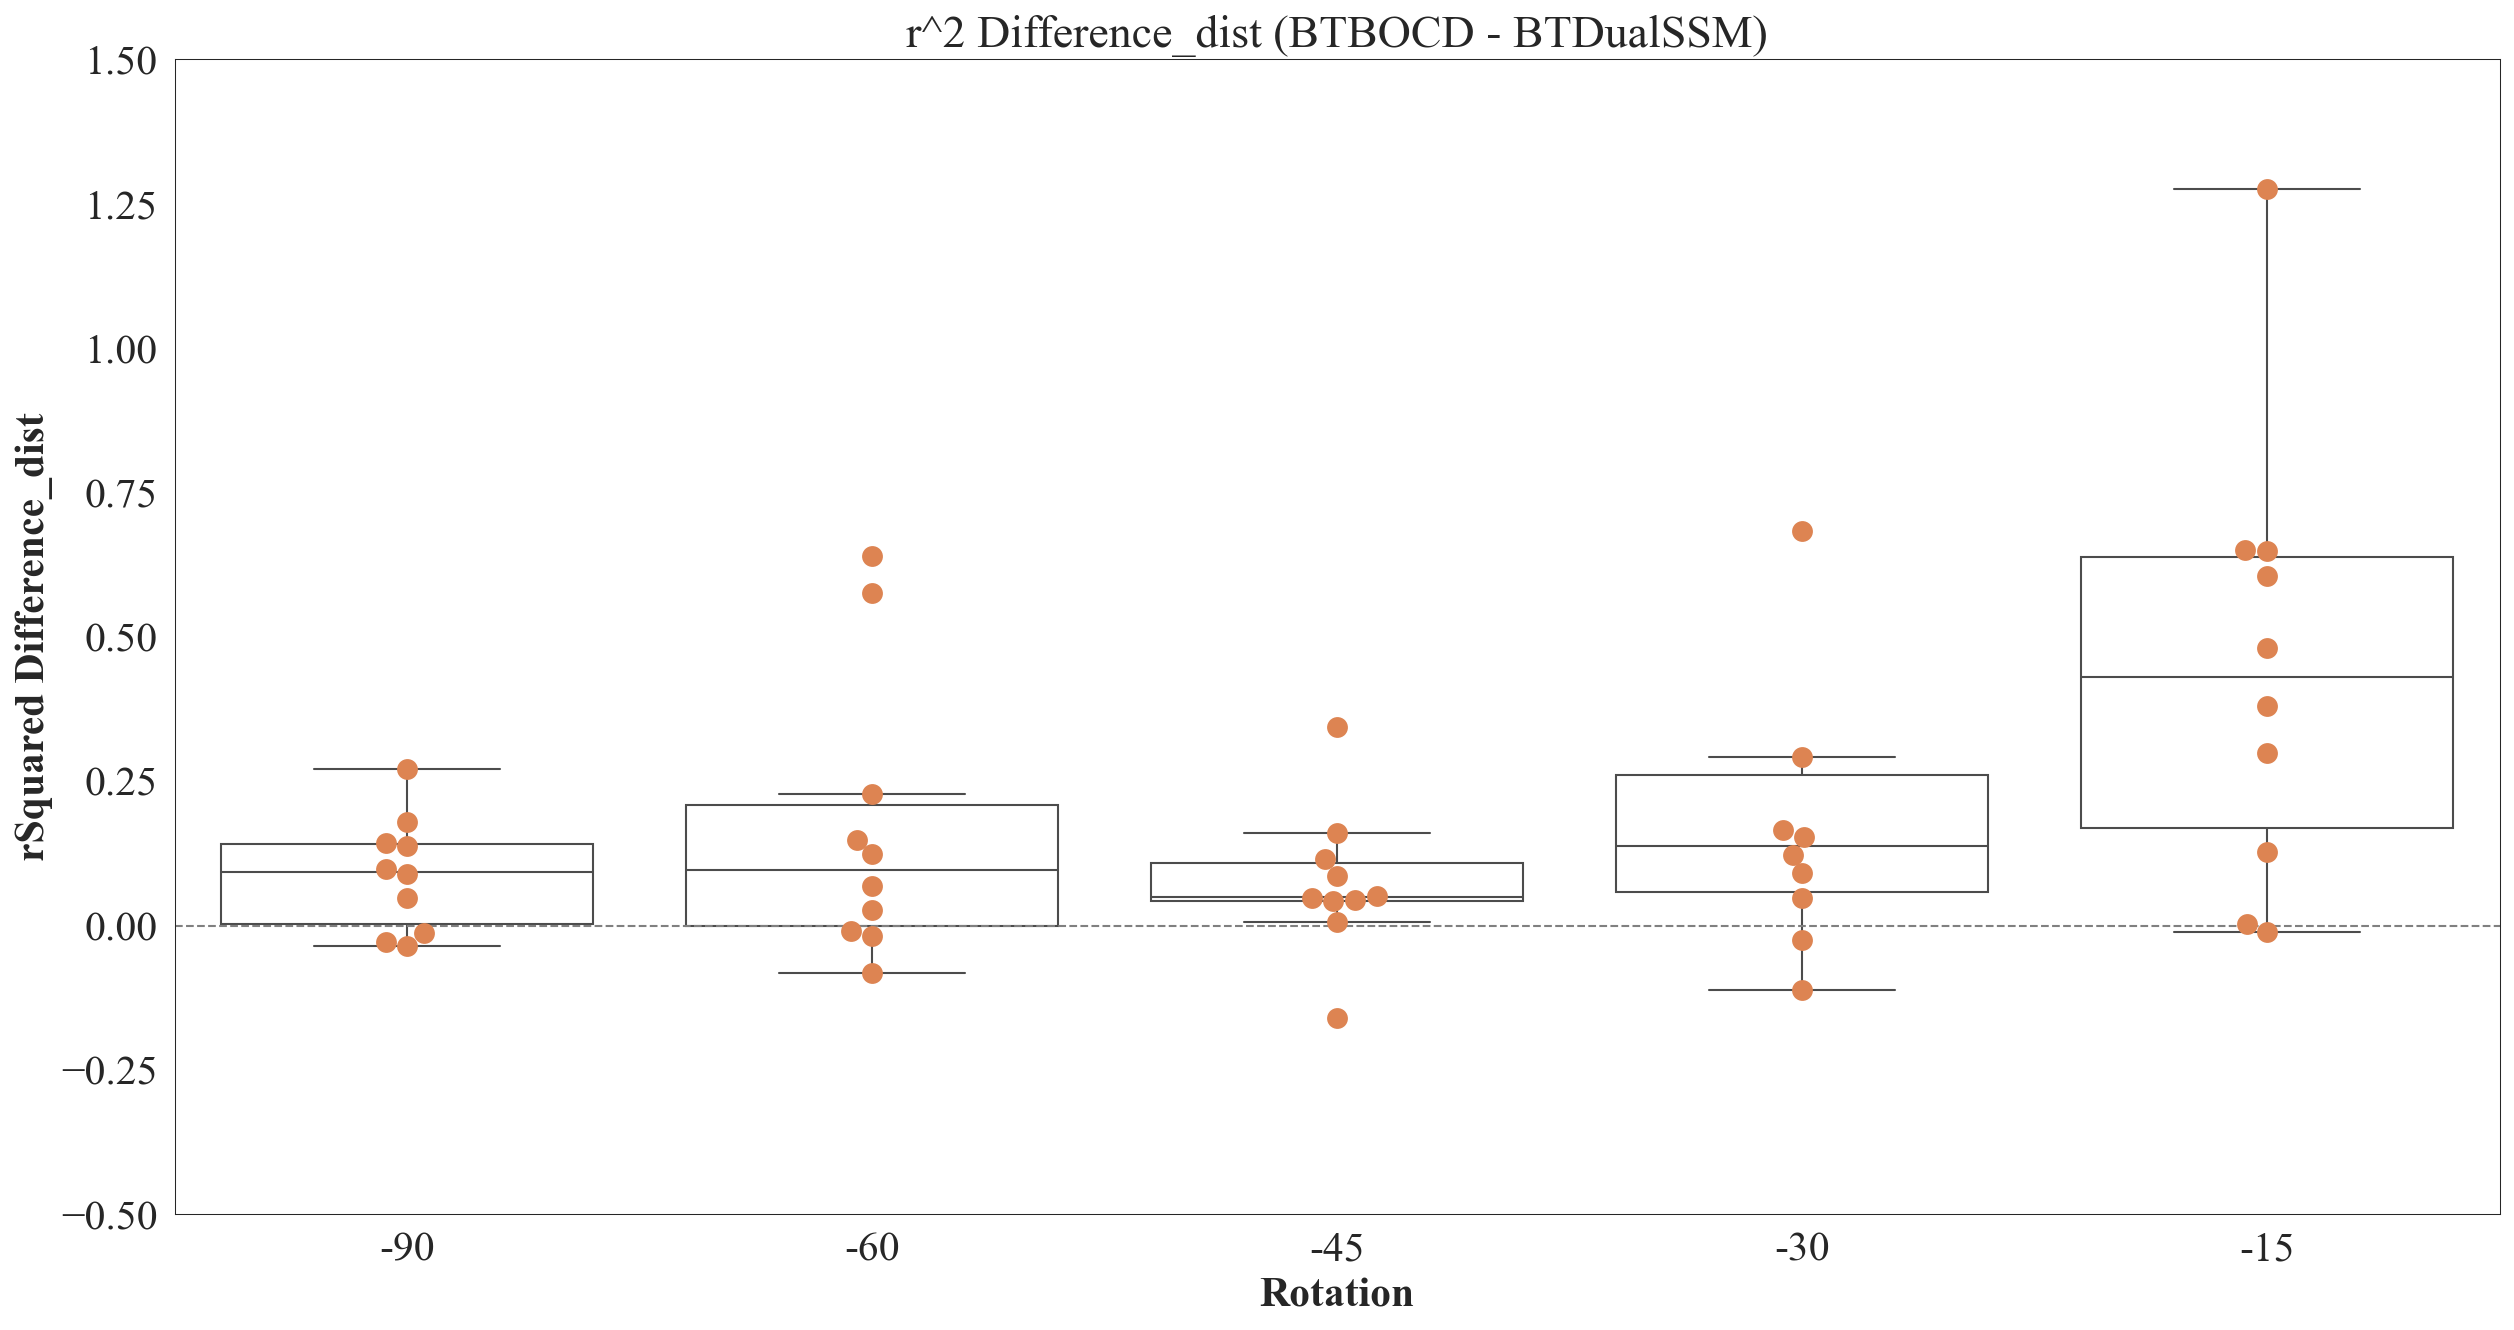

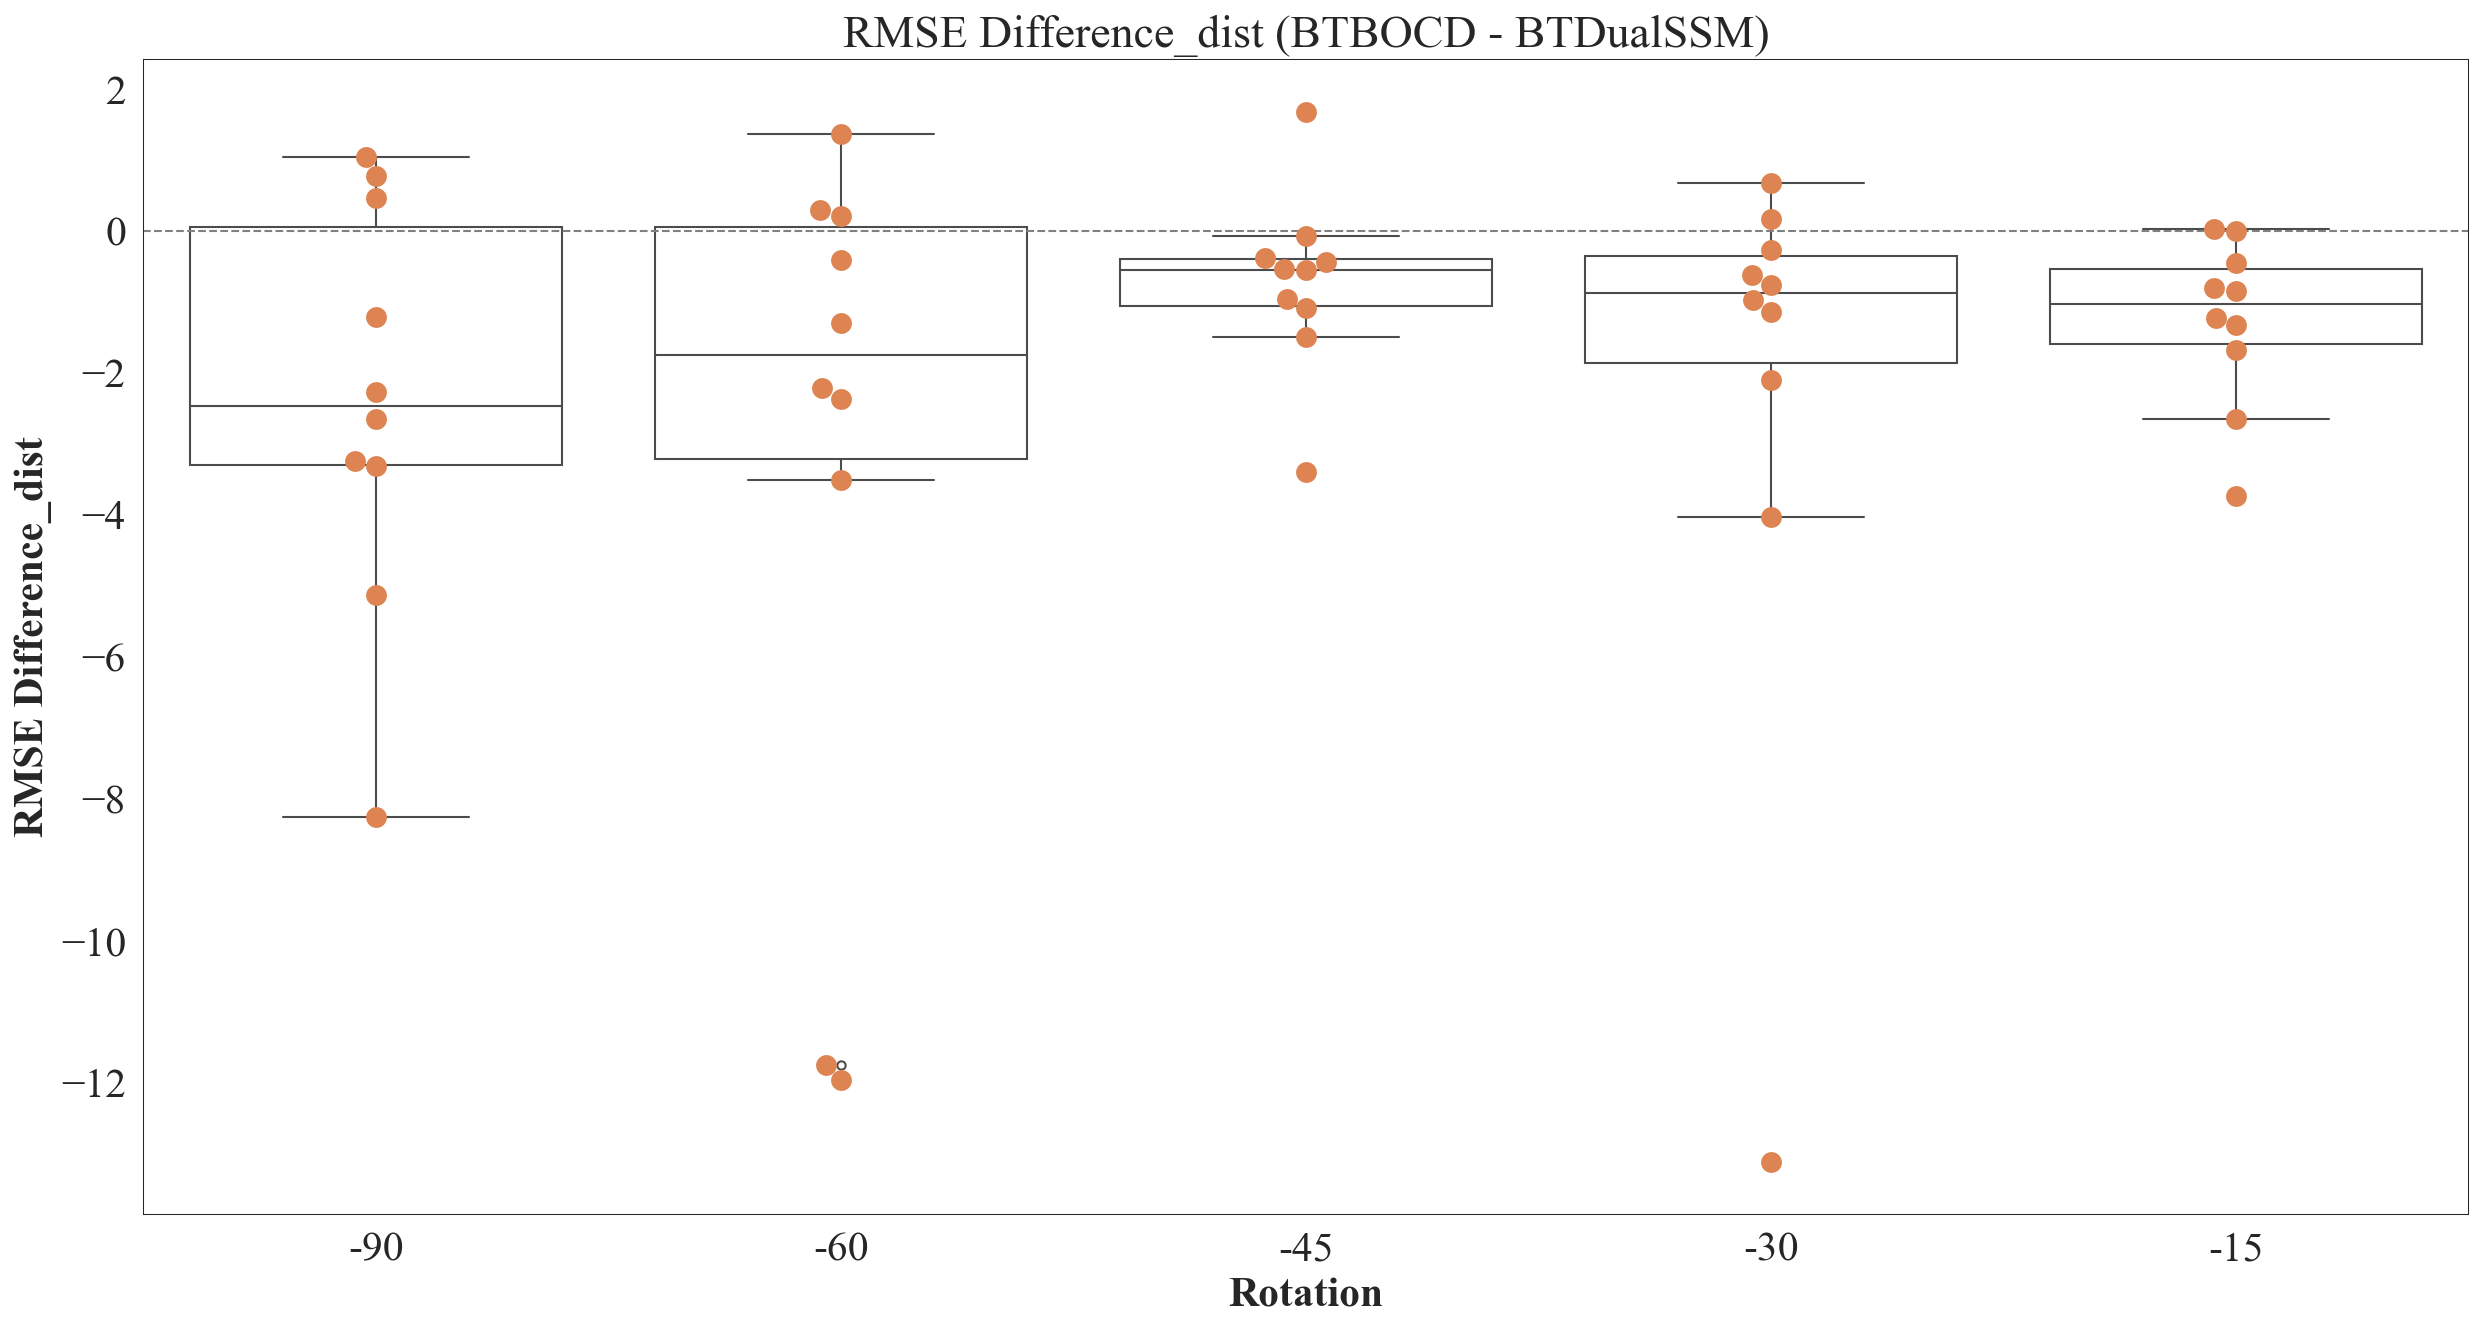

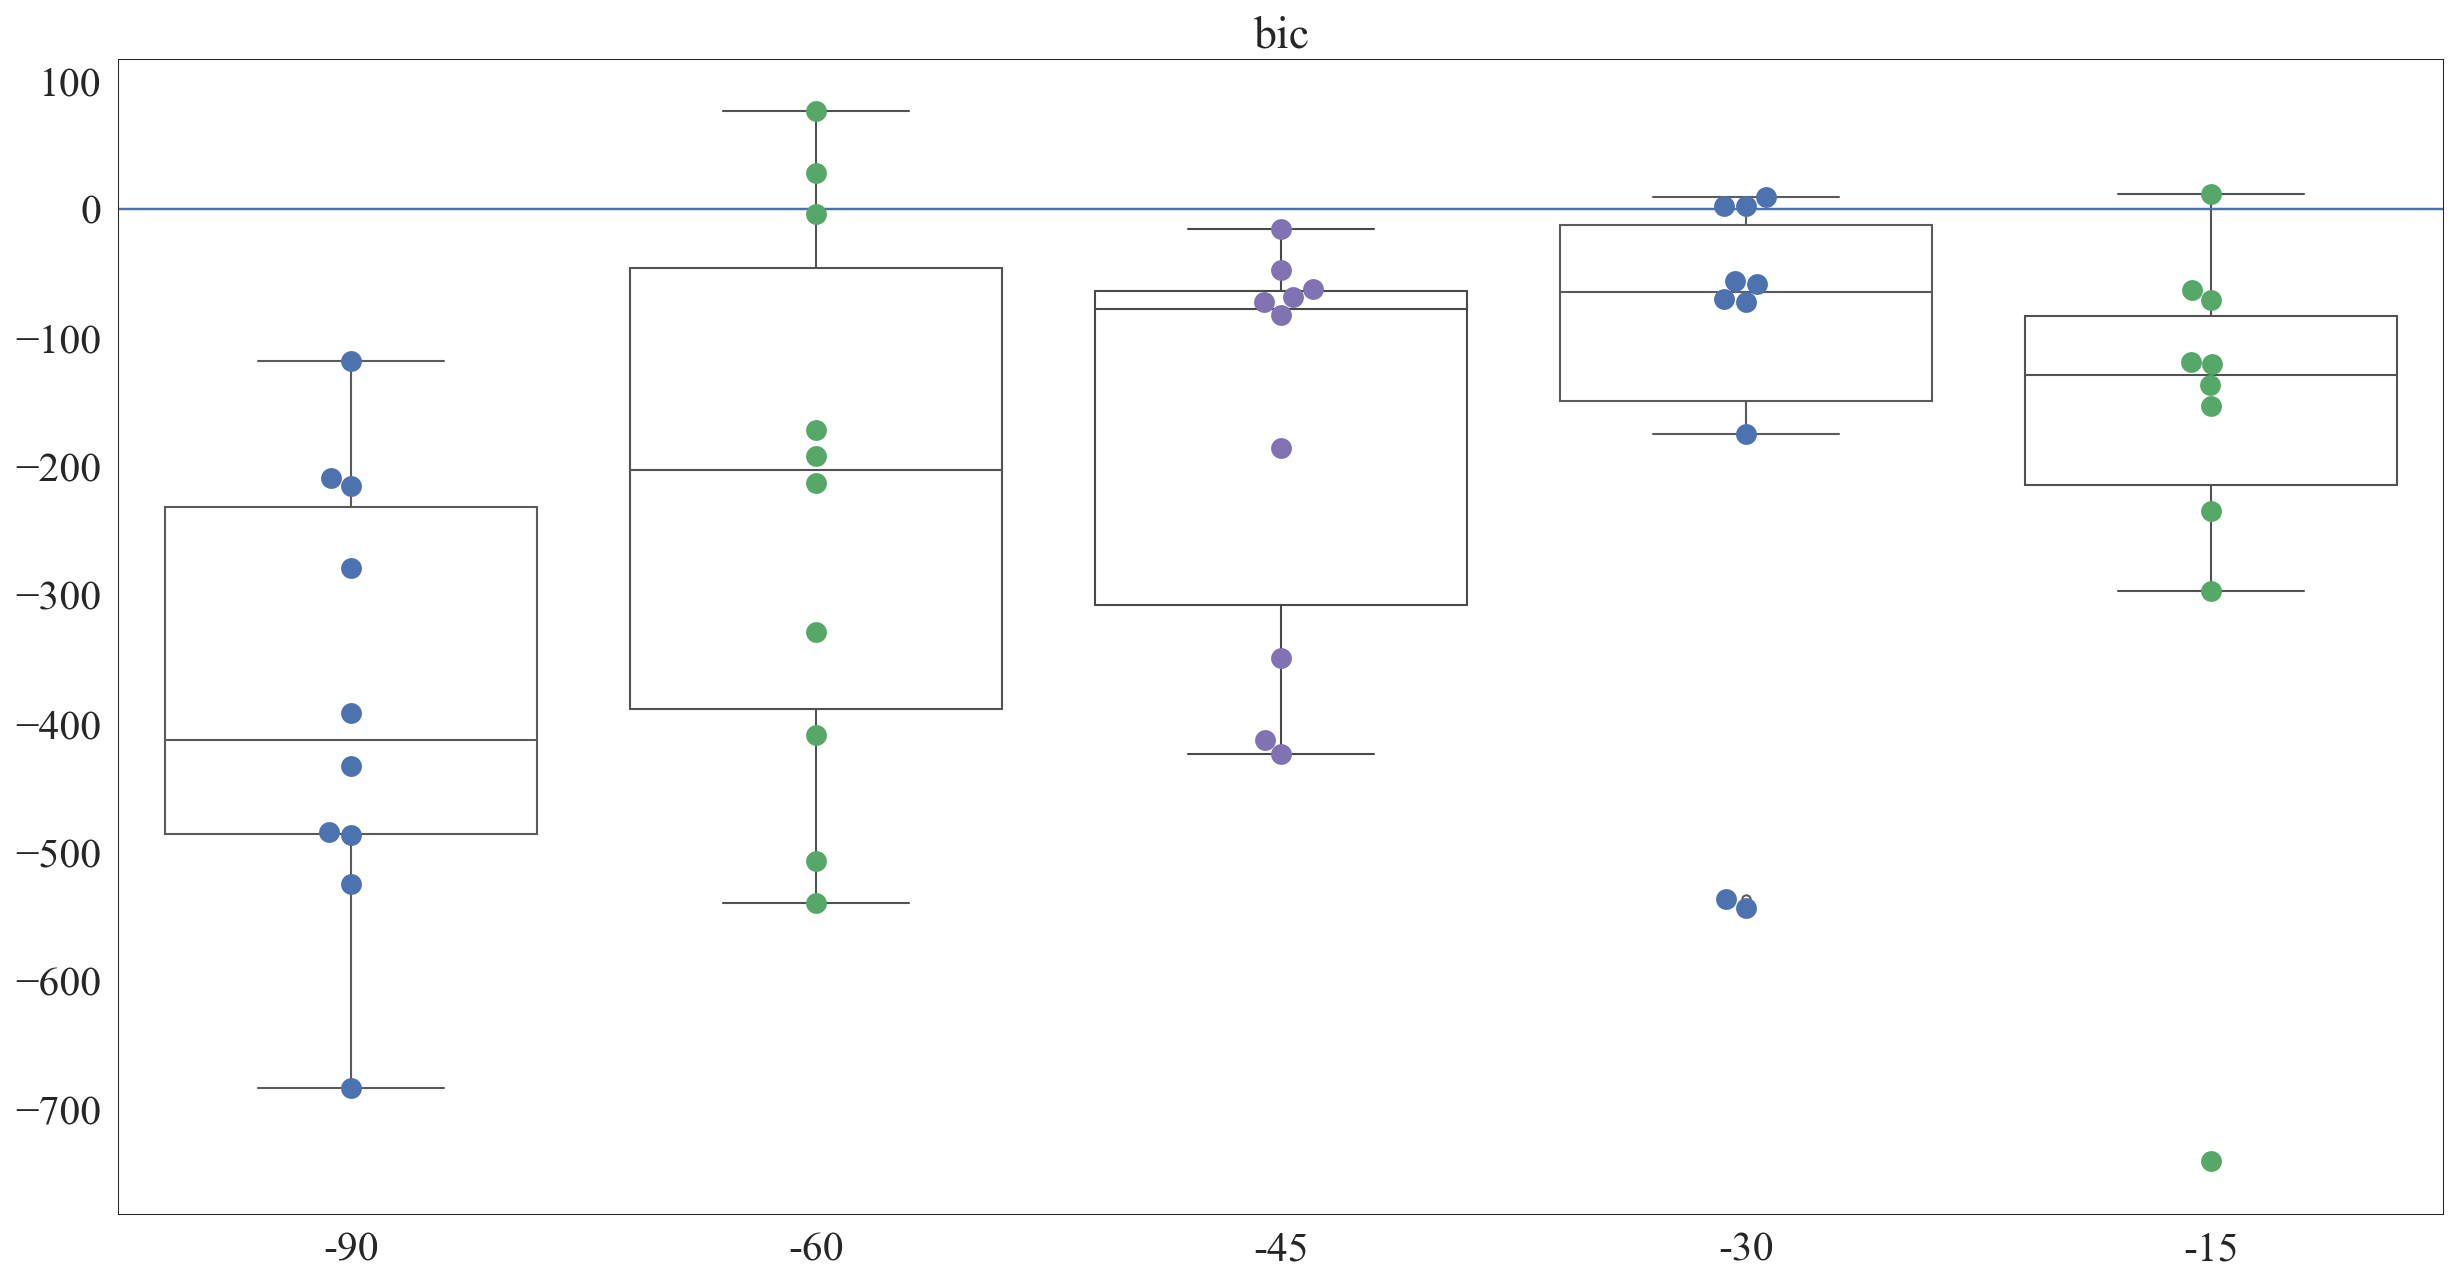

In [11]:

                                                                                               
rots = [-90, -60, -45, -30, -15]

                            
data_r2 = []
for i in range(len(rots)):
    for r2_bocd, r2_ssm in zip(BTBOCD[i].rSquareds, BTDualSSM[i].rSquareds):
        data_r2.append({'Rotation': rots[i], 'rSquared': r2_bocd, 'Model': 'BTBOCD'})
        data_r2.append({'Rotation': rots[i], 'rSquared': r2_ssm, 'Model': 'BTDualSSM'})
df_r2 = pd.DataFrame(data_r2)

                                                  
plt.figure()
sns.boxplot(x='Rotation', y='rSquared', hue='Model', data=df_r2, dodge=True, boxprops=dict(facecolor="none"))
sns.swarmplot(x='Rotation', y='rSquared', hue='Model', data=df_r2, dodge=True, size=10)
plt.title("r^2")
plt.legend()
plt.show()

                        
data_rmse = []
for i in range(len(rots)):
    for rmse_bocd, rmse_ssm in zip(BTBOCD[i].rmses, BTDualSSM[i].rmses):
        data_rmse.append({'Rotation': rots[i], 'RMSE': rmse_bocd, 'Model': 'BTBOCD'})
        data_rmse.append({'Rotation': rots[i], 'RMSE': rmse_ssm, 'Model': 'BTDualSSM'})
df_rmse = pd.DataFrame(data_rmse)

                                              
plt.figure()
sns.boxplot(x='Rotation', y='RMSE', hue='Model', data=df_rmse, dodge=True, boxprops=dict(facecolor="none"))
sns.swarmplot(x='Rotation', y='RMSE', hue='Model', data=df_rmse, dodge=True, size=10)
plt.title("rmse")
plt.legend()
plt.show()


                                        
data_r2_diff = []
for i in range(len(rots)):
    r2_diff = np.subtract(BTBOCD[i].rSquareds, BTDualSSM[i].rSquareds)
    for val in r2_diff:
        data_r2_diff.append({'Rotation': rots[i], 'rSquared Difference': val})
df_r2_diff = pd.DataFrame(data_r2_diff)

                            
plt.figure()
sns.boxplot(x='Rotation', y='rSquared Difference', data=df_r2_diff, boxprops=dict(facecolor="none"))
sns.swarmplot(x='Rotation', y='rSquared Difference', data=df_r2_diff, size=10)
plt.title("r^2 Difference (BTBOCD - BTDualSSM)")
plt.axhline(0, color='gray', linestyle='--')                                            
plt.ylim(-0.5,1.5)
plt.show()

                                    
data_rmse_diff = []
for i in range(len(rots)):
    rmse_diff = np.subtract(BTBOCD[i].rmses, BTDualSSM[i].rmses)
    for val in rmse_diff:
        data_rmse_diff.append({'Rotation': rots[i], 'RMSE Difference': val})
df_rmse_diff = pd.DataFrame(data_rmse_diff)

                        
plt.figure()
sns.boxplot(x='Rotation', y='RMSE Difference', data=df_rmse_diff, boxprops=dict(facecolor="none"))
sns.swarmplot(x='Rotation', y='RMSE Difference', data=df_rmse_diff, size=10)
plt.title("RMSE Difference (BTBOCD - BTDualSSM)")
plt.axhline(0, color='gray', linestyle='--')                                            
plt.show()

                            
data_r2 = []
for i in range(len(rots)):
    for r2_bocd, r2_ssm in zip(BTBOCD[i].rSquareds_dist, BTDualSSM[i].rSquareds_dist):
        data_r2.append({'Rotation': rots[i], 'rSquared_dist': r2_bocd, 'Model': 'BTBOCD'})
        data_r2.append({'Rotation': rots[i], 'rSquared_dist': r2_ssm, 'Model': 'BTDualSSM'})
df_r2 = pd.DataFrame(data_r2)

                                                  
plt.figure()
sns.boxplot(x='Rotation', y='rSquared_dist', hue='Model', data=df_r2, dodge=True, boxprops=dict(facecolor="none"))
sns.swarmplot(x='Rotation', y='rSquared_dist', hue='Model', data=df_r2, dodge=True, size=10)
plt.title("r^2_dist")
plt.legend()
plt.show()

                        
data_rmse = []
for i in range(len(rots)):
    for rmse_bocd, rmse_ssm in zip(BTBOCD[i].rmses_dist, BTDualSSM[i].rmses_dist):
        data_rmse.append({'Rotation': rots[i], 'RMSE_dist': rmse_bocd, 'Model': 'BTBOCD'})
        data_rmse.append({'Rotation': rots[i], 'RMSE_dist': rmse_ssm, 'Model': 'BTDualSSM'})
df_rmse = pd.DataFrame(data_rmse)

                                              
plt.figure()
sns.boxplot(x='Rotation', y='RMSE_dist', hue='Model', data=df_rmse, dodge=True, boxprops=dict(facecolor="none"))
sns.swarmplot(x='Rotation', y='RMSE_dist', hue='Model', data=df_rmse, dodge=True, size=10)
plt.title("rmse_dist")
plt.legend()
plt.show()


                                        
data_r2_diff = []
for i in range(len(rots)):
    r2_diff = np.subtract(BTBOCD[i].rSquareds_dist, BTDualSSM[i].rSquareds_dist)
    for val in r2_diff:
        data_r2_diff.append({'Rotation': rots[i], 'rSquared Difference_dist': val})
df_r2_diff = pd.DataFrame(data_r2_diff)

                            
plt.figure()
sns.boxplot(x='Rotation', y='rSquared Difference_dist', data=df_r2_diff, boxprops=dict(facecolor="none"))
sns.swarmplot(x='Rotation', y='rSquared Difference_dist', data=df_r2_diff, size=10)
plt.title("r^2 Difference_dist (BTBOCD - BTDualSSM)")
plt.axhline(0, color='gray', linestyle='--')                                            
plt.ylim(-0.5,1.5)
plt.show()

                                    
data_rmse_diff = []
for i in range(len(rots)):
    rmse_diff = np.subtract(BTBOCD[i].rmses_dist, BTDualSSM[i].rmses_dist)
    for val in rmse_diff:
        data_rmse_diff.append({'Rotation': rots[i], 'RMSE Difference_dist': val})
df_rmse_diff = pd.DataFrame(data_rmse_diff)

                        
plt.figure()
sns.boxplot(x='Rotation', y='RMSE Difference_dist', data=df_rmse_diff, boxprops=dict(facecolor="none"))
sns.swarmplot(x='Rotation', y='RMSE Difference_dist', data=df_rmse_diff, size=10)
plt.title("RMSE Difference_dist (BTBOCD - BTDualSSM)")
plt.axhline(0, color='gray', linestyle='--')                                            
plt.show()

                       
for i in range(len(rots)):
    sns.swarmplot(x=rots[i], y=np.subtract(BTBOCD[i].bics, BTDualSSM[i].bics), size=10)
    sns.boxplot(x=rots[i], y=np.subtract(BTBOCD[i].bics, BTDualSSM[i].bics), boxprops=dict(facecolor="none"))
    plt.axhline(0)
plt.title("bic")
plt.show()

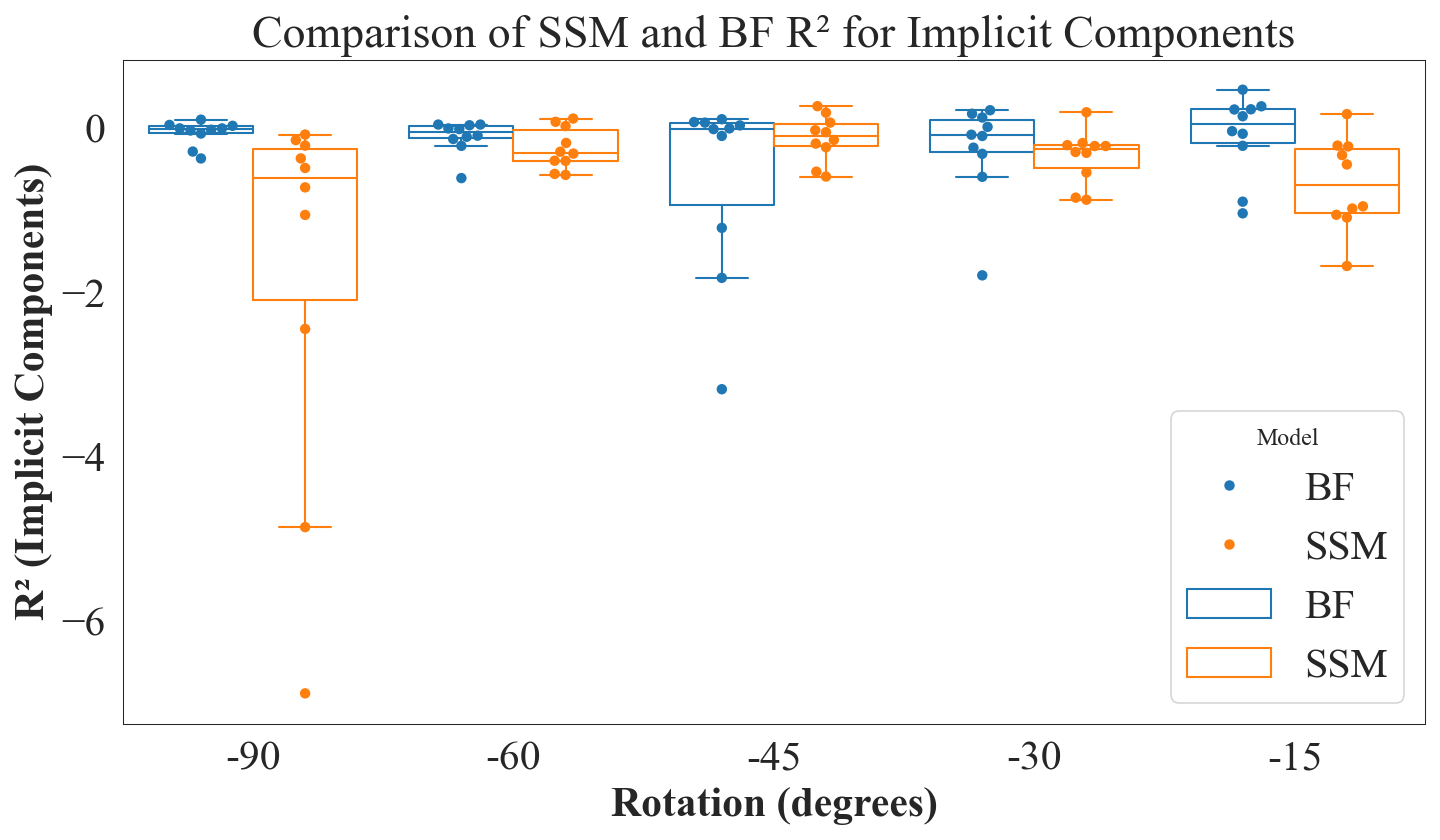

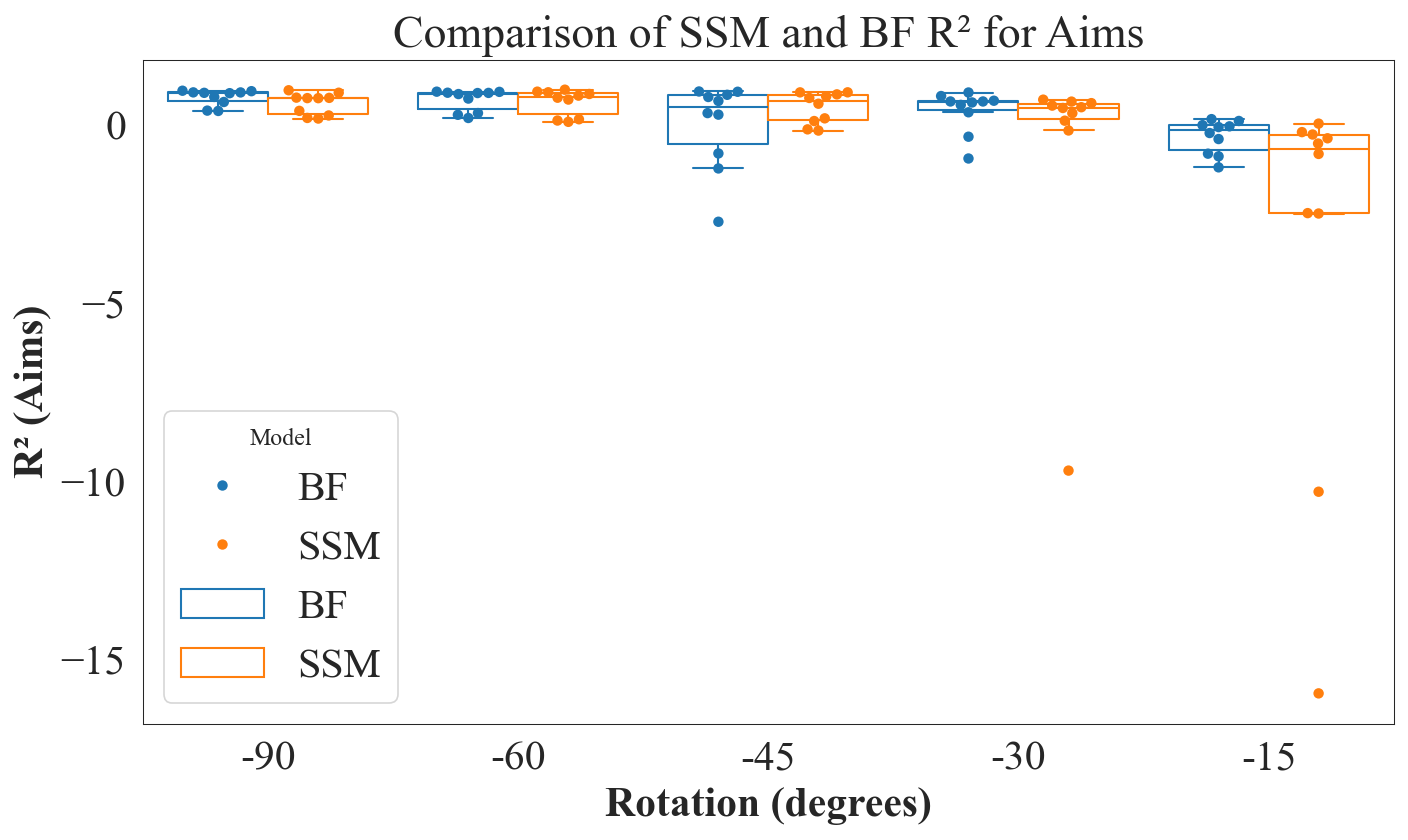

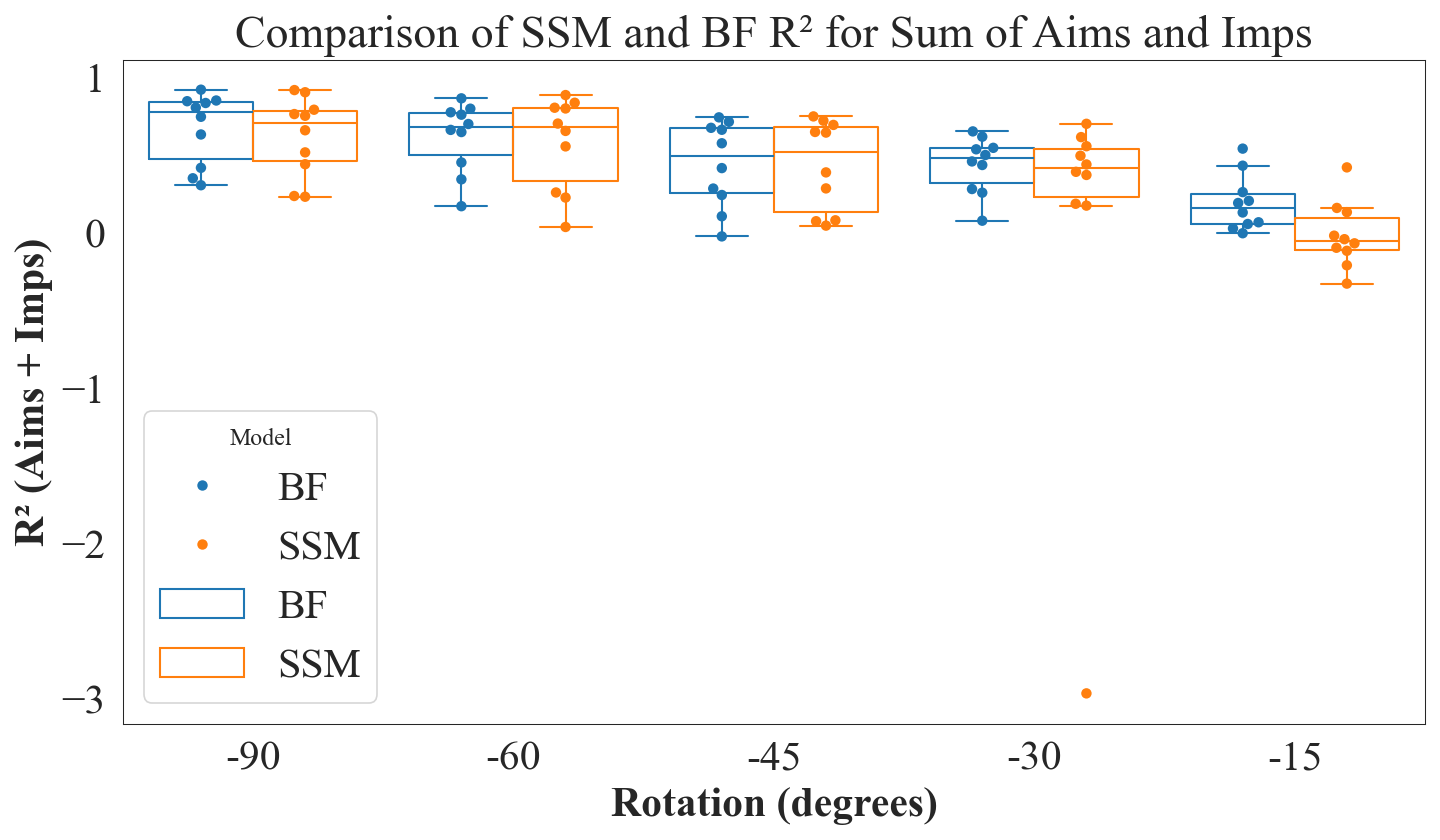

In [9]:
                                                         
                                        
def computeRSquared(trueValues, predValues):
    trueValues = np.array(trueValues)
    predValues = np.array(predValues)
    if len(trueValues) != len(predValues):
        raise ValueError("Arrays must have the same length")
    ssRes = np.nansum((trueValues - predValues) ** 2)
    ssTot = np.nansum((trueValues - np.nanmean(trueValues)) ** 2)
    if ssTot == 0:
        return 1.0 if ssRes == 0 else 0.0
    return 1 - (ssRes / ssTot)



                                                                       
rots = [-90, -60, -45, -30, -15]

                                          
def create_plot(data, title, ylabel, filename=None):
    plt.figure(figsize=(10, 6))
    sns.swarmplot(x='Rotation', y='R2', hue='Model', data=data, dodge=True, palette=['#1f77b4', '#ff7f0e'])
    sns.boxplot(x='Rotation', y='R2', hue='Model', data=data, dodge=True, fill=False, palette=['#1f77b4', '#ff7f0e'], fliersize=0)
    plt.xlabel('Rotation (degrees)')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(title='Model')
    plt.tight_layout()
    if filename:
        plt.savefig(filename)
    plt.show()

                                        
imp_data = []
for i in range(len(rots)):
    humanImps = BTDualSSM[i].allImps
    ssmImps = BTDualSSM[i].mOut2
    BFImps = BTBOCD[i].implicitComps
    ssmImpR2 = [computeRSquared(humanImps[j], ssmImps[j]) for j in range(len(humanImps))]
    BFImpR2 = [computeRSquared(humanImps[j], BFImps[j]) for j in range(len(humanImps))]
    for ssm_r2, bf_r2 in zip(ssmImpR2, BFImpR2):
        imp_data.append({'Rotation': rots[i], 'R2': bf_r2, 'Model': 'BF'})
        imp_data.append({'Rotation': rots[i], 'R2': ssm_r2, 'Model': 'SSM'})
imp_df = pd.DataFrame(imp_data)
create_plot(imp_df, 'Comparison of SSM and BF R² for Implicit Components', 'R² (Implicit Components)')

                  
aim_data = []
for i in range(len(rots)):
    humanAims = BTDualSSM[i].allAims
    ssmAims = BTDualSSM[i].mOut1
    BFAims = np.subtract(BTBOCD[i].mStates, BTBOCD[i].implicitComps)
    ssmAimR2 = [computeRSquared(humanAims[j], ssmAims[j]) for j in range(len(humanAims))]
    BFAimR2 = [computeRSquared(humanAims[j], BFAims[j]) for j in range(len(humanAims))]
    for ssm_r2, bf_r2 in zip(ssmAimR2, BFAimR2):
        aim_data.append({'Rotation': rots[i], 'R2': bf_r2, 'Model': 'BF'})
        aim_data.append({'Rotation': rots[i], 'R2': ssm_r2, 'Model': 'SSM'})
        
aim_df = pd.DataFrame(aim_data)
create_plot(aim_df, 'Comparison of SSM and BF R² for Aims', 'R² (Aims)')

                                  
sum_data = []
for i in range(len(rots)):
    humanImps = BTDualSSM[i].allImps
    humanAims = BTDualSSM[i].allAims
    ssmImps = BTDualSSM[i].mOut2
    ssmAims = BTDualSSM[i].mOut1
    BFImps = BTBOCD[i].implicitComps
    BFAims = np.subtract(BTBOCD[i].mStates, BTBOCD[i].implicitComps)
    humanSum = np.add(humanAims, humanImps)
    ssmSum = np.add(ssmAims, ssmImps)
    BFSum = np.add(BFAims, BFImps)
    ssmSumR2 = [computeRSquared(humanSum[j], ssmSum[j]) for j in range(len(humanSum))]
    BFSumR2 = [computeRSquared(humanSum[j], BFSum[j]) for j in range(len(humanSum))]
    for ssm_r2, bf_r2 in zip(ssmSumR2, BFSumR2):
        sum_data.append({'Rotation': rots[i], 'R2': bf_r2, 'Model': 'BF'})
        sum_data.append({'Rotation': rots[i], 'R2': ssm_r2, 'Model': 'SSM'})
sum_df = pd.DataFrame(sum_data)
create_plot(sum_df, 'Comparison of SSM and BF R² for Sum of Aims and Imps', 'R² (Aims + Imps)')

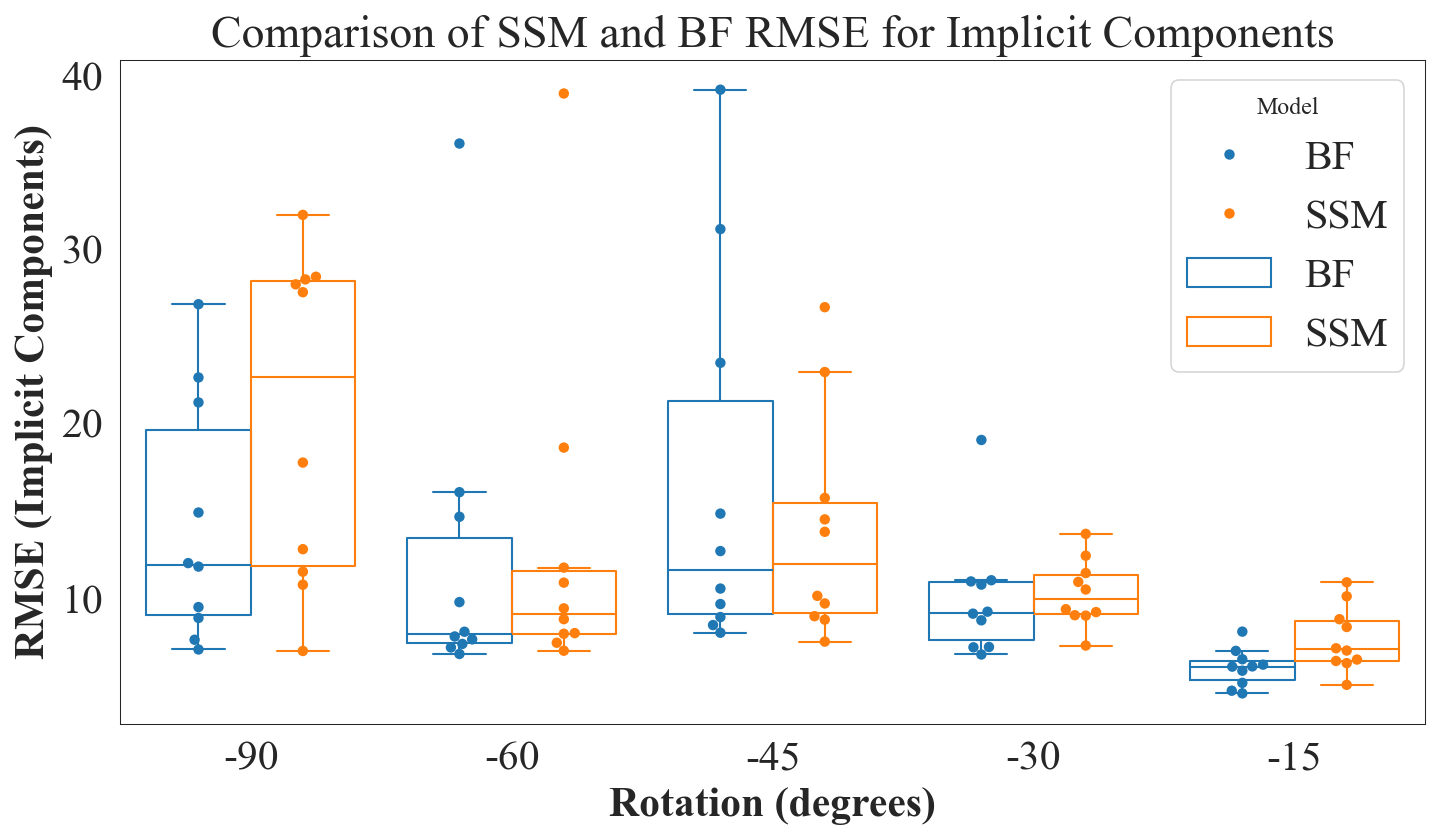

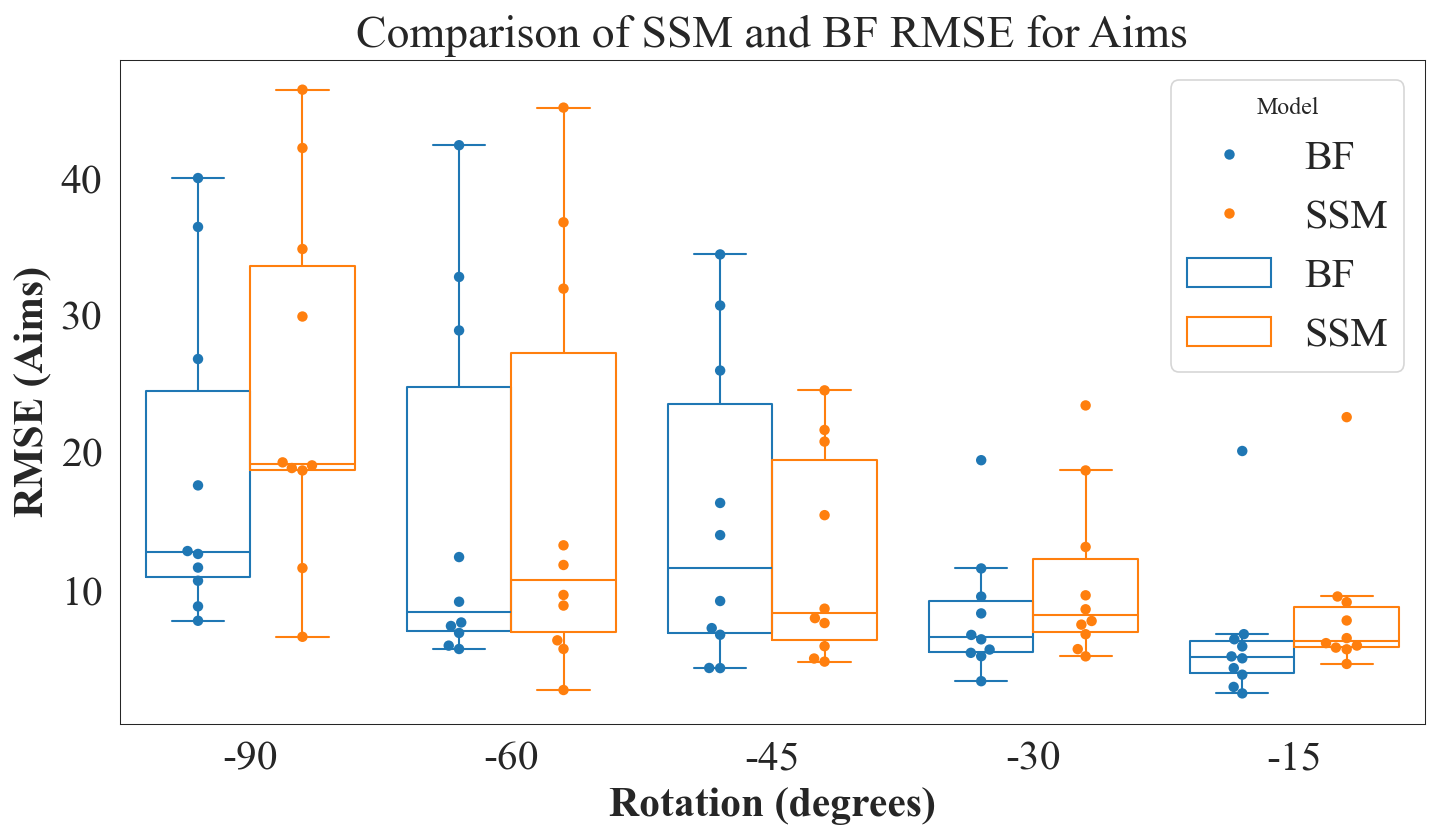

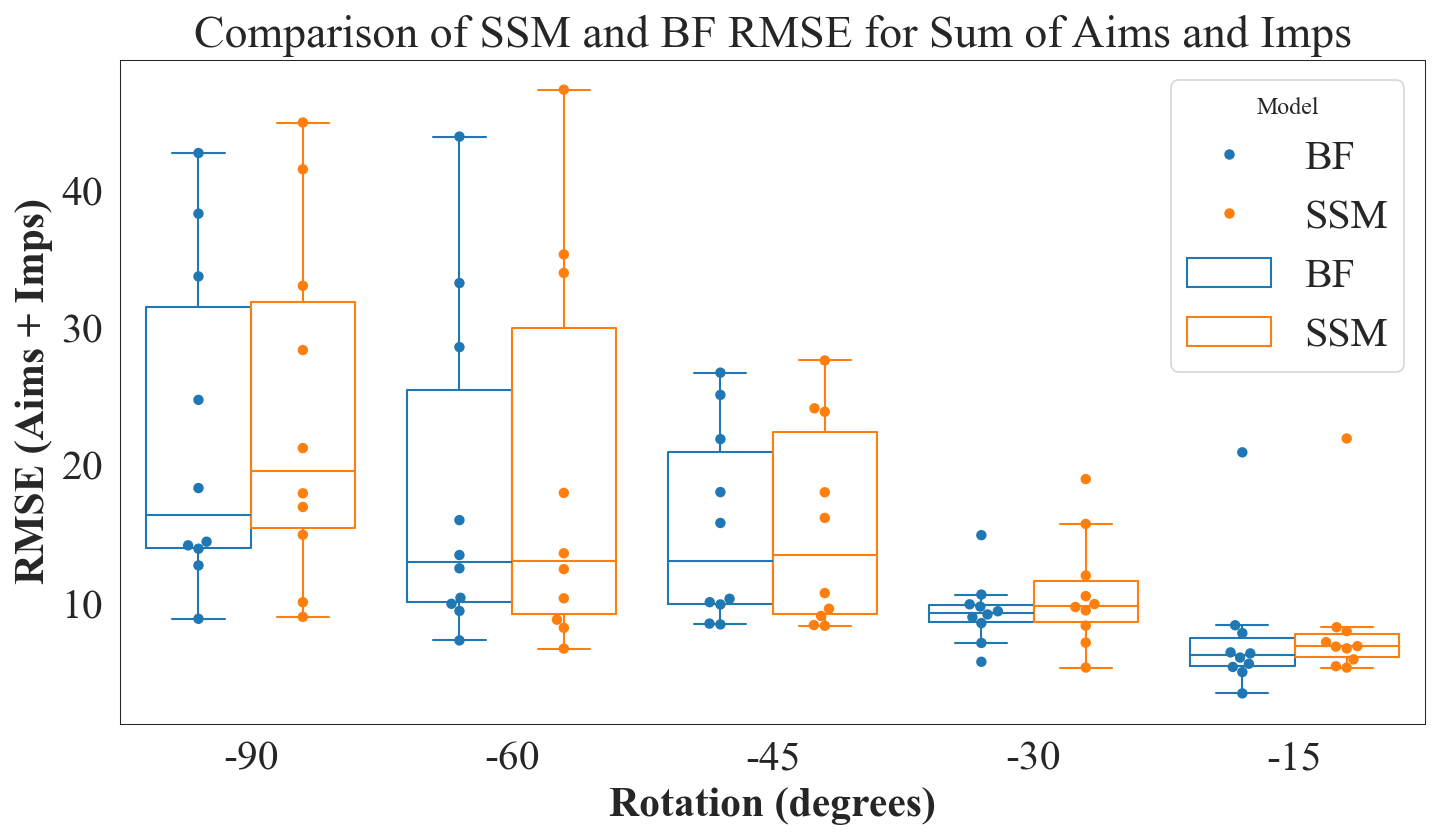

In [10]:

rots = [-90, -60, -45, -30, -15]

def computeRMSE(trueValues, predValues):
    trueValues = np.array(trueValues)
    predValues = np.array(predValues)
    if len(trueValues) != len(predValues):
        raise ValueError("Arrays must have the same length")
    mse = np.nanmean((trueValues - predValues) ** 2)
    return np.sqrt(mse)

                                          
def create_plot(data, title, ylabel, filename=None):
    plt.figure(figsize=(10, 6))
    hue_order = ['BF', 'SSM']
    palette = {'BF': '#1f77b4', 'SSM': '#ff7f0e'}
    sns.swarmplot(x='Rotation', y='RMSE', hue='Model', hue_order=hue_order, data=data, dodge=True, palette=palette)
    sns.boxplot(x='Rotation', y='RMSE', hue='Model', hue_order=hue_order, data=data, dodge=True, fill=False, palette=palette, fliersize=0)
    plt.xlabel('Rotation (degrees)')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(title='Model')
    plt.tight_layout()
    if filename:
        plt.savefig(filename)
    plt.show()

                                        
imp_data = []
for i in range(len(rots)):
    humanImps = BTDualSSM[i].allImps
    ssmImps = BTDualSSM[i].mOut2
    BFImps = BTBOCD[i].implicitComps
    ssmImpRMSE = [computeRMSE(humanImps[j], ssmImps[j]) for j in range(len(humanImps))]
    BFImpRMSE = [computeRMSE(humanImps[j], BFImps[j]) for j in range(len(humanImps))]
    for bf_rmse, ssm_rmse in zip(BFImpRMSE, ssmImpRMSE):
        imp_data.append({'Rotation': rots[i], 'RMSE': bf_rmse, 'Model': 'BF'})
        imp_data.append({'Rotation': rots[i], 'RMSE': ssm_rmse, 'Model': 'SSM'})
imp_df = pd.DataFrame(imp_data)
create_plot(imp_df, 'Comparison of SSM and BF RMSE for Implicit Components', 'RMSE (Implicit Components)')

                  
aim_data = []
for i in range(len(rots)):
    humanAims = BTDualSSM[i].allAims
    ssmAims = BTDualSSM[i].mOut1
    BFAims = np.subtract(BTBOCD[i].mStates, BTBOCD[i].implicitComps)
    ssmAimRMSE = [computeRMSE(humanAims[j], ssmAims[j]) for j in range(len(humanAims))]
    BFAimRMSE = [computeRMSE(humanAims[j], BFAims[j]) for j in range(len(humanAims))]
    for bf_rmse, ssm_rmse in zip(BFAimRMSE, ssmAimRMSE):
        aim_data.append({'Rotation': rots[i], 'RMSE': bf_rmse, 'Model': 'BF'})
        aim_data.append({'Rotation': rots[i], 'RMSE': ssm_rmse, 'Model': 'SSM'})
aim_df = pd.DataFrame(aim_data)
create_plot(aim_df, 'Comparison of SSM and BF RMSE for Aims', 'RMSE (Aims)')

                                  
sum_data = []
for i in range(len(rots)):
    humanImps = BTDualSSM[i].allImps
    humanAims = BTDualSSM[i].allAims
    ssmImps = BTDualSSM[i].mOut2
    ssmAims = BTDualSSM[i].mOut1
    BFImps = BTBOCD[i].implicitComps
    BFAims = np.subtract(BTBOCD[i].mStates, BTBOCD[i].implicitComps)
    humanSum = np.add(humanAims, humanImps)
    ssmSum = np.add(ssmAims, ssmImps)
    BFSum = np.add(BFAims, BFImps)
    ssmSumRMSE = [computeRMSE(humanSum[j], ssmSum[j]) for j in range(len(humanSum))]
    BFSumRMSE = [computeRMSE(humanSum[j], BFSum[j]) for j in range(len(humanSum))]
    for bf_rmse, ssm_rmse in zip(BFSumRMSE, ssmSumRMSE):
        sum_data.append({'Rotation': rots[i], 'RMSE': bf_rmse, 'Model': 'BF'})
        sum_data.append({'Rotation': rots[i], 'RMSE': ssm_rmse, 'Model': 'SSM'})
sum_df = pd.DataFrame(sum_data)
create_plot(sum_df, 'Comparison of SSM and BF RMSE for Sum of Aims and Imps', 'RMSE (Aims + Imps)')

In [3]:
BrudDualSSM = np.load("BrudnerSsmsDelay5000_1Tar.npy",allow_pickle=True)
BrudBOCD = np.load("BrudnerSfmsConFLipsDelay5000_1Tar.npy",allow_pickle=True)

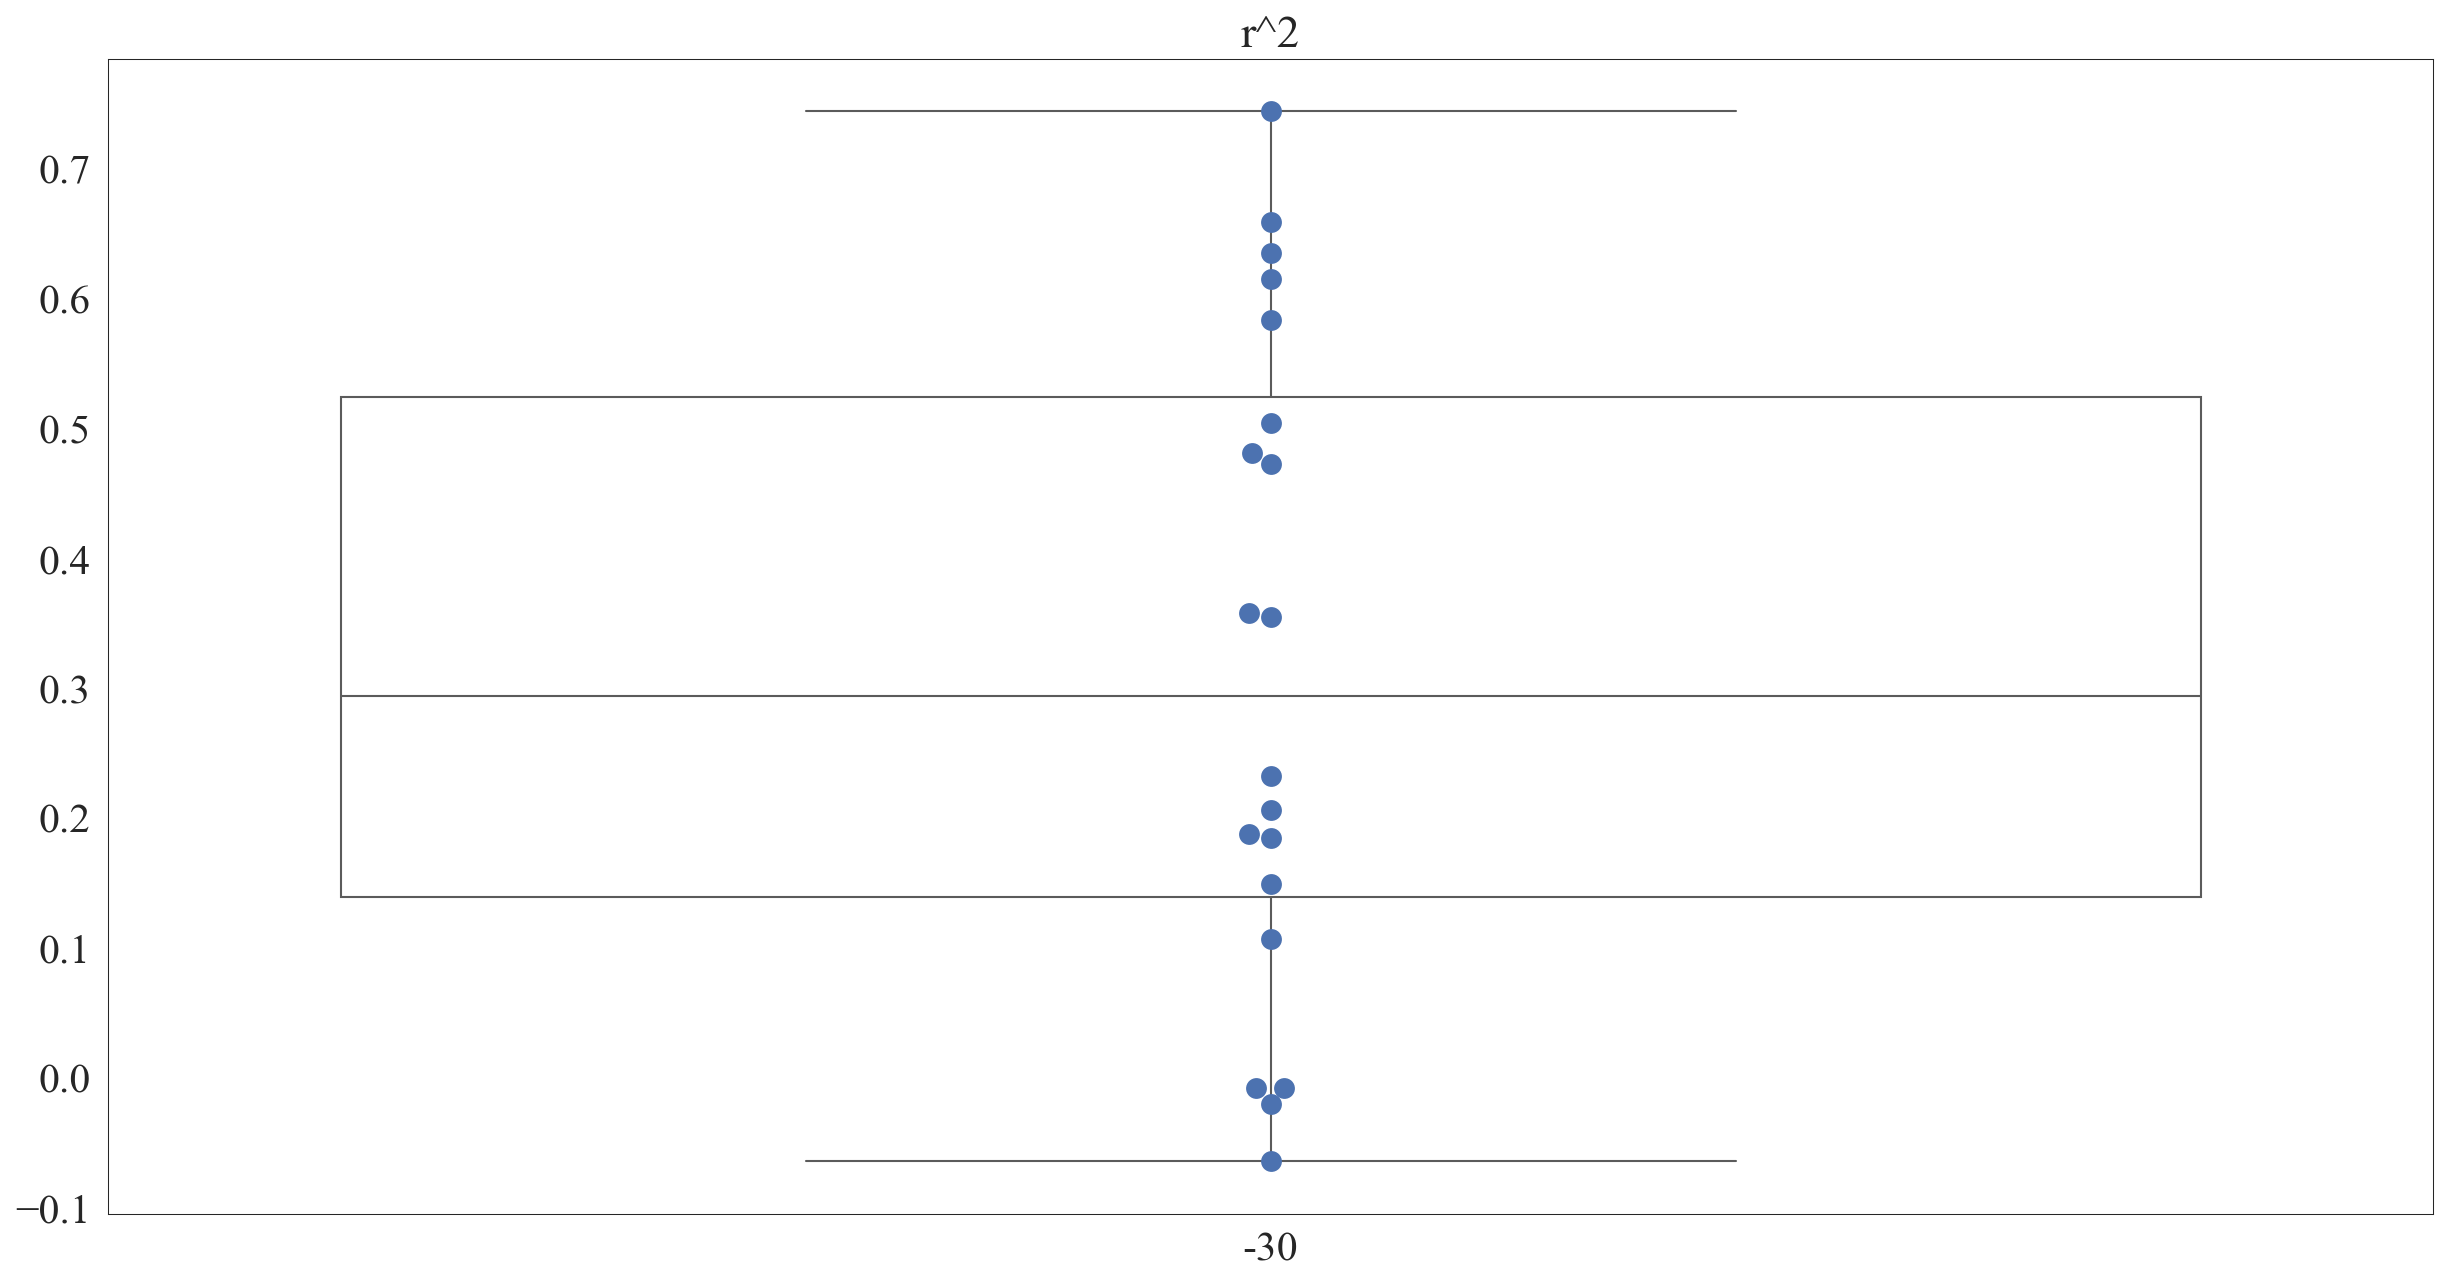

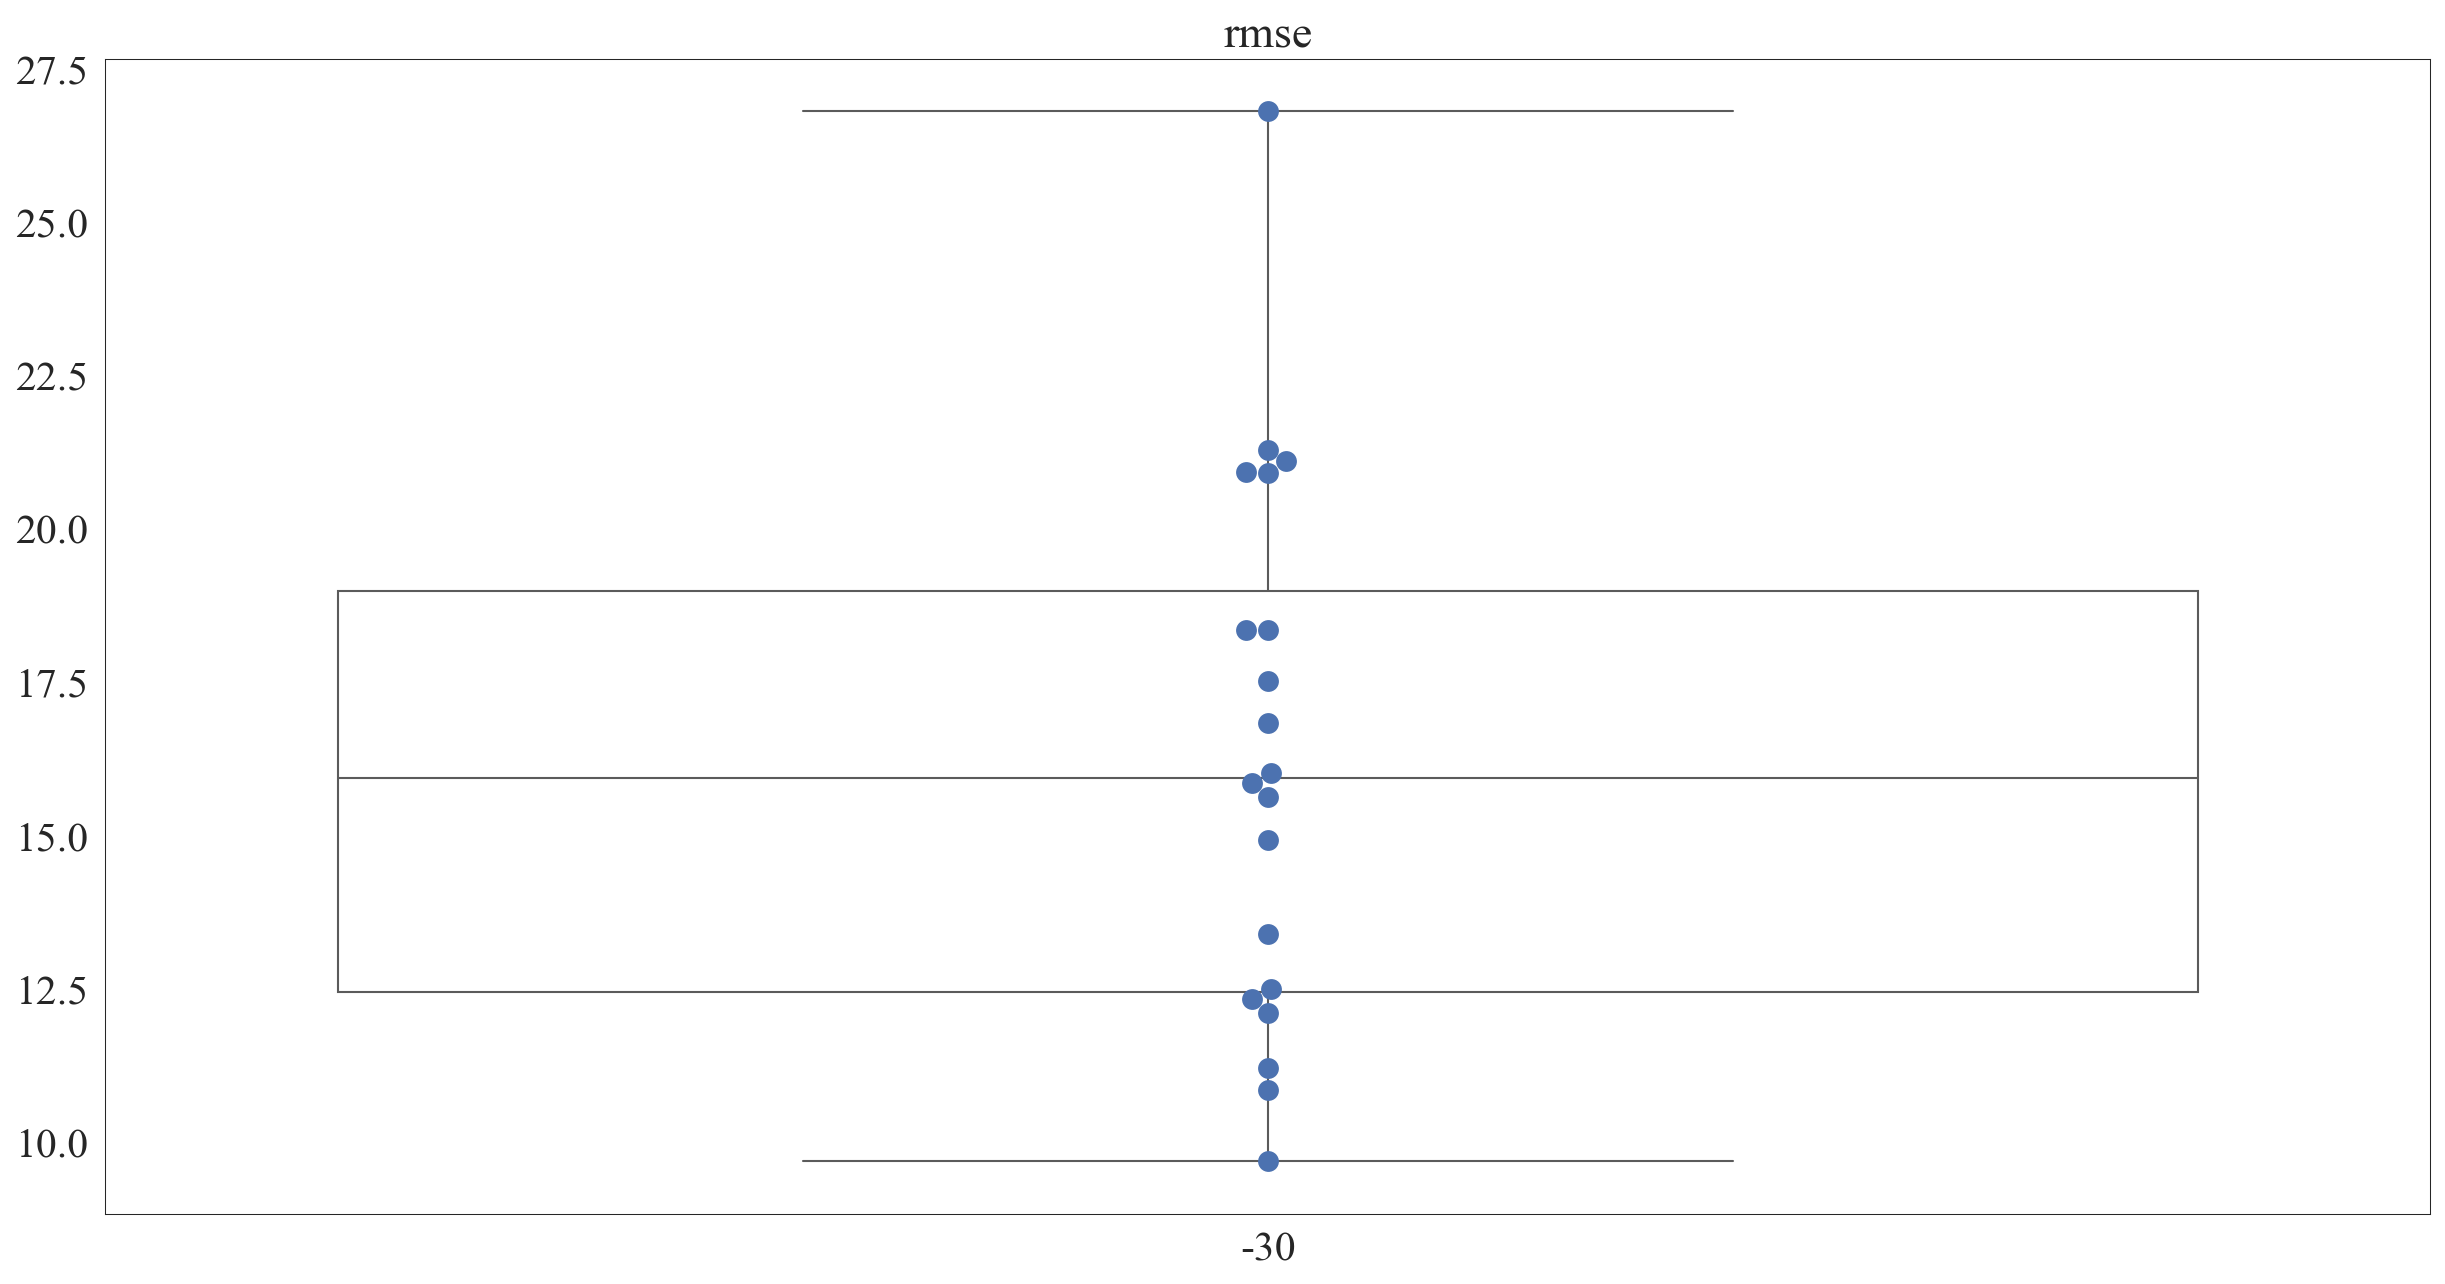

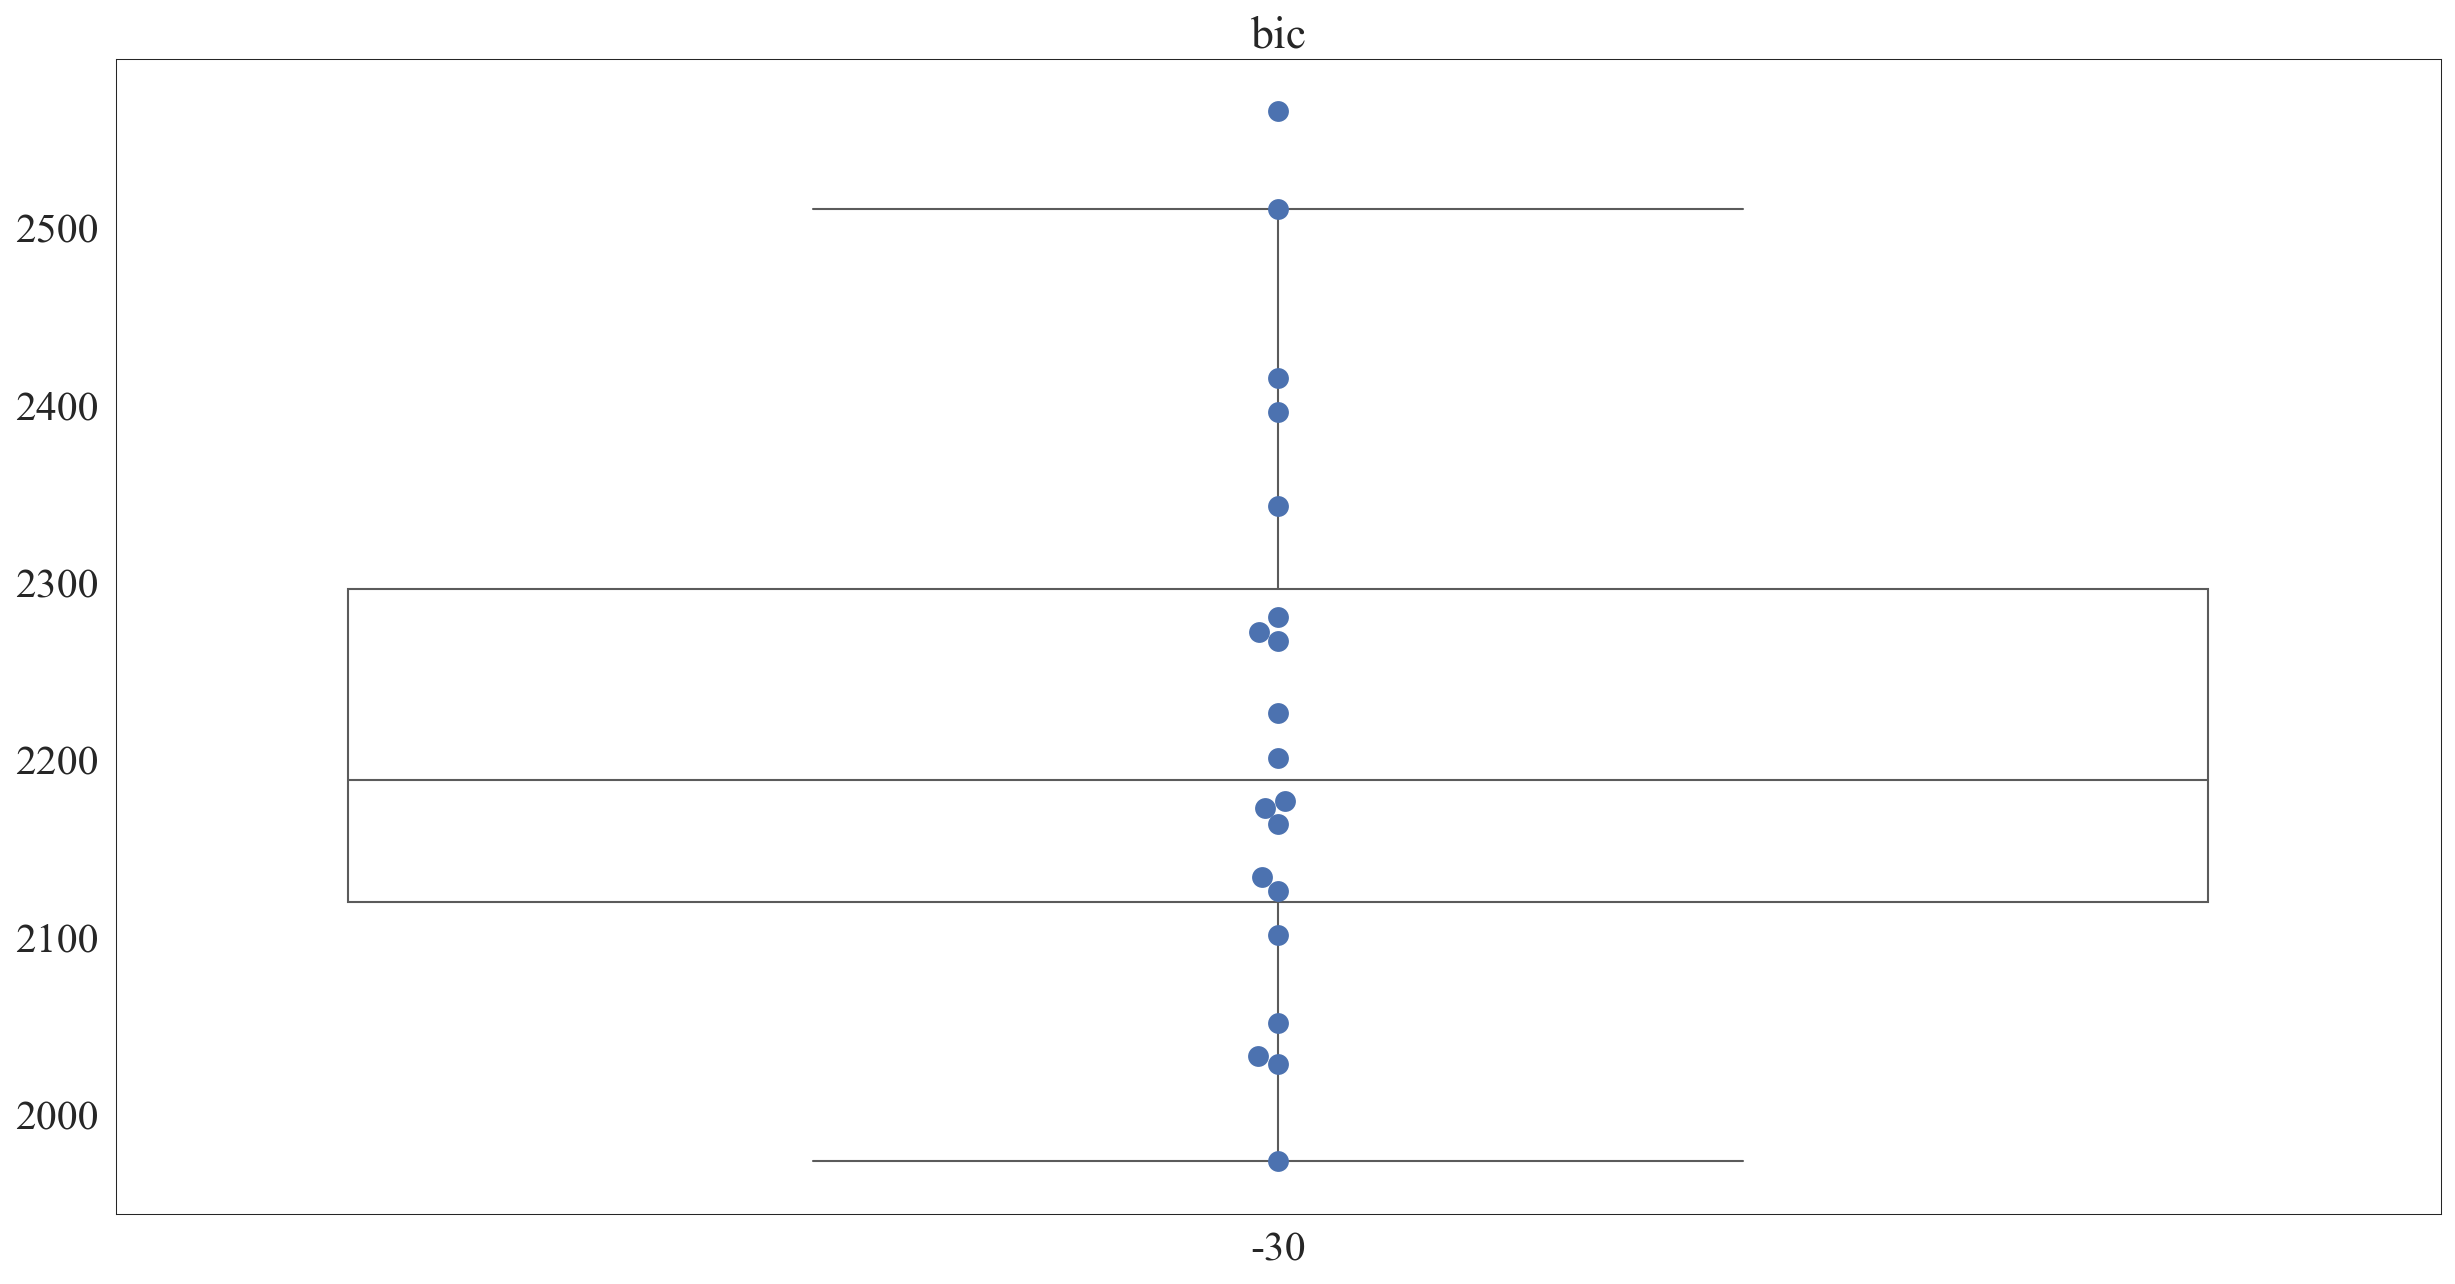

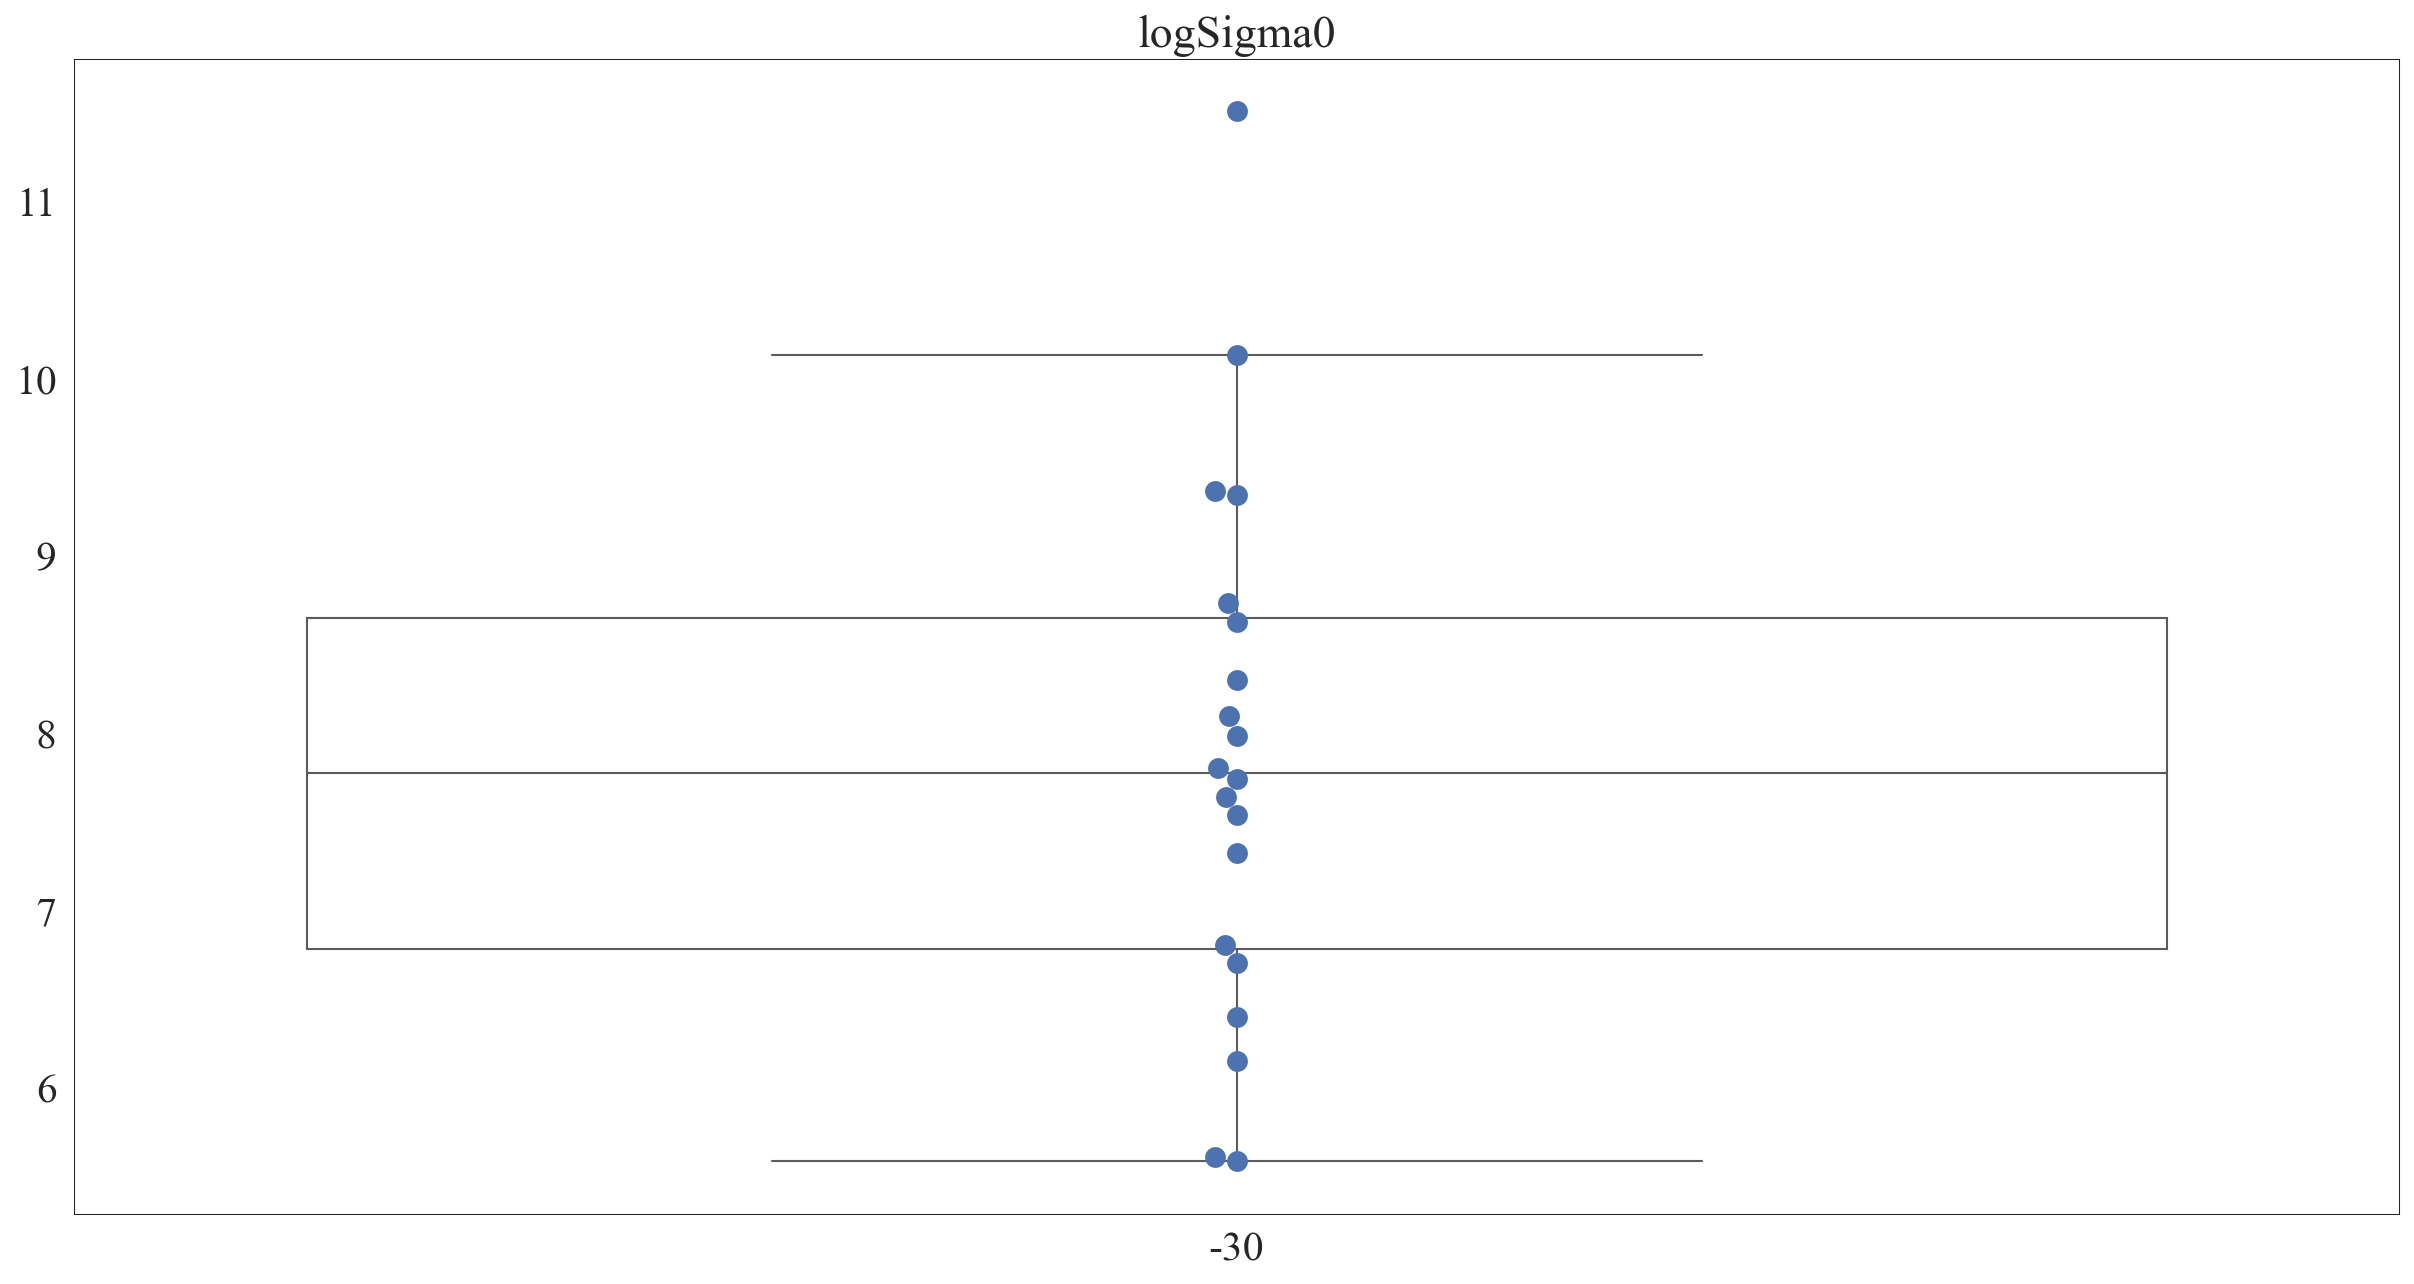

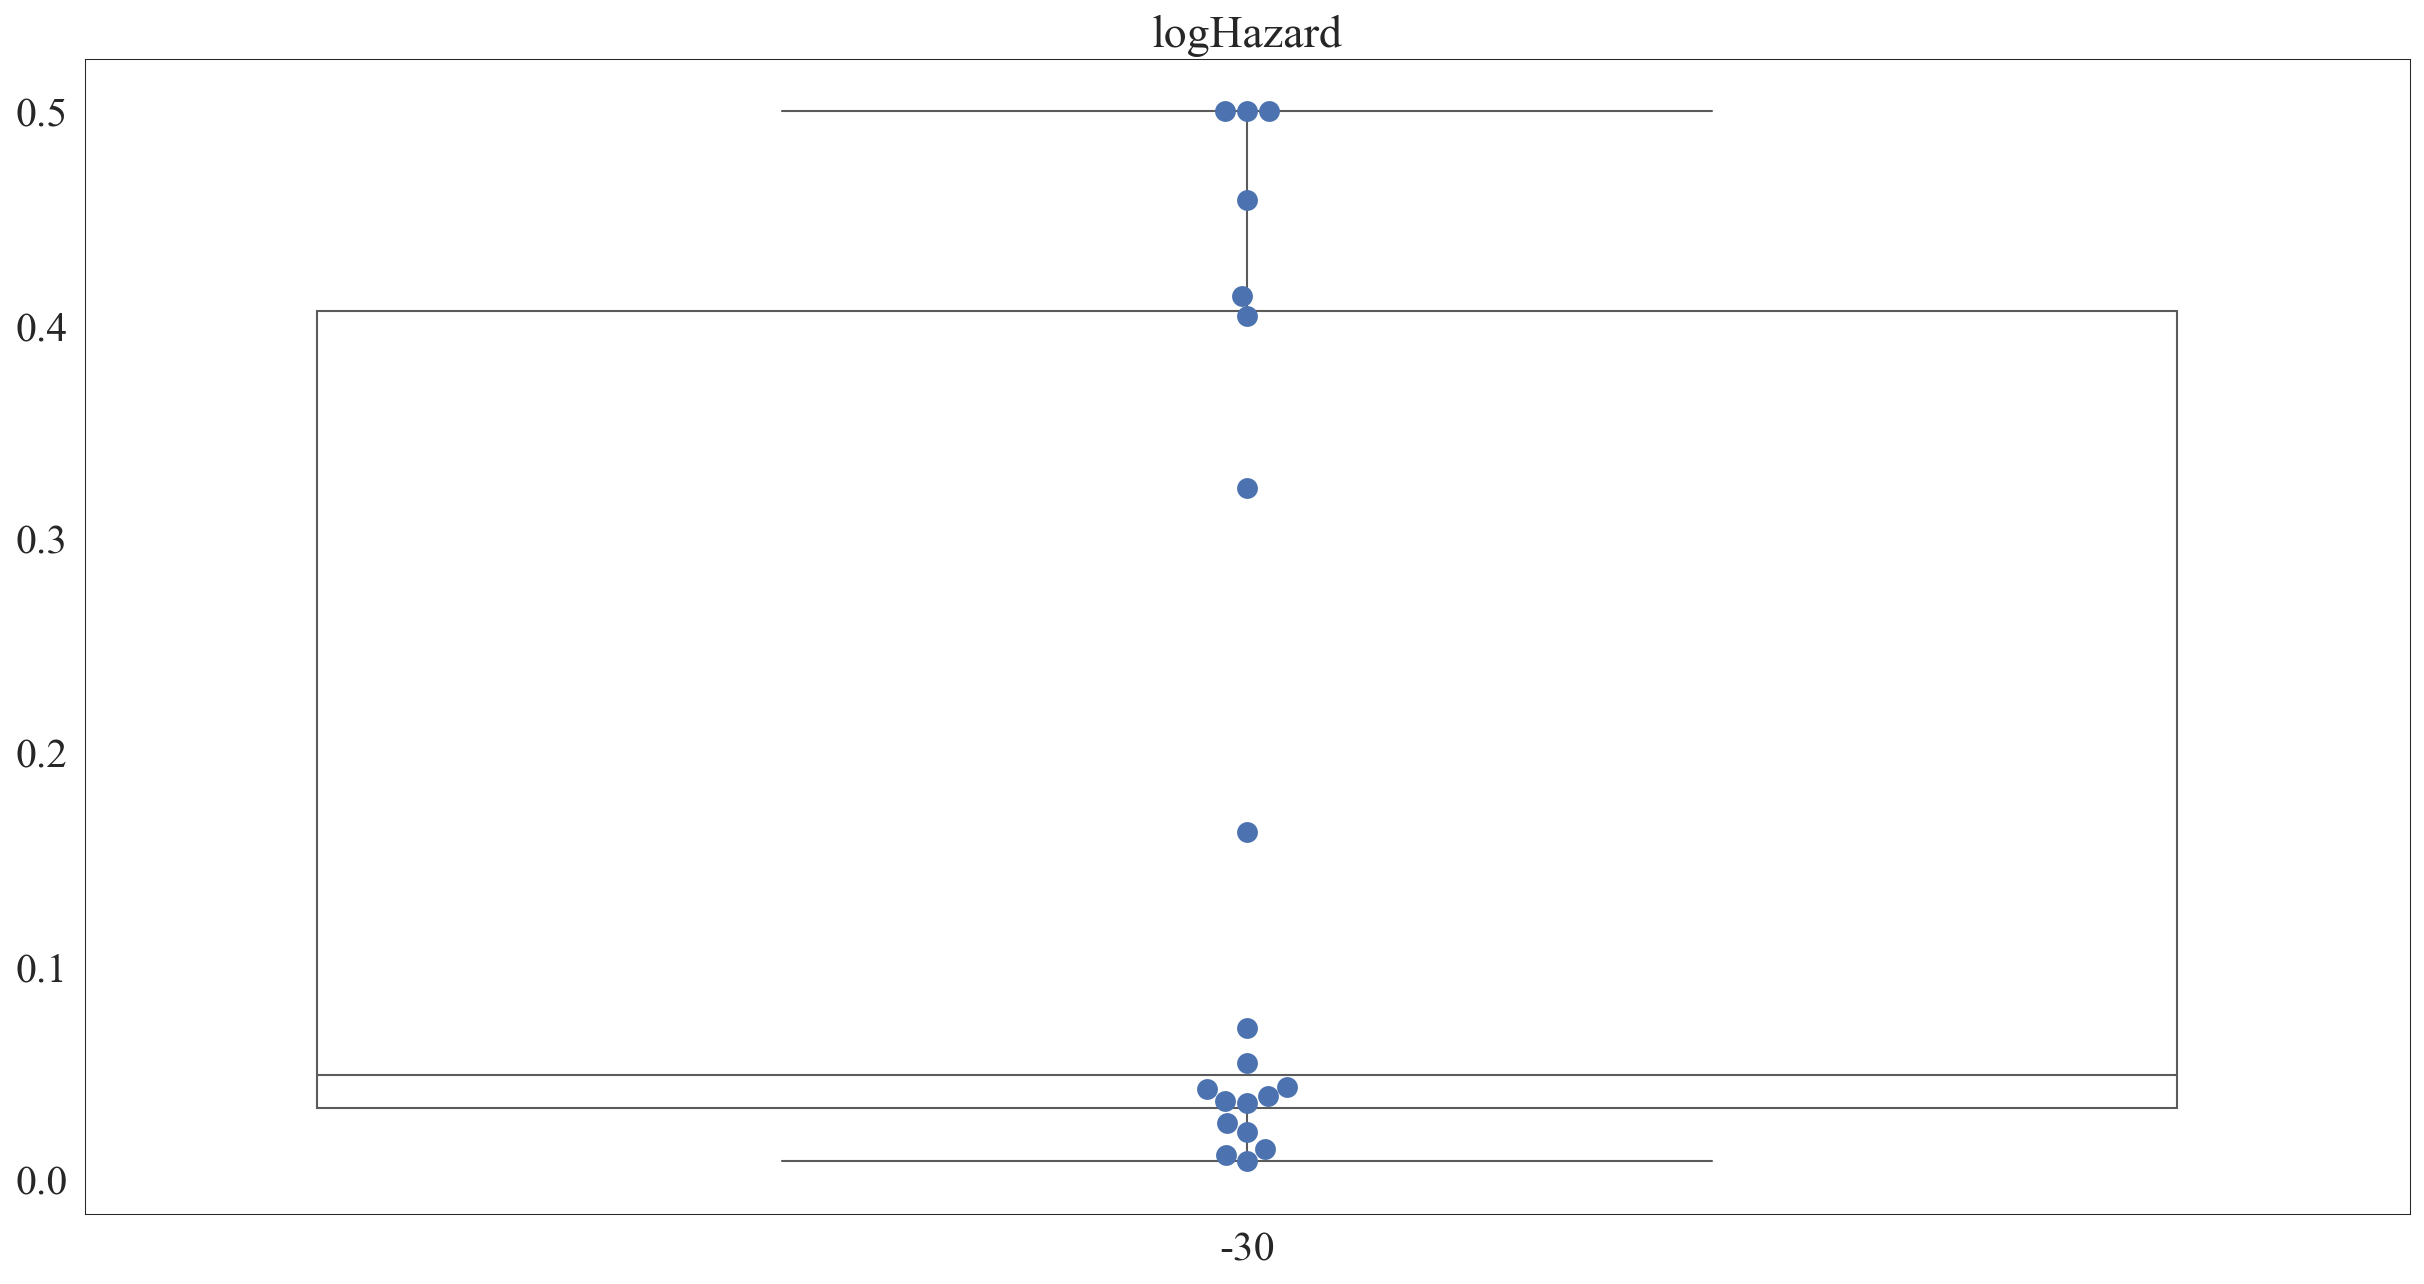

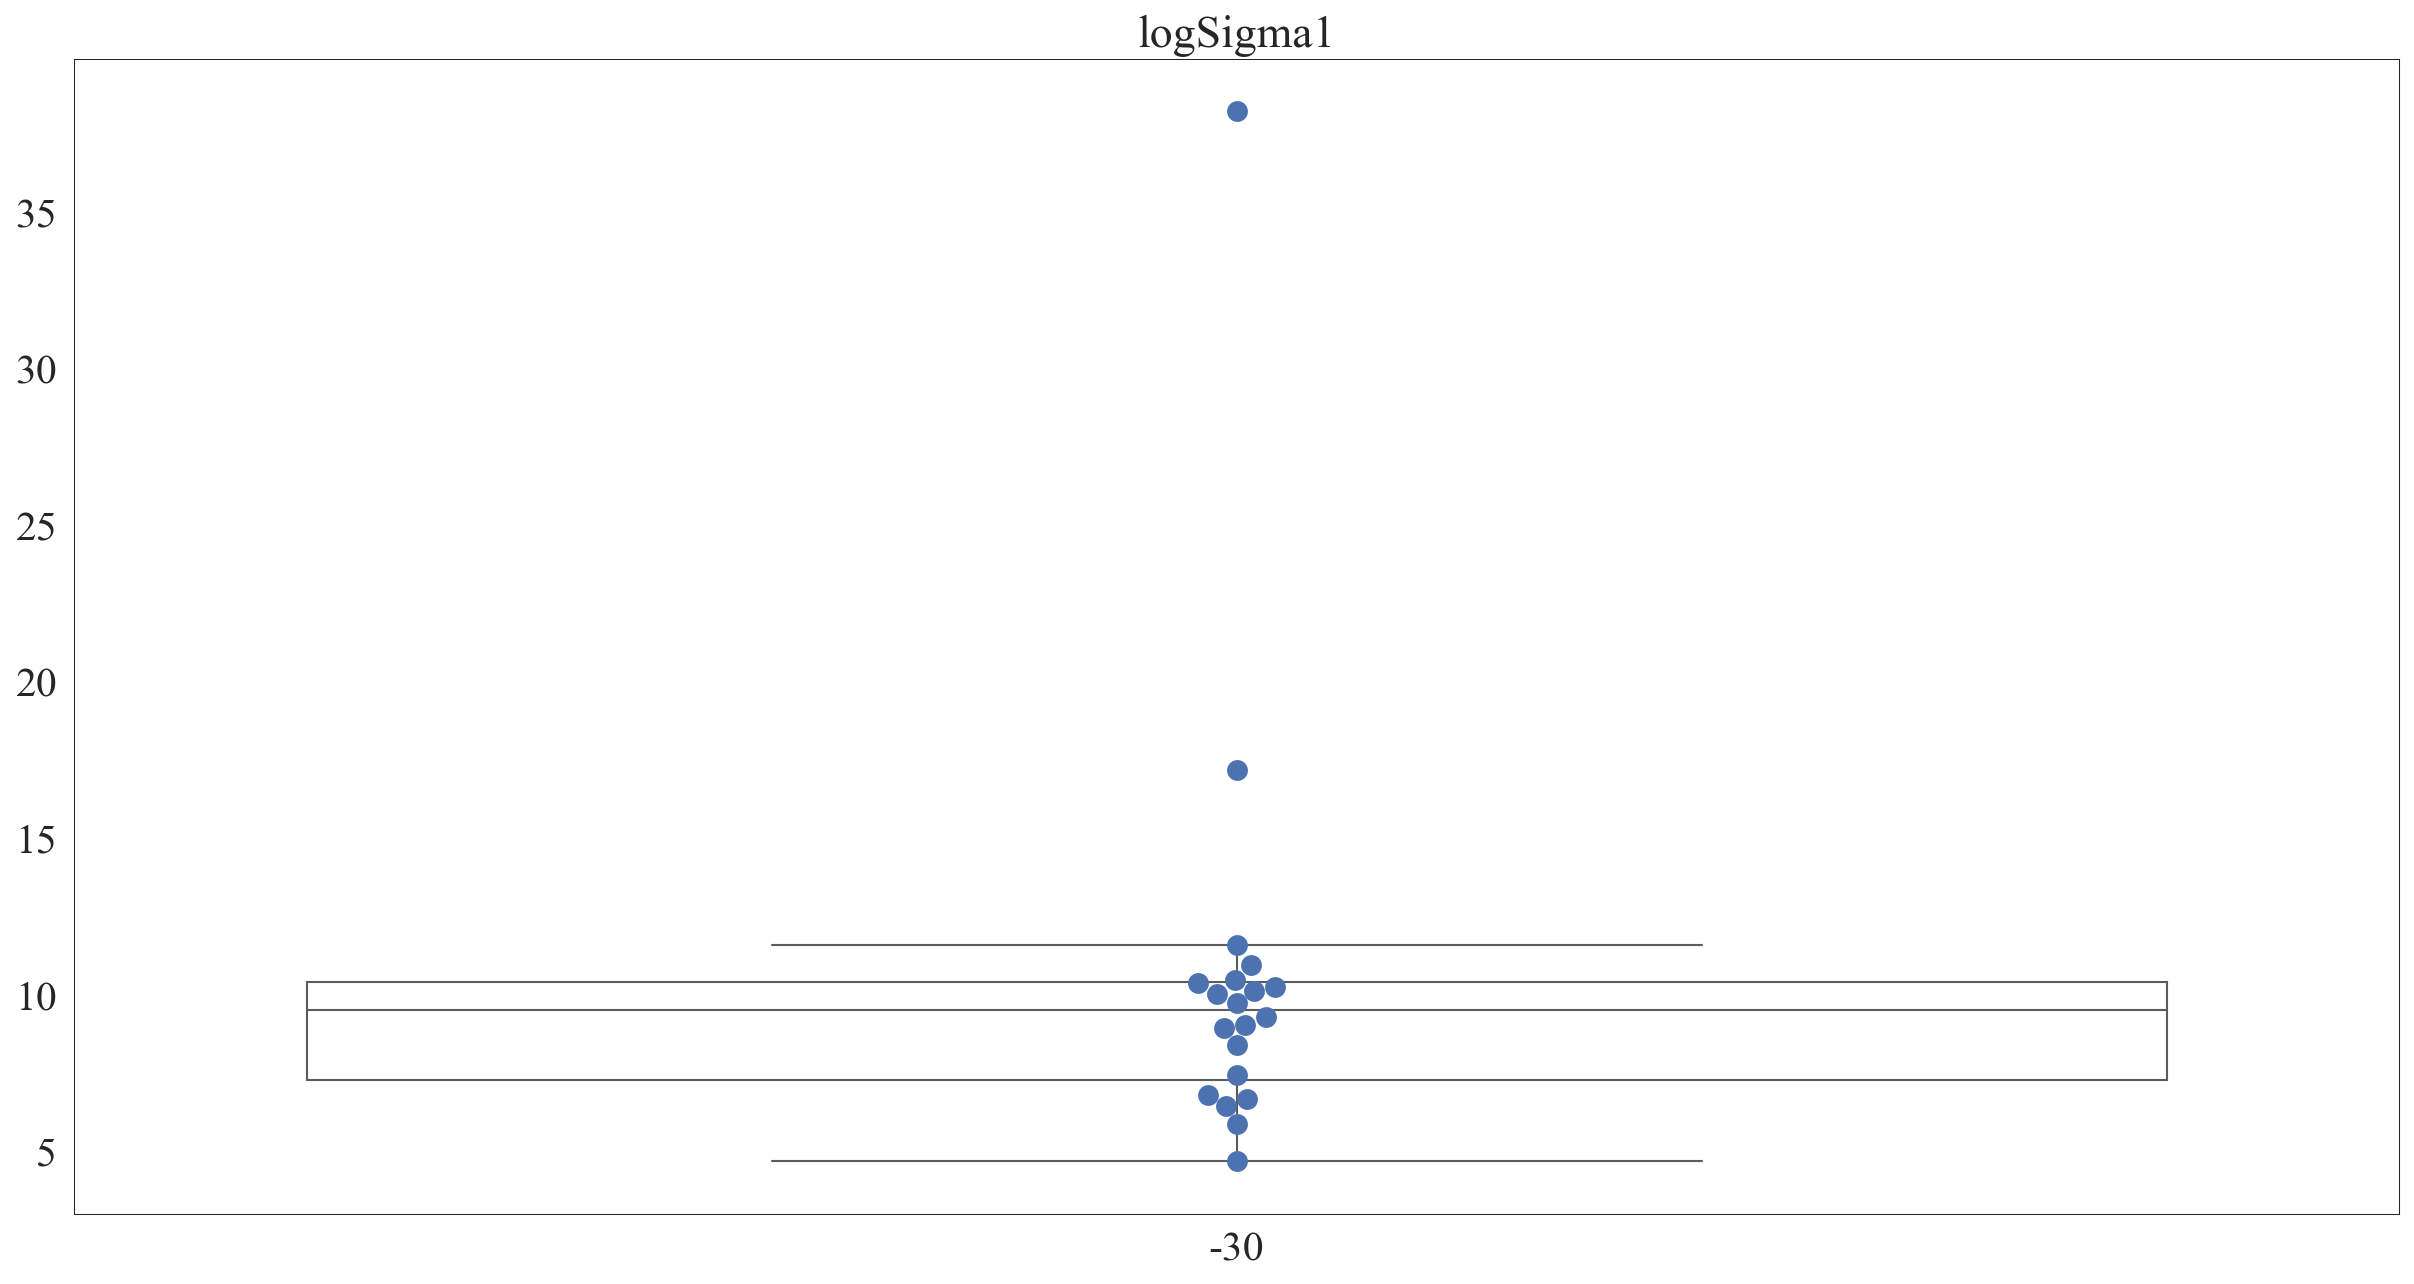

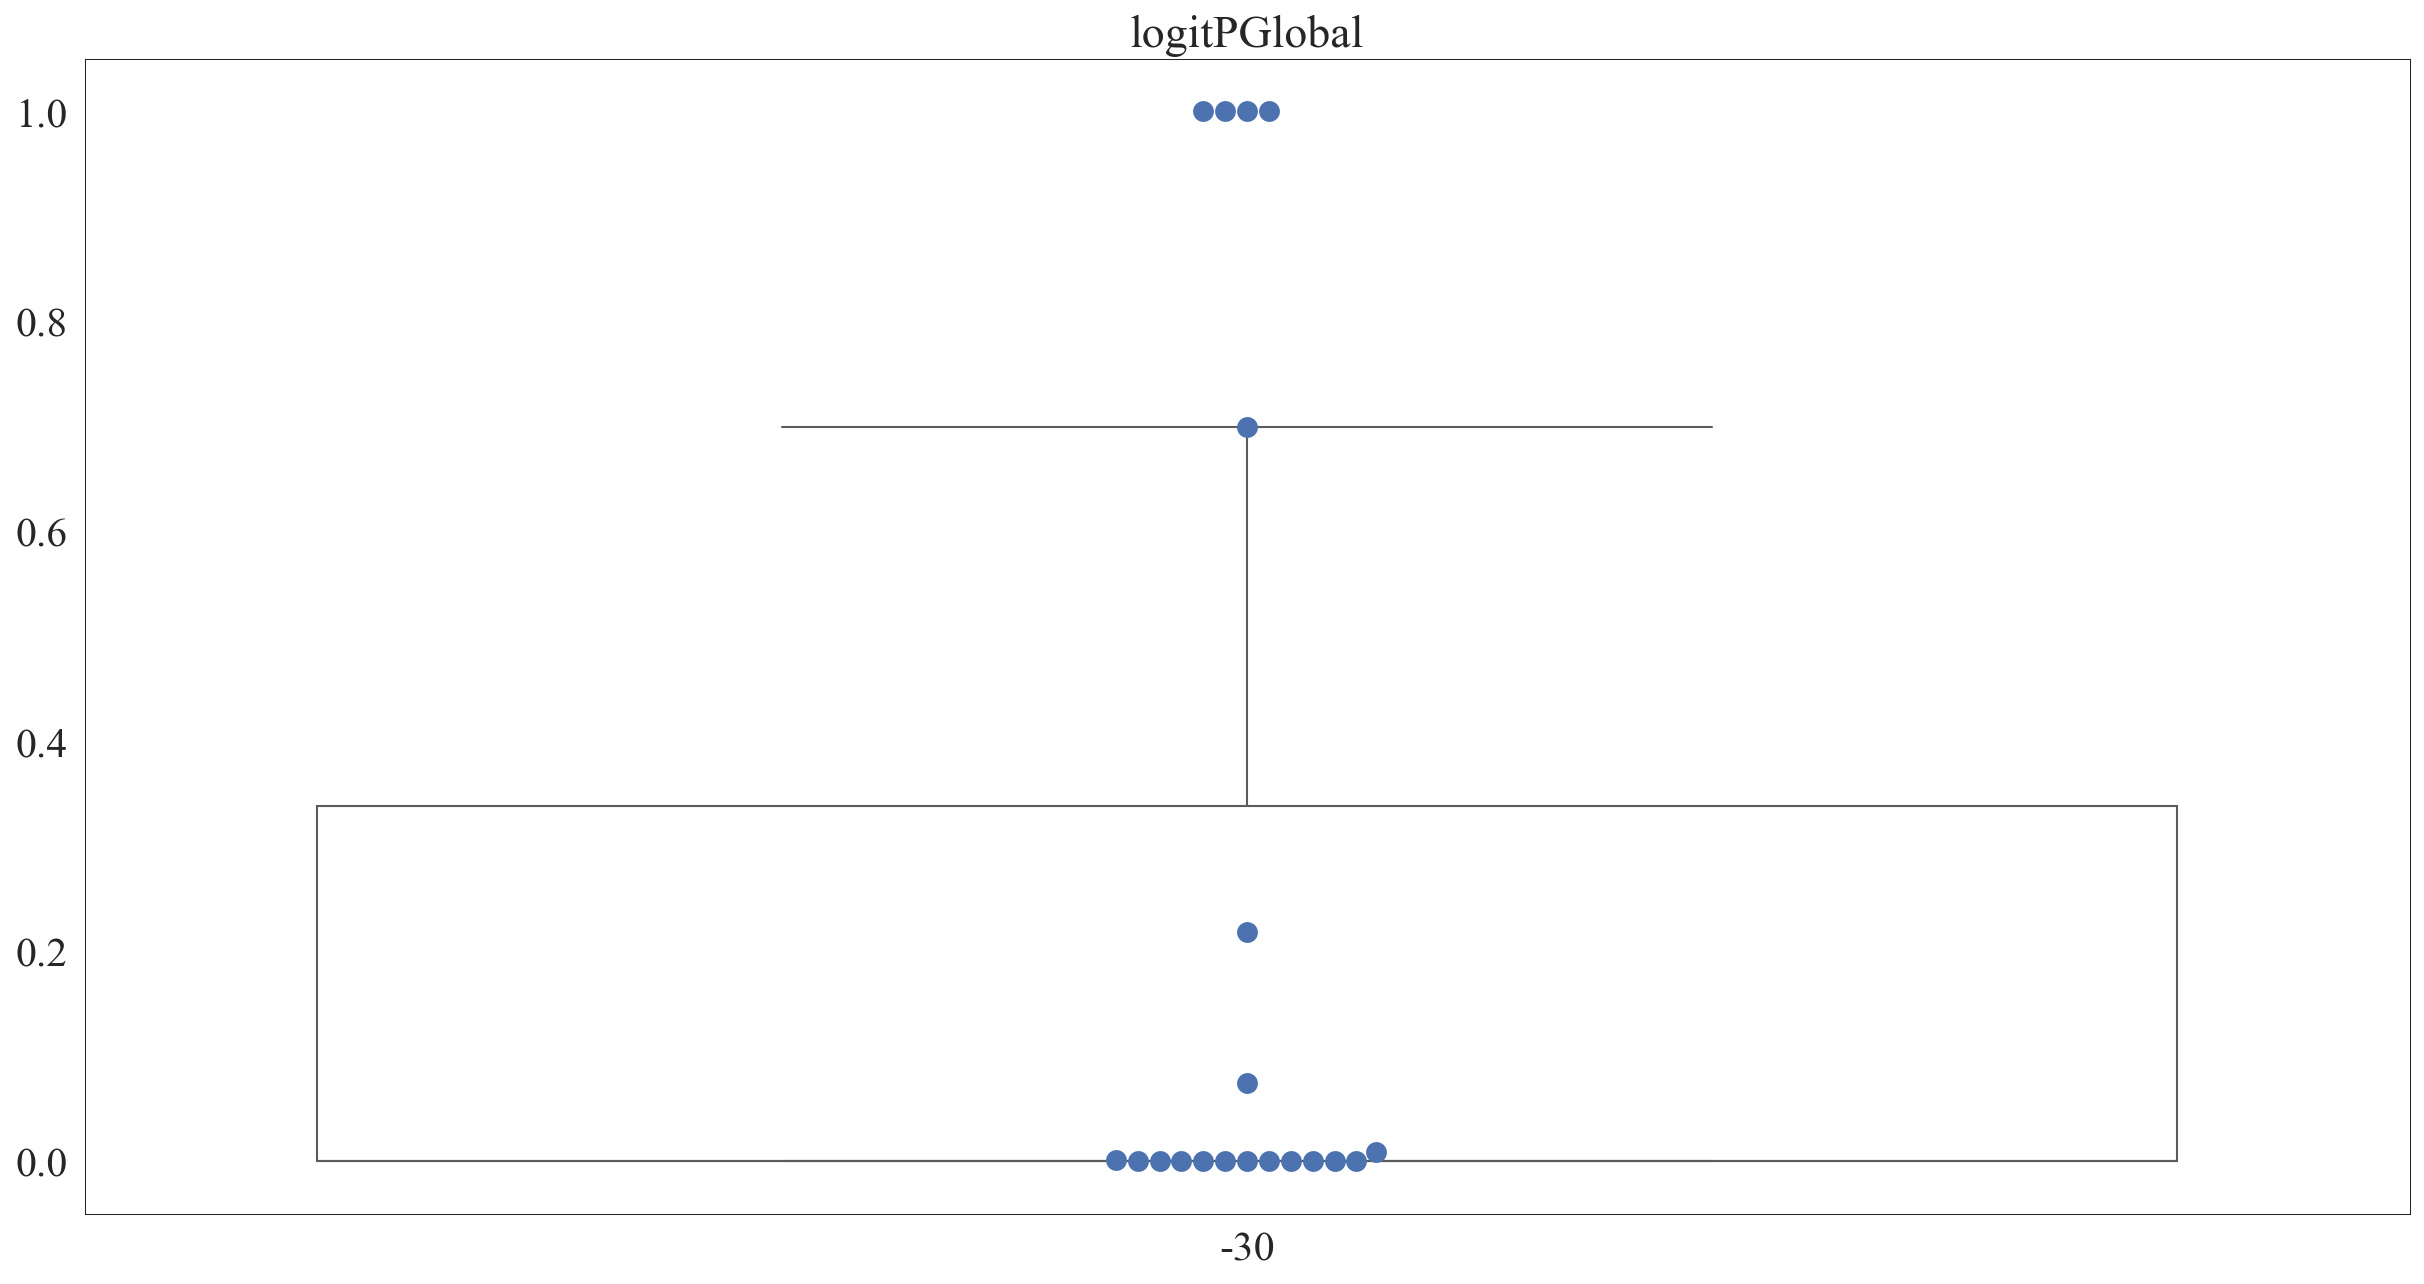

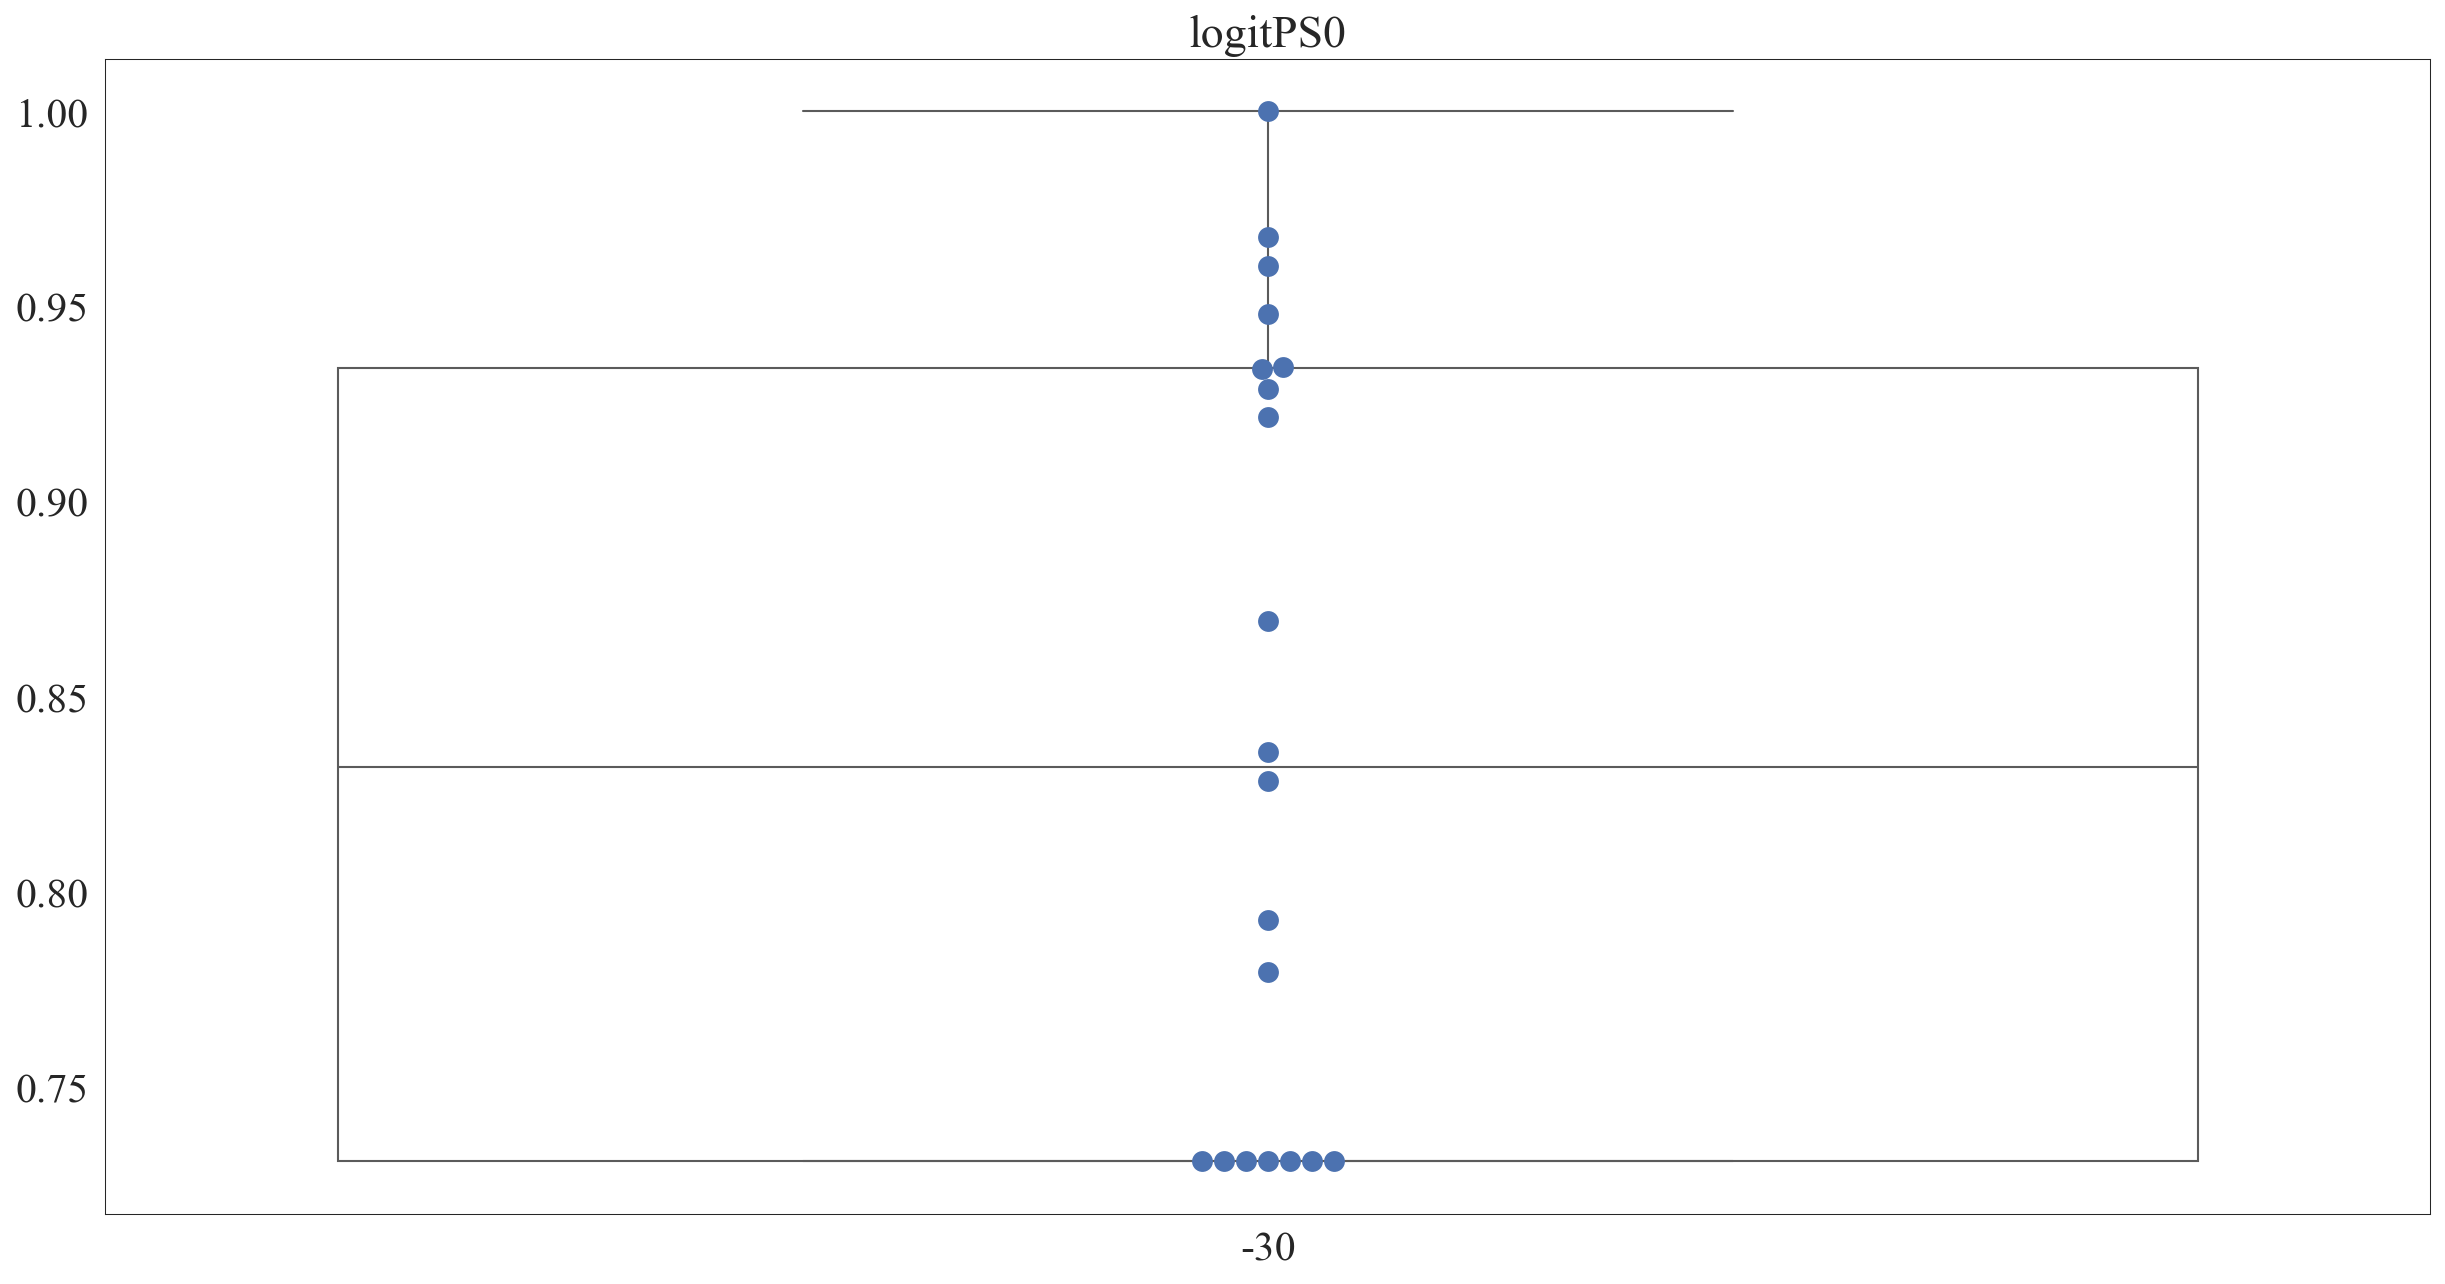

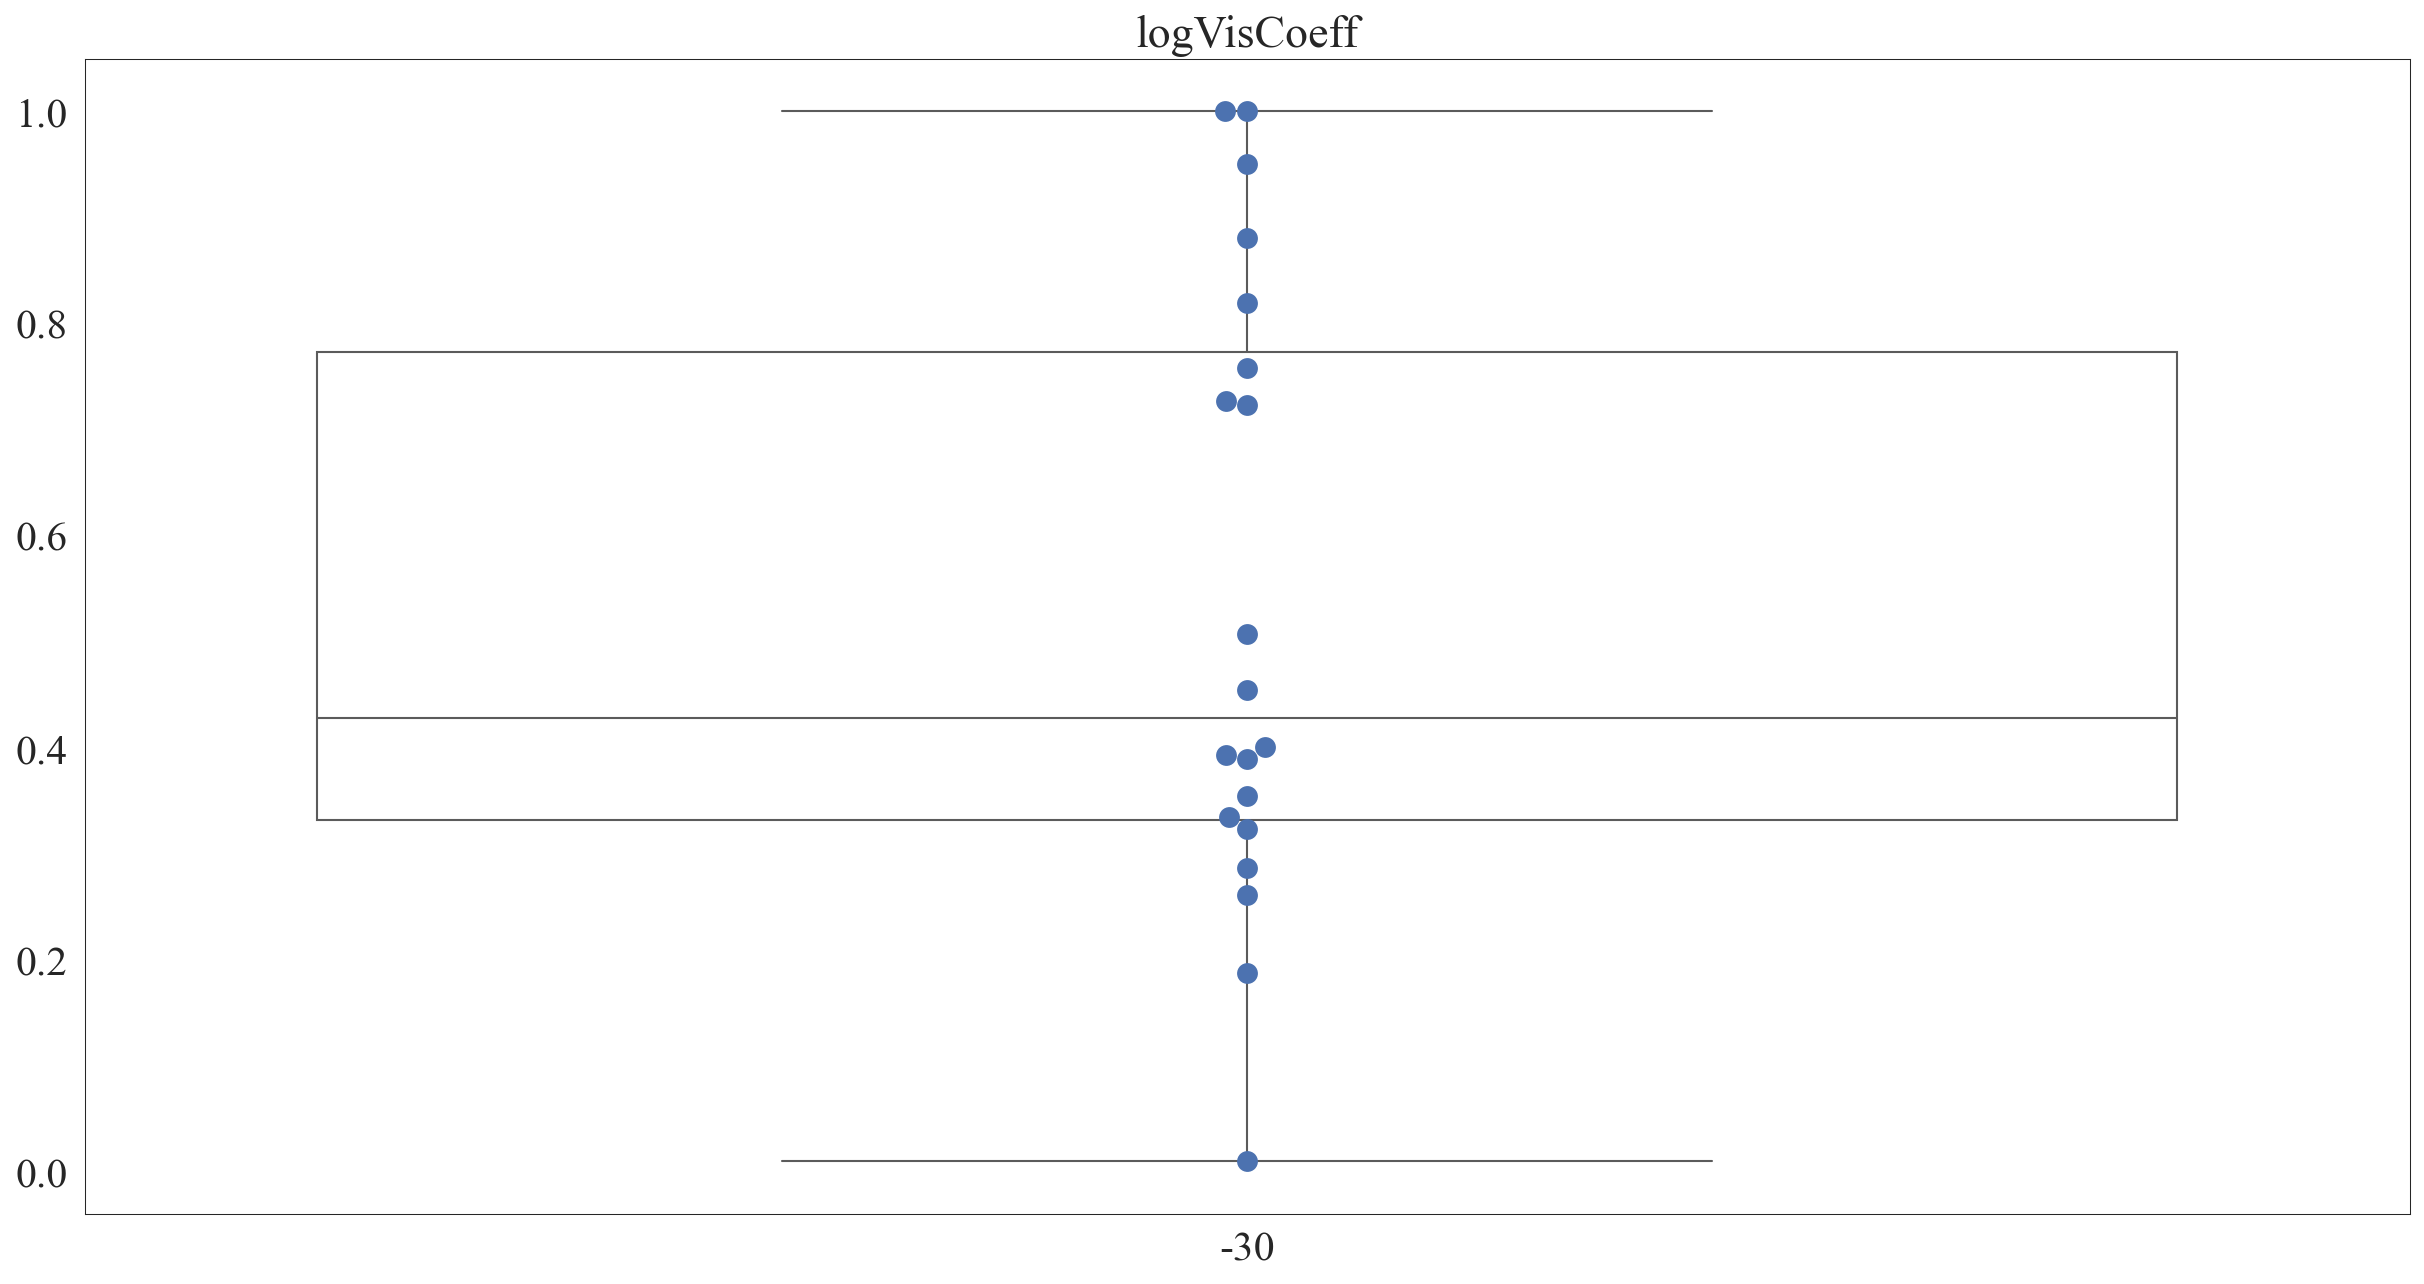

In [4]:
%matplotlib inline

rots = [-30]
for i in range(1):
    sns.swarmplot(x=rots[i],y=BrudBOCD[i].rSquareds,size=10)
    sns.boxplot(x=rots[i], y=BrudBOCD[i].rSquareds,boxprops=dict(facecolor="none"))
plt.title("r^2")
plt.show()
for i in range(1):
    sns.swarmplot(x=rots[i],y=BrudBOCD[i].rmses,size=10)
    sns.boxplot(x=rots[i], y=BrudBOCD[i].rmses,boxprops=dict(facecolor="none"))
plt.title("rmse")
plt.show()
for i in range(1):
    sns.swarmplot(x=rots[i],y=BrudBOCD[i].bics,size=10)
    sns.boxplot(x=rots[i], y=BrudBOCD[i].bics,boxprops=dict(facecolor="none"))
plt.title("bic")
plt.show()
paramLabs = ["logSigma0", "logHazard", "logSigma1", "logitPGlobal",
             "logitPS0", "logVisCoeff"]
k = 0
for lab in paramLabs:
    for i in range(1):
        sns.swarmplot(x=rots[i],y=[BrudBOCD[i].xs[j][k] for j in range(len(BrudBOCD[i].xs))],size=10)
        sns.boxplot(x=rots[i], y=[BrudBOCD[i].xs[j][k] for j in range(len(BrudBOCD[i].xs))],boxprops=dict(facecolor="none"))
    plt.title(lab)
    plt.show()
    k += 1

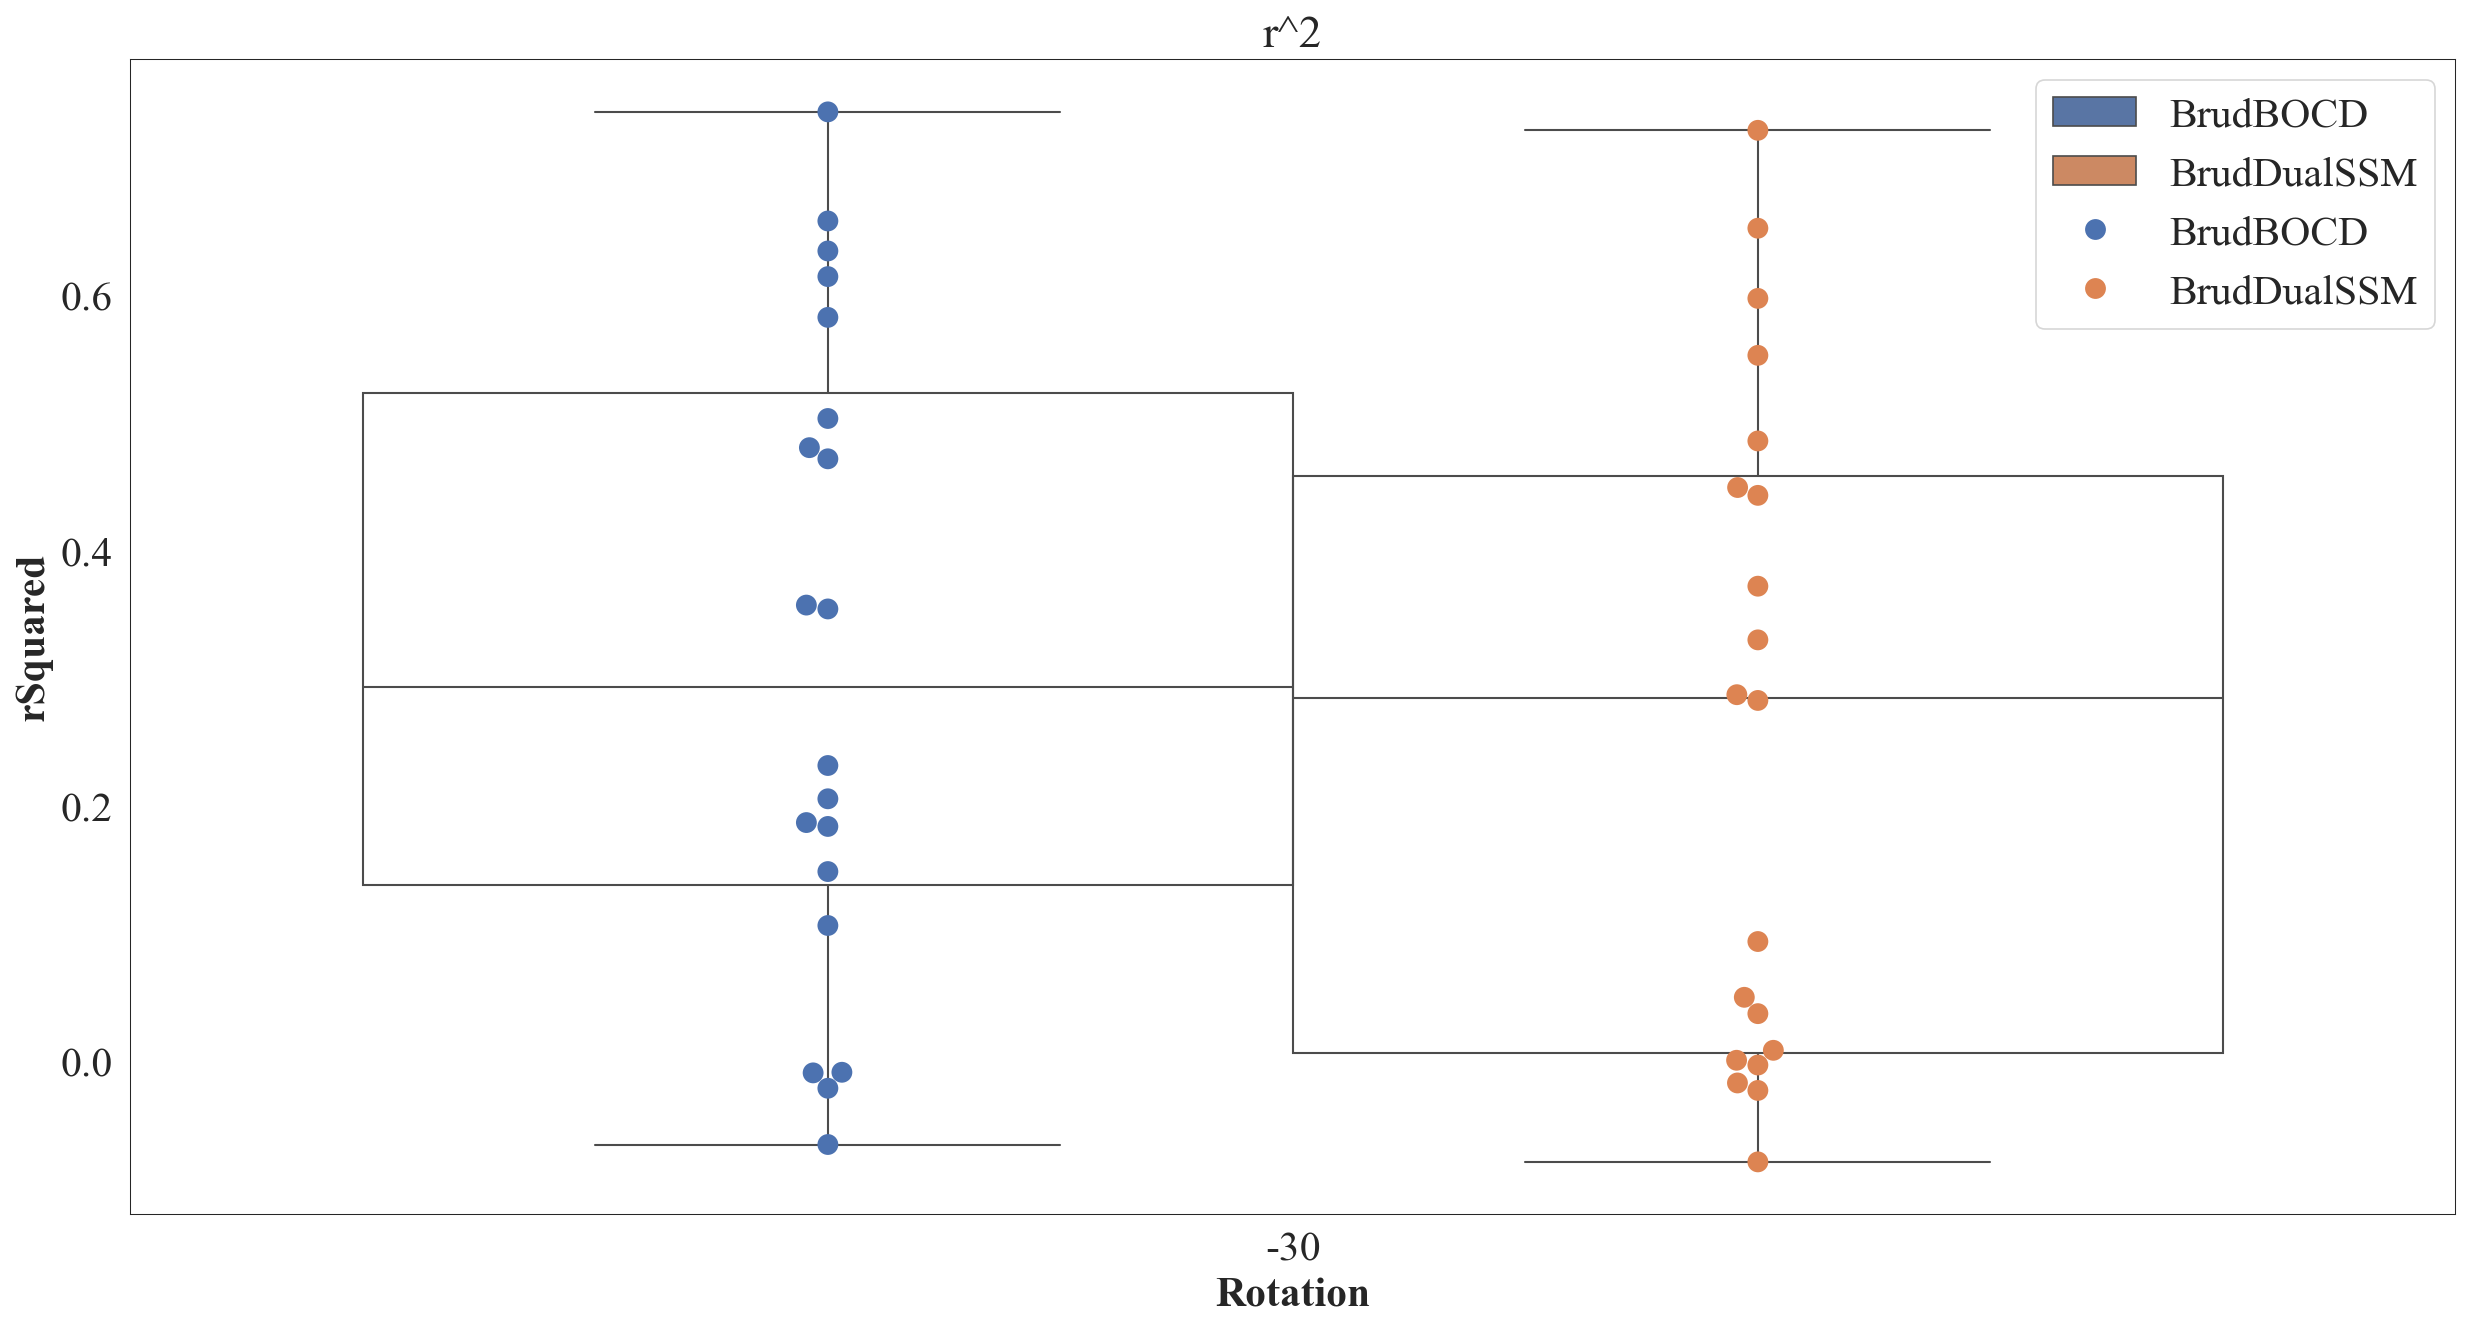

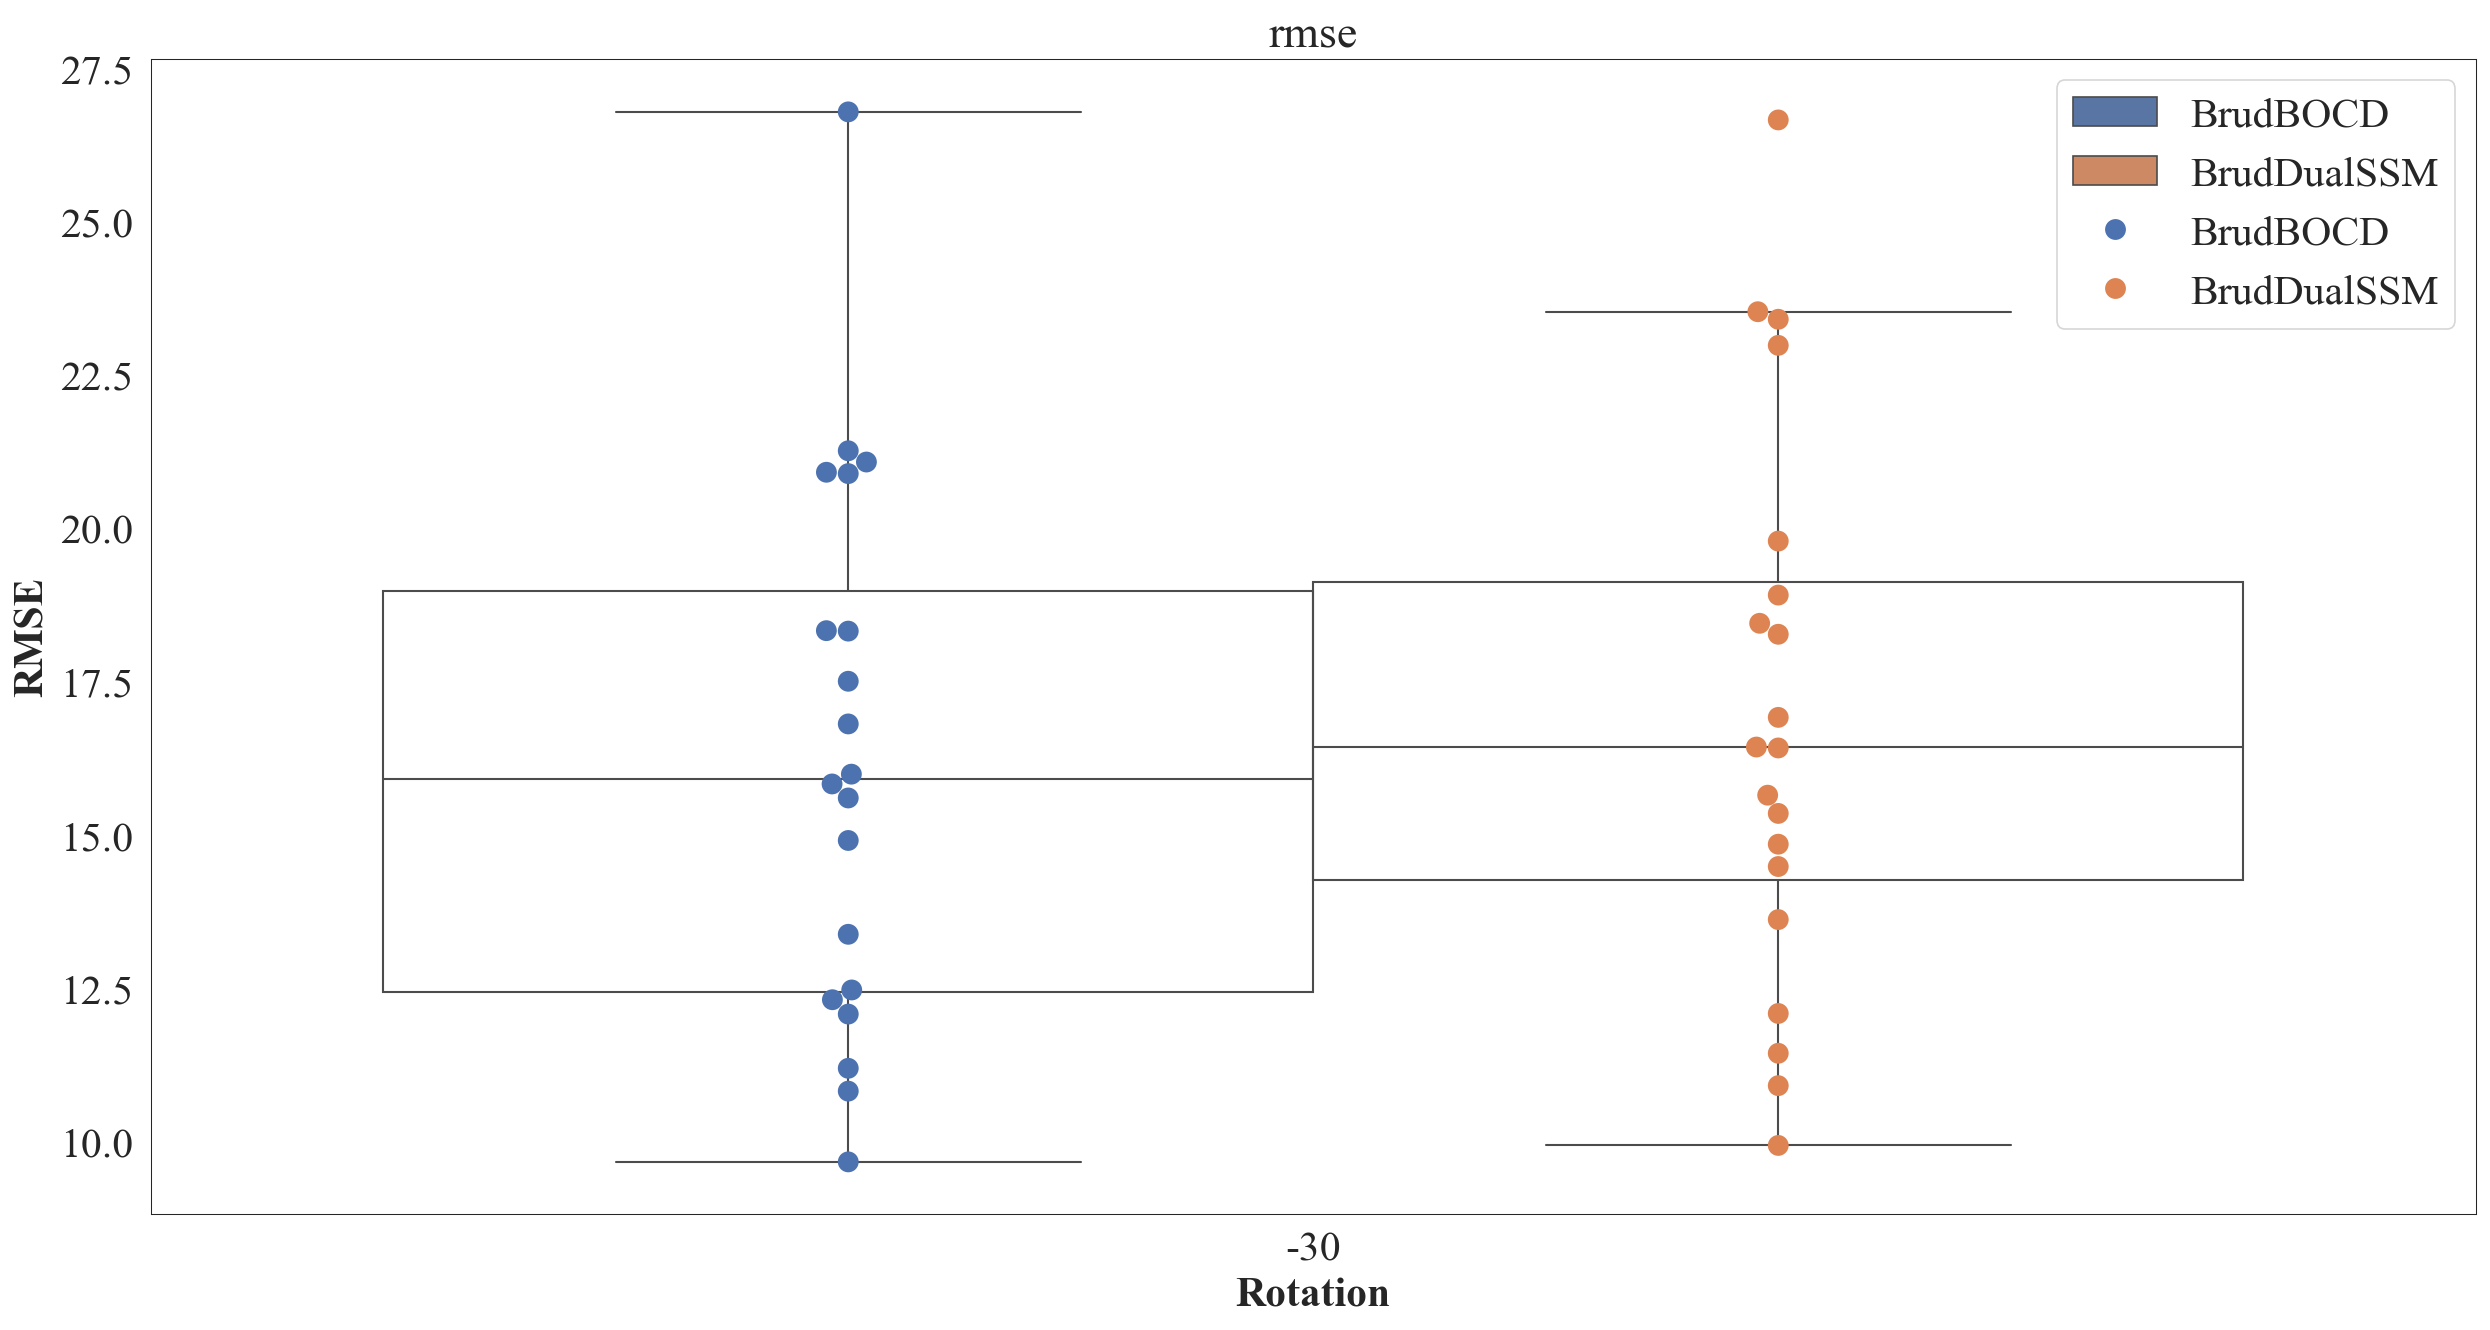

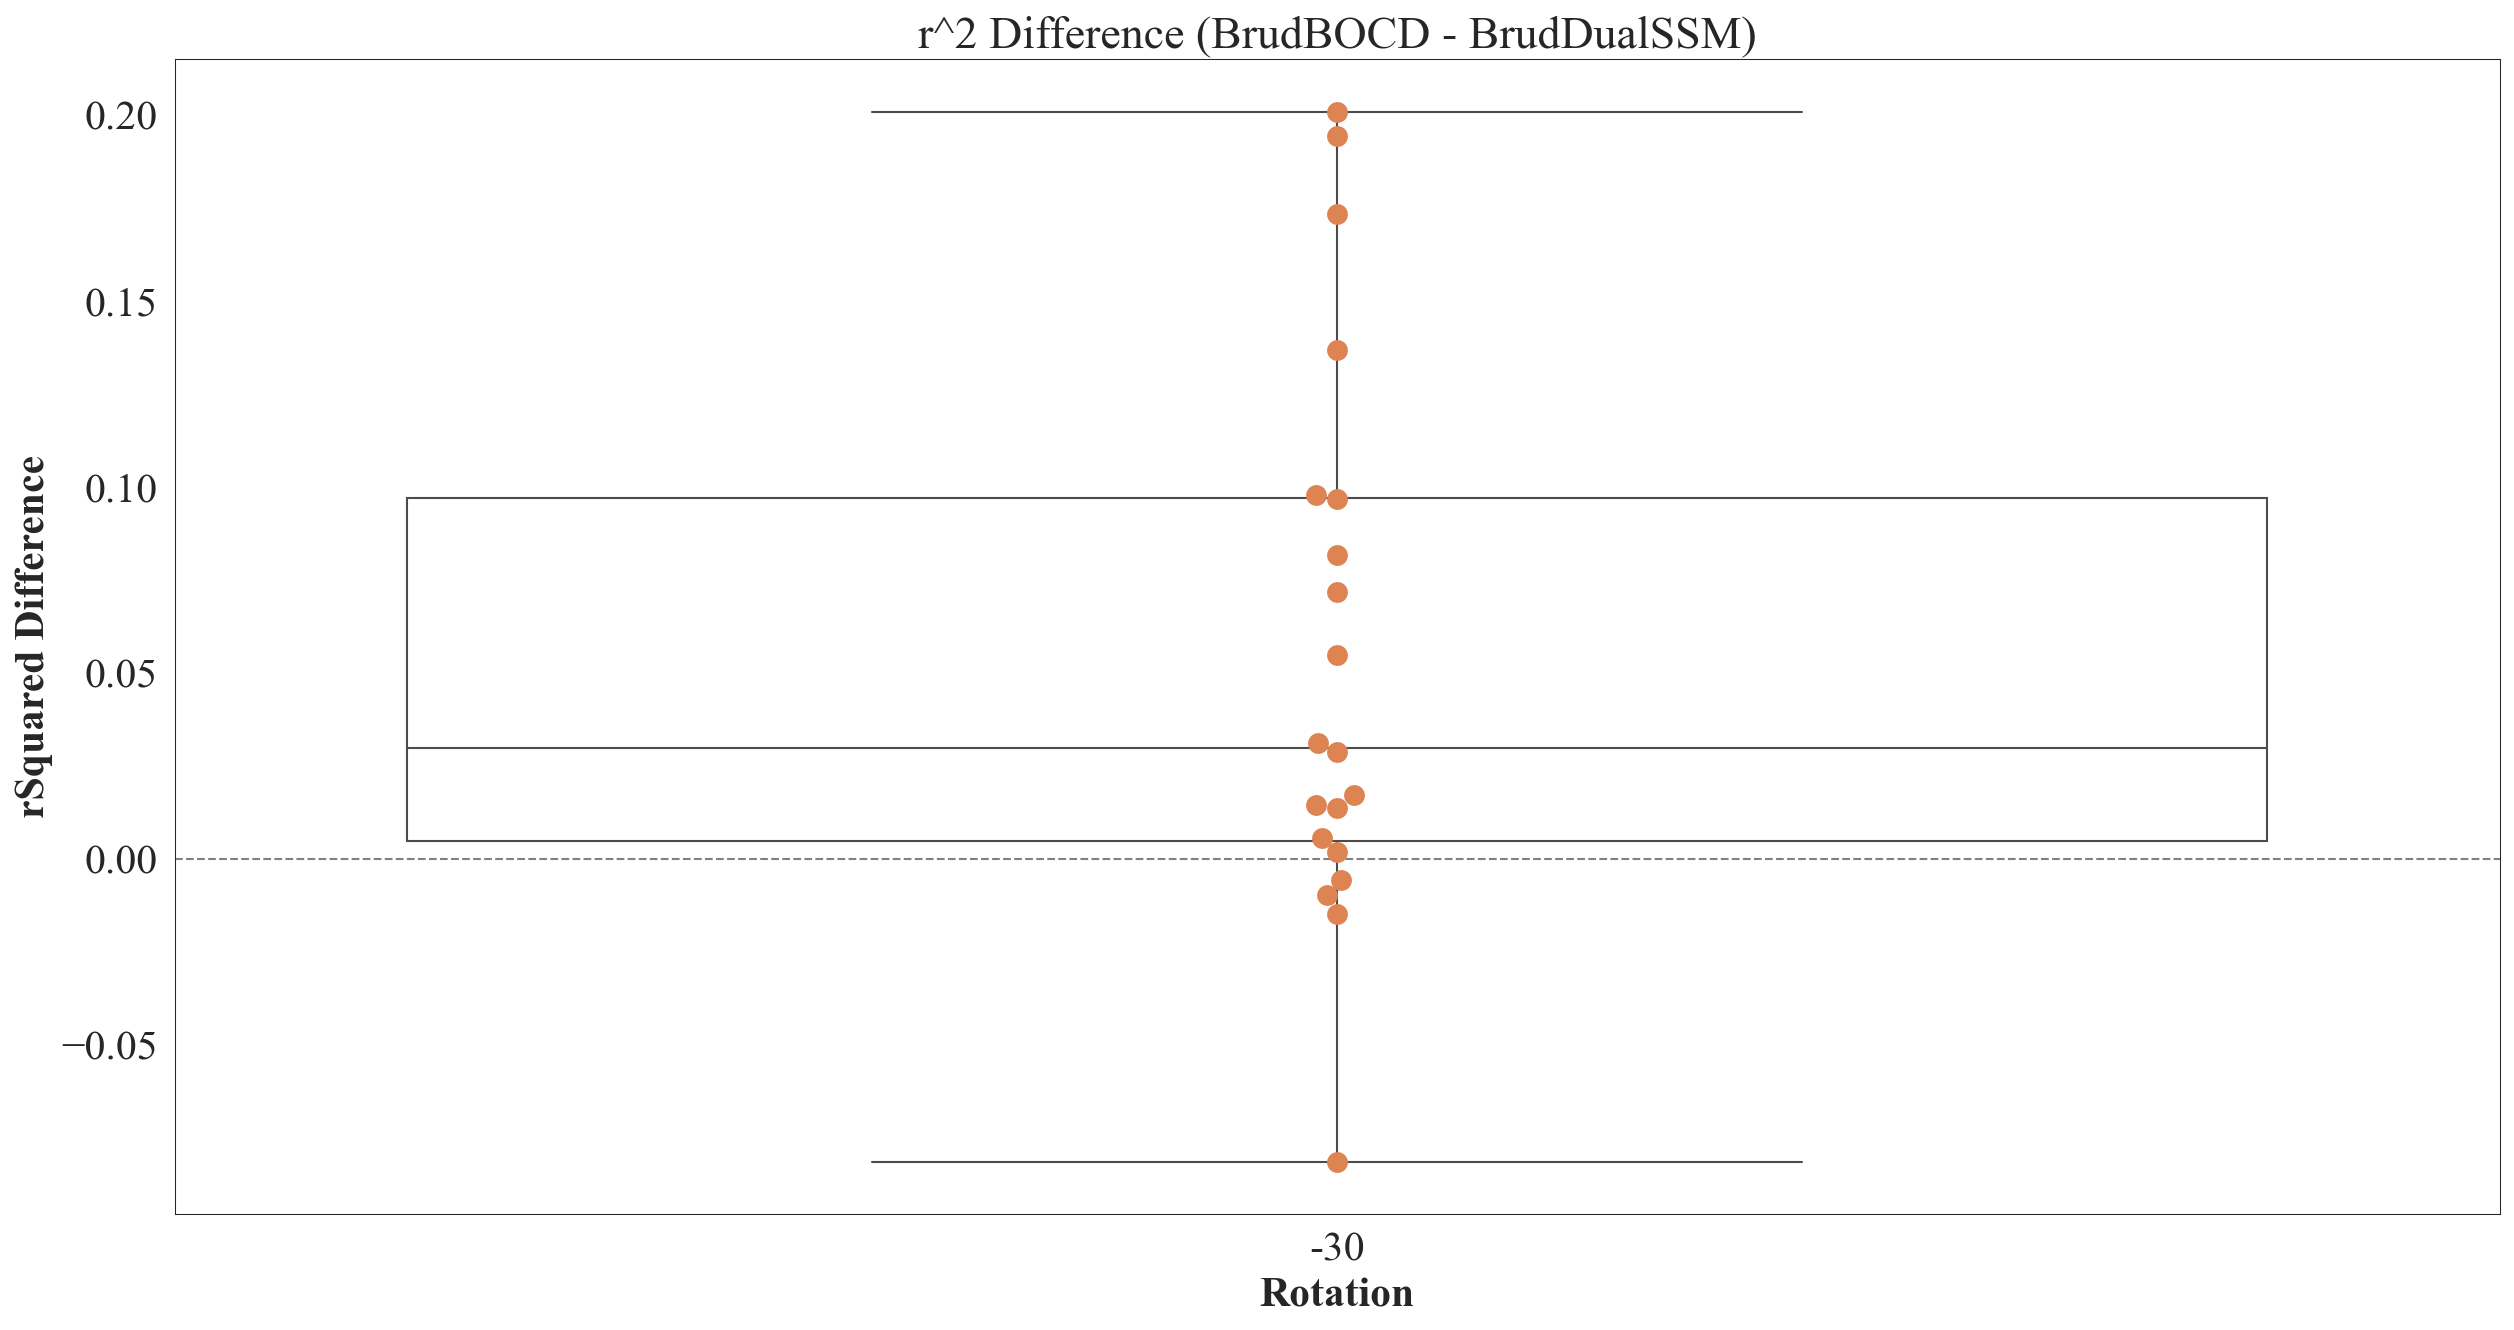

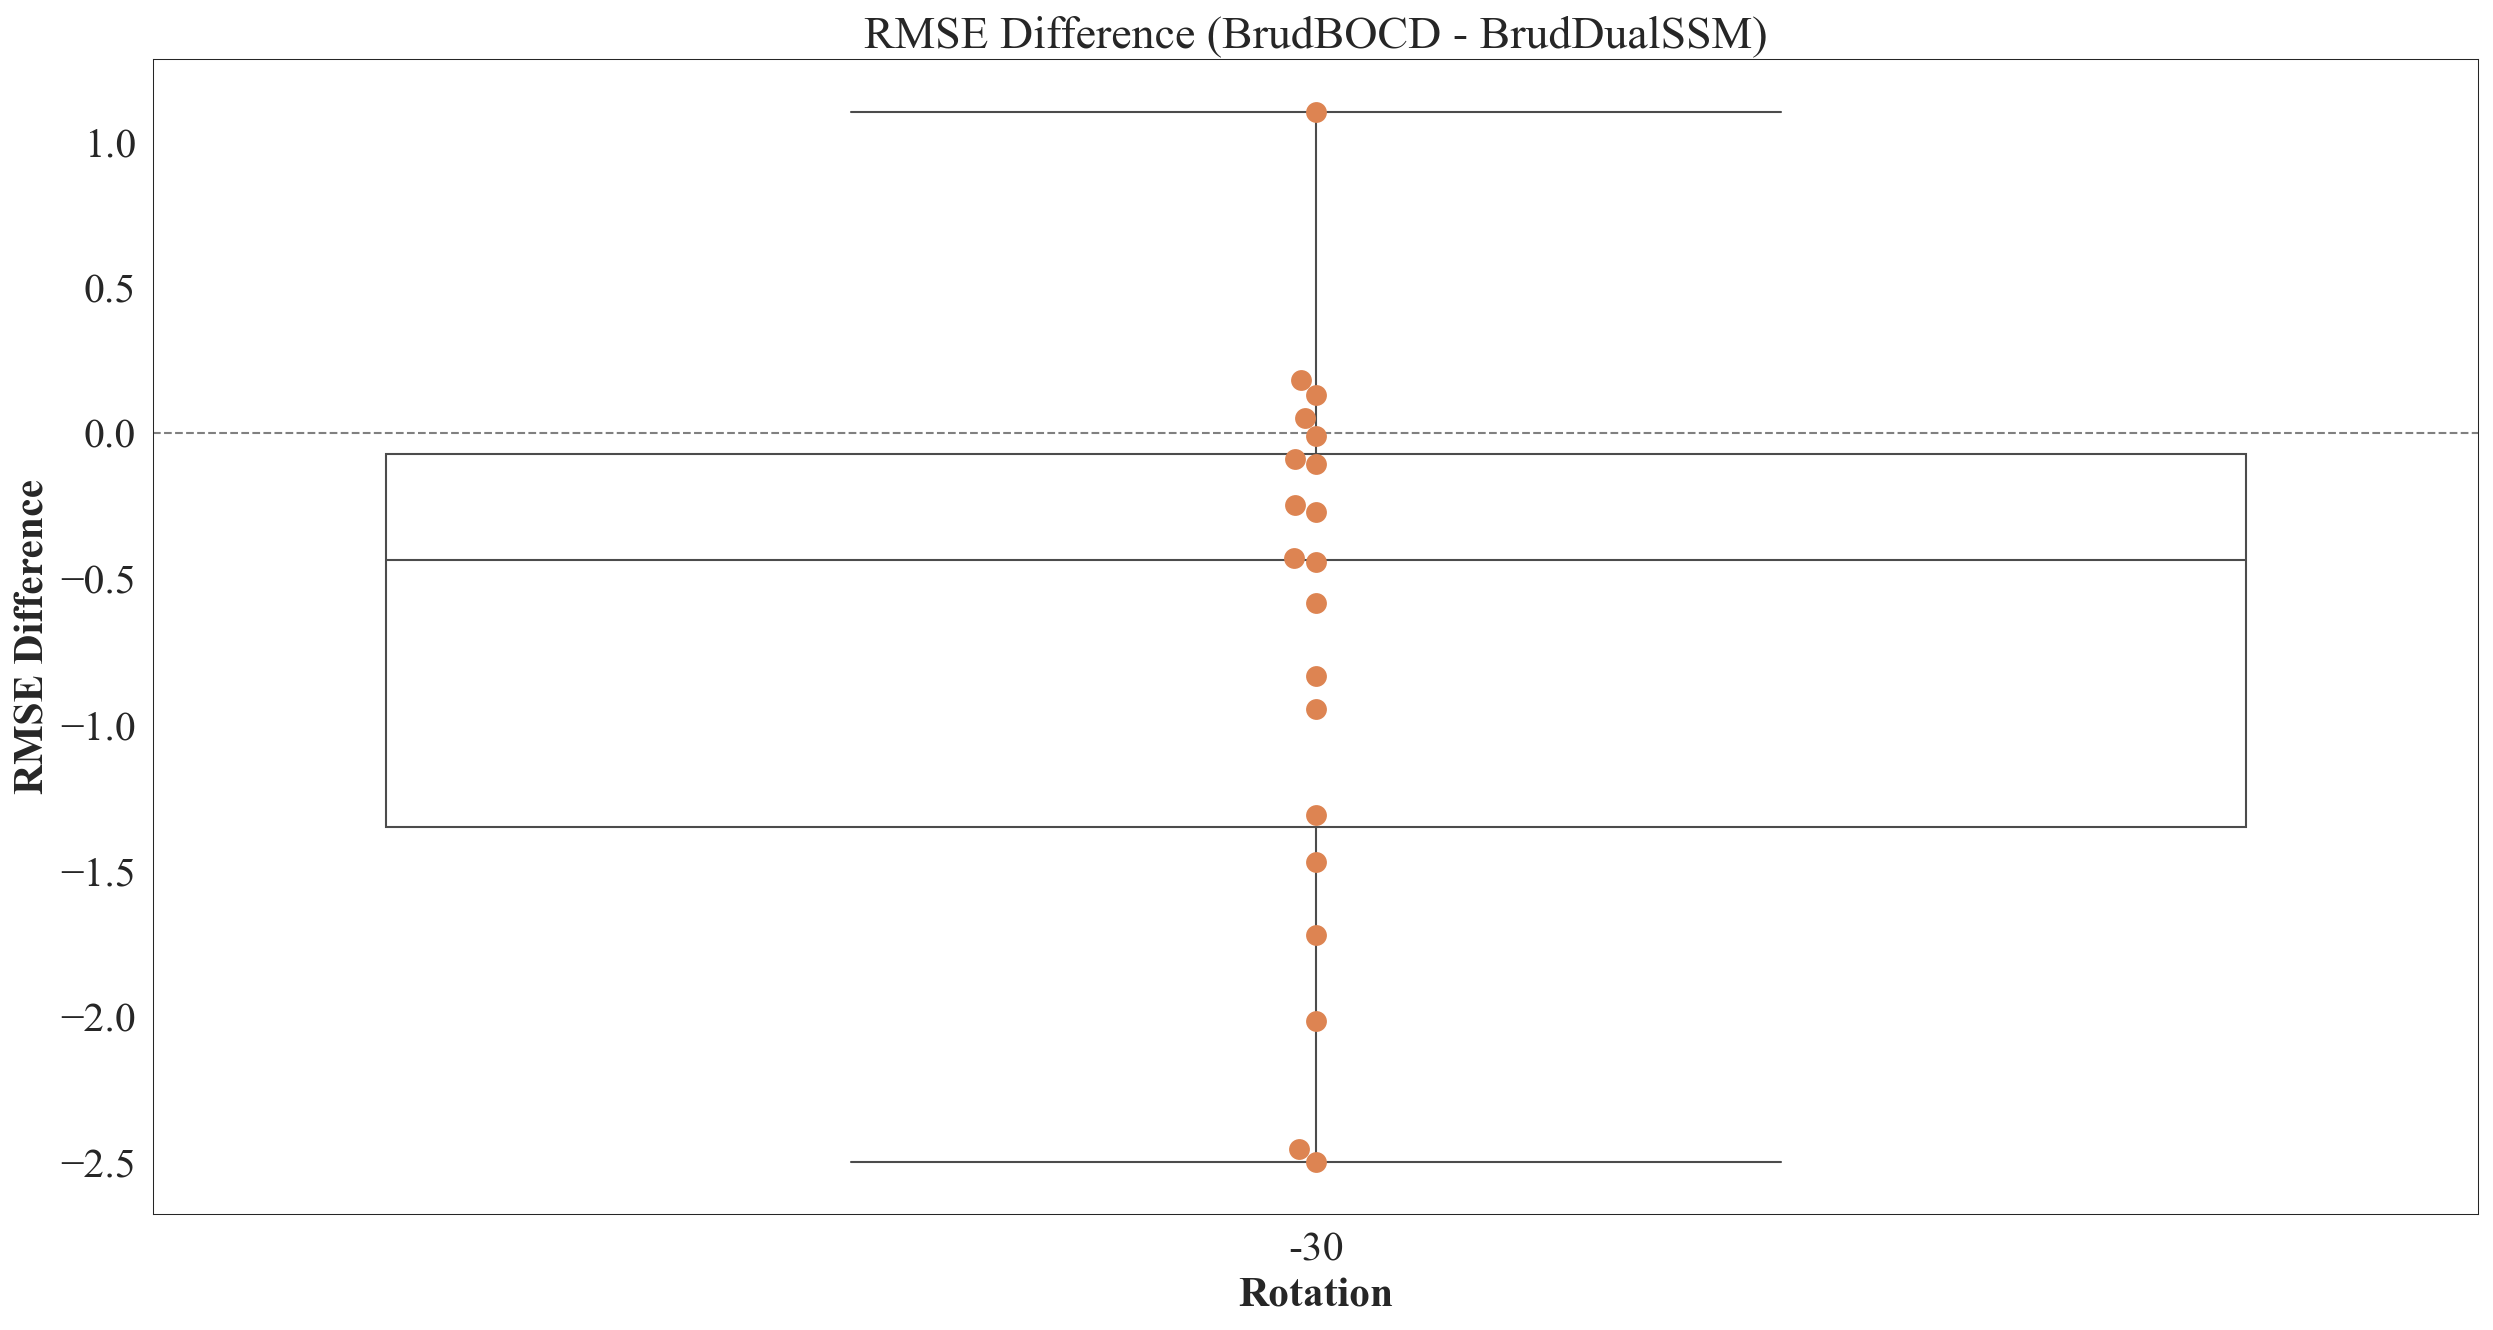

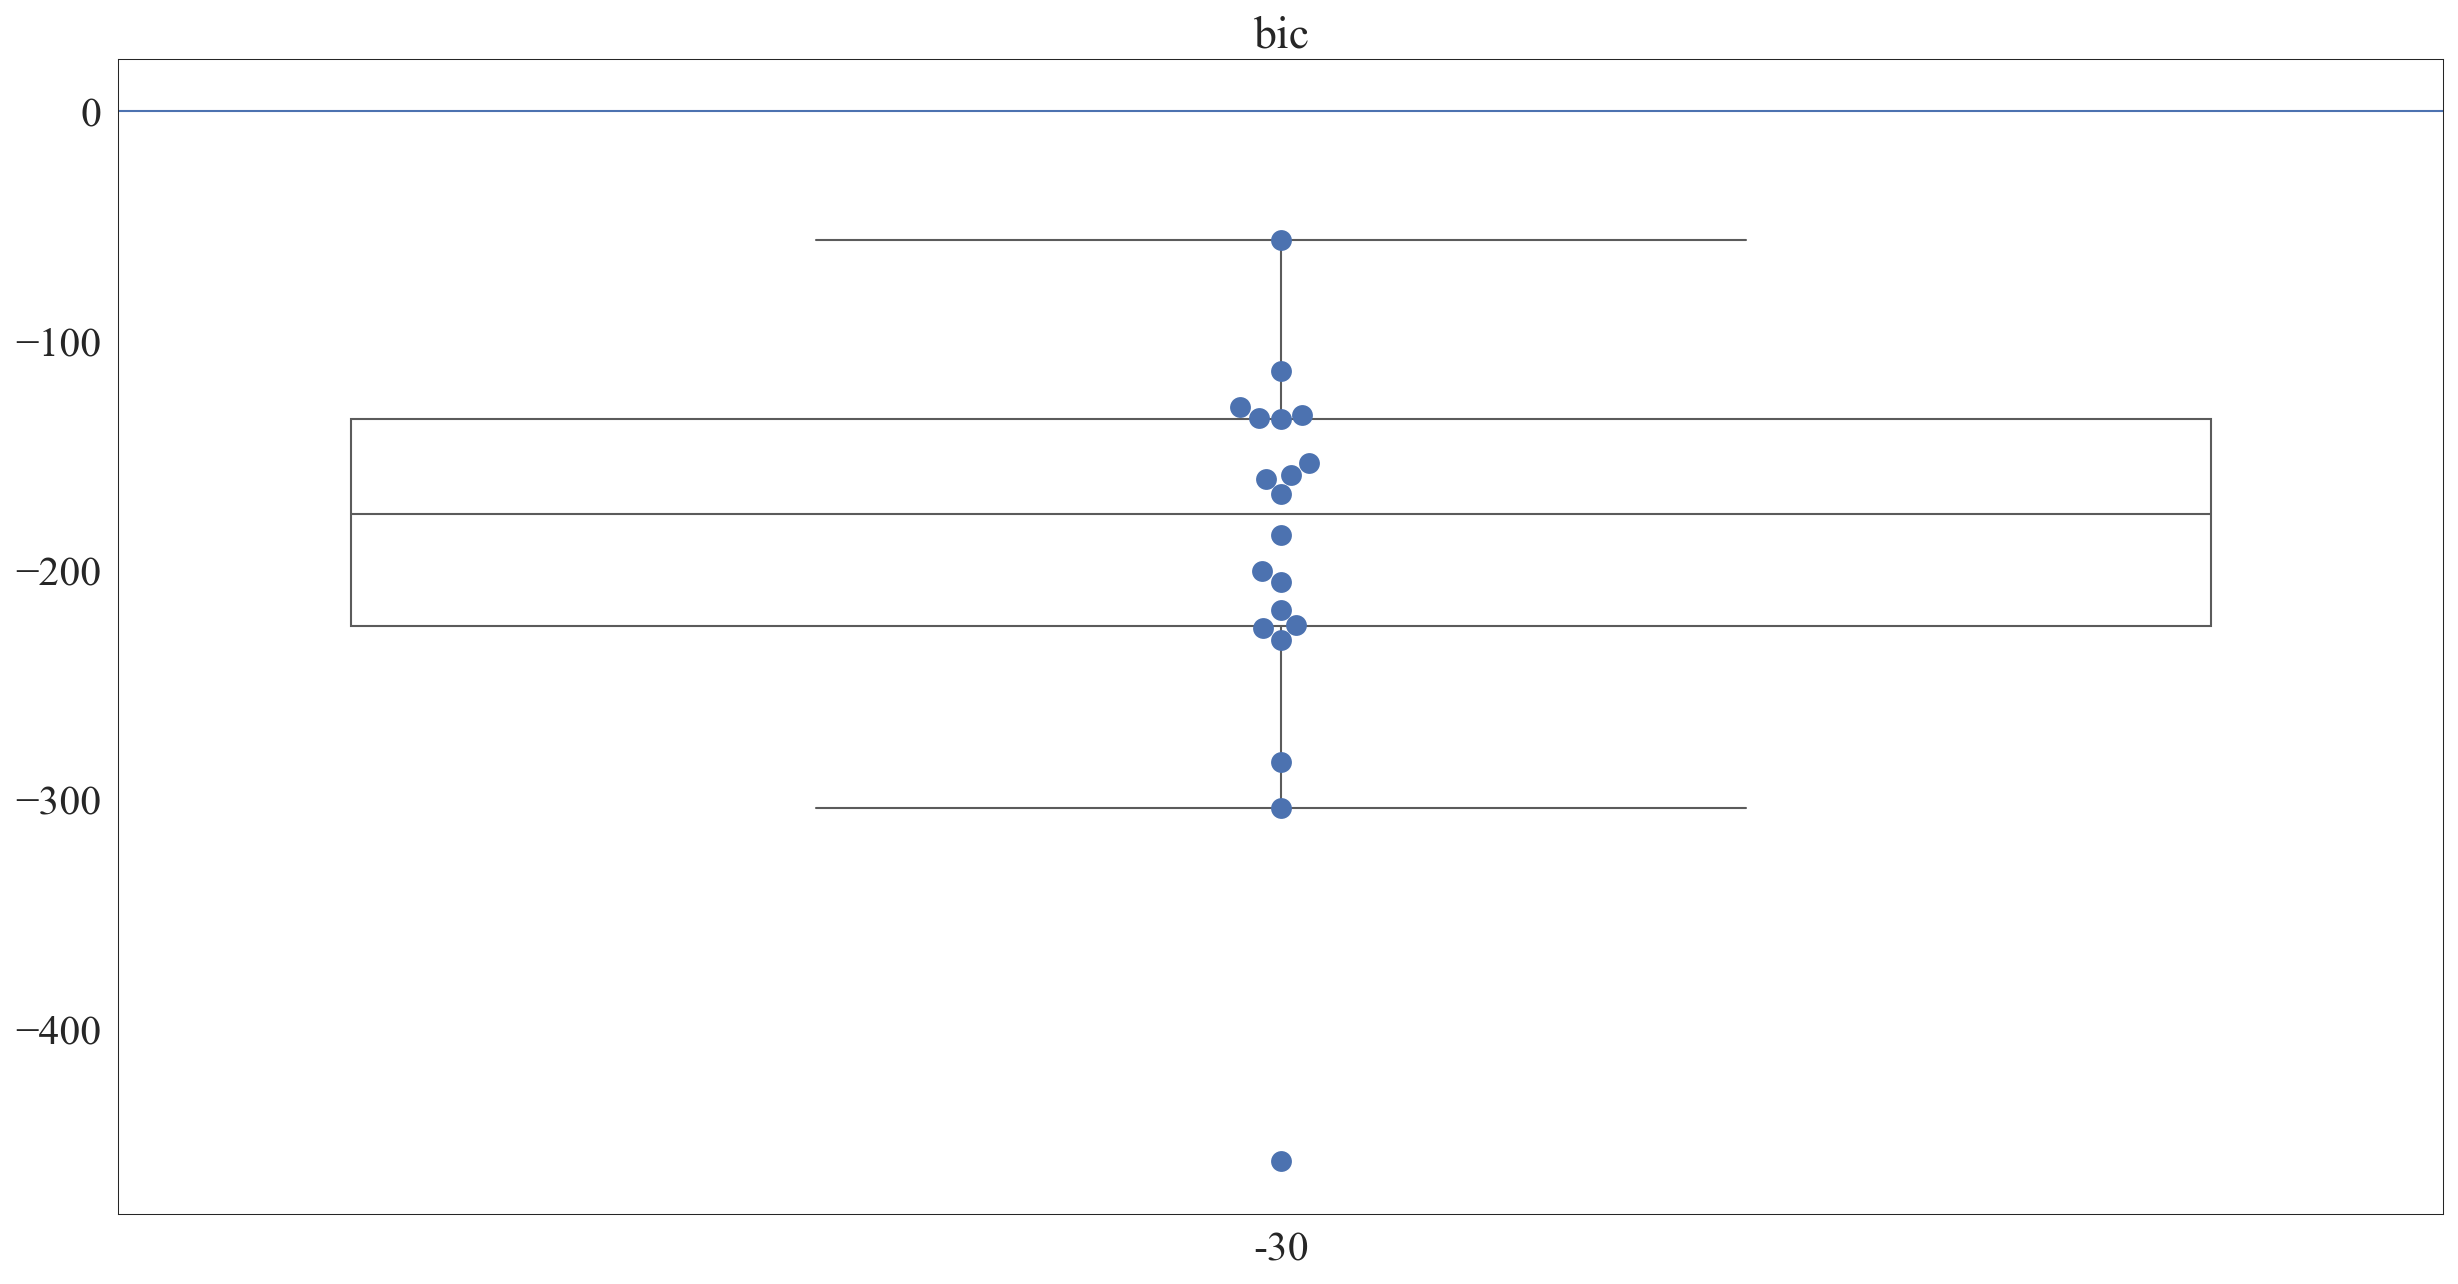

In [5]:


rots = [-30]

                            
data_r2 = []
for i in range(len(rots)):
    for r2_bocd, r2_ssm in zip(BrudBOCD[i].rSquareds, BrudDualSSM[i].rSquareds):
        data_r2.append({'Rotation': rots[i], 'rSquared': r2_bocd, 'Model': 'BrudBOCD'})
        data_r2.append({'Rotation': rots[i], 'rSquared': r2_ssm, 'Model': 'BrudDualSSM'})
df_r2 = pd.DataFrame(data_r2)

                                                  
plt.figure()
sns.boxplot(x='Rotation', y='rSquared', hue='Model', data=df_r2, dodge=True, boxprops=dict(facecolor="none"))
sns.swarmplot(x='Rotation', y='rSquared', hue='Model', data=df_r2, dodge=True, size=10)
plt.title("r^2")
plt.legend()
plt.show()

                        
data_rmse = []
for i in range(len(rots)):
    for rmse_bocd, rmse_ssm in zip(BrudBOCD[i].rmses, BrudDualSSM[i].rmses):
        data_rmse.append({'Rotation': rots[i], 'RMSE': rmse_bocd, 'Model': 'BrudBOCD'})
        data_rmse.append({'Rotation': rots[i], 'RMSE': rmse_ssm, 'Model': 'BrudDualSSM'})
df_rmse = pd.DataFrame(data_rmse)

                                              
plt.figure()
sns.boxplot(x='Rotation', y='RMSE', hue='Model', data=df_rmse, dodge=True, boxprops=dict(facecolor="none"))
sns.swarmplot(x='Rotation', y='RMSE', hue='Model', data=df_rmse, dodge=True, size=10)
plt.title("rmse")
plt.legend()
plt.show()


                                        
data_r2_diff = []
for i in range(len(rots)):
    r2_diff = np.subtract(BrudBOCD[i].rSquareds, BrudDualSSM[i].rSquareds)
    for val in r2_diff:
        data_r2_diff.append({'Rotation': rots[i], 'rSquared Difference': val})
df_r2_diff = pd.DataFrame(data_r2_diff)

                            
plt.figure()
sns.boxplot(x='Rotation', y='rSquared Difference', data=df_r2_diff, boxprops=dict(facecolor="none"))
sns.swarmplot(x='Rotation', y='rSquared Difference', data=df_r2_diff, size=10)
plt.title("r^2 Difference (BrudBOCD - BrudDualSSM)")
plt.axhline(0, color='gray', linestyle='--')                                            
plt.show()

                                    
data_rmse_diff = []
for i in range(len(rots)):
    rmse_diff = np.subtract(BrudBOCD[i].rmses, BrudDualSSM[i].rmses)
    for val in rmse_diff:
        data_rmse_diff.append({'Rotation': rots[i], 'RMSE Difference': val})
df_rmse_diff = pd.DataFrame(data_rmse_diff)

                        
plt.figure()
sns.boxplot(x='Rotation', y='RMSE Difference', data=df_rmse_diff, boxprops=dict(facecolor="none"))
sns.swarmplot(x='Rotation', y='RMSE Difference', data=df_rmse_diff, size=10)
plt.title("RMSE Difference (BrudBOCD - BrudDualSSM)")
plt.axhline(0, color='gray', linestyle='--')                                            
plt.show()


                       
for i in range(len(rots)):
    sns.swarmplot(x=rots[i], y=np.subtract(BrudBOCD[i].bics, BrudDualSSM[i].bics), size=10)
    sns.boxplot(x=rots[i], y=np.subtract(BrudBOCD[i].bics, BrudDualSSM[i].bics), boxprops=dict(facecolor="none"))
    plt.axhline(0)
plt.title("bic")
plt.show()